---

# Examination of "Prodicting Student Dropout Using Machine Learning Algorithms" by S. A. Sulak and N. Koklu

## Import Dependencies

In [2]:
from fastai.data.all import *
from fastai.metrics import accuracy, Recall, Precision, F1Score
from fastai.tabular.all import *
from fastai.text.all import *
from itertools import product
from mpl_toolkits.mplot3d import Axes3D
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
# from torchsummary import summary
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

%matplotlib inline 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Declare Utility Functions

In [3]:
def data_splitting(data, target):
    X_train_and_validate, X_test, t_train_and_validate, t_test = train_test_split(
        data, target, test_size=0.2, random_state=0
    )
    print("Train and Validate Data Shape:")
    print(X_train_and_validate.shape)
    print("Train and Validate Targets Shape:")
    print(t_train_and_validate.shape)
    print("Test Data Shape:")
    print(X_test.shape)
    print("Test Targets Shape:")
    print(t_test.shape)
    return X_train_and_validate, X_test, t_train_and_validate, t_test

def eval_report_from_obj(cv_results):
    print(u"Evaluation Report")
    print(u"---")
    print(u"Validation Accuracy: {:.3f} \u00B1 {:.3f}".format(cv_results['test_accuracy'].mean(), cv_results['test_accuracy'].std()))
    print(u"Validation Precision: {:.3f} \u00B1 {:.3f}".format(cv_results['test_precision_weighted'].mean(), cv_results['test_precision_weighted'].std()))
    print(u"Validation Recall: {:.3f} \u00B1 {:.3f}".format(cv_results['test_recall_weighted'].mean(), cv_results['test_recall_weighted'].std()))
    print(u"Validation F1: {:.3f} \u00B1 {:.3f}".format(cv_results['test_f1_weighted'].mean(), cv_results['test_f1_weighted'].std()))

def eval_report_from_targets_and_predicted_targets(targets, predicted_targets):
    print(u"Evaluation Report")
    print(u"---")
    print(u"Accuracy: {:.3f}".format(accuracy_score(targets, predicted_targets)))
    print(u"Precision: {:.3f}".format(precision_score(targets, predicted_targets, average='weighted')))
    print(u"Recall: {:.3f}".format(recall_score(targets, predicted_targets, average='weighted')))
    print(u"F1: {:.3f}".format(f1_score(targets, predicted_targets, average='weighted')))

def plot_test_accuracy(targets, predicted_targets, categories=None):
    sorted_idx = np.argsort(targets)
    plt.figure(figsize=(6,6))
    plt.scatter(sorted_idx, targets[sorted_idx], marker='o', c='red', label='target');
    plt.scatter(sorted_idx, predicted_targets[sorted_idx], marker='.', c='blue', label='prediction');
    plt.xlabel('Student Instances')
    plt.ylabel('Student Outcome')
    if categories is not None:
        plt.yticks([0, 1, 2], categories)
    plt.legend()
    plt.show()

def orig_hyper_param_value_to_search_values(num):
    search_values_length = 10
    multiplicand = num / 5
    search_values = []
    for i in range(search_values_length):
        multiplier = i + 1
        search_value = int(multiplicand * multiplier)
        if search_value < 2:
            search_value = 2
        if search_value not in search_values:
            search_values.append(search_value)
    return search_values


## Load Dataset

In [4]:
realinho_df = pd.read_csv("./realinho.csv", sep=";")
realinho_features = realinho_df.iloc[:, :-1]
realinho_targets = realinho_df.iloc[:, -1]

## Visualize Dataset

In [5]:
realinho_df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


Note: Dataset imbalance is addressed at the algorithm level.


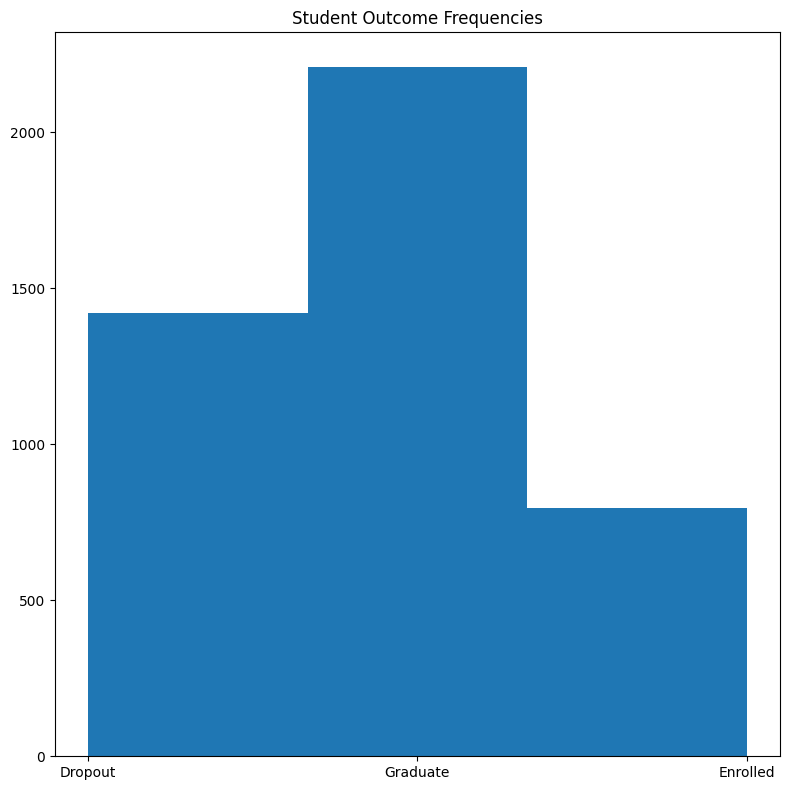

In [6]:
fig = plt.figure(figsize=(8,8))
plt.clf()
plt.hist(realinho_df[realinho_df.columns[-1]], bins=3)
plt.title("Student Outcome Frequencies")
fig.tight_layout()

print("Note: Dataset imbalance is addressed at the algorithm level.")

## Split Dataset

In [7]:
X_train_and_validate, X_test, t_train_and_validate, t_test = data_splitting(
    data=realinho_features,
    target=realinho_targets
)

Train and Validate Data Shape:
(3539, 36)
Train and Validate Targets Shape:
(3539,)
Test Data Shape:
(885, 36)
Test Targets Shape:
(885,)


## Decision Tree Classifier

### Perform K-Fold Cross-Validation Using Paper K-Fold Value & Hyperparameters

In [8]:
paper_hyper_parameters = {
    'max_depth': 100,
    'min_samples_split': 5,
    'min_samples_leaf': 2
}
print("Decision Tree hyperparameters arbitrarily selected by paper authors: max_depth={}, min_samples_leaf={}, min_samples_split={}".format(
    paper_hyper_parameters['max_depth'],
    paper_hyper_parameters['min_samples_leaf'],
    paper_hyper_parameters['min_samples_split']))

dt = DecisionTreeClassifier(class_weight='balanced', # Paper authors do not discuss how they dealt with class imbalance.
                            max_depth=paper_hyper_parameters['max_depth'], 
                            min_samples_leaf=paper_hyper_parameters['min_samples_leaf'],
                            min_samples_split=paper_hyper_parameters['min_samples_split'],
                            random_state=0)

k_fold=10
print("k-fold value used by paper authors: {}".format(k_fold))

my_cv_results = cross_validate(dt, X_train_and_validate, t_train_and_validate,
                            cv=k_fold,
                            scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'])

eval_report_from_obj(my_cv_results)

Decision Tree hyperparameters arbitrarily selected by paper authors: max_depth=100, min_samples_leaf=2, min_samples_split=5
k-fold value used by paper authors: 10
Evaluation Report
---
Validation Accuracy: 0.654 ± 0.023
Validation Precision: 0.675 ± 0.021
Validation Recall: 0.654 ± 0.023
Validation F1: 0.662 ± 0.021


### Test

In [9]:
print("The K-Fold cross validation results should indicate that the model is likely performant with the dataset.")
print("Therefore, train the model with all test and validate data.")
dt.fit(X_train_and_validate, t_train_and_validate)

The K-Fold cross validation results should indicate that the model is likely performant with the dataset.
Therefore, train the model with all test and validate data.


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",100
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

#### My Results

Evaluation Report
---
Accuracy: 0.668
Precision: 0.706
Recall: 0.668
F1: 0.682


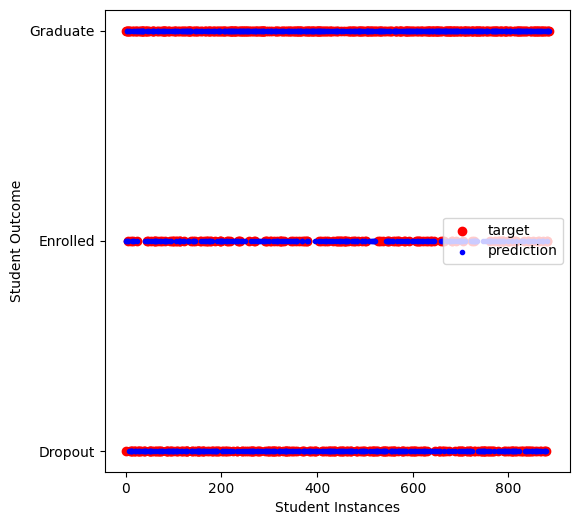

In [10]:
y_test_pred = dt.predict(X_test)
eval_report_from_targets_and_predicted_targets(t_test, y_test_pred)
plot_test_accuracy(t_test.values.to_numpy(), y_test_pred)

#### Paper Results

In [11]:
paper_test_results = {
    "test_accuracy": np.array([0.701]),
    "test_precision_weighted": np.array([0.7]),
    "test_recall_weighted": np.array([0.701]),
    "test_f1_weighted": np.array([0.7])
}
eval_report_from_obj(paper_test_results)

Evaluation Report
---
Validation Accuracy: 0.701 ± 0.000
Validation Precision: 0.700 ± 0.000
Validation Recall: 0.701 ± 0.000
Validation F1: 0.700 ± 0.000


### Attempt to Improve Test Results with Hyperparameter Search

In [12]:
my_hyper_parameter_options = {
    'max_depth': orig_hyper_param_value_to_search_values(paper_hyper_parameters['max_depth']),
    'min_samples_split': orig_hyper_param_value_to_search_values(paper_hyper_parameters['min_samples_split']),
    'min_samples_leaf': orig_hyper_param_value_to_search_values(paper_hyper_parameters['min_samples_leaf'])
}
print("Options for Hyperparameters Search:")
print("max_depth: {}".format(my_hyper_parameter_options['max_depth']))
print("min_samples_split: {}".format(my_hyper_parameter_options['min_samples_split']))
print("min_samples_leaf: {}".format(my_hyper_parameter_options['min_samples_leaf']))

gscv = GridSearchCV(dt, my_hyper_parameter_options, cv=k_fold)
gscv.fit(X_train_and_validate, t_train_and_validate)

print(f"Search Found these Best Hyperparameters: {gscv.best_params_}")

Options for Hyperparameters Search:
max_depth: [20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
min_samples_split: [2, 3, 4, 5, 6, 7, 8, 9, 10]
min_samples_leaf: [2, 3, 4]
Search Found these Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 2}


### Retest with Model Trained Using the New Hyperparameters on All Test and Validate Data 

Evaluation Report
---
Accuracy: 0.662
Precision: 0.700
Recall: 0.662
F1: 0.677


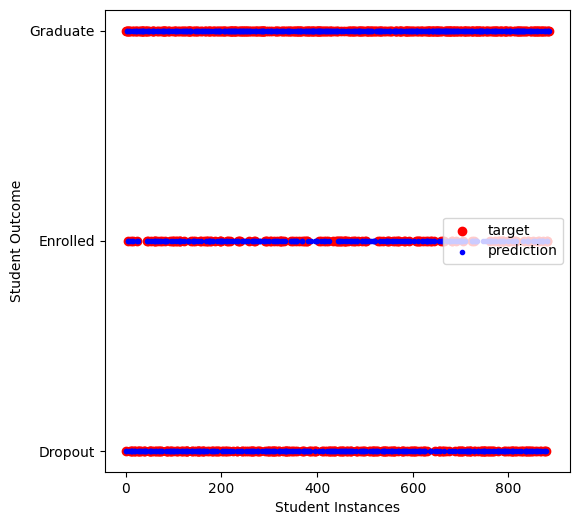

In [13]:
y_test_pred = gscv.predict(X_test)
eval_report_from_targets_and_predicted_targets(t_test, y_test_pred)
plot_test_accuracy(t_test.values.to_numpy(), y_test_pred)

## Random Forest

### Perform K-Fold Cross-Validation Using Paper K-Fold Value & Hyperparameters

In [14]:
paper_hyper_parameters = {
    'max_depth': 3,
    'max_features': 5,
    'min_samples_split': 5,
    'n_estimators': 10,
}
print("Random Forest hyperparameters arbitrarily selected by paper authors: n_estimators={}, max_depth={}, max_features={}, min_samples_split={}".format(
    paper_hyper_parameters['max_depth'],
    paper_hyper_parameters['max_features'],
    paper_hyper_parameters['min_samples_split'],
    paper_hyper_parameters['n_estimators']))

rf = RandomForestClassifier(max_depth=3,
                            max_features=5,
                            min_samples_split=5,
                            n_estimators=100,
                            oob_score=False,
                            class_weight='balanced', # Paper authors do not discuss how they dealt with class imbalance.
                            random_state=0)

print("k-fold value used by paper authors: {}".format(k_fold))

my_cv_results = cross_validate(rf, X_train_and_validate, t_train_and_validate,
                            cv=k_fold,
                            scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'])

eval_report_from_obj(my_cv_results)

Random Forest hyperparameters arbitrarily selected by paper authors: n_estimators=3, max_depth=5, max_features=5, min_samples_split=10
k-fold value used by paper authors: 10
Evaluation Report
---
Validation Accuracy: 0.729 ± 0.023
Validation Precision: 0.741 ± 0.023
Validation Recall: 0.729 ± 0.023
Validation F1: 0.732 ± 0.023


### Test

In [15]:
print("The K-Fold cross validation results should indicate that the model is likely performant with the dataset.")
print("Therefore, train the model with all test and validate data.")
rf.fit(X_train_and_validate, t_train_and_validate)

The K-Fold cross validation results should indicate that the model is likely performant with the dataset.
Therefore, train the model with all test and validate data.


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true,

#### My Results

Evaluation Report
---
Accuracy: 0.749
Precision: 0.762
Recall: 0.749
F1: 0.752


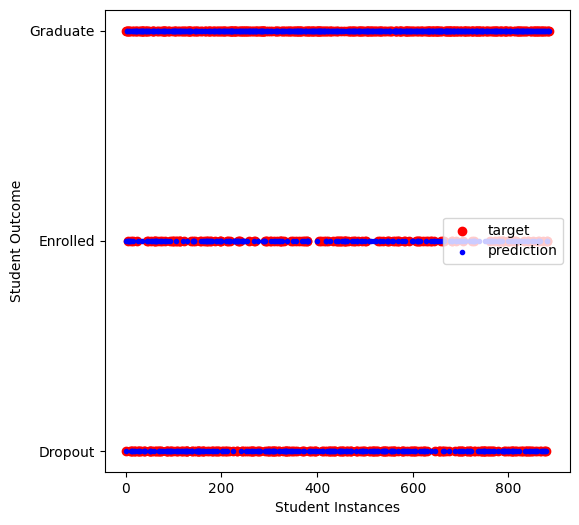

In [16]:
y_test_pred = rf.predict(X_test)
eval_report_from_targets_and_predicted_targets(t_test, y_test_pred)
plot_test_accuracy(t_test.values.to_numpy(), y_test_pred)

#### Paper Results

In [17]:
paper_test_results = {
    "test_accuracy": np.array([0.755]),
    "test_precision_weighted": np.array([0.739]),
    "test_recall_weighted": np.array([0.755]),
    "test_f1_weighted": np.array([0.742])
}
eval_report_from_obj(paper_test_results)

Evaluation Report
---
Validation Accuracy: 0.755 ± 0.000
Validation Precision: 0.739 ± 0.000
Validation Recall: 0.755 ± 0.000
Validation F1: 0.742 ± 0.000


### Attempt to Improve Test Results with Hyperparameter Search

In [18]:
my_hyper_parameter_options = {
    'max_depth': orig_hyper_param_value_to_search_values(paper_hyper_parameters['max_depth']),
    'max_features': orig_hyper_param_value_to_search_values(paper_hyper_parameters['max_features']),
    'min_samples_split': orig_hyper_param_value_to_search_values(paper_hyper_parameters['min_samples_split']),
    'n_estimators': orig_hyper_param_value_to_search_values(paper_hyper_parameters['n_estimators'])
}
print("Options for Hyperparameters Search:")
print("max_depth: {}".format(my_hyper_parameter_options['max_depth']))
print("max_features: {}".format(my_hyper_parameter_options['max_features']))
print("min_samples_split: {}".format(my_hyper_parameter_options['min_samples_split']))
print("n_estimators: {}".format(my_hyper_parameter_options['n_estimators']))

gscv = GridSearchCV(rf, my_hyper_parameter_options, cv=k_fold)
gscv.fit(X_train_and_validate, t_train_and_validate)

print(f"Search Found these Best Hyperparameters: {gscv.best_params_}")

Options for Hyperparameters Search:
max_depth: [2, 3, 4, 5, 6]
max_features: [2, 3, 4, 5, 6, 7, 8, 9, 10]
min_samples_split: [2, 3, 4, 5, 6, 7, 8, 9, 10]
n_estimators: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
Search Found these Best Hyperparameters: {'max_depth': 6, 'max_features': 9, 'min_samples_split': 4, 'n_estimators': 20}


### Retest with Model Trained Using the New Hyperparameters on All Test and Validate Data 

Evaluation Report
---
Accuracy: 0.750
Precision: 0.785
Recall: 0.750
F1: 0.761


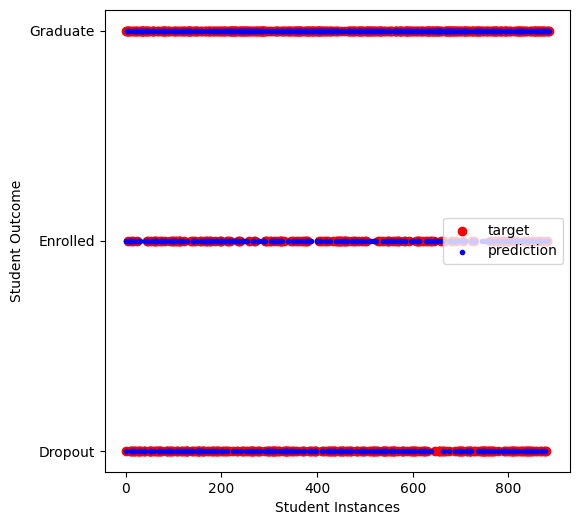

In [19]:
y_test_pred = gscv.predict(X_test)
eval_report_from_targets_and_predicted_targets(t_test, y_test_pred)
plot_test_accuracy(t_test.values.to_numpy(), y_test_pred)

## Artificial Neural Network

### Adjust Train/Validate & Test Datasets for Artificial Neural Network Training

In [20]:
X_train_and_validate_with_target = X_train_and_validate.copy()
X_train_and_validate_with_target[realinho_df.columns[-1]] = t_train_and_validate.values

X_test_with_target = X_test.copy()
X_test_with_target[realinho_df.columns[-1]] = t_test.values

### Perform K-Fold Cross-Validation Using Paper K-Fold Value & Hyperparameters

In [21]:
paper_hyper_parameters = {
    'activation_fn': nn.Sigmoid(), # Function used in Logistic Regression. Paper authors identify their activation function of choice with word "Logistic".
    'layers': [100, 100, 100], # Authors don't specify this. I chose 3 hidden layers with 100 neurons each to give the model enough capacity to learn the data without overfitting.
    'learning_rate': 0.1, # Authors don't specify this.
    'max_iterations': 200,
    'neurons_in_hidden_layer': 100,
    'opt_func': Adam,
    'regularization': 0,
}
print("Artificial Neural Network hyperparameters arbitrarily selected by paper authors: activation_fn={}, max_iterations={}, neurons_in_hidden_layer={}, regularization={}, opt_func={}".format(
    paper_hyper_parameters['activation_fn'],
    paper_hyper_parameters['max_iterations'],
    paper_hyper_parameters['neurons_in_hidden_layer'],
    paper_hyper_parameters['regularization'],
    paper_hyper_parameters['opt_func']))

print("k-fold value used by paper authors: {}".format(k_fold))

batch_size = 64 # Paper authors don't specify a batch size.

kf = KFold(n_splits=k_fold, shuffle=True, random_state=0)
my_cv_results = {
    'test_accuracy': np.array([]),
    'test_precision_weighted': np.array([]),
    'test_recall_weighted': np.array([]),
    'test_f1_weighted': np.array([])
}
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_and_validate_with_target)):
    # Create splits per fold
    splits = (list(train_idx), list(val_idx))
    
    tp = TabularPandas(
        # Providing a copy resolves this execution time warning:
        # "UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors."
        X_train_and_validate_with_target.copy(),
        procs=[Categorify, Normalize], 
        cat_names=X_train_and_validate.select_dtypes(include="object").columns.to_list(), 
        cont_names=X_train_and_validate.select_dtypes(exclude="object").columns.to_list(), 
        y_names=X_train_and_validate_with_target.columns[-1],
        splits=splits,  # Use the specific fold splits
    )
    
    dls = tp.dataloaders(bs=batch_size)
    learner = tabular_learner(dls,
                            config={'act_cls': paper_hyper_parameters['activation_fn']},
                            layers=paper_hyper_parameters['layers'],
                            metrics=[accuracy, Recall(average='weighted'),
                                       Precision(average='weighted'),
                                       F1Score(average='weighted')],
                            opt_func=paper_hyper_parameters['opt_func'],
                            wd=paper_hyper_parameters['regularization']
                            )
    learner.to(device)
    with learner.no_bar():
        learner.fit(paper_hyper_parameters['max_iterations'])
    
    validation_result = learner.validate()
    my_cv_results['test_accuracy'] = np.append(my_cv_results['test_accuracy'], validation_result[1])
    my_cv_results['test_precision_weighted'] = np.append(my_cv_results['test_precision_weighted'], validation_result[2])
    my_cv_results['test_recall_weighted'] = np.append(my_cv_results['test_recall_weighted'], validation_result[3])
    my_cv_results['test_f1_weighted'] = np.append(my_cv_results['test_f1_weighted'], validation_result[4])

eval_report_from_obj(my_cv_results)

Artificial Neural Network hyperparameters arbitrarily selected by paper authors: activation_fn=Sigmoid(), max_iterations=200, neurons_in_hidden_layer=100, regularization=0, opt_func=<function Adam at 0x752e9e5afba0>
k-fold value used by paper authors: 10


/home/raymond/src/itcs-5154-project/.venv/lib/python3.12/site-packages/fastai/torch_core.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  else as_tensor(x.values, **kwargs) if isinstance(x, (pd.Series, pd.DataFrame))


[0, 0.6594274640083313, 0.6142668724060059, 0.7683615684509277, 0.768361581920904, 0.7373138980921928, 0.7393814009468125, '00:00']
[1, 0.6419239044189453, 0.5802435874938965, 0.7598869800567627, 0.7598870056497176, 0.7420132212299624, 0.7475212819816541, '00:00']
[2, 0.6128926873207092, 0.5790532827377319, 0.7683615684509277, 0.768361581920904, 0.7474430056965061, 0.7523121161284091, '00:00']
[3, 0.6010846495628357, 0.6021385192871094, 0.7655367255210876, 0.7655367231638418, 0.7614770503432104, 0.7610146118197337, '00:00']
[4, 0.5978556275367737, 0.5931673049926758, 0.7768361568450928, 0.7768361581920904, 0.7616662599555044, 0.763423150201926, '00:00']
[5, 0.5948126912117004, 0.5958285331726074, 0.7853107452392578, 0.7853107344632768, 0.7725114932781838, 0.7703532481697986, '00:00']
[6, 0.5936341881752014, 0.6012662053108215, 0.7627118825912476, 0.7627118644067796, 0.7635532184092781, 0.7595558758592774, '00:00']
[7, 0.6122220754623413, 0.5948889851570129, 0.7457627058029175, 0.745762

[0, 0.6979455351829529, 0.6168704032897949, 0.7683615684509277, 0.768361581920904, 0.7520073155224154, 0.7471297295720412, '00:00']
[1, 0.6392850279808044, 0.5788872241973877, 0.7372881174087524, 0.7372881355932204, 0.7171099106643477, 0.7217581348246622, '00:00']
[2, 0.6157222986221313, 0.590246319770813, 0.7344632744789124, 0.7344632768361582, 0.7286559206627347, 0.7230548681500204, '00:00']
[3, 0.6256551742553711, 0.611320436000824, 0.7457627058029175, 0.7457627118644068, 0.7327052420272759, 0.7309558147492768, '00:00']
[4, 0.5948814749717712, 0.5775305032730103, 0.7542372941970825, 0.7542372881355932, 0.745128670764264, 0.7412317126895401, '00:00']
[5, 0.589651346206665, 0.5648472905158997, 0.7598869800567627, 0.7598870056497176, 0.7391920563197135, 0.7426069429282505, '00:00']
[6, 0.5960222482681274, 0.5699769258499146, 0.7627118825912476, 0.7627118644067796, 0.7385681575227162, 0.7408861221273298, '00:00']
[7, 0.6068699955940247, 0.5634380578994751, 0.7542372941970825, 0.75423728

[0, 0.6668872833251953, 0.62938392162323, 0.7429378628730774, 0.7429378531073446, 0.715463213753472, 0.7156171721166157, '00:00']
[1, 0.625694990158081, 0.6106494069099426, 0.7627118825912476, 0.7627118644067796, 0.7512084742643188, 0.7471485948492856, '00:00']
[2, 0.6049791574478149, 0.6435514688491821, 0.7429378628730774, 0.7429378531073446, 0.7165672828463526, 0.7184710743856166, '00:00']
[3, 0.5913627743721008, 0.6262693405151367, 0.7514124512672424, 0.751412429378531, 0.7299239180226652, 0.731362580409935, '00:00']
[4, 0.5939368009567261, 0.6260203719139099, 0.7401130199432373, 0.7401129943502824, 0.7222173133049509, 0.7215457711847033, '00:00']
[5, 0.6106403470039368, 0.6107479929924011, 0.7401130199432373, 0.7401129943502824, 0.7137069099566218, 0.7122310809897222, '00:00']
[6, 0.5962088704109192, 0.6071496605873108, 0.7514124512672424, 0.751412429378531, 0.7304803056287261, 0.7327209501109171, '00:00']
[7, 0.5967466235160828, 0.6089583039283752, 0.7457627058029175, 0.7457627118

[0, 0.6627901196479797, 0.6663621068000793, 0.694915235042572, 0.6949152542372882, 0.6872589099696977, 0.6845598656493292, '00:00']
[1, 0.6271288394927979, 0.674401044845581, 0.700564980506897, 0.7005649717514124, 0.7072814956591984, 0.6998027096738283, '00:00']
[2, 0.6038321852684021, 0.6683541536331177, 0.7033898234367371, 0.7033898305084746, 0.6972947862515185, 0.695045392661235, '00:00']
[3, 0.5900545716285706, 0.6480438709259033, 0.7288135886192322, 0.7288135593220338, 0.7262505994543333, 0.722535507442303, '00:00']
[4, 0.6015169024467468, 0.6467493176460266, 0.7062146663665771, 0.7062146892655368, 0.6888830374719097, 0.692412953921692, '00:00']
[5, 0.5934162139892578, 0.6538102030754089, 0.7175140976905823, 0.7175141242937854, 0.7254265730460739, 0.7127537002376224, '00:00']
[6, 0.5955087542533875, 0.6626466512680054, 0.7033898234367371, 0.7033898305084746, 0.6996103167240293, 0.6980944314392247, '00:00']
[7, 0.5942287445068359, 0.6374415159225464, 0.7175140976905823, 0.717514124

[0, 0.6818908452987671, 0.5861895084381104, 0.7570621371269226, 0.7570621468926554, 0.7320643228700604, 0.732820482951533, '00:00']
[1, 0.6336148381233215, 0.5294263362884521, 0.7683615684509277, 0.768361581920904, 0.751090713470508, 0.7435560603310785, '00:00']
[2, 0.6146957874298096, 0.5619257092475891, 0.7542372941970825, 0.7542372881355932, 0.7391892505036093, 0.726250658318229, '00:00']
[3, 0.6032754778862, 0.551308274269104, 0.7853107452392578, 0.7853107344632768, 0.7754426934203968, 0.765531972977049, '00:00']
[4, 0.5937352776527405, 0.5382751822471619, 0.7711864113807678, 0.7711864406779662, 0.7626769160096021, 0.75028817626288, '00:00']
[5, 0.5809274315834045, 0.5317035913467407, 0.7824859023094177, 0.7824858757062146, 0.7729616800089592, 0.765315110138067, '00:00']
[6, 0.5806275606155396, 0.5613150000572205, 0.7514124512672424, 0.751412429378531, 0.7244120102789043, 0.721600823754867, '00:00']
[7, 0.5943278670310974, 0.5542649030685425, 0.7711864113807678, 0.7711864406779662,

[0, 0.6729508638381958, 0.6604816913604736, 0.7316384315490723, 0.731638418079096, 0.6991571105697798, 0.7008335185380137, '00:00']
[1, 0.6295521259307861, 0.6076029539108276, 0.7655367255210876, 0.7655367231638418, 0.7476117668264001, 0.7481187642745522, '00:00']
[2, 0.6122992634773254, 0.6413114666938782, 0.7401130199432373, 0.7401129943502824, 0.7164407900636713, 0.7216308784885915, '00:00']
[3, 0.6125712394714355, 0.6018274426460266, 0.7542372941970825, 0.7542372881355932, 0.7244946083973045, 0.7326586208202444, '00:00']
[4, 0.6034477949142456, 0.6094885468482971, 0.7627118825912476, 0.7627118644067796, 0.7395846533203428, 0.7410513078580275, '00:00']
[5, 0.5897226333618164, 0.5871005654335022, 0.7570621371269226, 0.7570621468926554, 0.7212792641580904, 0.7270965500857643, '00:00']
[6, 0.605211615562439, 0.5816482901573181, 0.7768361568450928, 0.7768361581920904, 0.7594118277143828, 0.7601521508083013, '00:00']
[7, 0.5767139792442322, 0.5784624218940735, 0.7570621371269226, 0.75706

[0, 0.6670655608177185, 0.6500304341316223, 0.7542372941970825, 0.7542372881355932, 0.732592740283325, 0.7318913388904852, '00:00']
[1, 0.6197178363800049, 0.6259998679161072, 0.7485875487327576, 0.748587570621469, 0.7296890292880817, 0.7338354483479985, '00:00']
[2, 0.621139407157898, 0.6311237812042236, 0.7429378628730774, 0.7429378531073446, 0.7162474605382723, 0.722025230051742, '00:00']
[3, 0.6229329109191895, 0.6367260813713074, 0.7457627058029175, 0.7457627118644068, 0.7259964512292036, 0.729797703663204, '00:00']
[4, 0.5972351431846619, 0.6215669512748718, 0.7514124512672424, 0.751412429378531, 0.7266063592298053, 0.7332363585708812, '00:00']
[5, 0.5868497490882874, 0.620758593082428, 0.7457627058029175, 0.7457627118644068, 0.7197912098306805, 0.7274313072736615, '00:00']
[6, 0.5909398794174194, 0.6395507454872131, 0.7288135886192322, 0.7288135593220338, 0.7116791503934952, 0.7153385675924937, '00:00']
[7, 0.5695025324821472, 0.6241113543510437, 0.7457627058029175, 0.7457627118

[0, 0.6734164357185364, 0.5770482420921326, 0.7711864113807678, 0.7711864406779662, 0.752769766754976, 0.7506322132518, '00:00']
[1, 0.6403053998947144, 0.5546324849128723, 0.7796609997749329, 0.7796610169491526, 0.7599299193274198, 0.7542517341934408, '00:00']
[2, 0.6223641633987427, 0.5655136704444885, 0.7740113139152527, 0.7740112994350282, 0.7552353861949407, 0.7546773777407311, '00:00']
[3, 0.6095756888389587, 0.5648871064186096, 0.7881355881690979, 0.788135593220339, 0.7829016596354192, 0.7775320573036923, '00:00']
[4, 0.5993908047676086, 0.5704007744789124, 0.7740113139152527, 0.7740112994350282, 0.7559563633660422, 0.7501203114897536, '00:00']
[5, 0.6081388592720032, 0.5567507743835449, 0.7937853336334229, 0.7937853107344632, 0.7786821924164613, 0.7765181460096716, '00:00']
[6, 0.5898268818855286, 0.5534049868583679, 0.7768361568450928, 0.7768361581920904, 0.7644925982789328, 0.7580586409584517, '00:00']
[7, 0.5921885371208191, 0.5592905879020691, 0.7796609997749329, 0.77966101

[0, 0.6758710145950317, 0.6482058763504028, 0.7316384315490723, 0.731638418079096, 0.7029173972335867, 0.7079016283529076, '00:00']
[1, 0.6187556385993958, 0.62944495677948, 0.7655367255210876, 0.7655367231638418, 0.7588608795091547, 0.746914897687068, '00:00']
[2, 0.6178944110870361, 0.6250557899475098, 0.7542372941970825, 0.7542372881355932, 0.7323467485741535, 0.73291557228618, '00:00']
[3, 0.5983410477638245, 0.6440033316612244, 0.7344632744789124, 0.7344632768361582, 0.7167401155358337, 0.7203395794472685, '00:00']
[4, 0.595234215259552, 0.6422927975654602, 0.7401130199432373, 0.7401129943502824, 0.7331283505317127, 0.7247296557291766, '00:00']
[5, 0.5946332216262817, 0.626801073551178, 0.7485875487327576, 0.748587570621469, 0.7177822405405784, 0.718354636680939, '00:00']
[6, 0.603303849697113, 0.6202768683433533, 0.7429378628730774, 0.7429378531073446, 0.7267220279725469, 0.7284195573396562, '00:00']
[7, 0.5940217971801758, 0.6074730157852173, 0.7542372941970825, 0.75423728813559

[0, 0.6835273504257202, 0.6614902019500732, 0.7365438938140869, 0.7365439093484419, 0.7148436235956737, 0.7083811418848162, '00:00']
[1, 0.6280062198638916, 0.6342297196388245, 0.7393767833709717, 0.7393767705382436, 0.7179377737115601, 0.713947634373098, '00:00']
[2, 0.5943944454193115, 0.620533287525177, 0.7308781743049622, 0.7308781869688386, 0.7060491456998745, 0.7087362015063937, '00:00']
[3, 0.5957765579223633, 0.6259416937828064, 0.7478753328323364, 0.7478753541076487, 0.7443649800515919, 0.7197077437759095, '00:00']
[4, 0.6159738302230835, 0.6422761082649231, 0.7337110638618469, 0.7337110481586402, 0.7134521590655439, 0.7093642524774576, '00:00']
[5, 0.6039135456085205, 0.6103211045265198, 0.7507082223892212, 0.7507082152974505, 0.7389202768432017, 0.7219974826264235, '00:00']
[6, 0.5941726565361023, 0.6202436089515686, 0.7308781743049622, 0.7308781869688386, 0.7166030103199136, 0.714826662481885, '00:00']
[7, 0.5786106586456299, 0.6347983479499817, 0.7422096133232117, 0.742209

Evaluation Report
---
Validation Accuracy: 0.717 ± 0.022
Validation Precision: 0.717 ± 0.022
Validation Recall: 0.709 ± 0.026
Validation F1: 0.711 ± 0.025


### Test

In [22]:
print("The K-Fold cross validation results should indicate that the model is likely performant with the dataset.")
print("Therefore, train the model with all test and validate data.")
splits = None  # No split, all data for training.
tp = TabularPandas(
    # Providing a copy resolves this execution time warning:
    # "UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors."
    X_train_and_validate_with_target.copy(), 
    procs=[Categorify, Normalize], 
    cat_names=X_train_and_validate.select_dtypes(include="object").columns.to_list(), 
    cont_names=X_train_and_validate.select_dtypes(exclude="object").columns.to_list(), 
    y_names=X_train_and_validate_with_target.columns[-1],
    splits=splits,
)
dls = tp.dataloaders(bs=batch_size)
learner = tabular_learner(dls,
                            config={'act_cls': paper_hyper_parameters['activation_fn']},
                            layers=paper_hyper_parameters['layers'],
                            metrics=[accuracy, Recall(average='weighted'),
                                       Precision(average='weighted'),
                                       F1Score(average='weighted')],
                            opt_func=paper_hyper_parameters['opt_func'],
                            wd=paper_hyper_parameters['regularization']
                        )
learner.to(device)
with learner.no_bar():                        
    learner.fit(paper_hyper_parameters['max_iterations'], lr=paper_hyper_parameters['learning_rate']) 

The K-Fold cross validation results should indicate that the model is likely performant with the dataset.
Therefore, train the model with all test and validate data.
[0, 0.9716981053352356, None, None, None, None, None, '00:00']
[1, 0.7852107882499695, None, None, None, None, None, '00:00']
[2, 0.7360484004020691, None, None, None, None, None, '00:00']
[3, 0.7436487078666687, None, None, None, None, None, '00:00']
[4, 0.7642607688903809, None, None, None, None, None, '00:00']
[5, 0.7638707160949707, None, None, None, None, None, '00:00']
[6, 0.765438973903656, None, None, None, None, None, '00:00']
[7, 0.7682803273200989, None, None, None, None, None, '00:00']
[8, 0.8001526594161987, None, None, None, None, None, '00:00']
[9, 0.8132418990135193, None, None, None, None, None, '00:00']
[10, 0.7594315409660339, None, None, None, None, None, '00:00']
[11, 0.7717980742454529, None, None, None, None, None, '00:00']
[12, 0.9150825142860413, None, None, None, None, None, '00:00']
[13, 0.993472

#### My Results

/home/raymond/src/itcs-5154-project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Evaluation Report
---
Accuracy: 0.506
Precision: 0.322
Recall: 0.506
F1: 0.344


/home/raymond/src/itcs-5154-project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


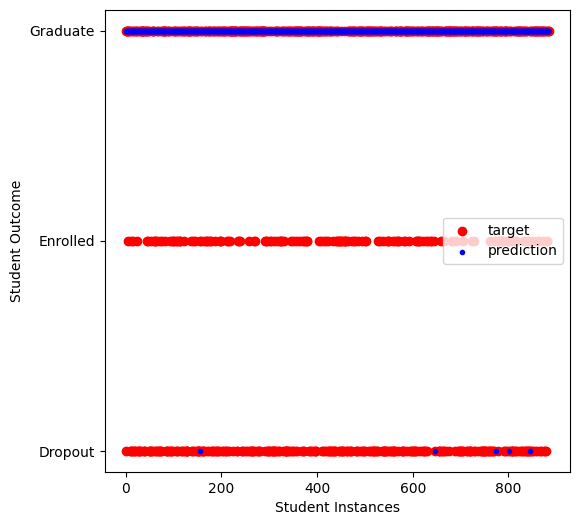

In [23]:
_, targets, predicted_targets = learner.get_preds(dl=dls.test_dl(X_test_with_target), with_decoded=True)
targets = targets.numpy().flatten()
predicted_targets = predicted_targets.numpy()
eval_report_from_targets_and_predicted_targets(targets, predicted_targets)
plot_test_accuracy(targets, predicted_targets, dls.vocab)

#### Paper Results

In [26]:
paper_test_results = {
    "test_accuracy": np.array([0.773]),
    "test_precision_weighted": np.array([0.76]),
    "test_recall_weighted": np.array([0.773]),
    "test_f1_weighted": np.array([0.762])
}
eval_report_from_obj(paper_test_results)

Evaluation Report
---
Validation Accuracy: 0.773 ± 0.000
Validation Precision: 0.760 ± 0.000
Validation Recall: 0.773 ± 0.000
Validation F1: 0.762 ± 0.000


## Attempt to Improve Test Results with Hyperparameter Search

In [28]:
my_hyper_parameter_options = {
    'activation_fn': [nn.Sigmoid(), nn.ReLU(), nn.Tanh()],
    'layers': [[50, 50, 50], [100, 100, 100], [150, 150, 150]],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_iterations': [100, 150, 200],
    'opt_func': [Adam, SGD],
    'regularization': [0, 0.01, 0.1],
}

splitter = RandomSplitter(valid_pct=0.1, seed=1)
splits = splitter(X_train_and_validate_with_target)
tp = TabularPandas(
    X_train_and_validate_with_target, 
    procs=[Categorify, Normalize], 
    cat_names=X_train_and_validate.select_dtypes(include="object").columns.to_list(), 
    cont_names=X_train_and_validate.select_dtypes(exclude="object").columns.to_list(), 
    y_names=X_train_and_validate_with_target.columns[-1],
    splits=splits
)
dls = tp.dataloaders(bs=batch_size)

best_accuracy_score = 0
best_found_hyper_parameters = {}

for activation_fn, layers, max_iterations, opt_func, regularization, lr in product(my_hyper_parameter_options['activation_fn'],
                                                                                   my_hyper_parameter_options['layers'],
                                                                                   my_hyper_parameter_options['max_iterations'],
                                                                                   my_hyper_parameter_options['opt_func'],
                                                                                   my_hyper_parameter_options['regularization'],
                                                                                   my_hyper_parameter_options['learning_rate']):
    learner = tabular_learner(dls,
                              config={'act_cls': activation_fn},
                              layers=layers,
                              metrics=accuracy,
                              opt_func=opt_func,
                              wd=regularization
                              )
    learner.to(device)
    with learner.no_bar():
        learner.fit(max_iterations, lr=lr)
    
    val_loss, *val_metrics = learner.validate()
    current_accuracy_score = val_metrics[0]  # Use accuracy as the score
    
    if current_accuracy_score > best_accuracy_score:
        best_accuracy_score = current_accuracy_score
        best_found_hyper_parameters = {'activation_fn': activation_fn,
                                       'layers': layers,
                                       'max_iterations': max_iterations,
                                       'opt_func': opt_func,
                                       'regularization': regularization,
                                       'learning_rate': lr}
print(f"Search Found these Best Hyperparameters: {best_found_hyper_parameters}")

[0, 0.7644575238227844, 0.6973602175712585, 0.7308781743049622, '00:00']
[1, 0.669651448726654, 0.6119490265846252, 0.7535410523414612, '00:00']
[2, 0.6451568007469177, 0.7036452293395996, 0.7337110638618469, '00:00']
[3, 0.6462397575378418, 0.6904977560043335, 0.7365438938140869, '00:00']
[4, 0.6335223317146301, 0.622286856174469, 0.7337110638618469, '00:00']
[5, 0.631601870059967, 0.6524674892425537, 0.7450425028800964, '00:00']
[6, 0.6458786725997925, 0.619746208190918, 0.7620396614074707, '00:00']
[7, 0.6417205333709717, 0.6500872373580933, 0.7507082223892212, '00:00']
[8, 0.6468744277954102, 0.6552718281745911, 0.7337110638618469, '00:00']
[9, 0.6465412974357605, 0.6276083588600159, 0.756373941898346, '00:00']
[10, 0.6249678134918213, 0.6271014213562012, 0.756373941898346, '00:00']
[11, 0.6324477791786194, 0.6182268857955933, 0.7592067718505859, '00:00']
[12, 0.6308221220970154, 0.6168350577354431, 0.7478753328323364, '00:00']
[13, 0.6446506381034851, 0.6665449142456055, 0.7478753

[0, 0.8832877278327942, 0.7317750453948975, 0.7195467352867126, '00:00']
[1, 0.7211899757385254, 0.7338894009590149, 0.6968838572502136, '00:00']
[2, 0.7132094502449036, 0.6832200884819031, 0.7223796248435974, '00:00']
[3, 0.6786583662033081, 0.6200771331787109, 0.7648725509643555, '00:00']
[4, 0.6870743632316589, 0.7029596567153931, 0.7450425028800964, '00:00']
[5, 0.7016257047653198, 0.6552677750587463, 0.7592067718505859, '00:00']
[6, 0.7222566604614258, 0.7981255054473877, 0.6827195286750793, '00:00']
[7, 0.7162116169929504, 0.6497049927711487, 0.7422096133232117, '00:00']
[8, 0.7412557005882263, 0.7452130913734436, 0.6742209792137146, '00:00']
[9, 0.7567680478096008, 0.703778088092804, 0.7478753328323364, '00:00']
[10, 0.7477538585662842, 0.8144649863243103, 0.6940509676933289, '00:00']
[11, 0.7311378717422485, 0.6557937264442444, 0.7337110638618469, '00:00']
[12, 0.7306148409843445, 0.6868401765823364, 0.7535410523414612, '00:00']
[13, 0.7446680068969727, 0.7825701236724854, 0.72

[0, 1.290697455406189, 0.7521609663963318, 0.7195467352867126, '00:00']
[1, 0.9447238445281982, 0.7963830828666687, 0.645892322063446, '00:00']
[2, 0.8324335217475891, 0.6980944275856018, 0.7110481858253479, '00:00']
[3, 0.806686520576477, 0.7413330078125, 0.7138810157775879, '00:00']
[4, 0.8253637552261353, 0.8265607357025146, 0.7025495767593384, '00:00']
[5, 0.8342885375022888, 1.1933318376541138, 0.5722379684448242, '00:00']
[6, 0.8591979146003723, 1.1613832712173462, 0.6742209792137146, '00:00']
[7, 0.8855165839195251, 0.9238175749778748, 0.46742209792137146, '00:00']
[8, 0.8751156330108643, 1.2842421531677246, 0.7025495767593384, '00:00']
[9, 0.840484619140625, 1.8458467721939087, 0.7025495767593384, '00:00']
[10, 0.8502745628356934, 1.045766830444336, 0.6345608830451965, '00:00']
[11, 0.837860107421875, 1.0469489097595215, 0.6855524182319641, '00:00']
[12, 0.8504186272621155, 1.3281821012496948, 0.7082152962684631, '00:00']
[13, 0.836386501789093, 1.0122449398040771, 0.6912181377

[0, 0.7188620567321777, 0.6636102795600891, 0.7365438938140869, '00:00']
[1, 0.6704744696617126, 0.6745719313621521, 0.7365438938140869, '00:00']
[2, 0.6563162207603455, 0.7127319574356079, 0.7167139053344727, '00:00']
[3, 0.6546385884284973, 0.6408606171607971, 0.7592067718505859, '00:00']
[4, 0.6547555923461914, 0.7012184858322144, 0.7138810157775879, '00:00']
[5, 0.6377503275871277, 0.6094570159912109, 0.7450425028800964, '00:00']
[6, 0.6463946104049683, 0.6083241105079651, 0.7592067718505859, '00:00']
[7, 0.6622692346572876, 0.6232050657272339, 0.7365438938140869, '00:00']
[8, 0.6430202126502991, 0.6860482692718506, 0.7422096133232117, '00:00']
[9, 0.6601766347885132, 0.7041672468185425, 0.7422096133232117, '00:00']
[10, 0.63775235414505, 0.6308495402336121, 0.7422096133232117, '00:00']
[11, 0.6625069975852966, 0.6515589356422424, 0.7337110638618469, '00:00']
[12, 0.6704985499382019, 0.8564907908439636, 0.7138810157775879, '00:00']
[13, 0.6789517402648926, 0.6458526849746704, 0.742

[0, 0.8443108201026917, 0.7328665256500244, 0.7195467352867126, '00:00']
[1, 0.7373916506767273, 0.6478522419929504, 0.7592067718505859, '00:00']
[2, 0.6943459510803223, 0.6780121326446533, 0.7138810157775879, '00:00']
[3, 0.6910243630409241, 0.6864772439002991, 0.756373941898346, '00:00']
[4, 0.7038394212722778, 0.6474780440330505, 0.7535410523414612, '00:00']
[5, 0.7257212996482849, 0.8608912825584412, 0.6402266025543213, '00:00']
[6, 0.7522566318511963, 0.7051052451133728, 0.7195467352867126, '00:00']
[7, 0.7745281457901001, 0.8218058943748474, 0.7337110638618469, '00:00']
[8, 0.793127179145813, 0.852363109588623, 0.6657223701477051, '00:00']
[9, 0.8103156089782715, 0.9336751699447632, 0.5609065294265747, '00:00']
[10, 0.8359254002571106, 0.7834223508834839, 0.7308781743049622, '00:00']
[11, 0.8386208415031433, 1.0729856491088867, 0.6373937726020813, '00:00']
[12, 0.8261699080467224, 0.9523501396179199, 0.6628895401954651, '00:00']
[13, 0.841728687286377, 0.8074000477790833, 0.71954

[0, 0.9800312519073486, 0.7805789709091187, 0.7053824067115784, '00:00']
[1, 0.8419513702392578, 1.3162652254104614, 0.55524080991745, '00:00']
[2, 0.8220645785331726, 0.7445818781852722, 0.7110481858253479, '00:00']
[3, 0.8503926992416382, 0.9095077514648438, 0.6713880896568298, '00:00']
[4, 0.8794996738433838, 1.4762102365493774, 0.6940509676933289, '00:00']
[5, 0.900915801525116, 0.9048157334327698, 0.6600566506385803, '00:00']
[6, 0.8905007243156433, 0.8411355018615723, 0.6770538091659546, '00:00']
[7, 0.8960493206977844, 0.9530428647994995, 0.6770538091659546, '00:00']
[8, 0.9092432260513306, 1.030479907989502, 0.7167139053344727, '00:00']
[9, 0.8758038282394409, 1.028477430343628, 0.6798866987228394, '00:00']
[10, 0.8811827898025513, 0.9138374924659729, 0.7053824067115784, '00:00']
[11, 0.894209086894989, 0.885620653629303, 0.6968838572502136, '00:00']
[12, 0.9821062088012695, 1.167287826538086, 0.300283282995224, '00:00']
[13, 1.0166295766830444, 1.3610215187072754, 0.5155807137

[0, 0.7793160676956177, 0.6868476271629333, 0.7308781743049622, '00:00']
[1, 0.6902610659599304, 0.6083588600158691, 0.7507082223892212, '00:00']
[2, 0.6505779027938843, 0.6097051501274109, 0.7592067718505859, '00:00']
[3, 0.6513206362724304, 0.6527963280677795, 0.7478753328323364, '00:00']
[4, 0.637499988079071, 0.8479142189025879, 0.6657223701477051, '00:00']
[5, 0.6576465368270874, 0.6543893218040466, 0.7195467352867126, '00:00']
[6, 0.6553933620452881, 0.6914768218994141, 0.7308781743049622, '00:00']
[7, 0.6358988881111145, 0.7648764252662659, 0.7478753328323364, '00:00']
[8, 0.6315468549728394, 0.6636853814125061, 0.7620396614074707, '00:00']
[9, 0.6319631934165955, 0.67571622133255, 0.6940509676933289, '00:00']
[10, 0.6424675583839417, 0.6608582139015198, 0.7422096133232117, '00:00']
[11, 0.6424858570098877, 0.6885116100311279, 0.7308781743049622, '00:00']
[12, 0.6493295431137085, 0.7181931138038635, 0.7308781743049622, '00:00']
[13, 0.6608339548110962, 0.6777542233467102, 0.7252

[0, 0.887279748916626, 0.7049421668052673, 0.7138810157775879, '00:00']
[1, 0.7062036991119385, 0.6646479368209839, 0.7422096133232117, '00:00']
[2, 0.6633549928665161, 0.7203029990196228, 0.7478753328323364, '00:00']
[3, 0.6497291922569275, 0.6948145627975464, 0.7365438938140869, '00:00']
[4, 0.6753005981445312, 0.7178235650062561, 0.7110481858253479, '00:00']
[5, 0.6876920461654663, 1.798362374305725, 0.5864022374153137, '00:00']
[6, 0.6878670454025269, 0.7203685641288757, 0.7280453443527222, '00:00']
[7, 0.7050607204437256, 0.7639374732971191, 0.6997166872024536, '00:00']
[8, 0.7261103391647339, 0.8515555262565613, 0.5609065294265747, '00:00']
[9, 0.7676659822463989, 0.9648257493972778, 0.6968838572502136, '00:00']
[10, 0.7591580748558044, 0.8450292944908142, 0.7337110638618469, '00:00']
[11, 0.7604414224624634, 0.8285553455352783, 0.7223796248435974, '00:00']
[12, 0.73724365234375, 0.7694577574729919, 0.623229444026947, '00:00']
[13, 0.7163190245628357, 0.8044958114624023, 0.739376

[0, 1.0550638437271118, 0.9046741724014282, 0.6600566506385803, '00:00']
[1, 0.84514319896698, 2.574411392211914, 0.3031161427497864, '00:00']
[2, 0.7875875234603882, 3.0180063247680664, 0.623229444026947, '00:00']
[3, 0.7686180472373962, 15.289130210876465, 0.34560906887054443, '00:00']
[4, 0.7786999940872192, 1.2828972339630127, 0.49575069546699524, '00:00']
[5, 0.8336820006370544, 1.0348587036132812, 0.4617563784122467, '00:00']
[6, 0.8451977968215942, 0.7852146029472351, 0.7053824067115784, '00:00']
[7, 0.8018458485603333, 1.1110152006149292, 0.6912181377410889, '00:00']
[8, 0.8441046476364136, 2.2113215923309326, 0.3342776298522949, '00:00']
[9, 0.9533696174621582, 7.343491554260254, 0.3031161427497864, '00:00']
[10, 1.0213415622711182, 66.1811294555664, 0.5155807137489319, '00:00']
[11, 1.0496342182159424, 107.16973114013672, 0.5637393593788147, '00:00']
[12, 1.042678952217102, 145.6847686767578, 0.7195467352867126, '00:00']
[13, 1.0559052228927612, 1020.7548828125, 0.51841360330

[0, 0.681098997592926, 0.6138187646865845, 0.7818697094917297, '00:00']
[1, 0.6424625515937805, 0.569597601890564, 0.7592067718505859, '00:00']
[2, 0.6184284687042236, 0.5600297451019287, 0.7478753328323364, '00:00']
[3, 0.5965620875358582, 0.5919849276542664, 0.7365438938140869, '00:00']
[4, 0.5930920839309692, 0.5767098069190979, 0.7620396614074707, '00:00']
[5, 0.610939621925354, 0.5685169100761414, 0.7620396614074707, '00:00']
[6, 0.600223958492279, 0.5860536694526672, 0.7478753328323364, '00:00']
[7, 0.609832227230072, 0.5553675293922424, 0.779036819934845, '00:00']
[8, 0.6145667433738708, 0.5632103681564331, 0.7450425028800964, '00:00']
[9, 0.596059262752533, 0.5970087051391602, 0.7337110638618469, '00:00']
[10, 0.5793259143829346, 0.5845469832420349, 0.7620396614074707, '00:00']
[11, 0.5791844725608826, 0.587321400642395, 0.7422096133232117, '00:00']
[12, 0.5893270969390869, 0.589357316493988, 0.7478753328323364, '00:00']
[13, 0.5742508769035339, 0.5824398398399353, 0.7478753328

[0, 0.6711700558662415, 0.6087667346000671, 0.7337110638618469, '00:00']
[1, 0.6439025402069092, 0.6241878867149353, 0.7507082223892212, '00:00']
[2, 0.6242569088935852, 0.5897660851478577, 0.7450425028800964, '00:00']
[3, 0.5903972387313843, 0.5623202323913574, 0.7422096133232117, '00:00']
[4, 0.595524251461029, 0.5834776163101196, 0.7308781743049622, '00:00']
[5, 0.6082437634468079, 0.5900413990020752, 0.7450425028800964, '00:00']
[6, 0.5966631770133972, 0.5624175071716309, 0.7648725509643555, '00:00']
[7, 0.5880701541900635, 0.5598297715187073, 0.7592067718505859, '00:00']
[8, 0.6032698154449463, 0.5755988955497742, 0.7450425028800964, '00:00']
[9, 0.5941592454910278, 0.5641651749610901, 0.7507082223892212, '00:00']
[10, 0.5826192498207092, 0.5799283385276794, 0.7478753328323364, '00:00']
[11, 0.603201687335968, 0.596708357334137, 0.7478753328323364, '00:00']
[12, 0.5942433476448059, 0.6039226055145264, 0.7223796248435974, '00:00']
[13, 0.6046966910362244, 0.61509108543396, 0.728045

[0, 0.6803896427154541, 0.5947130918502808, 0.7535410523414612, '00:00']
[1, 0.6430873274803162, 0.5929079055786133, 0.7478753328323364, '00:00']
[2, 0.6325958371162415, 0.6234262585639954, 0.7195467352867126, '00:00']
[3, 0.6260874271392822, 0.5849355459213257, 0.7507082223892212, '00:00']
[4, 0.6218959093093872, 0.6082237362861633, 0.7308781743049622, '00:00']
[5, 0.5965031385421753, 0.5764948129653931, 0.7422096133232117, '00:00']
[6, 0.5969951748847961, 0.5976126194000244, 0.7337110638618469, '00:00']
[7, 0.5855768322944641, 0.5741589069366455, 0.7620396614074707, '00:00']
[8, 0.5871867537498474, 0.5740684270858765, 0.756373941898346, '00:00']
[9, 0.5900260210037231, 0.6302266120910645, 0.7478753328323364, '00:00']
[10, 0.5898836851119995, 0.5935852527618408, 0.756373941898346, '00:00']
[11, 0.6057778000831604, 0.5935787558555603, 0.7393767833709717, '00:00']
[12, 0.6111775636672974, 0.5681384801864624, 0.7422096133232117, '00:00']
[13, 0.6139523386955261, 0.585502564907074, 0.7478

[0, 0.6832631230354309, 0.609660267829895, 0.7620396614074707, '00:00']
[1, 0.6240342259407043, 0.5562725067138672, 0.7393767833709717, '00:00']
[2, 0.6074222326278687, 0.5650052428245544, 0.7535410523414612, '00:00']
[3, 0.614948570728302, 0.5668233036994934, 0.7507082223892212, '00:00']
[4, 0.6109755635261536, 0.5559882521629333, 0.7535410523414612, '00:00']
[5, 0.608684241771698, 0.5718206167221069, 0.756373941898346, '00:00']
[6, 0.6079859137535095, 0.5514017343521118, 0.756373941898346, '00:00']
[7, 0.602107584476471, 0.5658815503120422, 0.7337110638618469, '00:00']
[8, 0.6126347780227661, 0.5727145075798035, 0.756373941898346, '00:00']
[9, 0.6024449467658997, 0.5577555894851685, 0.7478753328323364, '00:00']
[10, 0.5986891984939575, 0.5782811641693115, 0.7422096133232117, '00:00']
[11, 0.5816593766212463, 0.5516512989997864, 0.7478753328323364, '00:00']
[12, 0.5975772738456726, 0.5769475698471069, 0.7592067718505859, '00:00']
[13, 0.5962971448898315, 0.5698686838150024, 0.74787533

[0, 0.6600083708763123, 0.6378058195114136, 0.7535410523414612, '00:00']
[1, 0.6293067336082458, 0.5781210064888, 0.7705382704734802, '00:00']
[2, 0.6066579818725586, 0.5694997906684875, 0.7337110638618469, '00:00']
[3, 0.6134427785873413, 0.5765446424484253, 0.7308781743049622, '00:00']
[4, 0.6200932860374451, 0.6113861203193665, 0.7450425028800964, '00:00']
[5, 0.6218701004981995, 0.5950740575790405, 0.7393767833709717, '00:00']
[6, 0.5942603945732117, 0.5813130736351013, 0.7337110638618469, '00:00']
[7, 0.5858515501022339, 0.5952817797660828, 0.7478753328323364, '00:00']
[8, 0.5885199308395386, 0.6203979253768921, 0.7393767833709717, '00:00']
[9, 0.5873979330062866, 0.5855187177658081, 0.7450425028800964, '00:00']
[10, 0.589235782623291, 0.573586106300354, 0.7450425028800964, '00:00']
[11, 0.6039400100708008, 0.5783979892730713, 0.7620396614074707, '00:00']
[12, 0.5952971577644348, 0.5774723887443542, 0.7705382704734802, '00:00']
[13, 0.5993756055831909, 0.5716989040374756, 0.753541

[0, 0.647450864315033, 0.5911749601364136, 0.7450425028800964, '00:00']
[1, 0.6427528858184814, 0.5825167298316956, 0.7365438938140869, '00:00']
[2, 0.6340876817703247, 0.5675438046455383, 0.7535410523414612, '00:00']
[3, 0.6169152855873108, 0.5843104720115662, 0.756373941898346, '00:00']
[4, 0.5988367795944214, 0.6016426682472229, 0.7507082223892212, '00:00']
[5, 0.5984207987785339, 0.6080849170684814, 0.7478753328323364, '00:00']
[6, 0.5960844159126282, 0.6139582991600037, 0.7535410523414612, '00:00']
[7, 0.6205334067344666, 0.5855942368507385, 0.7507082223892212, '00:00']
[8, 0.6228364109992981, 0.5838112831115723, 0.7535410523414612, '00:00']
[9, 0.6218312978744507, 0.5923573970794678, 0.7478753328323364, '00:00']
[10, 0.6325048208236694, 0.589539110660553, 0.7535410523414612, '00:00']
[11, 0.629033088684082, 0.6263101696968079, 0.7648725509643555, '00:00']
[12, 0.61224365234375, 0.5978806614875793, 0.7478753328323364, '00:00']
[13, 0.6136437058448792, 0.6302398443222046, 0.7478753

[0, 0.6813111901283264, 0.6580877304077148, 0.7535410523414612, '00:00']
[1, 0.6149126887321472, 0.5777425765991211, 0.7507082223892212, '00:00']
[2, 0.6159005761146545, 0.5959267616271973, 0.7620396614074707, '00:00']
[3, 0.6212052702903748, 0.5801903605461121, 0.7592067718505859, '00:00']
[4, 0.6374763250350952, 0.6064867973327637, 0.7365438938140869, '00:00']
[5, 0.6332650184631348, 0.5934038162231445, 0.7478753328323364, '00:00']
[6, 0.6154110431671143, 0.5987045168876648, 0.7507082223892212, '00:00']
[7, 0.6328440308570862, 0.6123300790786743, 0.7365438938140869, '00:00']
[8, 0.6474071145057678, 0.5861069560050964, 0.7620396614074707, '00:00']
[9, 0.6153234243392944, 0.5655517578125, 0.7677053809165955, '00:00']
[10, 0.6189345717430115, 0.6279919147491455, 0.7252124547958374, '00:00']
[11, 0.6279867887496948, 0.5691804885864258, 0.7677053809165955, '00:00']
[12, 0.598926305770874, 0.6043729782104492, 0.756373941898346, '00:00']
[13, 0.6161664128303528, 0.6136782169342041, 0.742209

[0, 0.6869609951972961, 0.7094692587852478, 0.7478753328323364, '00:00']
[1, 0.6499239206314087, 0.5827117562294006, 0.7705382704734802, '00:00']
[2, 0.6441658139228821, 0.5659556984901428, 0.756373941898346, '00:00']
[3, 0.6230915784835815, 0.6095755100250244, 0.7365438938140869, '00:00']
[4, 0.6417075991630554, 0.6110038161277771, 0.7535410523414612, '00:00']
[5, 0.6321191191673279, 0.6259052157402039, 0.7620396614074707, '00:00']
[6, 0.6348371505737305, 0.5941838026046753, 0.7535410523414612, '00:00']
[7, 0.6407600045204163, 0.6002410650253296, 0.7535410523414612, '00:00']
[8, 0.6548579931259155, 0.6731119751930237, 0.7535410523414612, '00:00']
[9, 0.6212720274925232, 0.6815738677978516, 0.7167139053344727, '00:00']
[10, 0.6272788047790527, 0.5914655327796936, 0.7478753328323364, '00:00']
[11, 0.6268108487129211, 0.6651438474655151, 0.7450425028800964, '00:00']
[12, 0.6338747143745422, 0.6494548916816711, 0.7422096133232117, '00:00']
[13, 0.620347261428833, 0.6001337766647339, 0.759

[0, 0.6972643136978149, 0.7048055529594421, 0.7535410523414612, '00:00']
[1, 0.6761126518249512, 0.62727290391922, 0.7507082223892212, '00:00']
[2, 0.6882197856903076, 0.6419685482978821, 0.7450425028800964, '00:00']
[3, 0.6754424571990967, 0.7315932512283325, 0.7393767833709717, '00:00']
[4, 0.6473536491394043, 0.6971001029014587, 0.7167139053344727, '00:00']
[5, 0.6421954035758972, 0.5920091867446899, 0.7507082223892212, '00:00']
[6, 0.6588570475578308, 0.6509581208229065, 0.7393767833709717, '00:00']
[7, 0.6476579904556274, 0.9413629174232483, 0.7195467352867126, '00:00']
[8, 0.654447078704834, 0.7796068787574768, 0.7450425028800964, '00:00']
[9, 0.6608436703681946, 0.6463935971260071, 0.7450425028800964, '00:00']
[10, 0.6408235430717468, 0.676751434803009, 0.7422096133232117, '00:00']
[11, 0.6634737253189087, 0.6836231350898743, 0.7535410523414612, '00:00']
[12, 0.6653021574020386, 0.603967010974884, 0.7507082223892212, '00:00']
[13, 0.6601679921150208, 0.7214239835739136, 0.759206

[0, 0.7016960382461548, 0.6634774208068848, 0.756373941898346, '00:00']
[1, 0.6608161330223083, 0.6860155463218689, 0.7308781743049622, '00:00']
[2, 0.6298204064369202, 0.6930286884307861, 0.7167139053344727, '00:00']
[3, 0.6567702889442444, 0.6586837768554688, 0.6940509676933289, '00:00']
[4, 0.6391463279724121, 0.718708872795105, 0.7365438938140869, '00:00']
[5, 0.6210653781890869, 0.8243598341941833, 0.7110481858253479, '00:00']
[6, 0.6362685561180115, 0.6331331133842468, 0.7422096133232117, '00:00']
[7, 0.6377537846565247, 0.7101693153381348, 0.7223796248435974, '00:00']
[8, 0.6515792012214661, 0.6821340322494507, 0.7167139053344727, '00:00']
[9, 0.6410664319992065, 0.6795804500579834, 0.7507082223892212, '00:00']
[10, 0.6439209580421448, 0.6175031661987305, 0.7082152962684631, '00:00']
[11, 0.6621294021606445, 0.6428263187408447, 0.756373941898346, '00:00']
[12, 0.6546894311904907, 0.641351044178009, 0.7308781743049622, '00:00']
[13, 0.6439500451087952, 0.697348952293396, 0.756373

[0, 0.8466356992721558, 0.5842212438583374, 0.7592067718505859, '00:00']
[1, 0.7482928037643433, 0.7270089387893677, 0.6175637245178223, '00:00']
[2, 0.7219275832176208, 0.763308584690094, 0.7337110638618469, '00:00']
[3, 0.7041786313056946, 0.9816980957984924, 0.7025495767593384, '00:00']
[4, 0.7066671252250671, 0.6942142844200134, 0.756373941898346, '00:00']
[5, 0.718263566493988, 0.7332623600959778, 0.7082152962684631, '00:00']
[6, 0.6999415159225464, 0.7610020041465759, 0.6883852481842041, '00:00']
[7, 0.7409124970436096, 0.7344570159912109, 0.7337110638618469, '00:00']
[8, 0.7894096970558167, 1.147829532623291, 0.49291783571243286, '00:00']
[9, 0.7993093729019165, 0.7617365717887878, 0.7167139053344727, '00:00']
[10, 0.760343074798584, 1.817056655883789, 0.7365438938140869, '00:00']
[11, 0.7675411105155945, 1.221834659576416, 0.3739376664161682, '00:00']
[12, 0.7678967118263245, 1.731432557106018, 0.6940509676933289, '00:00']
[13, 0.7824483513832092, 1.4143290519714355, 0.71104818

[0, 1.2498985528945923, 1.009053111076355, 0.5212464332580566, '00:00']
[1, 1.0951728820800781, 1.0525853633880615, 0.3031161427497864, '00:00']
[2, 1.051792025566101, 1.0317169427871704, 0.5155807137489319, '00:00']
[3, 1.0470764636993408, 1.039758324623108, 0.5155807137489319, '00:00']
[4, 1.0353151559829712, 1.0138192176818848, 0.5155807137489319, '00:00']
[5, 1.0384196043014526, 1.0190911293029785, 0.5155807137489319, '00:00']
[6, 1.0565260648727417, 1.1865050792694092, 0.18130311369895935, '00:00']
[7, 1.0573700666427612, 1.0887179374694824, 0.3031161427497864, '00:00']
[8, 1.0535253286361694, 1.0334068536758423, 0.5155807137489319, '00:00']
[9, 1.0504878759384155, 1.0236128568649292, 0.5155807137489319, '00:00']
[10, 1.0686149597167969, 1.0785861015319824, 0.5155807137489319, '00:00']
[11, 1.0724042654037476, 1.0225671529769897, 0.5155807137489319, '00:00']
[12, 1.0581884384155273, 1.0253084897994995, 0.5155807137489319, '00:00']
[13, 1.0499414205551147, 1.0445573329925537, 0.515

[0, 0.7199049592018127, 0.6317510604858398, 0.7450425028800964, '00:00']
[1, 0.676822304725647, 0.7044190764427185, 0.756373941898346, '00:00']
[2, 0.6698126792907715, 0.6306610703468323, 0.7478753328323364, '00:00']
[3, 0.644309401512146, 0.619349479675293, 0.7507082223892212, '00:00']
[4, 0.6268975734710693, 0.6193320155143738, 0.7535410523414612, '00:00']
[5, 0.6435196399688721, 0.6990054845809937, 0.7223796248435974, '00:00']
[6, 0.6464789509773254, 0.6792715787887573, 0.7337110638618469, '00:00']
[7, 0.6428399682044983, 0.6546773314476013, 0.7450425028800964, '00:00']
[8, 0.6508520841598511, 0.6814941167831421, 0.7450425028800964, '00:00']
[9, 0.6564585566520691, 0.6951393485069275, 0.7223796248435974, '00:00']
[10, 0.632950484752655, 0.6404770612716675, 0.7280453443527222, '00:00']
[11, 0.6571472883224487, 0.6416701674461365, 0.7450425028800964, '00:00']
[12, 0.6565397381782532, 0.6489730477333069, 0.7507082223892212, '00:00']
[13, 0.6696718335151672, 0.6448613405227661, 0.730878

[0, 0.7639342546463013, 0.795276403427124, 0.6713880896568298, '00:00']
[1, 0.7117704153060913, 0.673381507396698, 0.7337110638618469, '00:00']
[2, 0.6908355355262756, 0.6841711401939392, 0.7308781743049622, '00:00']
[3, 0.694587230682373, 0.9458736777305603, 0.6770538091659546, '00:00']
[4, 0.7090238332748413, 0.7316180467605591, 0.7110481858253479, '00:00']
[5, 0.7142840623855591, 0.9888488054275513, 0.6940509676933289, '00:00']
[6, 0.7650142312049866, 1.1185970306396484, 0.6912181377410889, '00:00']
[7, 0.8298268914222717, 1.322818398475647, 0.6770538091659546, '00:00']
[8, 0.7902323007583618, 2.8349251747131348, 0.7280453443527222, '00:00']
[9, 0.7537505626678467, 0.7784765958786011, 0.7223796248435974, '00:00']
[10, 0.7577937841415405, 1.3241949081420898, 0.6912181377410889, '00:00']
[11, 0.8494999408721924, 1.082809329032898, 0.6657223701477051, '00:00']
[12, 0.8226328492164612, 1.5618274211883545, 0.6487252116203308, '00:00']
[13, 0.8664782047271729, 0.8940024375915527, 0.668555

[0, 1.026792049407959, 0.7598657608032227, 0.7195467352867126, '00:00']
[1, 0.8451291918754578, 1.209427833557129, 0.577903687953949, '00:00']
[2, 0.8233423829078674, 0.7134754061698914, 0.6798866987228394, '00:00']
[3, 0.7736638188362122, 0.7836552858352661, 0.6883852481842041, '00:00']
[4, 0.8403849005699158, 2.2682933807373047, 0.5410764813423157, '00:00']
[5, 0.8343997597694397, 1.04459547996521, 0.6912181377410889, '00:00']
[6, 0.8685005903244019, 0.7795563340187073, 0.6628895401954651, '00:00']
[7, 0.8574786186218262, 0.857478678226471, 0.7138810157775879, '00:00']
[8, 0.8627036213874817, 0.9136068820953369, 0.6487252116203308, '00:00']
[9, 0.8246414065361023, 1.1751890182495117, 0.5297450423240662, '00:00']
[10, 0.8330581188201904, 0.7750222682952881, 0.7138810157775879, '00:00']
[11, 0.8244455456733704, 1.4834353923797607, 0.6827195286750793, '00:00']
[12, 0.877605676651001, 1.0153281688690186, 0.620396614074707, '00:00']
[13, 0.86198490858078, 0.7821847200393677, 0.66005665063

[0, 0.7623866200447083, 0.6636784076690674, 0.7535410523414612, '00:00']
[1, 0.6661401987075806, 0.677932858467102, 0.7195467352867126, '00:00']
[2, 0.6509915590286255, 0.7024738192558289, 0.7082152962684631, '00:00']
[3, 0.6802377700805664, 0.6495926976203918, 0.7507082223892212, '00:00']
[4, 0.6492148637771606, 0.6696459054946899, 0.756373941898346, '00:00']
[5, 0.6653802990913391, 0.6093965768814087, 0.7450425028800964, '00:00']
[6, 0.6586365103721619, 0.6484448313713074, 0.7535410523414612, '00:00']
[7, 0.6659935712814331, 0.6999933123588562, 0.7252124547958374, '00:00']
[8, 0.6576055288314819, 0.6626021862030029, 0.7280453443527222, '00:00']
[9, 0.6609598994255066, 0.650604248046875, 0.7365438938140869, '00:00']
[10, 0.644268274307251, 0.6544288992881775, 0.7422096133232117, '00:00']
[11, 0.6683894395828247, 0.6352776288986206, 0.7507082223892212, '00:00']
[12, 0.6422486901283264, 0.6033455729484558, 0.7422096133232117, '00:00']
[13, 0.6538869142532349, 0.6444664597511292, 0.76203

[0, 0.8693711161613464, 0.676254391670227, 0.7592067718505859, '00:00']
[1, 0.7364155054092407, 0.6710551977157593, 0.7478753328323364, '00:00']
[2, 0.6975722908973694, 0.6602075695991516, 0.7507082223892212, '00:00']
[3, 0.6780208945274353, 0.7286257743835449, 0.7365438938140869, '00:00']
[4, 0.6922327876091003, 0.8199794888496399, 0.7082152962684631, '00:00']
[5, 0.6942939758300781, 0.6854222416877747, 0.7082152962684631, '00:00']
[6, 0.6972938179969788, 0.6880086064338684, 0.7195467352867126, '00:00']
[7, 0.7168875336647034, 0.6775282621383667, 0.7507082223892212, '00:00']
[8, 0.7128310799598694, 0.6896416544914246, 0.7280453443527222, '00:00']
[9, 0.7278167605400085, 0.7484438419342041, 0.7337110638618469, '00:00']
[10, 0.731102705001831, 0.9720931053161621, 0.7280453443527222, '00:00']
[11, 0.7388341426849365, 0.6498764157295227, 0.779036819934845, '00:00']
[12, 0.7013654112815857, 0.7073838710784912, 0.7365438938140869, '00:00']
[13, 0.7239564061164856, 0.6593131422996521, 0.7337

[0, 0.9694827198982239, 0.6946635246276855, 0.7450425028800964, '00:00']
[1, 0.8162241578102112, 0.7507055401802063, 0.6940509676933289, '00:00']
[2, 0.7899145483970642, 0.8196280598640442, 0.7393767833709717, '00:00']
[3, 0.8014716506004333, 0.9296980500221252, 0.6572238206863403, '00:00']
[4, 0.9020997285842896, 2.2538461685180664, 0.5155807137489319, '00:00']
[5, 0.9811953902244568, 2.869814395904541, 0.5127478837966919, '00:00']
[6, 1.0284353494644165, 93.27294921875, 0.2861189842224121, '00:00']
[7, 1.0058815479278564, 15.744404792785645, 0.5212464332580566, '00:00']
[8, 1.0332229137420654, 5.2313947677612305, 0.3257790505886078, '00:00']
[9, 1.0367577075958252, 13.427409172058105, 0.3031161427497864, '00:00']
[10, 1.048019289970398, 33.190486907958984, 0.18130311369895935, '00:00']
[11, 1.049692988395691, 87.62972259521484, 0.16713881492614746, '00:00']
[12, 1.0418704748153687, 442.4189453125, 0.3031161427497864, '00:00']
[13, 1.0549598932266235, 578.9905395507812, 0.303116142749

[0, 0.6640947461128235, 0.5945300459861755, 0.7620396614074707, '00:00']
[1, 0.6285958886146545, 0.5862266421318054, 0.7450425028800964, '00:00']
[2, 0.6272404193878174, 0.5825998187065125, 0.7450425028800964, '00:00']
[3, 0.6082485914230347, 0.586310863494873, 0.756373941898346, '00:00']
[4, 0.5971745252609253, 0.5782755017280579, 0.7478753328323364, '00:00']
[5, 0.6045052409172058, 0.5765544772148132, 0.7422096133232117, '00:00']
[6, 0.5947344303131104, 0.5870100855827332, 0.756373941898346, '00:00']
[7, 0.6008921265602112, 0.5952432155609131, 0.7337110638618469, '00:00']
[8, 0.5917359590530396, 0.5900209546089172, 0.756373941898346, '00:00']
[9, 0.5847488641738892, 0.5827036499977112, 0.7280453443527222, '00:00']
[10, 0.5958259701728821, 0.567158043384552, 0.7365438938140869, '00:00']
[11, 0.58336341381073, 0.5845406651496887, 0.7252124547958374, '00:00']
[12, 0.6018725037574768, 0.571689784526825, 0.7450425028800964, '00:00']
[13, 0.5941606760025024, 0.6116604804992676, 0.725212454

[0, 0.6560090184211731, 0.5980485081672668, 0.756373941898346, '00:00']
[1, 0.6275769472122192, 0.6026771068572998, 0.7337110638618469, '00:00']
[2, 0.600734531879425, 0.5710781216621399, 0.7507082223892212, '00:00']
[3, 0.5917351841926575, 0.6146750450134277, 0.7337110638618469, '00:00']
[4, 0.5996279120445251, 0.6075710654258728, 0.7365438938140869, '00:00']
[5, 0.6017334461212158, 0.5571303963661194, 0.7818697094917297, '00:00']
[6, 0.60438472032547, 0.5859991312026978, 0.7450425028800964, '00:00']
[7, 0.6012638807296753, 0.5808371901512146, 0.756373941898346, '00:00']
[8, 0.6112588047981262, 0.5585814118385315, 0.7450425028800964, '00:00']
[9, 0.5901086926460266, 0.5649856925010681, 0.756373941898346, '00:00']
[10, 0.6075522303581238, 0.5934140682220459, 0.7478753328323364, '00:00']
[11, 0.5971929430961609, 0.6185216903686523, 0.7535410523414612, '00:00']
[12, 0.5878759026527405, 0.5826207399368286, 0.756373941898346, '00:00']
[13, 0.5839933753013611, 0.5716128945350647, 0.75637394

[0, 0.6331560611724854, 0.6288753747940063, 0.7535410523414612, '00:00']
[1, 0.6472979187965393, 0.627754807472229, 0.7535410523414612, '00:00']
[2, 0.6233279705047607, 0.6048984527587891, 0.7535410523414612, '00:00']
[3, 0.6183531284332275, 0.5830352306365967, 0.7478753328323364, '00:00']
[4, 0.6236430406570435, 0.5882322192192078, 0.756373941898346, '00:00']
[5, 0.6126080751419067, 0.5968002676963806, 0.7620396614074707, '00:00']
[6, 0.6069314479827881, 0.5970181822776794, 0.7478753328323364, '00:00']
[7, 0.5941660404205322, 0.5809040069580078, 0.7478753328323364, '00:00']
[8, 0.5980271697044373, 0.5670729279518127, 0.7337110638618469, '00:00']
[9, 0.5781698822975159, 0.5958451628684998, 0.7337110638618469, '00:00']
[10, 0.582927942276001, 0.591562807559967, 0.7393767833709717, '00:00']
[11, 0.6030353307723999, 0.5782761573791504, 0.7478753328323364, '00:00']
[12, 0.593853771686554, 0.5755068063735962, 0.7535410523414612, '00:00']
[13, 0.5906335711479187, 0.5935502052307129, 0.762039

[0, 0.6933120489120483, 0.6409404873847961, 0.7705382704734802, '00:00']
[1, 0.6258473992347717, 0.5776100754737854, 0.7422096133232117, '00:00']
[2, 0.5992981791496277, 0.586237907409668, 0.7195467352867126, '00:00']
[3, 0.5989601612091064, 0.5913572907447815, 0.7422096133232117, '00:00']
[4, 0.5935037136077881, 0.5664864182472229, 0.756373941898346, '00:00']
[5, 0.5936253070831299, 0.5917240977287292, 0.7450425028800964, '00:00']
[6, 0.5923391580581665, 0.6155542731285095, 0.7280453443527222, '00:00']
[7, 0.6015734672546387, 0.5897579789161682, 0.7280453443527222, '00:00']
[8, 0.5933141708374023, 0.5709969997406006, 0.7337110638618469, '00:00']
[9, 0.6009448170661926, 0.5835158228874207, 0.7365438938140869, '00:00']
[10, 0.5882604122161865, 0.5766767263412476, 0.7535410523414612, '00:00']
[11, 0.594511866569519, 0.5695743560791016, 0.7592067718505859, '00:00']
[12, 0.5845329761505127, 0.6142333149909973, 0.7223796248435974, '00:00']
[13, 0.5889230370521545, 0.5811281204223633, 0.7450

[0, 0.6819052696228027, 0.6444257497787476, 0.7337110638618469, '00:00']
[1, 0.6242683529853821, 0.5906710624694824, 0.7280453443527222, '00:00']
[2, 0.6000653505325317, 0.6019750237464905, 0.7337110638618469, '00:00']
[3, 0.6166560649871826, 0.5711658000946045, 0.7592067718505859, '00:00']
[4, 0.6124338507652283, 0.5845033526420593, 0.7337110638618469, '00:00']
[5, 0.6040264368057251, 0.583838939666748, 0.7535410523414612, '00:00']
[6, 0.602249026298523, 0.585666835308075, 0.7308781743049622, '00:00']
[7, 0.6000656485557556, 0.563635528087616, 0.756373941898346, '00:00']
[8, 0.5988197326660156, 0.5795522928237915, 0.7507082223892212, '00:00']
[9, 0.609611988067627, 0.5876767039299011, 0.7365438938140869, '00:00']
[10, 0.5914213061332703, 0.558960497379303, 0.7535410523414612, '00:00']
[11, 0.6011887788772583, 0.5694484710693359, 0.7393767833709717, '00:00']
[12, 0.5967856049537659, 0.5476606488227844, 0.756373941898346, '00:00']
[13, 0.589329183101654, 0.571073055267334, 0.76770538091

[0, 0.6853869557380676, 0.5849593877792358, 0.7478753328323364, '00:00']
[1, 0.6353186368942261, 0.6217725872993469, 0.756373941898346, '00:00']
[2, 0.639279305934906, 0.6026907563209534, 0.7478753328323364, '00:00']
[3, 0.6284018158912659, 0.5863679647445679, 0.7620396614074707, '00:00']
[4, 0.6273807287216187, 0.5618199110031128, 0.7422096133232117, '00:00']
[5, 0.6132788062095642, 0.6266869306564331, 0.7422096133232117, '00:00']
[6, 0.6203609704971313, 0.6493262648582458, 0.7507082223892212, '00:00']
[7, 0.6321361660957336, 0.6488511562347412, 0.7138810157775879, '00:00']
[8, 0.6368738412857056, 0.6864816546440125, 0.7620396614074707, '00:00']
[9, 0.6328187584877014, 0.5809597969055176, 0.7478753328323364, '00:00']
[10, 0.6202656626701355, 0.5883808135986328, 0.7393767833709717, '00:00']
[11, 0.6174467206001282, 0.622257649898529, 0.7507082223892212, '00:00']
[12, 0.6159533858299255, 0.6200253367424011, 0.7478753328323364, '00:00']
[13, 0.6057738065719604, 0.5444127917289734, 0.7790

[0, 0.6765909790992737, 0.6695317625999451, 0.7507082223892212, '00:00']
[1, 0.6381536722183228, 0.6554747223854065, 0.7365438938140869, '00:00']
[2, 0.6405657529830933, 0.5676271915435791, 0.7733711004257202, '00:00']
[3, 0.6234282851219177, 0.5803846120834351, 0.7507082223892212, '00:00']
[4, 0.6312040090560913, 0.6144196391105652, 0.7252124547958374, '00:00']
[5, 0.6343140006065369, 0.6067749261856079, 0.7308781743049622, '00:00']
[6, 0.6418098211288452, 0.6283724904060364, 0.7337110638618469, '00:00']
[7, 0.6319108605384827, 0.5965633392333984, 0.7365438938140869, '00:00']
[8, 0.6124798059463501, 0.596526563167572, 0.7535410523414612, '00:00']
[9, 0.620334804058075, 0.5899140238761902, 0.7478753328323364, '00:00']
[10, 0.6174159049987793, 0.5997726917266846, 0.7450425028800964, '00:00']
[11, 0.6178781390190125, 0.5999144911766052, 0.7677053809165955, '00:00']
[12, 0.6212157011032104, 0.5893698334693909, 0.7393767833709717, '00:00']
[13, 0.6044804453849792, 0.612846314907074, 0.7393

[0, 0.6876307725906372, 0.6974291801452637, 0.7507082223892212, '00:00']
[1, 0.6467357277870178, 0.6875381469726562, 0.7478753328323364, '00:00']
[2, 0.6437566876411438, 0.7765011191368103, 0.7025495767593384, '00:00']
[3, 0.6485875248908997, 0.5993977189064026, 0.756373941898346, '00:00']
[4, 0.640487551689148, 0.6687365174293518, 0.7422096133232117, '00:00']
[5, 0.6343843340873718, 0.6058871746063232, 0.7365438938140869, '00:00']
[6, 0.6276578307151794, 0.603367030620575, 0.7620396614074707, '00:00']
[7, 0.63127201795578, 0.5923379063606262, 0.7450425028800964, '00:00']
[8, 0.6316502690315247, 0.602030873298645, 0.7705382704734802, '00:00']
[9, 0.6346380114555359, 0.6030302047729492, 0.7535410523414612, '00:00']
[10, 0.6308221220970154, 0.6344260573387146, 0.7592067718505859, '00:00']
[11, 0.6225678324699402, 0.6496198177337646, 0.7535410523414612, '00:00']
[12, 0.6288396120071411, 0.6504868865013123, 0.756373941898346, '00:00']
[13, 0.6250759959220886, 0.5828146934509277, 0.76487255

[0, 0.6594764590263367, 0.7221732139587402, 0.7422096133232117, '00:00']
[1, 0.6606196165084839, 0.6692113280296326, 0.7592067718505859, '00:00']
[2, 0.6781225800514221, 0.6192983984947205, 0.7592067718505859, '00:00']
[3, 0.6833152770996094, 0.712812066078186, 0.7507082223892212, '00:00']
[4, 0.6731170415878296, 0.6487542390823364, 0.7393767833709717, '00:00']
[5, 0.6498533487319946, 0.7794034481048584, 0.6090651750564575, '00:00']
[6, 0.6725760698318481, 0.6723192930221558, 0.7422096133232117, '00:00']
[7, 0.6635956764221191, 0.5916998982429504, 0.7620396614074707, '00:00']
[8, 0.6710860133171082, 0.708493173122406, 0.7337110638618469, '00:00']
[9, 0.6647749543190002, 0.6076690554618835, 0.756373941898346, '00:00']
[10, 0.6523033380508423, 0.6008334755897522, 0.7507082223892212, '00:00']
[11, 0.6893804669380188, 0.5984810590744019, 0.7535410523414612, '00:00']
[12, 0.6750566959381104, 0.6513046026229858, 0.7308781743049622, '00:00']
[13, 0.6876604557037354, 0.6416155695915222, 0.7620

[0, 0.7825955748558044, 1.0119236707687378, 0.5155807137489319, '00:00']
[1, 0.6795244216918945, 0.6509385108947754, 0.7393767833709717, '00:00']
[2, 0.6540067791938782, 0.6919490098953247, 0.7393767833709717, '00:00']
[3, 0.6394551992416382, 0.6916148662567139, 0.6742209792137146, '00:00']
[4, 0.6395320296287537, 0.6259272694587708, 0.7677053809165955, '00:00']
[5, 0.637747049331665, 0.6399196982383728, 0.7422096133232117, '00:00']
[6, 0.6416939496994019, 0.6563835144042969, 0.7365438938140869, '00:00']
[7, 0.6428014039993286, 0.6439744830131531, 0.7478753328323364, '00:00']
[8, 0.6444208025932312, 0.6553821563720703, 0.7535410523414612, '00:00']
[9, 0.6660065054893494, 0.7016015648841858, 0.7167139053344727, '00:00']
[10, 0.6461530327796936, 0.6205915212631226, 0.7450425028800964, '00:00']
[11, 0.6566147208213806, 0.668173611164093, 0.7478753328323364, '00:00']
[12, 0.6752452850341797, 0.6668654084205627, 0.7082152962684631, '00:00']
[13, 0.6433230638504028, 0.6578599214553833, 0.716

[0, 0.8133654594421387, 0.9568005800247192, 0.5920680165290833, '00:00']
[1, 0.7395615577697754, 1.1447001695632935, 0.5269121527671814, '00:00']
[2, 0.7301434874534607, 0.6938612461090088, 0.7393767833709717, '00:00']
[3, 0.7102237343788147, 0.672360360622406, 0.7252124547958374, '00:00']
[4, 0.6946083307266235, 0.7339383959770203, 0.6827195286750793, '00:00']
[5, 0.7295219302177429, 0.7940207123756409, 0.6883852481842041, '00:00']
[6, 0.7811880707740784, 0.8477734923362732, 0.6997166872024536, '00:00']
[7, 0.7643206715583801, 0.7939798831939697, 0.6827195286750793, '00:00']
[8, 0.7583629488945007, 0.7617859840393066, 0.7308781743049622, '00:00']
[9, 0.7791687250137329, 1.3307287693023682, 0.2634560763835907, '00:00']
[10, 0.8363154530525208, 0.9352558851242065, 0.6770538091659546, '00:00']
[11, 0.8240619897842407, 1.9209479093551636, 0.6487252116203308, '00:00']
[12, 0.9071798324584961, 0.909548819065094, 0.6997166872024536, '00:00']
[13, 0.9686948657035828, 1.097368836402893, 0.5099

[0, 1.125299334526062, 1.0546435117721558, 0.6600566506385803, '00:00']
[1, 0.9040535688400269, 0.7488998174667358, 0.7337110638618469, '00:00']
[2, 0.8158838152885437, 0.8756915330886841, 0.7365438938140869, '00:00']
[3, 0.8280359506607056, 0.7466549873352051, 0.7138810157775879, '00:00']
[4, 0.7876908183097839, 1.6884067058563232, 0.36827194690704346, '00:00']
[5, 0.8870902061462402, 1.0469956398010254, 0.5155807137489319, '00:00']
[6, 0.9875531196594238, 3.326242446899414, 0.30594900250434875, '00:00']
[7, 1.0107671022415161, 1.1306082010269165, 0.5184136033058167, '00:00']
[8, 1.0224945545196533, 6.1790995597839355, 0.2974504232406616, '00:00']
[9, 1.0380516052246094, 1.3283277750015259, 0.3031161427497864, '00:00']
[10, 1.041420578956604, 1.0181869268417358, 0.5155807137489319, '00:00']
[11, 1.040307879447937, 1.0129956007003784, 0.5155807137489319, '00:00']
[12, 1.0417441129684448, 1.0307536125183105, 0.5155807137489319, '00:00']
[13, 1.0448799133300781, 1.2377068996429443, 0.515

[0, 0.739304780960083, 0.6115656495094299, 0.7450425028800964, '00:00']
[1, 0.6932099461555481, 0.7205056548118591, 0.7223796248435974, '00:00']
[2, 0.661433756351471, 0.6259545683860779, 0.7450425028800964, '00:00']
[3, 0.6393359303474426, 0.6687139868736267, 0.7535410523414612, '00:00']
[4, 0.6126292943954468, 0.7287326455116272, 0.7422096133232117, '00:00']
[5, 0.6278690695762634, 0.6275534629821777, 0.7308781743049622, '00:00']
[6, 0.6453834176063538, 0.741657018661499, 0.6912181377410889, '00:00']
[7, 0.6470485329627991, 0.6605264544487, 0.7393767833709717, '00:00']
[8, 0.6395748853683472, 0.6318767666816711, 0.7337110638618469, '00:00']
[9, 0.6513751745223999, 0.6651929616928101, 0.7507082223892212, '00:00']
[10, 0.6680079698562622, 0.6835095882415771, 0.7082152962684631, '00:00']
[11, 0.6670500040054321, 0.6982015371322632, 0.6855524182319641, '00:00']
[12, 0.6674461364746094, 0.6232243776321411, 0.7478753328323364, '00:00']
[13, 0.6589232087135315, 0.6389486789703369, 0.7478753

[0, 0.8440205454826355, 0.9627151489257812, 0.4475920796394348, '00:00']
[1, 0.7320170402526855, 0.7449268102645874, 0.6600566506385803, '00:00']
[2, 0.7134277820587158, 0.8091287016868591, 0.7450425028800964, '00:00']
[3, 0.7073922753334045, 0.7043322324752808, 0.7308781743049622, '00:00']
[4, 0.6941002607345581, 0.7659731507301331, 0.6968838572502136, '00:00']
[5, 0.687837541103363, 0.7921969294548035, 0.7167139053344727, '00:00']
[6, 0.7306680083274841, 1.2045575380325317, 0.6883852481842041, '00:00']
[7, 0.7240150570869446, 0.6554131507873535, 0.7308781743049622, '00:00']
[8, 0.7402671575546265, 0.7199457883834839, 0.6628895401954651, '00:00']
[9, 0.7219732403755188, 0.6957313418388367, 0.7478753328323364, '00:00']
[10, 0.7686669230461121, 0.8555896282196045, 0.6657223701477051, '00:00']
[11, 0.7492759823799133, 0.7439765334129333, 0.7337110638618469, '00:00']
[12, 0.7341346144676208, 0.6947612166404724, 0.7450425028800964, '00:00']
[13, 0.7692031264305115, 0.7675055861473083, 0.72

[0, 1.0635881423950195, 0.7550524473190308, 0.7365438938140869, '00:00']
[1, 0.8507940769195557, 0.9506417512893677, 0.6572238206863403, '00:00']
[2, 0.8077139258384705, 0.7524592876434326, 0.7252124547958374, '00:00']
[3, 0.8158373236656189, 1.0183478593826294, 0.3739376664161682, '00:00']
[4, 0.8708993196487427, 1.0931533575057983, 0.6940509676933289, '00:00']
[5, 0.8362738490104675, 0.786113977432251, 0.7110481858253479, '00:00']
[6, 0.8633388876914978, 1.0055996179580688, 0.6288951635360718, '00:00']
[7, 0.8629198670387268, 0.9294281601905823, 0.7053824067115784, '00:00']
[8, 0.8555611371994019, 1.219831943511963, 0.597733736038208, '00:00']
[9, 0.8827968835830688, 1.011257290840149, 0.5127478837966919, '00:00']
[10, 0.8564438819885254, 0.7403784990310669, 0.7393767833709717, '00:00']
[11, 0.8485786318778992, 0.87910395860672, 0.6798866987228394, '00:00']
[12, 0.8555924296379089, 0.8300581574440002, 0.7167139053344727, '00:00']
[13, 0.8683456182479858, 0.9681041836738586, 0.6997166

[0, 0.7636198401451111, 0.6326006650924683, 0.7450425028800964, '00:00']
[1, 0.6905343532562256, 0.6297576427459717, 0.7535410523414612, '00:00']
[2, 0.6553781032562256, 0.6867292523384094, 0.7705382704734802, '00:00']
[3, 0.6436571478843689, 0.6242064833641052, 0.7280453443527222, '00:00']
[4, 0.6281404495239258, 0.7044268250465393, 0.6968838572502136, '00:00']
[5, 0.6564023494720459, 0.664729118347168, 0.7507082223892212, '00:00']
[6, 0.6493074893951416, 0.6271160840988159, 0.756373941898346, '00:00']
[7, 0.6667412519454956, 0.6670180559158325, 0.756373941898346, '00:00']
[8, 0.6489677429199219, 0.7677881121635437, 0.7422096133232117, '00:00']
[9, 0.6647944450378418, 0.648298978805542, 0.7308781743049622, '00:00']
[10, 0.6382123231887817, 0.6093311309814453, 0.7280453443527222, '00:00']
[11, 0.6528774499893188, 0.6401020288467407, 0.7365438938140869, '00:00']
[12, 0.654994785785675, 0.6562607884407043, 0.6912181377410889, '00:00']
[13, 0.6502224206924438, 0.6882086396217346, 0.705382

[0, 0.8623860478401184, 0.6363939642906189, 0.7280453443527222, '00:00']
[1, 0.7133191227912903, 0.6508113145828247, 0.7677053809165955, '00:00']
[2, 0.7054581642150879, 0.6617429256439209, 0.7648725509643555, '00:00']
[3, 0.7001929879188538, 0.6706628799438477, 0.7308781743049622, '00:00']
[4, 0.6993547677993774, 0.7116116881370544, 0.7223796248435974, '00:00']
[5, 0.6759216785430908, 0.7001736164093018, 0.7252124547958374, '00:00']
[6, 0.6997576355934143, 0.733695924282074, 0.6968838572502136, '00:00']
[7, 0.693211555480957, 0.7031573057174683, 0.7422096133232117, '00:00']
[8, 0.6924078464508057, 0.7403379678726196, 0.6742209792137146, '00:00']
[9, 0.6997238993644714, 0.9092510342597961, 0.7337110638618469, '00:00']
[10, 0.7086415886878967, 0.712584912776947, 0.7478753328323364, '00:00']
[11, 0.7034773230552673, 0.8338691592216492, 0.5835694074630737, '00:00']
[12, 0.7586417198181152, 0.6852501630783081, 0.7252124547958374, '00:00']
[13, 0.7505378723144531, 0.7236291766166687, 0.7308

[0, 1.0993616580963135, 0.9023639559745789, 0.5750707983970642, '00:00']
[1, 0.8497926592826843, 0.7198905348777771, 0.7337110638618469, '00:00']
[2, 0.7924038767814636, 1.0760059356689453, 0.5524079203605652, '00:00']
[3, 0.8195132613182068, 0.7693817615509033, 0.7110481858253479, '00:00']
[4, 0.8045807480812073, 0.9619976878166199, 0.6345608830451965, '00:00']
[5, 0.8887149095535278, 1.1171128749847412, 0.44192636013031006, '00:00']
[6, 0.9228823781013489, 1.2496840953826904, 0.6572238206863403, '00:00']
[7, 1.004184365272522, 5.757752418518066, 0.300283282995224, '00:00']
[8, 1.0283504724502563, 1.491050124168396, 0.3031161427497864, '00:00']
[9, 1.039266586303711, 31.653215408325195, 0.3031161427497864, '00:00']
[10, 1.0407661199569702, 469.3406066894531, 0.3031161427497864, '00:00']
[11, 1.0552583932876587, 38.72710418701172, 0.3031161427497864, '00:00']
[12, 1.0641789436340332, 435.42633056640625, 0.3031161427497864, '00:00']
[13, 1.0524362325668335, 222.8217315673828, 0.18130311

[0, 0.6655672192573547, 0.6267520785331726, 0.7422096133232117, '00:00']
[1, 0.6091631054878235, 0.6022980809211731, 0.7393767833709717, '00:00']
[2, 0.5938910245895386, 0.5868700742721558, 0.7365438938140869, '00:00']
[3, 0.593345582485199, 0.5579742789268494, 0.7592067718505859, '00:00']
[4, 0.5861220359802246, 0.5844672918319702, 0.7478753328323364, '00:00']
[5, 0.6006823778152466, 0.5815523862838745, 0.7478753328323364, '00:00']
[6, 0.5972539186477661, 0.578539252281189, 0.7450425028800964, '00:00']
[7, 0.5902056097984314, 0.5707353353500366, 0.7507082223892212, '00:00']
[8, 0.5866468548774719, 0.581235408782959, 0.7422096133232117, '00:00']
[9, 0.5896193385124207, 0.5839976072311401, 0.7252124547958374, '00:00']
[10, 0.5874444246292114, 0.587520956993103, 0.7478753328323364, '00:00']
[11, 0.6093325018882751, 0.5655127763748169, 0.7535410523414612, '00:00']
[12, 0.5785754323005676, 0.5508326292037964, 0.7535410523414612, '00:00']
[13, 0.5892649292945862, 0.5875186324119568, 0.74220

[0, 0.6550759673118591, 0.6197716593742371, 0.7450425028800964, '00:00']
[1, 0.6273291707038879, 0.623396098613739, 0.7507082223892212, '00:00']
[2, 0.6140804290771484, 0.548381507396698, 0.7507082223892212, '00:00']
[3, 0.6009241938591003, 0.5954079031944275, 0.7478753328323364, '00:00']
[4, 0.61578768491745, 0.5907428860664368, 0.7422096133232117, '00:00']
[5, 0.6039527654647827, 0.6006481647491455, 0.7365438938140869, '00:00']
[6, 0.5860591530799866, 0.5987091660499573, 0.7422096133232117, '00:00']
[7, 0.5936945676803589, 0.5618234872817993, 0.756373941898346, '00:00']
[8, 0.6027229428291321, 0.5912049412727356, 0.7308781743049622, '00:00']
[9, 0.5800650715827942, 0.5860101580619812, 0.7337110638618469, '00:00']
[10, 0.5819165706634521, 0.5820408463478088, 0.7422096133232117, '00:00']
[11, 0.5951039791107178, 0.5621820092201233, 0.7592067718505859, '00:00']
[12, 0.5985978841781616, 0.585209846496582, 0.7280453443527222, '00:00']
[13, 0.5885441899299622, 0.5747736096382141, 0.7478753

[0, 0.6711273789405823, 0.6588475108146667, 0.7535410523414612, '00:00']
[1, 0.6510128378868103, 0.6090773344039917, 0.756373941898346, '00:00']
[2, 0.6287843585014343, 0.6058343052864075, 0.7223796248435974, '00:00']
[3, 0.6117212176322937, 0.5995213389396667, 0.7393767833709717, '00:00']
[4, 0.5971043705940247, 0.5803541541099548, 0.7422096133232117, '00:00']
[5, 0.6060085296630859, 0.5686012506484985, 0.7422096133232117, '00:00']
[6, 0.5976915955543518, 0.5777512788772583, 0.7507082223892212, '00:00']
[7, 0.5923982858657837, 0.5594125986099243, 0.7592067718505859, '00:00']
[8, 0.6097277998924255, 0.5745471119880676, 0.7365438938140869, '00:00']
[9, 0.5930039286613464, 0.5816219449043274, 0.7422096133232117, '00:00']
[10, 0.6095460653305054, 0.6071373820304871, 0.7478753328323364, '00:00']
[11, 0.6095365881919861, 0.6116940975189209, 0.7422096133232117, '00:00']
[12, 0.5889815092086792, 0.5705158114433289, 0.756373941898346, '00:00']
[13, 0.5813614130020142, 0.5817264914512634, 0.739

[0, 0.6794045567512512, 0.6321127414703369, 0.7535410523414612, '00:00']
[1, 0.6279600858688354, 0.5822338461875916, 0.7592067718505859, '00:00']
[2, 0.612355649471283, 0.5510704517364502, 0.7677053809165955, '00:00']
[3, 0.6082409024238586, 0.5916462540626526, 0.7705382704734802, '00:00']
[4, 0.6028733253479004, 0.5743992328643799, 0.7422096133232117, '00:00']
[5, 0.619417130947113, 0.5614585280418396, 0.7535410523414612, '00:00']
[6, 0.6204875111579895, 0.5969370603561401, 0.7422096133232117, '00:00']
[7, 0.6118874549865723, 0.5662448406219482, 0.7535410523414612, '00:00']
[8, 0.608278214931488, 0.5596234798431396, 0.7507082223892212, '00:00']
[9, 0.5858047604560852, 0.5636516213417053, 0.756373941898346, '00:00']
[10, 0.5949079990386963, 0.5761716365814209, 0.7478753328323364, '00:00']
[11, 0.5839605331420898, 0.5928147435188293, 0.7365438938140869, '00:00']
[12, 0.5837147831916809, 0.6039670705795288, 0.7450425028800964, '00:00']
[13, 0.5853168368339539, 0.562837541103363, 0.745042

[0, 0.6816297769546509, 0.6249777674674988, 0.7535410523414612, '00:00']
[1, 0.6506232619285583, 0.5840541124343872, 0.7393767833709717, '00:00']
[2, 0.6097254753112793, 0.582105278968811, 0.7450425028800964, '00:00']
[3, 0.6135944128036499, 0.5979210138320923, 0.7535410523414612, '00:00']
[4, 0.6189879775047302, 0.5947480201721191, 0.7507082223892212, '00:00']
[5, 0.6061550378799438, 0.5948721766471863, 0.7450425028800964, '00:00']
[6, 0.6145249009132385, 0.6130837202072144, 0.7507082223892212, '00:00']
[7, 0.6184160709381104, 0.5832597613334656, 0.7592067718505859, '00:00']
[8, 0.605847954750061, 0.5835257172584534, 0.7422096133232117, '00:00']
[9, 0.5964689254760742, 0.5787198543548584, 0.7365438938140869, '00:00']
[10, 0.5928099155426025, 0.5923823118209839, 0.7478753328323364, '00:00']
[11, 0.6172924637794495, 0.5898594260215759, 0.7337110638618469, '00:00']
[12, 0.6109388470649719, 0.57469242811203, 0.7478753328323364, '00:00']
[13, 0.5938816666603088, 0.5877801179885864, 0.74504

[0, 0.7032569646835327, 0.657223641872406, 0.7393767833709717, '00:00']
[1, 0.6354774236679077, 0.5951075553894043, 0.7365438938140869, '00:00']
[2, 0.627240777015686, 0.6068796515464783, 0.7450425028800964, '00:00']
[3, 0.6229556202888489, 0.6222452521324158, 0.7507082223892212, '00:00']
[4, 0.615710437297821, 0.590809166431427, 0.7422096133232117, '00:00']
[5, 0.620580792427063, 0.5953007936477661, 0.7337110638618469, '00:00']
[6, 0.6228594183921814, 0.5874355435371399, 0.7677053809165955, '00:00']
[7, 0.6239339709281921, 0.6233243942260742, 0.7648725509643555, '00:00']
[8, 0.6196467280387878, 0.5940585136413574, 0.7507082223892212, '00:00']
[9, 0.602070152759552, 0.6068017482757568, 0.7620396614074707, '00:00']
[10, 0.6150676012039185, 0.5735852122306824, 0.7450425028800964, '00:00']
[11, 0.6133890748023987, 0.6073745489120483, 0.7450425028800964, '00:00']
[12, 0.6176261901855469, 0.6128374338150024, 0.756373941898346, '00:00']
[13, 0.6291027069091797, 0.5898885130882263, 0.74787533

[0, 0.6564895510673523, 0.6625252962112427, 0.7507082223892212, '00:00']
[1, 0.6195407509803772, 0.5852057337760925, 0.7592067718505859, '00:00']
[2, 0.6248831748962402, 0.5892378091812134, 0.7535410523414612, '00:00']
[3, 0.6294112205505371, 0.6930477023124695, 0.7223796248435974, '00:00']
[4, 0.6244835257530212, 0.5717499256134033, 0.7535410523414612, '00:00']
[5, 0.5997937917709351, 0.6237823367118835, 0.7252124547958374, '00:00']
[6, 0.6199890375137329, 0.633700966835022, 0.7422096133232117, '00:00']
[7, 0.6164579391479492, 0.6304656863212585, 0.7393767833709717, '00:00']
[8, 0.6197991967201233, 0.5886018872261047, 0.7450425028800964, '00:00']
[9, 0.6095274090766907, 0.5994153618812561, 0.7223796248435974, '00:00']
[10, 0.6282182335853577, 0.6047588586807251, 0.7308781743049622, '00:00']
[11, 0.6361859440803528, 0.6024790406227112, 0.7507082223892212, '00:00']
[12, 0.6220071315765381, 0.5889443755149841, 0.7478753328323364, '00:00']
[13, 0.6234018802642822, 0.5979688167572021, 0.75

[0, 0.6570686101913452, 0.7134936451911926, 0.7620396614074707, '00:00']
[1, 0.6532054543495178, 0.6074900031089783, 0.7818697094917297, '00:00']
[2, 0.6468408703804016, 0.6033620238304138, 0.7648725509643555, '00:00']
[3, 0.6465010046958923, 0.60926353931427, 0.7535410523414612, '00:00']
[4, 0.6412372589111328, 0.627357542514801, 0.7478753328323364, '00:00']
[5, 0.6182677149772644, 0.6336348056793213, 0.7620396614074707, '00:00']
[6, 0.6158884763717651, 0.6333368420600891, 0.7450425028800964, '00:00']
[7, 0.6230464577674866, 0.6615399718284607, 0.7450425028800964, '00:00']
[8, 0.6220292448997498, 0.5961188077926636, 0.7592067718505859, '00:00']
[9, 0.6311473250389099, 0.6310911774635315, 0.7478753328323364, '00:00']
[10, 0.6276001930236816, 0.842147946357727, 0.577903687953949, '00:00']
[11, 0.6144768595695496, 0.6119283437728882, 0.7592067718505859, '00:00']
[12, 0.6141101717948914, 0.5719321966171265, 0.7507082223892212, '00:00']
[13, 0.6188322305679321, 0.5994927287101746, 0.750708

[0, 0.7170135974884033, 0.7450262308120728, 0.7422096133232117, '00:00']
[1, 0.6799024343490601, 0.6862861514091492, 0.7535410523414612, '00:00']
[2, 0.6660369634628296, 0.6124302744865417, 0.7507082223892212, '00:00']
[3, 0.6517132520675659, 0.905524730682373, 0.7478753328323364, '00:00']
[4, 0.6696199178695679, 0.7061243653297424, 0.7478753328323364, '00:00']
[5, 0.6766000986099243, 0.6616355180740356, 0.7507082223892212, '00:00']
[6, 0.680293083190918, 0.624853789806366, 0.756373941898346, '00:00']
[7, 0.6705688834190369, 0.6864604353904724, 0.7393767833709717, '00:00']
[8, 0.6754635572433472, 0.7821393609046936, 0.5920680165290833, '00:00']
[9, 0.6858540177345276, 1.0073491334915161, 0.7393767833709717, '00:00']
[10, 0.6672604084014893, 0.6063886284828186, 0.756373941898346, '00:00']
[11, 0.6586300730705261, 0.6390694975852966, 0.7450425028800964, '00:00']
[12, 0.6577303409576416, 0.6334053874015808, 0.7393767833709717, '00:00']
[13, 0.7044797539710999, 0.6892184615135193, 0.739376

[0, 0.8185486197471619, 0.7085866332054138, 0.7450425028800964, '00:00']
[1, 0.704809844493866, 0.6428870558738708, 0.7308781743049622, '00:00']
[2, 0.6511244773864746, 0.675957977771759, 0.6798866987228394, '00:00']
[3, 0.6546891331672668, 0.7675333619117737, 0.7025495767593384, '00:00']
[4, 0.6495534181594849, 0.6880840063095093, 0.7450425028800964, '00:00']
[5, 0.6313372850418091, 0.6639740467071533, 0.7365438938140869, '00:00']
[6, 0.6633649468421936, 0.6411844491958618, 0.756373941898346, '00:00']
[7, 0.657646656036377, 0.656808078289032, 0.7365438938140869, '00:00']
[8, 0.6726659536361694, 0.6798871755599976, 0.7478753328323364, '00:00']
[9, 0.6774696707725525, 0.6381789445877075, 0.7592067718505859, '00:00']
[10, 0.6816778779029846, 0.6574261784553528, 0.7252124547958374, '00:00']
[11, 0.6527655720710754, 0.6960839033126831, 0.7223796248435974, '00:00']
[12, 0.6781100630760193, 0.7006204128265381, 0.7280453443527222, '00:00']
[13, 0.6828370690345764, 0.6949625611305237, 0.708215

[0, 1.0532045364379883, 0.854221522808075, 0.7252124547958374, '00:00']
[1, 0.8091779947280884, 0.693543553352356, 0.7252124547958374, '00:00']
[2, 0.7458184957504272, 0.6922109723091125, 0.7365438938140869, '00:00']
[3, 0.7448423504829407, 0.6562229990959167, 0.7507082223892212, '00:00']
[4, 0.7344622611999512, 0.7838439345359802, 0.7592067718505859, '00:00']
[5, 0.7358301281929016, 0.9521514773368835, 0.577903687953949, '00:00']
[6, 0.7740728259086609, 1.0590134859085083, 0.7025495767593384, '00:00']
[7, 0.8054039478302002, 0.8669725060462952, 0.7252124547958374, '00:00']
[8, 0.7976288795471191, 1.446810245513916, 0.6572238206863403, '00:00']
[9, 0.8191184997558594, 0.7981839776039124, 0.7252124547958374, '00:00']
[10, 0.7898551225662231, 1.0916775465011597, 0.5949008464813232, '00:00']
[11, 0.7806572914123535, 0.8379086256027222, 0.7025495767593384, '00:00']
[12, 0.7863745093345642, 1.7413532733917236, 0.7252124547958374, '00:00']
[13, 0.8018558621406555, 1.495811939239502, 0.708215

[0, 1.6005901098251343, 0.8375551700592041, 0.6402266025543213, '00:00']
[1, 0.9891729354858398, 0.7650058269500732, 0.7393767833709717, '00:00']
[2, 0.8458696007728577, 0.7697266340255737, 0.6572238206863403, '00:00']
[3, 0.8078290224075317, 1.2075310945510864, 0.7195467352867126, '00:00']
[4, 0.8154458999633789, 0.9391335248947144, 0.6742209792137146, '00:00']
[5, 0.8344311118125916, 2.1590569019317627, 0.3031161427497864, '00:00']
[6, 0.9083150029182434, 1.0190074443817139, 0.6855524182319641, '00:00']
[7, 0.8600121140480042, 1.6505845785140991, 0.7195467352867126, '00:00']
[8, 0.9113309383392334, 2.644958972930908, 0.5155807137489319, '00:00']
[9, 1.0190056562423706, 2.0908350944519043, 0.5212464332580566, '00:00']
[10, 1.0377389192581177, 1.7799516916275024, 0.5155807137489319, '00:00']
[11, 1.0559771060943604, 1.804278016090393, 0.3116147220134735, '00:00']
[12, 1.0838353633880615, 4.848073959350586, 0.5155807137489319, '00:00']
[13, 1.082028865814209, 10.652138710021973, 0.50708

[0, 0.8703736066818237, 0.7537369728088379, 0.7422096133232117, '00:00']
[1, 0.7399483323097229, 0.6830052733421326, 0.7478753328323364, '00:00']
[2, 0.6707248687744141, 0.6235259771347046, 0.7393767833709717, '00:00']
[3, 0.6466149687767029, 0.6563329696655273, 0.7365438938140869, '00:00']
[4, 0.6683841347694397, 0.7333884239196777, 0.6997166872024536, '00:00']
[5, 0.6577870845794678, 0.6222957968711853, 0.7620396614074707, '00:00']
[6, 0.6416347026824951, 0.6584882736206055, 0.7223796248435974, '00:00']
[7, 0.6458223462104797, 0.6969905495643616, 0.6770538091659546, '00:00']
[8, 0.6589610576629639, 0.6258609890937805, 0.7422096133232117, '00:00']
[9, 0.6497669219970703, 0.6550645232200623, 0.7393767833709717, '00:00']
[10, 0.659527063369751, 0.645581841468811, 0.7478753328323364, '00:00']
[11, 0.6569182276725769, 0.6661235690116882, 0.7507082223892212, '00:00']
[12, 0.6500467658042908, 0.6928039789199829, 0.756373941898346, '00:00']
[13, 0.6500378847122192, 0.6259467601776123, 0.7450

[0, 0.988218367099762, 0.744479775428772, 0.7053824067115784, '00:00']
[1, 0.754641592502594, 0.6773001551628113, 0.7648725509643555, '00:00']
[2, 0.7161532640457153, 0.690843403339386, 0.7280453443527222, '00:00']
[3, 0.7020275592803955, 0.6700525283813477, 0.7365438938140869, '00:00']
[4, 0.7036066651344299, 0.7054458260536194, 0.7223796248435974, '00:00']
[5, 0.7031506896018982, 1.7418838739395142, 0.7308781743049622, '00:00']
[6, 0.7277329564094543, 1.960009217262268, 0.7110481858253479, '00:00']
[7, 0.7267166972160339, 0.8685755133628845, 0.6883852481842041, '00:00']
[8, 0.7487398982048035, 0.8023317456245422, 0.6912181377410889, '00:00']
[9, 0.77860426902771, 0.8998610973358154, 0.7223796248435974, '00:00']
[10, 0.7917100787162781, 0.8393335938453674, 0.7110481858253479, '00:00']
[11, 0.7655023336410522, 0.7552229166030884, 0.7025495767593384, '00:00']
[12, 0.7605108022689819, 0.8491803407669067, 0.7167139053344727, '00:00']
[13, 0.7606655955314636, 1.9048691987991333, 0.67988669

[0, 1.272310733795166, 1.362642765045166, 0.32011330127716064, '00:00']
[1, 0.9915711283683777, 1.0371208190917969, 0.35410764813423157, '00:00']
[2, 0.9341755509376526, 0.878319501876831, 0.6827195286750793, '00:00']
[3, 0.8716010451316833, 1.0154212713241577, 0.620396614074707, '00:00']
[4, 0.9079709649085999, 0.9029009938240051, 0.6317280530929565, '00:00']
[5, 0.9540197849273682, 1.2870911359786987, 0.5127478837966919, '00:00']
[6, 1.0105916261672974, 6.913508415222168, 0.3031161427497864, '00:00']
[7, 1.087820053100586, 2.0299978256225586, 0.18413597345352173, '00:00']
[8, 1.0659738779067993, 1.3055453300476074, 0.30594900250434875, '00:00']
[9, 1.0684106349945068, 1.1045414209365845, 0.5155807137489319, '00:00']
[10, 1.0789153575897217, 4.306942462921143, 0.5042492747306824, '00:00']
[11, 1.0565006732940674, 2.0247182846069336, 0.5070821642875671, '00:00']
[12, 1.0511881113052368, 1.0324366092681885, 0.5184136033058167, '00:00']
[13, 1.075697898864746, 3.2257473468780518, 0.50708

[0, 0.8344191908836365, 0.6772463321685791, 0.7507082223892212, '00:00']
[1, 0.7269145846366882, 0.6672192811965942, 0.7280453443527222, '00:00']
[2, 0.6820694804191589, 0.6688568592071533, 0.7422096133232117, '00:00']
[3, 0.6666339635848999, 0.9123520255088806, 0.7167139053344727, '00:00']
[4, 0.6782413125038147, 0.6797246336936951, 0.7478753328323364, '00:00']
[5, 0.6813365817070007, 0.6337000131607056, 0.7365438938140869, '00:00']
[6, 0.6703251600265503, 0.8586827516555786, 0.6628895401954651, '00:00']
[7, 0.6609353423118591, 0.6632128357887268, 0.7365438938140869, '00:00']
[8, 0.6520423293113708, 0.655896782875061, 0.7308781743049622, '00:00']
[9, 0.6524972915649414, 0.710938572883606, 0.6827195286750793, '00:00']
[10, 0.662097156047821, 0.7234162092208862, 0.7138810157775879, '00:00']
[11, 0.6560862064361572, 0.6831251382827759, 0.7223796248435974, '00:00']
[12, 0.6534126996994019, 0.6224719882011414, 0.7280453443527222, '00:00']
[13, 0.6496537327766418, 0.6534727811813354, 0.7507

[0, 1.042293667793274, 0.890017569065094, 0.7138810157775879, '00:00']
[1, 0.8295239806175232, 0.7981074452400208, 0.600566565990448, '00:00']
[2, 0.7399592399597168, 0.735466480255127, 0.7308781743049622, '00:00']
[3, 0.6893364191055298, 0.7506397366523743, 0.6827195286750793, '00:00']
[4, 0.690572202205658, 0.9699831604957581, 0.7308781743049622, '00:00']
[5, 0.6966009736061096, 0.665839672088623, 0.7365438938140869, '00:00']
[6, 0.721856951713562, 1.006595253944397, 0.6798866987228394, '00:00']
[7, 0.7339983582496643, 1.4200356006622314, 0.6260623335838318, '00:00']
[8, 0.7736857533454895, 0.772388756275177, 0.6685552597045898, '00:00']
[9, 0.7635241746902466, 1.1156765222549438, 0.7195467352867126, '00:00']
[10, 0.7979240417480469, 6.940764904022217, 0.28328612446784973, '00:00']
[11, 0.803564190864563, 1.1442726850509644, 0.5269121527671814, '00:00']
[12, 0.8438618779182434, 0.8609246611595154, 0.7507082223892212, '00:00']
[13, 0.8950095772743225, 10.009652137756348, 0.30311614274

[0, 1.4753766059875488, 0.8213337659835815, 0.7110481858253479, '00:00']
[1, 0.9781796336174011, 0.7713074684143066, 0.6940509676933289, '00:00']
[2, 0.8350104689598083, 1.233391523361206, 0.5042492747306824, '00:00']
[3, 0.7907750606536865, 0.8068836331367493, 0.6402266025543213, '00:00']
[4, 0.8314494490623474, 3.299274444580078, 0.3031161427497864, '00:00']
[5, 0.8968658447265625, 2.261383295059204, 0.645892322063446, '00:00']
[6, 0.927041232585907, 22.001432418823242, 0.3031161427497864, '00:00']
[7, 0.9948656558990479, 15.589591026306152, 0.18130311369895935, '00:00']
[8, 1.0476700067520142, 7.268869400024414, 0.5099149942398071, '00:00']
[9, 1.0436551570892334, 145.16311645507812, 0.300283282995224, '00:00']
[10, 1.0884010791778564, 20.973514556884766, 0.5127478837966919, '00:00']
[11, 1.0833333730697632, 118.15701293945312, 0.24079319834709167, '00:00']
[12, 1.0798324346542358, 11.782136917114258, 0.3031161427497864, '00:00']
[13, 1.0576084852218628, 160.6192626953125, 0.3002832

[0, 0.6364015936851501, 0.602770984172821, 0.7450425028800964, '00:00']
[1, 0.630378007888794, 0.6024319529533386, 0.7422096133232117, '00:00']
[2, 0.6152137517929077, 0.5652107000350952, 0.7677053809165955, '00:00']
[3, 0.613404393196106, 0.5833926796913147, 0.7535410523414612, '00:00']
[4, 0.6047190427780151, 0.6126589179039001, 0.7308781743049622, '00:00']
[5, 0.6026657223701477, 0.6041585803031921, 0.7252124547958374, '00:00']
[6, 0.6029269099235535, 0.612974226474762, 0.7450425028800964, '00:00']
[7, 0.5899947285652161, 0.6110183596611023, 0.7393767833709717, '00:00']
[8, 0.6077156662940979, 0.5861450433731079, 0.7507082223892212, '00:00']
[9, 0.5952450037002563, 0.5417780876159668, 0.7592067718505859, '00:00']
[10, 0.5979610085487366, 0.597067654132843, 0.7422096133232117, '00:00']
[11, 0.5721951127052307, 0.5863980054855347, 0.7450425028800964, '00:00']
[12, 0.5929551124572754, 0.5867384672164917, 0.7478753328323364, '00:00']
[13, 0.5873018503189087, 0.6194298267364502, 0.728045

[0, 0.6735123991966248, 0.6719228625297546, 0.7138810157775879, '00:00']
[1, 0.6433599591255188, 0.5893272757530212, 0.7365438938140869, '00:00']
[2, 0.6267847418785095, 0.6189939379692078, 0.756373941898346, '00:00']
[3, 0.6095502972602844, 0.5888921022415161, 0.7507082223892212, '00:00']
[4, 0.6111061573028564, 0.5901917815208435, 0.7308781743049622, '00:00']
[5, 0.6127408146858215, 0.6205987334251404, 0.7535410523414612, '00:00']
[6, 0.597667396068573, 0.5667328238487244, 0.7507082223892212, '00:00']
[7, 0.60453200340271, 0.6074075102806091, 0.7337110638618469, '00:00']
[8, 0.6075648665428162, 0.618607759475708, 0.7450425028800964, '00:00']
[9, 0.6008395552635193, 0.5910843014717102, 0.7365438938140869, '00:00']
[10, 0.6024595499038696, 0.5955787897109985, 0.7308781743049622, '00:00']
[11, 0.6026343703269958, 0.6015603542327881, 0.7195467352867126, '00:00']
[12, 0.5943135023117065, 0.5840733051300049, 0.7393767833709717, '00:00']
[13, 0.5857023596763611, 0.5752084851264954, 0.722379

[0, 0.7048357725143433, 0.6151199340820312, 0.7648725509643555, '00:00']
[1, 0.6367064714431763, 0.671906054019928, 0.7365438938140869, '00:00']
[2, 0.6518077850341797, 0.6063229441642761, 0.7365438938140869, '00:00']
[3, 0.6320304870605469, 0.5931947827339172, 0.7478753328323364, '00:00']
[4, 0.6474140882492065, 0.5822974443435669, 0.7507082223892212, '00:00']
[5, 0.6315046548843384, 0.6251471042633057, 0.7507082223892212, '00:00']
[6, 0.6260710954666138, 0.6623808145523071, 0.7223796248435974, '00:00']
[7, 0.6182531714439392, 0.628446638584137, 0.7252124547958374, '00:00']
[8, 0.6128285527229309, 0.6264392733573914, 0.7337110638618469, '00:00']
[9, 0.6112800240516663, 0.5907865762710571, 0.7592067718505859, '00:00']
[10, 0.5983318090438843, 0.5778779983520508, 0.7507082223892212, '00:00']
[11, 0.6041897535324097, 0.6683328151702881, 0.7365438938140869, '00:00']
[12, 0.6025955677032471, 0.5883669257164001, 0.7478753328323364, '00:00']
[13, 0.5926529765129089, 0.5968040227890015, 0.742

[0, 0.6725489497184753, 0.6579300761222839, 0.7422096133232117, '00:00']
[1, 0.6286944150924683, 0.5847494602203369, 0.7507082223892212, '00:00']
[2, 0.6300534009933472, 0.6045111417770386, 0.7308781743049622, '00:00']
[3, 0.6059285998344421, 0.5953143239021301, 0.7478753328323364, '00:00']
[4, 0.6075337529182434, 0.5941375494003296, 0.7223796248435974, '00:00']
[5, 0.6104523539543152, 0.6039646863937378, 0.7365438938140869, '00:00']
[6, 0.6323455572128296, 0.5719930529594421, 0.7478753328323364, '00:00']
[7, 0.6019550561904907, 0.5784479975700378, 0.7422096133232117, '00:00']
[8, 0.5883802771568298, 0.5815629363059998, 0.7393767833709717, '00:00']
[9, 0.6007351875305176, 0.601473867893219, 0.7308781743049622, '00:00']
[10, 0.5863855481147766, 0.5679700970649719, 0.756373941898346, '00:00']
[11, 0.5765401721000671, 0.5573127269744873, 0.7535410523414612, '00:00']
[12, 0.5794880986213684, 0.578787088394165, 0.7507082223892212, '00:00']
[13, 0.5939772725105286, 0.5853259563446045, 0.7393

[0, 0.6853256225585938, 0.6216259598731995, 0.7393767833709717, '00:00']
[1, 0.6454299092292786, 0.5995847582817078, 0.756373941898346, '00:00']
[2, 0.6335131525993347, 0.6013948917388916, 0.7478753328323364, '00:00']
[3, 0.6137850880622864, 0.5781301259994507, 0.7478753328323364, '00:00']
[4, 0.6057516932487488, 0.5902449488639832, 0.7478753328323364, '00:00']
[5, 0.6015399098396301, 0.5666897892951965, 0.7450425028800964, '00:00']
[6, 0.6001942753791809, 0.6037578582763672, 0.756373941898346, '00:00']
[7, 0.6051324009895325, 0.6181218028068542, 0.7450425028800964, '00:00']
[8, 0.6137633919715881, 0.608993411064148, 0.7280453443527222, '00:00']
[9, 0.6057641506195068, 0.5856568813323975, 0.7507082223892212, '00:00']
[10, 0.6025803685188293, 0.5826075673103333, 0.7478753328323364, '00:00']
[11, 0.6089295148849487, 0.6112924814224243, 0.7280453443527222, '00:00']
[12, 0.6084040403366089, 0.6500284671783447, 0.7308781743049622, '00:00']
[13, 0.5936009883880615, 0.6137098073959351, 0.7507

[0, 0.6919771432876587, 0.6368619799613953, 0.7280453443527222, '00:00']
[1, 0.6670477390289307, 0.6213914752006531, 0.7337110638618469, '00:00']
[2, 0.6190415024757385, 0.7162464261054993, 0.7478753328323364, '00:00']
[3, 0.6209246516227722, 0.6021246910095215, 0.7478753328323364, '00:00']
[4, 0.6422227621078491, 0.6346920132637024, 0.7705382704734802, '00:00']
[5, 0.651431143283844, 0.5954752564430237, 0.7478753328323364, '00:00']
[6, 0.6482821106910706, 0.6333478093147278, 0.7507082223892212, '00:00']
[7, 0.6395389437675476, 0.5955175161361694, 0.7478753328323364, '00:00']
[8, 0.6295279264450073, 0.6462089419364929, 0.7365438938140869, '00:00']
[9, 0.6444867253303528, 0.7191587090492249, 0.7195467352867126, '00:00']
[10, 0.6747800707817078, 0.5776200890541077, 0.7620396614074707, '00:00']
[11, 0.6535593271255493, 0.625935435295105, 0.7478753328323364, '00:00']
[12, 0.623882532119751, 0.6218916177749634, 0.7507082223892212, '00:00']
[13, 0.6605652570724487, 0.8794306516647339, 0.5439

[0, 0.7152084708213806, 0.7164598107337952, 0.7393767833709717, '00:00']
[1, 0.6588967442512512, 0.5686622858047485, 0.7535410523414612, '00:00']
[2, 0.648670494556427, 0.5980995893478394, 0.7507082223892212, '00:00']
[3, 0.6330145001411438, 0.5784892439842224, 0.7507082223892212, '00:00']
[4, 0.6133596301078796, 0.6107438206672668, 0.7677053809165955, '00:00']
[5, 0.606844961643219, 0.6708878874778748, 0.756373941898346, '00:00']
[6, 0.6083863973617554, 0.633164644241333, 0.7422096133232117, '00:00']
[7, 0.6243355870246887, 0.5711185336112976, 0.756373941898346, '00:00']
[8, 0.6273847818374634, 0.589392900466919, 0.7677053809165955, '00:00']
[9, 0.6152329444885254, 0.6153134107589722, 0.7337110638618469, '00:00']
[10, 0.6074157953262329, 0.5766246914863586, 0.7705382704734802, '00:00']
[11, 0.6067776083946228, 0.5830931663513184, 0.7677053809165955, '00:00']
[12, 0.626005232334137, 0.6214655637741089, 0.7167139053344727, '00:00']
[13, 0.623059868812561, 0.5803501605987549, 0.753541052

[0, 0.6806997060775757, 0.7183624505996704, 0.7592067718505859, '00:00']
[1, 0.6568278670310974, 0.6085583567619324, 0.7620396614074707, '00:00']
[2, 0.6464618444442749, 0.5607282519340515, 0.7478753328323364, '00:00']
[3, 0.636086106300354, 0.6042280197143555, 0.7648725509643555, '00:00']
[4, 0.6469400525093079, 0.6023582816123962, 0.756373941898346, '00:00']
[5, 0.6417087912559509, 0.6541326642036438, 0.7393767833709717, '00:00']
[6, 0.6430633664131165, 0.6969117522239685, 0.7422096133232117, '00:00']
[7, 0.6624447107315063, 0.6350301504135132, 0.7648725509643555, '00:00']
[8, 0.6545432806015015, 0.6059121489524841, 0.7535410523414612, '00:00']
[9, 0.6534221768379211, 0.6034430265426636, 0.7507082223892212, '00:00']
[10, 0.6654476523399353, 0.5773885846138, 0.7450425028800964, '00:00']
[11, 0.6448876261711121, 0.6089110970497131, 0.7592067718505859, '00:00']
[12, 0.6381091475486755, 0.6546839475631714, 0.7422096133232117, '00:00']
[13, 0.6370035409927368, 0.6158633232116699, 0.747875

[0, 0.8093728423118591, 0.7012671232223511, 0.756373941898346, '00:00']
[1, 0.8700243830680847, 0.9568982124328613, 0.5524079203605652, '00:00']
[2, 0.8503474593162537, 0.908238410949707, 0.5750707983970642, '00:00']
[3, 0.7709610462188721, 0.773205578327179, 0.5580736398696899, '00:00']
[4, 0.8321401476860046, 0.595536470413208, 0.7592067718505859, '00:00']
[5, 0.8133704662322998, 0.6560776233673096, 0.7535410523414612, '00:00']
[6, 0.759515643119812, 0.660062313079834, 0.7507082223892212, '00:00']
[7, 0.797551155090332, 0.8146302700042725, 0.5580736398696899, '00:00']
[8, 0.7300053238868713, 0.6241700649261475, 0.7592067718505859, '00:00']
[9, 0.7212203145027161, 0.6917005181312561, 0.7507082223892212, '00:00']
[10, 0.7179511785507202, 0.7397584319114685, 0.7082152962684631, '00:00']
[11, 0.6657112836837769, 0.6799819469451904, 0.756373941898346, '00:00']
[12, 0.677742600440979, 0.666472315788269, 0.756373941898346, '00:00']
[13, 0.7081272006034851, 1.4315849542617798, 0.750708222389

[0, 0.8183826208114624, 0.6782436370849609, 0.7365438938140869, '00:00']
[1, 0.718966543674469, 0.786564826965332, 0.6487252116203308, '00:00']
[2, 0.6923478841781616, 0.641900360584259, 0.7478753328323364, '00:00']
[3, 0.6545488834381104, 0.6535462737083435, 0.7507082223892212, '00:00']
[4, 0.6396005153656006, 0.6279622912406921, 0.7365438938140869, '00:00']
[5, 0.6370126008987427, 0.7211195826530457, 0.7167139053344727, '00:00']
[6, 0.6273043751716614, 0.6860495209693909, 0.7422096133232117, '00:00']
[7, 0.6495956778526306, 0.695643424987793, 0.7365438938140869, '00:00']
[8, 0.657533586025238, 0.7194974422454834, 0.7478753328323364, '00:00']
[9, 0.6608068346977234, 0.6946556568145752, 0.7223796248435974, '00:00']
[10, 0.6702505350112915, 0.7508614659309387, 0.6968838572502136, '00:00']
[11, 0.6550949215888977, 0.6317840814590454, 0.7535410523414612, '00:00']
[12, 0.6689863801002502, 0.6819811463356018, 0.7252124547958374, '00:00']
[13, 0.6658275723457336, 0.6591696739196777, 0.739376

[0, 1.0801054239273071, 0.9443708658218384, 0.620396614074707, '00:00']
[1, 0.9112404584884644, 0.8878739476203918, 0.7053824067115784, '00:00']
[2, 0.8194100260734558, 1.1979509592056274, 0.5127478837966919, '00:00']
[3, 0.8564070463180542, 2.148399591445923, 0.5127478837966919, '00:00']
[4, 0.8541973233222961, 7.023129940032959, 0.5127478837966919, '00:00']
[5, 0.8330140113830566, 1.2021183967590332, 0.5155807137489319, '00:00']
[6, 0.865791916847229, 1.6297473907470703, 0.5155807137489319, '00:00']
[7, 0.9678857922554016, 1.150508165359497, 0.5155807137489319, '00:00']
[8, 1.0019574165344238, 5.9789137840271, 0.3031161427497864, '00:00']
[9, 1.0238887071609497, 1.0151487588882446, 0.5155807137489319, '00:00']
[10, 1.0215719938278198, 1.0109751224517822, 0.5184136033058167, '00:00']
[11, 1.0358513593673706, 2.221449851989746, 0.3031161427497864, '00:00']
[12, 1.0321720838546753, 1.0177911520004272, 0.5155807137489319, '00:00']
[13, 1.021283745765686, 1.019116759300232, 0.515580713748

[0, 1.5243555307388306, 0.8890979290008545, 0.7110481858253479, '00:00']
[1, 1.0247968435287476, 1.114190936088562, 0.35694050788879395, '00:00']
[2, 0.8589459657669067, 1.7089269161224365, 0.4730878174304962, '00:00']
[3, 0.8603735566139221, 0.7981148958206177, 0.6742209792137146, '00:00']
[4, 0.8795010447502136, 0.8849397301673889, 0.6288951635360718, '00:00']
[5, 0.8930952548980713, 1.1558177471160889, 0.6912181377410889, '00:00']
[6, 0.8786877393722534, 2.3542346954345703, 0.5155807137489319, '00:00']
[7, 0.8326940536499023, 0.8791361451148987, 0.6033994555473328, '00:00']
[8, 0.886532187461853, 3.0654659271240234, 0.6855524182319641, '00:00']
[9, 0.9041322469711304, 1.3229410648345947, 0.580736517906189, '00:00']
[10, 0.9176441431045532, 0.947719395160675, 0.6657223701477051, '00:00']
[11, 0.838592529296875, 0.8209270238876343, 0.6968838572502136, '00:00']
[12, 0.864757776260376, 0.8818001747131348, 0.6855524182319641, '00:00']
[13, 0.8599571585655212, 0.8013046383857727, 0.733711

[0, 0.8389387130737305, 0.7703967094421387, 0.7110481858253479, '00:00']
[1, 0.7636553049087524, 0.6454352140426636, 0.7365438938140869, '00:00']
[2, 0.6834465265274048, 0.6683998107910156, 0.7592067718505859, '00:00']
[3, 0.6851851344108582, 0.6335430145263672, 0.7393767833709717, '00:00']
[4, 0.6694566011428833, 0.8910733461380005, 0.623229444026947, '00:00']
[5, 0.6549556255340576, 0.6291927099227905, 0.7478753328323364, '00:00']
[6, 0.672550618648529, 0.6477143168449402, 0.7053824067115784, '00:00']
[7, 0.6631385684013367, 0.6194682121276855, 0.7478753328323364, '00:00']
[8, 0.6609998941421509, 0.7380353212356567, 0.7422096133232117, '00:00']
[9, 0.681812047958374, 0.6298897862434387, 0.7507082223892212, '00:00']
[10, 0.6730652451515198, 0.6418622732162476, 0.7422096133232117, '00:00']
[11, 0.6694019436836243, 0.6623526215553284, 0.7422096133232117, '00:00']
[12, 0.6624415516853333, 0.7199510931968689, 0.7648725509643555, '00:00']
[13, 0.6599679589271545, 0.6434533596038818, 0.7450

[0, 1.1516075134277344, 1.1220258474349976, 0.49291783571243286, '00:00']
[1, 0.8890365362167358, 0.7598241567611694, 0.6685552597045898, '00:00']
[2, 0.7618211507797241, 0.712806761264801, 0.597733736038208, '00:00']
[3, 0.7095620632171631, 0.6655498743057251, 0.7507082223892212, '00:00']
[4, 0.6838759779930115, 0.6457506418228149, 0.7422096133232117, '00:00']
[5, 0.721889078617096, 0.7572952508926392, 0.7025495767593384, '00:00']
[6, 0.7232998609542847, 0.7060002088546753, 0.7365438938140869, '00:00']
[7, 0.7578694224357605, 0.7047356367111206, 0.7053824067115784, '00:00']
[8, 0.8175829648971558, 0.9937787652015686, 0.623229444026947, '00:00']
[9, 0.8792853355407715, 3.027076005935669, 0.3031161427497864, '00:00']
[10, 0.911461353302002, 1.1104296445846558, 0.30594900250434875, '00:00']
[11, 0.8951954245567322, 1.0200159549713135, 0.32861191034317017, '00:00']
[12, 0.8366450071334839, 0.8401656150817871, 0.6798866987228394, '00:00']
[13, 0.8168644905090332, 0.9421958923339844, 0.7110

[0, 1.4657357931137085, 0.8723910450935364, 0.6685552597045898, '00:00']
[1, 0.9546375870704651, 0.8974384665489197, 0.6713880896568298, '00:00']
[2, 0.8267033100128174, 0.9911637306213379, 0.7280453443527222, '00:00']
[3, 0.8138047456741333, 1.3581500053405762, 0.30594900250434875, '00:00']
[4, 0.8538251519203186, 2.3179640769958496, 0.4022662937641144, '00:00']
[5, 1.148554801940918, 3.513359546661377, 0.18130311369895935, '00:00']
[6, 1.1219969987869263, 21.538379669189453, 0.3031161427497864, '00:00']
[7, 1.0905801057815552, 1.7806894779205322, 0.5155807137489319, '00:00']
[8, 1.0645027160644531, 3.292922019958496, 0.5155807137489319, '00:00']
[9, 1.046128511428833, 1.4618988037109375, 0.5127478837966919, '00:00']
[10, 1.0233432054519653, 1.750367283821106, 0.5184136033058167, '00:00']
[11, 1.0355398654937744, 1.2798795700073242, 0.5155807137489319, '00:00']
[12, 1.0735560655593872, 1.1095576286315918, 0.5184136033058167, '00:00']
[13, 1.0700953006744385, 7.2721428871154785, 0.5184

[0, 0.8214150071144104, 0.7337132692337036, 0.6742209792137146, '00:00']
[1, 0.7127245664596558, 0.8121716380119324, 0.6118980050086975, '00:00']
[2, 0.6809161901473999, 0.6457226872444153, 0.7167139053344727, '00:00']
[3, 0.6461126804351807, 0.7043428421020508, 0.7025495767593384, '00:00']
[4, 0.6372166275978088, 0.7072751522064209, 0.7393767833709717, '00:00']
[5, 0.6219533085823059, 0.6646371483802795, 0.7337110638618469, '00:00']
[6, 0.6367486715316772, 0.6275524497032166, 0.7308781743049622, '00:00']
[7, 0.6493898630142212, 0.6195045709609985, 0.7450425028800964, '00:00']
[8, 0.6441280841827393, 0.7025028467178345, 0.6742209792137146, '00:00']
[9, 0.6497799158096313, 0.8708968162536621, 0.6090651750564575, '00:00']
[10, 0.6848583221435547, 0.7703659534454346, 0.6912181377410889, '00:00']
[11, 0.6611725687980652, 0.7161254286766052, 0.7167139053344727, '00:00']
[12, 0.6573623418807983, 0.6650306582450867, 0.7422096133232117, '00:00']
[13, 0.6706571578979492, 0.6156055331230164, 0.7

[0, 1.1316677331924438, 0.782547652721405, 0.6968838572502136, '00:00']
[1, 0.8919874429702759, 0.9633328318595886, 0.7223796248435974, '00:00']
[2, 0.8160714507102966, 1.1216715574264526, 0.5382436513900757, '00:00']
[3, 0.751807689666748, 1.0312778949737549, 0.643059492111206, '00:00']
[4, 0.7101109623908997, 0.8215794563293457, 0.7195467352867126, '00:00']
[5, 0.6986681818962097, 0.7691940069198608, 0.7365438938140869, '00:00']
[6, 0.7047263383865356, 0.7864596843719482, 0.6628895401954651, '00:00']
[7, 0.7124657034873962, 0.7482407093048096, 0.7365438938140869, '00:00']
[8, 0.6995290517807007, 0.7293562889099121, 0.7308781743049622, '00:00']
[9, 0.7185062766075134, 0.953944206237793, 0.7507082223892212, '00:00']
[10, 0.7456096410751343, 2.9302780628204346, 0.6175637245178223, '00:00']
[11, 0.7322779297828674, 6.149203300476074, 0.6288951635360718, '00:00']
[12, 0.7619025707244873, 0.8698045015335083, 0.5949008464813232, '00:00']
[13, 0.7337759733200073, 0.7840052843093872, 0.730878

[0, 1.4373183250427246, 0.9273526072502136, 0.6147308945655823, '00:00']
[1, 0.9964365363121033, 1.088392972946167, 0.7308781743049622, '00:00']
[2, 0.8736386895179749, 10.163907051086426, 0.18130311369895935, '00:00']
[3, 0.8248259425163269, 18.923255920410156, 0.3031161427497864, '00:00']
[4, 0.8320578336715698, 124.18634033203125, 0.5155807137489319, '00:00']
[5, 0.9337000250816345, 4.612081527709961, 0.5042492747306824, '00:00']
[6, 0.997969925403595, 22.64780044555664, 0.5155807137489319, '00:00']
[7, 1.0315274000167847, 1497.7880859375, 0.18130311369895935, '00:00']
[8, 1.084938645362854, 1419.9091796875, 0.18130311369895935, '00:00']
[9, 1.0589035749435425, 87.30924987792969, 0.3031161427497864, '00:00']
[10, 1.0710607767105103, 591.5574340820312, 0.18130311369895935, '00:00']
[11, 1.061185598373413, 921.343994140625, 0.3031161427497864, '00:00']
[12, 1.115817904472351, 72.04672241210938, 0.5155807137489319, '00:00']
[13, 1.0613751411437988, 1568.3245849609375, 0.515580713748931

[0, 0.6555222868919373, 0.6531368494033813, 0.7365438938140869, '00:00']
[1, 0.6353769302368164, 0.611424446105957, 0.7478753328323364, '00:00']
[2, 0.6145747303962708, 0.5934072136878967, 0.7450425028800964, '00:00']
[3, 0.6138445734977722, 0.5748083591461182, 0.7393767833709717, '00:00']
[4, 0.6146557331085205, 0.5773850679397583, 0.7365438938140869, '00:00']
[5, 0.6036555171012878, 0.5560264587402344, 0.7535410523414612, '00:00']
[6, 0.5923929810523987, 0.5949656963348389, 0.7535410523414612, '00:00']
[7, 0.5894400477409363, 0.583268940448761, 0.7422096133232117, '00:00']
[8, 0.5963994264602661, 0.5855337977409363, 0.7280453443527222, '00:00']
[9, 0.5971861481666565, 0.5863670110702515, 0.7535410523414612, '00:00']
[10, 0.5929726362228394, 0.565768301486969, 0.7535410523414612, '00:00']
[11, 0.5901495814323425, 0.5736293196678162, 0.7535410523414612, '00:00']
[12, 0.5850560665130615, 0.5774742960929871, 0.7507082223892212, '00:00']
[13, 0.5890201330184937, 0.5881182551383972, 0.7167

[0, 0.6720450520515442, 0.5947823524475098, 0.7620396614074707, '00:00']
[1, 0.6550420522689819, 0.6261778473854065, 0.7337110638618469, '00:00']
[2, 0.6142786741256714, 0.5511319637298584, 0.7592067718505859, '00:00']
[3, 0.622670590877533, 0.5862885117530823, 0.7478753328323364, '00:00']
[4, 0.6267274022102356, 0.5959349274635315, 0.7450425028800964, '00:00']
[5, 0.6126322150230408, 0.5782540440559387, 0.7422096133232117, '00:00']
[6, 0.6028652191162109, 0.5882614254951477, 0.7422096133232117, '00:00']
[7, 0.5879545211791992, 0.5980257391929626, 0.7733711004257202, '00:00']
[8, 0.5883541107177734, 0.5582659840583801, 0.7507082223892212, '00:00']
[9, 0.6019494533538818, 0.6078353524208069, 0.7223796248435974, '00:00']
[10, 0.6107496023178101, 0.5961137413978577, 0.7308781743049622, '00:00']
[11, 0.5953429937362671, 0.5790542960166931, 0.7450425028800964, '00:00']
[12, 0.6040504574775696, 0.5917171835899353, 0.7478753328323364, '00:00']
[13, 0.6033143997192383, 0.5949288010597229, 0.74

[0, 0.6983879208564758, 0.5844887495040894, 0.7648725509643555, '00:00']
[1, 0.6651866436004639, 0.6057603359222412, 0.7478753328323364, '00:00']
[2, 0.6546626687049866, 0.6552704572677612, 0.7252124547958374, '00:00']
[3, 0.6371826529502869, 0.6456653475761414, 0.7535410523414612, '00:00']
[4, 0.6418830156326294, 0.5851960182189941, 0.7507082223892212, '00:00']
[5, 0.6254318356513977, 0.6221599578857422, 0.7308781743049622, '00:00']
[6, 0.6170117259025574, 0.6570721864700317, 0.7535410523414612, '00:00']
[7, 0.6080679893493652, 0.5979005694389343, 0.7422096133232117, '00:00']
[8, 0.6126077175140381, 0.6060751080513, 0.7393767833709717, '00:00']
[9, 0.6311563849449158, 0.6998462080955505, 0.7308781743049622, '00:00']
[10, 0.6153033971786499, 0.6063989996910095, 0.7337110638618469, '00:00']
[11, 0.6122821569442749, 0.5963406562805176, 0.7507082223892212, '00:00']
[12, 0.6128545999526978, 0.6132873892784119, 0.7195467352867126, '00:00']
[13, 0.6220430135726929, 0.6393722891807556, 0.7308

[0, 0.6599087715148926, 0.6492429971694946, 0.7450425028800964, '00:00']
[1, 0.6360373497009277, 0.5833893418312073, 0.7592067718505859, '00:00']
[2, 0.6063326001167297, 0.6743847727775574, 0.7337110638618469, '00:00']
[3, 0.6073299646377563, 0.5975024104118347, 0.7507082223892212, '00:00']
[4, 0.6092957854270935, 0.6105594635009766, 0.7422096133232117, '00:00']
[5, 0.6029493808746338, 0.5910670757293701, 0.7450425028800964, '00:00']
[6, 0.5987774133682251, 0.5688036680221558, 0.7478753328323364, '00:00']
[7, 0.5989236831665039, 0.5709342956542969, 0.7422096133232117, '00:00']
[8, 0.6022766828536987, 0.5750904679298401, 0.756373941898346, '00:00']
[9, 0.5917956829071045, 0.5877059102058411, 0.7535410523414612, '00:00']
[10, 0.5751878619194031, 0.6250510215759277, 0.7393767833709717, '00:00']
[11, 0.6033287644386292, 0.588706374168396, 0.7478753328323364, '00:00']
[12, 0.574887216091156, 0.5776627659797668, 0.7507082223892212, '00:00']
[13, 0.5949240326881409, 0.5957924127578735, 0.7450

[0, 0.6864880919456482, 0.6116925477981567, 0.7478753328323364, '00:00']
[1, 0.6349340677261353, 0.6220986843109131, 0.7337110638618469, '00:00']
[2, 0.6304653286933899, 0.6257079839706421, 0.7592067718505859, '00:00']
[3, 0.6282020211219788, 0.6203278303146362, 0.7450425028800964, '00:00']
[4, 0.6170924305915833, 0.6069821119308472, 0.7535410523414612, '00:00']
[5, 0.6064122915267944, 0.5800487995147705, 0.7478753328323364, '00:00']
[6, 0.6028949618339539, 0.5988540649414062, 0.7308781743049622, '00:00']
[7, 0.6190849542617798, 0.5768606662750244, 0.7422096133232117, '00:00']
[8, 0.6083894968032837, 0.6236675381660461, 0.7337110638618469, '00:00']
[9, 0.6039621233940125, 0.5777998566627502, 0.7478753328323364, '00:00']
[10, 0.6015220284461975, 0.5832650065422058, 0.7450425028800964, '00:00']
[11, 0.5822975635528564, 0.5419238209724426, 0.7592067718505859, '00:00']
[12, 0.593458890914917, 0.6144095063209534, 0.7450425028800964, '00:00']
[13, 0.5883509516716003, 0.5892574787139893, 0.74

[0, 0.7259314060211182, 0.6516332626342773, 0.7507082223892212, '00:00']
[1, 0.6705182790756226, 0.6510066986083984, 0.7507082223892212, '00:00']
[2, 0.6638386249542236, 0.6023352146148682, 0.7337110638618469, '00:00']
[3, 0.6710502505302429, 0.6608350872993469, 0.7393767833709717, '00:00']
[4, 0.6413541436195374, 0.656397819519043, 0.7422096133232117, '00:00']
[5, 0.6342582702636719, 0.6173270344734192, 0.7648725509643555, '00:00']
[6, 0.6445736289024353, 0.8319248557090759, 0.7507082223892212, '00:00']
[7, 0.6302670836448669, 0.6090161800384521, 0.7592067718505859, '00:00']
[8, 0.6267441511154175, 0.6186457872390747, 0.7535410523414612, '00:00']
[9, 0.6323542594909668, 0.5996161699295044, 0.7337110638618469, '00:00']
[10, 0.6292736530303955, 0.6106148958206177, 0.7450425028800964, '00:00']
[11, 0.624008059501648, 0.6182325482368469, 0.7422096133232117, '00:00']
[12, 0.6199811100959778, 0.6288660764694214, 0.7450425028800964, '00:00']
[13, 0.6294349431991577, 0.5865170955657959, 0.750

[0, 0.6789925694465637, 0.6624650955200195, 0.7648725509643555, '00:00']
[1, 0.6559683084487915, 0.6145901679992676, 0.7365438938140869, '00:00']
[2, 0.6342710256576538, 0.6068533062934875, 0.756373941898346, '00:00']
[3, 0.6289204359054565, 0.6038486957550049, 0.7507082223892212, '00:00']
[4, 0.6276091933250427, 0.5823767781257629, 0.7648725509643555, '00:00']
[5, 0.628834068775177, 0.5949745178222656, 0.7507082223892212, '00:00']
[6, 0.6273648738861084, 0.5724508166313171, 0.7507082223892212, '00:00']
[7, 0.6182906627655029, 0.6024807691574097, 0.7422096133232117, '00:00']
[8, 0.6138951182365417, 0.6233615875244141, 0.7592067718505859, '00:00']
[9, 0.6181819438934326, 0.5934672355651855, 0.756373941898346, '00:00']
[10, 0.6064978837966919, 0.5909594297409058, 0.7592067718505859, '00:00']
[11, 0.6315826177597046, 0.5990303158760071, 0.7337110638618469, '00:00']
[12, 0.6392515897750854, 0.5914315581321716, 0.7592067718505859, '00:00']
[13, 0.6200224757194519, 0.6176637411117554, 0.7592

[0, 0.6984589695930481, 0.6984099745750427, 0.7705382704734802, '00:00']
[1, 0.6533910632133484, 0.5827343463897705, 0.7677053809165955, '00:00']
[2, 0.6509613394737244, 0.6493701338768005, 0.7422096133232117, '00:00']
[3, 0.6518389582633972, 0.6317138075828552, 0.7677053809165955, '00:00']
[4, 0.6541325449943542, 0.6377789974212646, 0.756373941898346, '00:00']
[5, 0.6459733247756958, 0.5875985622406006, 0.756373941898346, '00:00']
[6, 0.6628834009170532, 0.597580075263977, 0.7365438938140869, '00:00']
[7, 0.656387209892273, 0.6628374457359314, 0.7478753328323364, '00:00']
[8, 0.6558299660682678, 0.6983366012573242, 0.6912181377410889, '00:00']
[9, 0.6624400615692139, 0.6479717493057251, 0.7648725509643555, '00:00']
[10, 0.6602955460548401, 0.6016563773155212, 0.7705382704734802, '00:00']
[11, 0.6779436469078064, 1.0099064111709595, 0.43342775106430054, '00:00']
[12, 0.6766439080238342, 0.7573404908180237, 0.7223796248435974, '00:00']
[13, 0.6649879217147827, 0.6143022179603577, 0.7450

[0, 0.7344732284545898, 0.6945923566818237, 0.7450425028800964, '00:00']
[1, 0.8250889182090759, 1.4404298067092896, 0.7308781743049622, '00:00']
[2, 0.9445224404335022, 0.734691321849823, 0.7422096133232117, '00:00']
[3, 0.8053916096687317, 0.6375570893287659, 0.7507082223892212, '00:00']
[4, 0.779234766960144, 0.6168205142021179, 0.756373941898346, '00:00']
[5, 0.7294923067092896, 0.7782418131828308, 0.6147308945655823, '00:00']
[6, 0.721140444278717, 0.6504800319671631, 0.7450425028800964, '00:00']
[7, 0.7138633131980896, 0.6507441997528076, 0.7450425028800964, '00:00']
[8, 0.7232754230499268, 0.7298496961593628, 0.6147308945655823, '00:00']
[9, 0.7128503918647766, 0.7406095862388611, 0.7422096133232117, '00:00']
[10, 0.714021623134613, 0.7172984480857849, 0.623229444026947, '00:00']
[11, 0.7192823886871338, 0.7021277546882629, 0.7592067718505859, '00:00']
[12, 0.6883906126022339, 0.6569128036499023, 0.7478753328323364, '00:00']
[13, 0.691142201423645, 0.6623508930206299, 0.74787533

[0, 0.8374502658843994, 0.6766505837440491, 0.7167139053344727, '00:00']
[1, 0.7323207855224609, 0.6327256560325623, 0.7393767833709717, '00:00']
[2, 0.6741999983787537, 0.6904430985450745, 0.7252124547958374, '00:00']
[3, 0.6708608269691467, 0.6538137793540955, 0.7478753328323364, '00:00']
[4, 0.6604737639427185, 0.7349865436553955, 0.6940509676933289, '00:00']
[5, 0.660223662853241, 0.6876234412193298, 0.7365438938140869, '00:00']
[6, 0.6613980531692505, 0.6166402697563171, 0.7450425028800964, '00:00']
[7, 0.6565769910812378, 0.6665319204330444, 0.7308781743049622, '00:00']
[8, 0.6486313343048096, 0.6338759660720825, 0.7422096133232117, '00:00']
[9, 0.648369550704956, 0.7170990109443665, 0.7053824067115784, '00:00']
[10, 0.6637532711029053, 0.6467626690864563, 0.7393767833709717, '00:00']
[11, 0.6718201041221619, 0.7079899907112122, 0.6770538091659546, '00:00']
[12, 0.6646661162376404, 0.6417251229286194, 0.7422096133232117, '00:00']
[13, 0.6773040890693665, 0.6838378310203552, 0.745

[0, 1.069424033164978, 0.7701848149299622, 0.6685552597045898, '00:00']
[1, 0.8360554575920105, 0.7364897131919861, 0.7422096133232117, '00:00']
[2, 0.8007178902626038, 0.6941731572151184, 0.7308781743049622, '00:00']
[3, 0.7615055441856384, 0.6417790651321411, 0.7620396614074707, '00:00']
[4, 0.730086088180542, 0.7563639879226685, 0.7082152962684631, '00:00']
[5, 0.7598135471343994, 1.1763471364974976, 0.6147308945655823, '00:00']
[6, 0.7518369555473328, 0.8217302560806274, 0.7195467352867126, '00:00']
[7, 0.7683588862419128, 1.2258100509643555, 0.7308781743049622, '00:00']
[8, 0.888390839099884, 1.6862571239471436, 0.34277620911598206, '00:00']
[9, 1.0017114877700806, 2.2503955364227295, 0.5042492747306824, '00:00']
[10, 1.0008668899536133, 2.2365994453430176, 0.399433434009552, '00:00']
[11, 1.00620698928833, 1.4167660474777222, 0.5099149942398071, '00:00']
[12, 1.0336333513259888, 1.4089289903640747, 0.5070821642875671, '00:00']
[13, 1.0320638418197632, 1.7975890636444092, 0.351274

[0, 1.3982051610946655, 0.8495650291442871, 0.6997166872024536, '00:00']
[1, 1.0128229856491089, 0.8359150290489197, 0.6855524182319641, '00:00']
[2, 0.9763808846473694, 2.0674219131469727, 0.3031161427497864, '00:00']
[3, 1.0328490734100342, 4.821080207824707, 0.5042492747306824, '00:00']
[4, 1.0639747381210327, 6.502192974090576, 0.32011330127716064, '00:00']
[5, 1.0564591884613037, 3.542117118835449, 0.30878186225891113, '00:00']
[6, 1.0472503900527954, 2.2343974113464355, 0.3031161427497864, '00:00']
[7, 1.0518587827682495, 3.3726608753204346, 0.5042492747306824, '00:00']
[8, 1.0461691617965698, 2.18633770942688, 0.5155807137489319, '00:00']
[9, 1.0730139017105103, 1.5037364959716797, 0.5155807137489319, '00:00']
[10, 1.075393795967102, 1.9468936920166016, 0.5155807137489319, '00:00']
[11, 1.0741664171218872, 2.8162121772766113, 0.5042492747306824, '00:00']
[12, 1.0973775386810303, 14.137375831604004, 0.5014164447784424, '00:00']
[13, 1.0757914781570435, 3.6668169498443604, 0.51558

[0, 0.8964523077011108, 0.7752730250358582, 0.7450425028800964, '00:00']
[1, 0.742306649684906, 0.6740201115608215, 0.7308781743049622, '00:00']
[2, 0.6958021521568298, 0.6254740357398987, 0.7592067718505859, '00:00']
[3, 0.6676598191261292, 0.6120856404304504, 0.7535410523414612, '00:00']
[4, 0.6357973217964172, 0.5935743451118469, 0.7507082223892212, '00:00']
[5, 0.6223451495170593, 0.7319484353065491, 0.7393767833709717, '00:00']
[6, 0.6317270398139954, 0.7212703824043274, 0.6798866987228394, '00:00']
[7, 0.659181535243988, 0.8108705282211304, 0.7138810157775879, '00:00']
[8, 0.6591989398002625, 1.471306562423706, 0.6827195286750793, '00:00']
[9, 0.6463689208030701, 1.8963623046875, 0.7422096133232117, '00:00']
[10, 0.6642887592315674, 0.6996814608573914, 0.7422096133232117, '00:00']
[11, 0.6783260703086853, 0.7467589378356934, 0.7223796248435974, '00:00']
[12, 0.6697545647621155, 0.656656801700592, 0.7308781743049622, '00:00']
[13, 0.6570320725440979, 0.6720165014266968, 0.74787533

[0, 1.1396278142929077, 1.0577715635299683, 0.6912181377410889, '00:00']
[1, 0.9164925813674927, 0.961663007736206, 0.6288951635360718, '00:00']
[2, 0.8090149760246277, 0.7250576019287109, 0.7138810157775879, '00:00']
[3, 0.7632437944412231, 0.7132039070129395, 0.7365438938140869, '00:00']
[4, 0.7413386702537537, 0.7627723217010498, 0.7280453443527222, '00:00']
[5, 0.7617692351341248, 0.7333803772926331, 0.7110481858253479, '00:00']
[6, 0.7678536176681519, 0.7874251008033752, 0.6798866987228394, '00:00']
[7, 0.7874044179916382, 0.7212794423103333, 0.7535410523414612, '00:00']
[8, 0.7592689394950867, 0.7603645920753479, 0.7053824067115784, '00:00']
[9, 0.7889649868011475, 0.7994428873062134, 0.7138810157775879, '00:00']
[10, 0.8717659711837769, 1.0008764266967773, 0.577903687953949, '00:00']
[11, 0.8867510557174683, 1.1191134452819824, 0.49291783571243286, '00:00']
[12, 0.9026051163673401, 0.9706668853759766, 0.6543909311294556, '00:00']
[13, 0.8896955847740173, 3.2497060298919678, 0.52

[0, 1.5954241752624512, 0.8563591837882996, 0.6260623335838318, '00:00']
[1, 1.0796853303909302, 1.1180393695831299, 0.3144475817680359, '00:00']
[2, 0.9193281531333923, 0.997433066368103, 0.6827195286750793, '00:00']
[3, 0.8582607507705688, 0.8780214786529541, 0.6685552597045898, '00:00']
[4, 0.859960675239563, 0.8347386717796326, 0.7138810157775879, '00:00']
[5, 0.936395525932312, 2.1304571628570557, 0.5240793228149414, '00:00']
[6, 0.9795362949371338, 9.397643089294434, 0.30594900250434875, '00:00']
[7, 1.0810601711273193, 11.149231910705566, 0.29461756348609924, '00:00']
[8, 1.0800403356552124, 13.495078086853027, 0.3031161427497864, '00:00']
[9, 1.0345572233200073, 2.1690175533294678, 0.30878186225891113, '00:00']
[10, 1.0759451389312744, 10.603530883789062, 0.6062322854995728, '00:00']
[11, 1.0393249988555908, 4.852489471435547, 0.2974504232406616, '00:00']
[12, 0.9757044911384583, 0.9257490634918213, 0.7025495767593384, '00:00']
[13, 0.9587844014167786, 0.8977112770080566, 0.702

[0, 0.8793982267379761, 0.7680273056030273, 0.6940509676933289, '00:00']
[1, 0.7621771693229675, 0.659871518611908, 0.7422096133232117, '00:00']
[2, 0.7040313482284546, 0.7935898900032043, 0.6600566506385803, '00:00']
[3, 0.6861344575881958, 0.7156127691268921, 0.7507082223892212, '00:00']
[4, 0.6603552103042603, 0.6714971661567688, 0.7365438938140869, '00:00']
[5, 0.6667401194572449, 0.6899608373641968, 0.7308781743049622, '00:00']
[6, 0.6874574422836304, 0.7746303081512451, 0.6090651750564575, '00:00']
[7, 0.6589403748512268, 0.6613466739654541, 0.7337110638618469, '00:00']
[8, 0.631871223449707, 0.6311666369438171, 0.7592067718505859, '00:00']
[9, 0.6375262141227722, 0.6816087961196899, 0.7365438938140869, '00:00']
[10, 0.6492167115211487, 0.6885233521461487, 0.7478753328323364, '00:00']
[11, 0.6633341908454895, 0.6887206435203552, 0.7195467352867126, '00:00']
[12, 0.673319399356842, 0.7135422825813293, 0.7138810157775879, '00:00']
[13, 0.6600246429443359, 0.795791745185852, 0.64872

[0, 1.0220441818237305, 0.760822057723999, 0.7110481858253479, '00:00']
[1, 0.752265453338623, 0.7424996495246887, 0.7082152962684631, '00:00']
[2, 0.7138071656227112, 0.6519096493721008, 0.7478753328323364, '00:00']
[3, 0.6824397444725037, 0.6684461832046509, 0.7308781743049622, '00:00']
[4, 0.6991869211196899, 0.7175276279449463, 0.7450425028800964, '00:00']
[5, 0.7153685092926025, 0.6352421641349792, 0.756373941898346, '00:00']
[6, 0.7275865077972412, 0.7956652641296387, 0.6968838572502136, '00:00']
[7, 0.7328071594238281, 0.6757856011390686, 0.7280453443527222, '00:00']
[8, 0.7448496222496033, 0.6713624000549316, 0.7082152962684631, '00:00']
[9, 0.7462260723114014, 0.938197672367096, 0.623229444026947, '00:00']
[10, 0.7450766563415527, 0.7833455204963684, 0.7252124547958374, '00:00']
[11, 0.7799952626228333, 1.314229130744934, 0.6827195286750793, '00:00']
[12, 0.811260998249054, 1.463476538658142, 0.35410764813423157, '00:00']
[13, 0.7879821062088013, 1.4350945949554443, 0.70538240

[0, 1.2980326414108276, 0.8810163736343384, 0.6855524182319641, '00:00']
[1, 0.9142217040061951, 0.8288153409957886, 0.6827195286750793, '00:00']
[2, 0.8612585663795471, 1.7664248943328857, 0.4730878174304962, '00:00']
[3, 0.9172472357749939, 2.026625156402588, 0.5155807137489319, '00:00']
[4, 0.9887168407440186, 16.693382263183594, 0.36827194690704346, '00:00']
[5, 0.9484863877296448, 9.869330406188965, 0.300283282995224, '00:00']
[6, 0.8898149728775024, 27.538705825805664, 0.6515581011772156, '00:00']
[7, 0.8988959789276123, 5.357383728027344, 0.5127478837966919, '00:00']
[8, 1.0087376832962036, 113.56234741210938, 0.18130311369895935, '00:00']
[9, 1.0361992120742798, 100.02233123779297, 0.5155807137489319, '00:00']
[10, 1.068814754486084, 57.28401184082031, 0.5155807137489319, '00:00']
[11, 1.0673249959945679, 1476.1302490234375, 0.5127478837966919, '00:00']
[12, 1.0833066701889038, 516.060302734375, 0.5155807137489319, '00:00']
[13, 1.0824395418167114, 1363.6534423828125, 0.3031161

[0, 0.6691063046455383, 0.6596812605857849, 0.7252124547958374, '00:00']
[1, 0.6248647570610046, 0.604845404624939, 0.7422096133232117, '00:00']
[2, 0.6185774207115173, 0.5861323475837708, 0.7450425028800964, '00:00']
[3, 0.6122032999992371, 0.6345447301864624, 0.7365438938140869, '00:00']
[4, 0.605230450630188, 0.5840461254119873, 0.7308781743049622, '00:00']
[5, 0.5996645092964172, 0.587398886680603, 0.7478753328323364, '00:00']
[6, 0.5890200138092041, 0.6072505116462708, 0.7337110638618469, '00:00']
[7, 0.5987003445625305, 0.5976107120513916, 0.7337110638618469, '00:00']
[8, 0.5936231017112732, 0.5610553026199341, 0.7478753328323364, '00:00']
[9, 0.6004536151885986, 0.5690119862556458, 0.7337110638618469, '00:00']
[10, 0.58343106508255, 0.5837249755859375, 0.7280453443527222, '00:00']
[11, 0.5815339684486389, 0.5901394486427307, 0.7252124547958374, '00:00']
[12, 0.6021254062652588, 0.5705490112304688, 0.7535410523414612, '00:00']
[13, 0.6000579595565796, 0.6066691279411316, 0.742209

[0, 0.6741767525672913, 0.6381366848945618, 0.7365438938140869, '00:00']
[1, 0.6406891345977783, 0.6031267046928406, 0.7535410523414612, '00:00']
[2, 0.624635636806488, 0.5844609141349792, 0.7648725509643555, '00:00']
[3, 0.6222900152206421, 0.5758469700813293, 0.7620396614074707, '00:00']
[4, 0.6169706583023071, 0.5665025115013123, 0.756373941898346, '00:00']
[5, 0.6021443009376526, 0.6021436452865601, 0.7365438938140869, '00:00']
[6, 0.589121401309967, 0.5711192488670349, 0.7450425028800964, '00:00']
[7, 0.5879030227661133, 0.5946972370147705, 0.7450425028800964, '00:00']
[8, 0.5858363509178162, 0.5732147693634033, 0.7337110638618469, '00:00']
[9, 0.5907058119773865, 0.5588482618331909, 0.7592067718505859, '00:00']
[10, 0.5800957679748535, 0.5815010666847229, 0.7450425028800964, '00:00']
[11, 0.5959399938583374, 0.5951536893844604, 0.7422096133232117, '00:00']
[12, 0.6005376577377319, 0.5808990001678467, 0.7308781743049622, '00:00']
[13, 0.571944534778595, 0.5925958752632141, 0.74220

[0, 0.6958648562431335, 0.6275701522827148, 0.7535410523414612, '00:00']
[1, 0.6497816443443298, 0.6383985280990601, 0.7592067718505859, '00:00']
[2, 0.6353524327278137, 0.614092230796814, 0.7478753328323364, '00:00']
[3, 0.6450756788253784, 0.595504641532898, 0.7308781743049622, '00:00']
[4, 0.6401902437210083, 0.6300519704818726, 0.7365438938140869, '00:00']
[5, 0.6358435153961182, 0.6093649864196777, 0.7450425028800964, '00:00']
[6, 0.620485782623291, 0.6171327233314514, 0.7308781743049622, '00:00']
[7, 0.6219519376754761, 0.6352220177650452, 0.7195467352867126, '00:00']
[8, 0.6373820900917053, 0.6230237483978271, 0.7422096133232117, '00:00']
[9, 0.607488214969635, 0.5811022520065308, 0.7620396614074707, '00:00']
[10, 0.5962413549423218, 0.6267377734184265, 0.7450425028800964, '00:00']
[11, 0.5958818197250366, 0.5942253470420837, 0.7535410523414612, '00:00']
[12, 0.5843590497970581, 0.6237277984619141, 0.7308781743049622, '00:00']
[13, 0.6041079163551331, 0.6105253100395203, 0.73654

[0, 0.6477659940719604, 0.609085202217102, 0.7393767833709717, '00:00']
[1, 0.6380129456520081, 0.5993508696556091, 0.7450425028800964, '00:00']
[2, 0.6160377860069275, 0.5785596966743469, 0.7507082223892212, '00:00']
[3, 0.5884453058242798, 0.5973711013793945, 0.7337110638618469, '00:00']
[4, 0.6033164262771606, 0.5714250802993774, 0.7535410523414612, '00:00']
[5, 0.5881199240684509, 0.5787985324859619, 0.7478753328323364, '00:00']
[6, 0.5782445073127747, 0.5937829613685608, 0.7393767833709717, '00:00']
[7, 0.6088375449180603, 0.6013789772987366, 0.7535410523414612, '00:00']
[8, 0.5920431017875671, 0.5868985652923584, 0.7280453443527222, '00:00']
[9, 0.5916934013366699, 0.5588977336883545, 0.7337110638618469, '00:00']
[10, 0.5896790027618408, 0.5485339164733887, 0.7592067718505859, '00:00']
[11, 0.594619870185852, 0.5902588963508606, 0.7337110638618469, '00:00']
[12, 0.5997353792190552, 0.5824715495109558, 0.7535410523414612, '00:00']
[13, 0.5899295806884766, 0.5721647143363953, 0.742

[0, 0.6539491415023804, 0.6294929385185242, 0.7648725509643555, '00:00']
[1, 0.6525595784187317, 0.6046538949012756, 0.756373941898346, '00:00']
[2, 0.6307501792907715, 0.6091673374176025, 0.7535410523414612, '00:00']
[3, 0.624365508556366, 0.5943154692649841, 0.7507082223892212, '00:00']
[4, 0.6142812967300415, 0.6102657914161682, 0.7507082223892212, '00:00']
[5, 0.5982958674430847, 0.6090266704559326, 0.7648725509643555, '00:00']
[6, 0.6084688901901245, 0.631906270980835, 0.779036819934845, '00:00']
[7, 0.6175373196601868, 0.6049079895019531, 0.7507082223892212, '00:00']
[8, 0.5855861902236938, 0.597038745880127, 0.7592067718505859, '00:00']
[9, 0.5848937630653381, 0.5942975282669067, 0.7478753328323364, '00:00']
[10, 0.6224405765533447, 0.6165598630905151, 0.7422096133232117, '00:00']
[11, 0.6168846487998962, 0.5959880352020264, 0.7450425028800964, '00:00']
[12, 0.6155635714530945, 0.593930184841156, 0.7337110638618469, '00:00']
[13, 0.6074489951133728, 0.5594606995582581, 0.7478753

[0, 0.7006657123565674, 0.7023848295211792, 0.7138810157775879, '00:00']
[1, 0.674382746219635, 0.6380261778831482, 0.7677053809165955, '00:00']
[2, 0.6616296768188477, 0.6152408719062805, 0.7507082223892212, '00:00']
[3, 0.6496484279632568, 0.5981214642524719, 0.7535410523414612, '00:00']
[4, 0.6548847556114197, 0.5970631241798401, 0.7507082223892212, '00:00']
[5, 0.6328222751617432, 0.5997998714447021, 0.7167139053344727, '00:00']
[6, 0.6545916795730591, 0.6355879902839661, 0.7365438938140869, '00:00']
[7, 0.6504312753677368, 0.6009283661842346, 0.7422096133232117, '00:00']
[8, 0.6619111895561218, 0.6524307131767273, 0.7422096133232117, '00:00']
[9, 0.6719468235969543, 0.647807776927948, 0.7393767833709717, '00:00']
[10, 0.6622200608253479, 0.7078139781951904, 0.7223796248435974, '00:00']
[11, 0.6564493775367737, 0.6936644911766052, 0.7308781743049622, '00:00']
[12, 0.6392503976821899, 0.5745213031768799, 0.7648725509643555, '00:00']
[13, 0.6204429268836975, 0.6068063974380493, 0.770

[0, 0.6666829586029053, 0.6613404750823975, 0.7620396614074707, '00:00']
[1, 0.641718864440918, 0.5814526081085205, 0.7733711004257202, '00:00']
[2, 0.6141619086265564, 0.6279839873313904, 0.7308781743049622, '00:00']
[3, 0.6090067625045776, 0.5996395349502563, 0.7535410523414612, '00:00']
[4, 0.6132965087890625, 0.6101334095001221, 0.7337110638618469, '00:00']
[5, 0.6221622228622437, 0.6241611838340759, 0.7422096133232117, '00:00']
[6, 0.6129707098007202, 0.6162824630737305, 0.7393767833709717, '00:00']
[7, 0.5999683141708374, 0.5593553781509399, 0.7620396614074707, '00:00']
[8, 0.5818982124328613, 0.6046851277351379, 0.7733711004257202, '00:00']
[9, 0.6115953922271729, 0.6330996751785278, 0.7393767833709717, '00:00']
[10, 0.6217610836029053, 0.6097988486289978, 0.7450425028800964, '00:00']
[11, 0.62395840883255, 0.65172278881073, 0.7535410523414612, '00:00']
[12, 0.6170514225959778, 0.568596363067627, 0.7705382704734802, '00:00']
[13, 0.616855263710022, 0.5724617838859558, 0.75354105

[0, 0.684710681438446, 0.7318023443222046, 0.7478753328323364, '00:00']
[1, 0.6720268130302429, 0.6303644776344299, 0.7648725509643555, '00:00']
[2, 0.6584564447402954, 0.6117035746574402, 0.7507082223892212, '00:00']
[3, 0.6469708681106567, 0.6728575229644775, 0.7620396614074707, '00:00']
[4, 0.6400211453437805, 0.6259408593177795, 0.7393767833709717, '00:00']
[5, 0.6390143036842346, 0.6302474737167358, 0.756373941898346, '00:00']
[6, 0.6496561169624329, 0.5988070964813232, 0.7478753328323364, '00:00']
[7, 0.6548768877983093, 0.6220399141311646, 0.7450425028800964, '00:00']
[8, 0.6564672589302063, 0.6121188402175903, 0.7648725509643555, '00:00']
[9, 0.6545212864875793, 0.605513870716095, 0.7592067718505859, '00:00']
[10, 0.6540717482566833, 0.5869636535644531, 0.776203989982605, '00:00']
[11, 0.6526674628257751, 0.6329823732376099, 0.7365438938140869, '00:00']
[12, 0.6416241526603699, 0.6208006143569946, 0.7535410523414612, '00:00']
[13, 0.6540826559066772, 0.6324782967567444, 0.74787

[0, 0.7745674252510071, 1.180176854133606, 0.29178470373153687, '00:00']
[1, 0.839340329170227, 1.6400229930877686, 0.37110480666160583, '00:00']
[2, 0.8100046515464783, 1.3641101121902466, 0.7280453443527222, '00:00']
[3, 0.8106549382209778, 0.6963677406311035, 0.7280453443527222, '00:00']
[4, 0.8204411864280701, 0.6376392245292664, 0.756373941898346, '00:00']
[5, 0.7878813743591309, 1.4679316282272339, 0.19263456761837006, '00:00']
[6, 0.7848555445671082, 0.6867133975028992, 0.7365438938140869, '00:00']
[7, 0.7460326552391052, 0.6475459933280945, 0.7478753328323364, '00:00']
[8, 0.7493436336517334, 0.6840972900390625, 0.7365438938140869, '00:00']
[9, 0.7534263730049133, 0.6500928997993469, 0.7507082223892212, '00:00']
[10, 0.708681046962738, 0.6584510207176208, 0.7365438938140869, '00:00']
[11, 0.6910101771354675, 0.6465466022491455, 0.756373941898346, '00:00']
[12, 0.7182012796401978, 0.6878518462181091, 0.7308781743049622, '00:00']
[13, 0.6944694519042969, 0.7372588515281677, 0.742

[0, 0.9401918053627014, 0.7107890844345093, 0.7252124547958374, '00:00']
[1, 0.7672467231750488, 0.9039962887763977, 0.6628895401954651, '00:00']
[2, 0.7076941728591919, 0.6978858113288879, 0.7478753328323364, '00:00']
[3, 0.6709274649620056, 0.6540598273277283, 0.7478753328323364, '00:00']
[4, 0.6515145301818848, 0.6549633145332336, 0.7507082223892212, '00:00']
[5, 0.6356968283653259, 0.6343542337417603, 0.7167139053344727, '00:00']
[6, 0.644385814666748, 0.6235420107841492, 0.7393767833709717, '00:00']
[7, 0.6517110466957092, 0.6214846968650818, 0.7450425028800964, '00:00']
[8, 0.6401450634002686, 0.6662653088569641, 0.7280453443527222, '00:00']
[9, 0.6551830172538757, 0.6211382150650024, 0.7450425028800964, '00:00']
[10, 0.6523331999778748, 0.6438843011856079, 0.7252124547958374, '00:00']
[11, 0.6440414190292358, 0.6687606573104858, 0.7138810157775879, '00:00']
[12, 0.6521480679512024, 0.6981443166732788, 0.7337110638618469, '00:00']
[13, 0.6632638573646545, 0.6733559966087341, 0.74

[0, 1.3462927341461182, 1.0316109657287598, 0.5609065294265747, '00:00']
[1, 0.9374052286148071, 0.6805921196937561, 0.7223796248435974, '00:00']
[2, 0.7920163869857788, 0.7468510866165161, 0.600566565990448, '00:00']
[3, 0.7369066476821899, 0.6348894834518433, 0.756373941898346, '00:00']
[4, 0.7556095123291016, 0.8988182544708252, 0.7223796248435974, '00:00']
[5, 0.7728102207183838, 0.9798586368560791, 0.7167139053344727, '00:00']
[6, 0.7525830864906311, 0.7878706455230713, 0.6770538091659546, '00:00']
[7, 0.7733520269393921, 0.7700047492980957, 0.5580736398696899, '00:00']
[8, 0.7832366824150085, 1.026658058166504, 0.7223796248435974, '00:00']
[9, 0.7603502869606018, 0.7450098991394043, 0.7223796248435974, '00:00']
[10, 0.7922559976577759, 0.8814670443534851, 0.7337110638618469, '00:00']
[11, 0.8538855314254761, 1.8016656637191772, 0.3031161427497864, '00:00']
[12, 0.8464298844337463, 1.3744103908538818, 0.3031161427497864, '00:00']
[13, 0.8058494925498962, 4.509367942810059, 0.69971

[0, 2.280203342437744, 1.4634740352630615, 0.3371104896068573, '00:00']
[1, 1.3662563562393188, 4.448917865753174, 0.3031161427497864, '00:00']
[2, 1.1577457189559937, 6.654627323150635, 0.2974504232406616, '00:00']
[3, 1.1407015323638916, 4.840611934661865, 0.5155807137489319, '00:00']
[4, 1.107093334197998, 3.5815038681030273, 0.5155807137489319, '00:00']
[5, 1.067121982574463, 6.737590789794922, 0.5070821642875671, '00:00']
[6, 1.054620385169983, 1.8894047737121582, 0.5155807137489319, '00:00']
[7, 1.0680549144744873, 1.0478098392486572, 0.5155807137489319, '00:00']
[8, 1.052056908607483, 1.5131901502609253, 0.5184136033058167, '00:00']
[9, 1.0563608407974243, 2.7368710041046143, 0.5099149942398071, '00:00']
[10, 1.1032054424285889, 5.08961296081543, 0.5127478837966919, '00:00']
[11, 1.1241109371185303, 3.573643207550049, 0.5240793228149414, '00:00']
[12, 1.0763835906982422, 4.4838666915893555, 0.5127478837966919, '00:00']
[13, 1.0588915348052979, 2.302114963531494, 0.52124643325805

[0, 0.9219709038734436, 0.8689699769020081, 0.6288951635360718, '00:00']
[1, 0.8644761443138123, 1.1380525827407837, 0.7280453443527222, '00:00']
[2, 0.7814207077026367, 0.6906009316444397, 0.7535410523414612, '00:00']
[3, 0.7189532518386841, 0.6965489983558655, 0.7393767833709717, '00:00']
[4, 0.6811442375183105, 0.6927258372306824, 0.7450425028800964, '00:00']
[5, 0.6867607831954956, 0.6381454467773438, 0.7450425028800964, '00:00']
[6, 0.6634085774421692, 0.7019941806793213, 0.7138810157775879, '00:00']
[7, 0.65157550573349, 0.6861079335212708, 0.7280453443527222, '00:00']
[8, 0.6590213775634766, 0.6315383911132812, 0.7450425028800964, '00:00']
[9, 0.6674721837043762, 0.6519719958305359, 0.7478753328323364, '00:00']
[10, 0.636757493019104, 0.6308015584945679, 0.7478753328323364, '00:00']
[11, 0.6367732286453247, 0.6619387269020081, 0.7223796248435974, '00:00']
[12, 0.6541688442230225, 0.8763730525970459, 0.6600566506385803, '00:00']
[13, 0.6416886448860168, 0.7025766372680664, 0.7195

[0, 1.2743163108825684, 0.889725923538208, 0.6345608830451965, '00:00']
[1, 0.8658645749092102, 0.744243860244751, 0.7393767833709717, '00:00']
[2, 0.7793880105018616, 0.6929399371147156, 0.6997166872024536, '00:00']
[3, 0.727120578289032, 0.7369943261146545, 0.6543909311294556, '00:00']
[4, 0.7354956269264221, 0.7380424737930298, 0.6827195286750793, '00:00']
[5, 0.7214808464050293, 0.6750520467758179, 0.7478753328323364, '00:00']
[6, 0.7815351486206055, 0.878001868724823, 0.5892351269721985, '00:00']
[7, 0.860273540019989, 0.812910795211792, 0.6685552597045898, '00:00']
[8, 0.8925513029098511, 1.1786115169525146, 0.6628895401954651, '00:00']
[9, 0.8467782735824585, 1.7594608068466187, 0.6713880896568298, '00:00']
[10, 0.7959135174751282, 0.6870220899581909, 0.7195467352867126, '00:00']
[11, 0.7976215481758118, 1.3607752323150635, 0.7138810157775879, '00:00']
[12, 0.9072190523147583, 1.2996329069137573, 0.7053824067115784, '00:00']
[13, 0.8571563363075256, 1.0793832540512085, 0.6827195

[0, 2.086207866668701, 1.7009719610214233, 0.5155807137489319, '00:00']
[1, 1.182256817817688, 1.363497018814087, 0.5155807137489319, '00:00']
[2, 0.9397603869438171, 0.8216460347175598, 0.7110481858253479, '00:00']
[3, 0.8503515720367432, 2.9062955379486084, 0.6685552597045898, '00:00']
[4, 0.8505883812904358, 1.4234751462936401, 0.5750707983970642, '00:00']
[5, 0.935546338558197, 4.296187400817871, 0.2889518439769745, '00:00']
[6, 0.9607709050178528, 1.0835241079330444, 0.5127478837966919, '00:00']
[7, 1.0108414888381958, 2.0166358947753906, 0.31728044152259827, '00:00']
[8, 1.0472095012664795, 1.3574588298797607, 0.5212464332580566, '00:00']
[9, 1.0436170101165771, 2.7950503826141357, 0.3484419286251068, '00:00']
[10, 1.0747586488723755, 4.7108683586120605, 0.5127478837966919, '00:00']
[11, 1.074695348739624, 1.8256866931915283, 0.5240793228149414, '00:00']
[12, 1.078325867652893, 6.203591823577881, 0.32861191034317017, '00:00']
[13, 1.097800374031067, 4.987147331237793, 0.186968833

[0, 0.9248934984207153, 0.7825120091438293, 0.7025495767593384, '00:00']
[1, 0.766593337059021, 0.7061751484870911, 0.6713880896568298, '00:00']
[2, 0.7004411220550537, 0.8431881666183472, 0.577903687953949, '00:00']
[3, 0.663557767868042, 0.7719695568084717, 0.7280453443527222, '00:00']
[4, 0.6604118943214417, 0.6610767245292664, 0.7365438938140869, '00:00']
[5, 0.6583310961723328, 0.658793568611145, 0.7308781743049622, '00:00']
[6, 0.6541122794151306, 0.7427842617034912, 0.6997166872024536, '00:00']
[7, 0.6570988297462463, 0.6988509893417358, 0.7110481858253479, '00:00']
[8, 0.6475954055786133, 0.6749176979064941, 0.7195467352867126, '00:00']
[9, 0.6576319336891174, 0.8232795596122742, 0.7025495767593384, '00:00']
[10, 0.6679426431655884, 0.6711455583572388, 0.7053824067115784, '00:00']
[11, 0.6804346442222595, 0.6482934951782227, 0.6883852481842041, '00:00']
[12, 0.668991208076477, 1.3734523057937622, 0.6770538091659546, '00:00']
[13, 0.6780301928520203, 0.8593183755874634, 0.614730

[0, 1.2080155611038208, 0.7303151488304138, 0.7252124547958374, '00:00']
[1, 0.8422721028327942, 0.7645500302314758, 0.6940509676933289, '00:00']
[2, 0.7237852811813354, 0.9381306767463684, 0.7110481858253479, '00:00']
[3, 0.7154428362846375, 0.7087284922599792, 0.7167139053344727, '00:00']
[4, 0.754326343536377, 1.6539556980133057, 0.4617563784122467, '00:00']
[5, 0.7610264420509338, 0.8185991644859314, 0.7053824067115784, '00:00']
[6, 0.8016743063926697, 3.3682587146759033, 0.5609065294265747, '00:00']
[7, 0.8110253214836121, 1.9603017568588257, 0.6883852481842041, '00:00']
[8, 0.7894936800003052, 1.0118529796600342, 0.7507082223892212, '00:00']
[9, 0.7703432440757751, 0.7328816056251526, 0.7478753328323364, '00:00']
[10, 0.793165385723114, 0.8139281272888184, 0.6345608830451965, '00:00']
[11, 0.8126516938209534, 1.1887154579162598, 0.7252124547958374, '00:00']
[12, 0.794078528881073, 0.8594557642936707, 0.7110481858253479, '00:00']
[13, 0.7737951874732971, 0.9301431775093079, 0.7053

[0, 1.7633647918701172, 0.8084522485733032, 0.7393767833709717, '00:00']
[1, 0.9931687116622925, 0.7654067873954773, 0.6798866987228394, '00:00']
[2, 0.883816123008728, 13.113818168640137, 0.3031161427497864, '00:00']
[3, 0.8676542639732361, 1.2380423545837402, 0.7308781743049622, '00:00']
[4, 0.8782212138175964, 2.206531286239624, 0.5155807137489319, '00:00']
[5, 0.8332650661468506, 15.614789009094238, 0.3484419286251068, '00:00']
[6, 0.9522848129272461, 2.2579550743103027, 0.7082152962684631, '00:00']
[7, 1.4649152755737305, 1.5307667255401611, 0.32861191034317017, '00:00']
[8, 1.165098786354065, 2.065340042114258, 0.30878186225891113, '00:00']
[9, 1.0600931644439697, 3.6684155464172363, 0.5184136033058167, '00:00']
[10, 1.0452051162719727, 8.313406944274902, 0.49575069546699524, '00:00']
[11, 1.2417564392089844, 270.5841369628906, 0.5155807137489319, '00:00']
[12, 1.167435884475708, 1.048323631286621, 0.5184136033058167, '00:00']
[13, 1.0889101028442383, 226.9999542236328, 0.1841359

[0, 0.6841078400611877, 0.6542761325836182, 0.7167139053344727, '00:00']
[1, 0.6545116305351257, 0.5994543433189392, 0.7308781743049622, '00:00']
[2, 0.6276136636734009, 0.6099249720573425, 0.7393767833709717, '00:00']
[3, 0.6194248199462891, 0.5613164305686951, 0.7507082223892212, '00:00']
[4, 0.6195934414863586, 0.5862252116203308, 0.7365438938140869, '00:00']
[5, 0.60389244556427, 0.5729215145111084, 0.756373941898346, '00:00']
[6, 0.5835034847259521, 0.5943373441696167, 0.7308781743049622, '00:00']
[7, 0.5839104056358337, 0.5960181951522827, 0.7393767833709717, '00:00']
[8, 0.588922917842865, 0.5748773217201233, 0.7450425028800964, '00:00']
[9, 0.59107506275177, 0.5929624438285828, 0.7478753328323364, '00:00']
[10, 0.5839760303497314, 0.5927717089653015, 0.7337110638618469, '00:00']
[11, 0.5823535919189453, 0.6321343183517456, 0.7308781743049622, '00:00']
[12, 0.5777708888053894, 0.5687385201454163, 0.7450425028800964, '00:00']
[13, 0.5803530812263489, 0.604552686214447, 0.73087817

[0, 0.6772319674491882, 0.594362735748291, 0.7308781743049622, '00:00']
[1, 0.6453390717506409, 0.6467998623847961, 0.7365438938140869, '00:00']
[2, 0.624505877494812, 0.5818046927452087, 0.7365438938140869, '00:00']
[3, 0.617203950881958, 0.5883367657661438, 0.7478753328323364, '00:00']
[4, 0.5979712009429932, 0.6181362271308899, 0.7337110638618469, '00:00']
[5, 0.6056550145149231, 0.5706796050071716, 0.7478753328323364, '00:00']
[6, 0.6125237345695496, 0.6300850510597229, 0.7195467352867126, '00:00']
[7, 0.604121208190918, 0.6322326064109802, 0.7393767833709717, '00:00']
[8, 0.5957489013671875, 0.5798591375350952, 0.7478753328323364, '00:00']
[9, 0.5899388194084167, 0.5944777727127075, 0.7422096133232117, '00:00']
[10, 0.5744538903236389, 0.5959036946296692, 0.756373941898346, '00:00']
[11, 0.5839797854423523, 0.584441602230072, 0.7365438938140869, '00:00']
[12, 0.5925801992416382, 0.6418712735176086, 0.7252124547958374, '00:00']
[13, 0.5878369808197021, 0.5949221253395081, 0.7535410

[0, 0.7386676073074341, 0.628996729850769, 0.7337110638618469, '00:00']
[1, 0.7055007815361023, 0.6684810519218445, 0.7337110638618469, '00:00']
[2, 0.6784369945526123, 0.6808823347091675, 0.7280453443527222, '00:00']
[3, 0.6870506405830383, 0.658388614654541, 0.7337110638618469, '00:00']
[4, 0.6594477891921997, 0.6199769377708435, 0.7592067718505859, '00:00']
[5, 0.6569733619689941, 0.6335048675537109, 0.7450425028800964, '00:00']
[6, 0.6661466360092163, 0.6538321375846863, 0.7053824067115784, '00:00']
[7, 0.6493727564811707, 0.6230459809303284, 0.7337110638618469, '00:00']
[8, 0.6310902833938599, 0.6251499652862549, 0.756373941898346, '00:00']
[9, 0.621616780757904, 0.6310932040214539, 0.7620396614074707, '00:00']
[10, 0.6229069828987122, 0.5962206125259399, 0.7507082223892212, '00:00']
[11, 0.6278674006462097, 0.7571232318878174, 0.7082152962684631, '00:00']
[12, 0.6251872777938843, 0.6500074863433838, 0.7223796248435974, '00:00']
[13, 0.5931313633918762, 0.599075436592102, 0.756373

[0, 0.6682721972465515, 0.6208646297454834, 0.7393767833709717, '00:00']
[1, 0.63862544298172, 0.5598201751708984, 0.7705382704734802, '00:00']
[2, 0.6445653438568115, 0.5921562314033508, 0.7450425028800964, '00:00']
[3, 0.6197531819343567, 0.5822576880455017, 0.7422096133232117, '00:00']
[4, 0.6105278134346008, 0.57982337474823, 0.7507082223892212, '00:00']
[5, 0.5967543125152588, 0.573539674282074, 0.7422096133232117, '00:00']
[6, 0.6026615500450134, 0.558489978313446, 0.7620396614074707, '00:00']
[7, 0.6038878560066223, 0.5948378443717957, 0.7450425028800964, '00:00']
[8, 0.589309811592102, 0.5717055201530457, 0.7648725509643555, '00:00']
[9, 0.5964215993881226, 0.5702488422393799, 0.7507082223892212, '00:00']
[10, 0.6056289672851562, 0.5733097791671753, 0.7365438938140869, '00:00']
[11, 0.6119814515113831, 0.5899890065193176, 0.756373941898346, '00:00']
[12, 0.6048145890235901, 0.5994406342506409, 0.7535410523414612, '00:00']
[13, 0.6023415327072144, 0.5855138301849365, 0.728045344

[0, 0.681536853313446, 0.6385731101036072, 0.7365438938140869, '00:00']
[1, 0.6360690593719482, 0.602556586265564, 0.7422096133232117, '00:00']
[2, 0.6121177673339844, 0.6475862264633179, 0.7110481858253479, '00:00']
[3, 0.6244584321975708, 0.6202471852302551, 0.7337110638618469, '00:00']
[4, 0.6220430731773376, 0.5735227465629578, 0.7648725509643555, '00:00']
[5, 0.6308479309082031, 0.578872799873352, 0.7507082223892212, '00:00']
[6, 0.6342907547950745, 0.6568951606750488, 0.7478753328323364, '00:00']
[7, 0.6190357208251953, 0.5718073844909668, 0.7648725509643555, '00:00']
[8, 0.6102162003517151, 0.6127694249153137, 0.7507082223892212, '00:00']
[9, 0.6198609471321106, 0.6069595217704773, 0.7308781743049622, '00:00']
[10, 0.6038679480552673, 0.6023407578468323, 0.7507082223892212, '00:00']
[11, 0.6044433116912842, 0.6308010220527649, 0.7365438938140869, '00:00']
[12, 0.6194499135017395, 0.5959939360618591, 0.7393767833709717, '00:00']
[13, 0.6230534911155701, 0.5538003444671631, 0.7563

[0, 0.747169017791748, 0.7801532745361328, 0.6855524182319641, '00:00']
[1, 0.6912358999252319, 0.6211861968040466, 0.7478753328323364, '00:00']
[2, 0.6981682777404785, 0.6513252854347229, 0.7337110638618469, '00:00']
[3, 0.691901445388794, 0.7263266444206238, 0.7138810157775879, '00:00']
[4, 0.7000489234924316, 0.7288768291473389, 0.7365438938140869, '00:00']
[5, 0.6785613298416138, 0.9560511708259583, 0.5835694074630737, '00:00']
[6, 0.6783533096313477, 0.6482276320457458, 0.7365438938140869, '00:00']
[7, 0.6827770471572876, 0.6768261790275574, 0.7422096133232117, '00:00']
[8, 0.6606272459030151, 1.2389179468154907, 0.4589235186576843, '00:00']
[9, 0.6890536546707153, 0.8574500679969788, 0.7252124547958374, '00:00']
[10, 0.6846452355384827, 0.7047311067581177, 0.7280453443527222, '00:00']
[11, 0.6807258725166321, 0.5990587472915649, 0.7705382704734802, '00:00']
[12, 0.6587995886802673, 0.6059420108795166, 0.7478753328323364, '00:00']
[13, 0.7244197726249695, 0.7398729920387268, 0.719

[0, 0.6715251207351685, 0.668701708316803, 0.7393767833709717, '00:00']
[1, 0.6289637684822083, 0.5953227877616882, 0.779036819934845, '00:00']
[2, 0.6194131374359131, 0.6101148128509521, 0.7507082223892212, '00:00']
[3, 0.6264703273773193, 0.6101709008216858, 0.7365438938140869, '00:00']
[4, 0.616230309009552, 0.5746765732765198, 0.7308781743049622, '00:00']
[5, 0.622812807559967, 0.5744170546531677, 0.7733711004257202, '00:00']
[6, 0.6105216145515442, 0.6093794703483582, 0.7705382704734802, '00:00']
[7, 0.6174535751342773, 0.6598260998725891, 0.7110481858253479, '00:00']
[8, 0.6264647841453552, 0.6204677820205688, 0.7393767833709717, '00:00']
[9, 0.6371489763259888, 0.6280421018600464, 0.7592067718505859, '00:00']
[10, 0.617369532585144, 0.6168239712715149, 0.7450425028800964, '00:00']
[11, 0.6428960561752319, 0.5800020098686218, 0.7592067718505859, '00:00']
[12, 0.6324307918548584, 0.5972920060157776, 0.7450425028800964, '00:00']
[13, 0.6160209774971008, 0.5931829214096069, 0.753541

[0, 0.7000682950019836, 0.7988846898078918, 0.7138810157775879, '00:00']
[1, 0.6612330079078674, 0.5941753387451172, 0.7507082223892212, '00:00']
[2, 0.6513799428939819, 0.6465866565704346, 0.7393767833709717, '00:00']
[3, 0.6537847518920898, 0.6047095060348511, 0.756373941898346, '00:00']
[4, 0.6924183964729309, 0.655015230178833, 0.7478753328323364, '00:00']
[5, 0.6654472947120667, 0.6427837014198303, 0.7535410523414612, '00:00']
[6, 0.6779912710189819, 0.6480211615562439, 0.7252124547958374, '00:00']
[7, 0.7408053278923035, 0.658465564250946, 0.7365438938140869, '00:00']
[8, 0.7918498516082764, 0.6987839937210083, 0.7450425028800964, '00:00']
[9, 0.7397552132606506, 0.7036941647529602, 0.7393767833709717, '00:00']
[10, 0.7268070578575134, 0.7263667583465576, 0.7280453443527222, '00:00']
[11, 0.7322967052459717, 0.6584666967391968, 0.7365438938140869, '00:00']
[12, 0.6843052506446838, 0.7255903482437134, 0.7450425028800964, '00:00']
[13, 0.690138578414917, 0.5760618448257446, 0.76487

[0, 0.7970042824745178, 1.0210020542144775, 0.4362606108188629, '00:00']
[1, 1.0529742240905762, 0.6546980738639832, 0.7167139053344727, '00:00']
[2, 1.2403461933135986, 2.290759325027466, 0.7422096133232117, '00:00']
[3, 1.0475369691848755, 0.8832500576972961, 0.7308781743049622, '00:00']
[4, 0.9809931516647339, 1.2562638521194458, 0.7308781743049622, '00:00']
[5, 0.8686335682868958, 1.2612696886062622, 0.5694050788879395, '00:00']
[6, 0.8212494254112244, 0.7348502278327942, 0.7478753328323364, '00:00']
[7, 0.889352560043335, 1.1015238761901855, 0.7308781743049622, '00:00']
[8, 0.8172793388366699, 0.7287092208862305, 0.7535410523414612, '00:00']
[9, 0.751349925994873, 0.6525137424468994, 0.7478753328323364, '00:00']
[10, 0.7031360268592834, 0.6513278484344482, 0.7507082223892212, '00:00']
[11, 0.7665442228317261, 0.7104925513267517, 0.6543909311294556, '00:00']
[12, 0.7440060973167419, 0.67997807264328, 0.7450425028800964, '00:00']
[13, 0.7330760359764099, 0.8573017120361328, 0.654390

[0, 0.8911750316619873, 0.71558678150177, 0.7507082223892212, '00:00']
[1, 0.7744535803794861, 0.6828140020370483, 0.7393767833709717, '00:00']
[2, 0.7071509957313538, 0.732933759689331, 0.7138810157775879, '00:00']
[3, 0.6790214776992798, 0.645908534526825, 0.756373941898346, '00:00']
[4, 0.6584612727165222, 0.6750864386558533, 0.7252124547958374, '00:00']
[5, 0.6279549598693848, 0.6375832557678223, 0.7195467352867126, '00:00']
[6, 0.6373107433319092, 0.6265481114387512, 0.7478753328323364, '00:00']
[7, 0.6548550128936768, 0.7901448607444763, 0.5637393593788147, '00:00']
[8, 0.6521565914154053, 0.7893974184989929, 0.6798866987228394, '00:00']
[9, 0.6734265685081482, 0.7466035485267639, 0.7138810157775879, '00:00']
[10, 0.6631784439086914, 0.6316334009170532, 0.7223796248435974, '00:00']
[11, 0.6693542003631592, 0.6870666146278381, 0.7025495767593384, '00:00']
[12, 0.6767489910125732, 0.6521640419960022, 0.7478753328323364, '00:00']
[13, 0.652355432510376, 0.7010388374328613, 0.7535410

[0, 1.3918116092681885, 0.7866417765617371, 0.6600566506385803, '00:00']
[1, 0.9302017092704773, 0.7185311317443848, 0.6912181377410889, '00:00']
[2, 0.7774583697319031, 0.7347055077552795, 0.7138810157775879, '00:00']
[3, 0.7348787784576416, 0.723386287689209, 0.7450425028800964, '00:00']
[4, 0.7015612721443176, 0.6753872036933899, 0.7280453443527222, '00:00']
[5, 0.7112097144126892, 0.831012487411499, 0.5637393593788147, '00:00']
[6, 0.7665077447891235, 1.1448900699615479, 0.48158639669418335, '00:00']
[7, 0.8244065046310425, 1.3007272481918335, 0.3031161427497864, '00:00']
[8, 0.8109070658683777, 1.3509019613265991, 0.6260623335838318, '00:00']
[9, 0.8175444006919861, 0.7489825487136841, 0.6883852481842041, '00:00']
[10, 0.7986490726470947, 0.7716506123542786, 0.7337110638618469, '00:00']
[11, 0.7848947048187256, 1.7774033546447754, 0.7252124547958374, '00:00']
[12, 0.7721688747406006, 0.7336583733558655, 0.7450425028800964, '00:00']
[13, 0.7918440699577332, 1.3800426721572876, 0.71

[0, 2.4385664463043213, 1.4155267477035522, 0.3031161427497864, '00:00']
[1, 1.4244625568389893, 0.8992231488227844, 0.6770538091659546, '00:00']
[2, 1.2019872665405273, 7.516208171844482, 0.5722379684448242, '00:00']
[3, 1.1100536584854126, 3.3835394382476807, 0.29178470373153687, '00:00']
[4, 1.063406229019165, 3.29498553276062, 0.5070821642875671, '00:00']
[5, 1.0468376874923706, 4.571075916290283, 0.5184136033058167, '00:00']
[6, 1.0767312049865723, 4.401495933532715, 0.3116147220134735, '00:00']
[7, 1.0463666915893555, 2.1171822547912598, 0.6402266025543213, '00:00']
[8, 0.9974115490913391, 2.838150978088379, 0.645892322063446, '00:00']
[9, 1.0245736837387085, 7.205425262451172, 0.5184136033058167, '00:00']
[10, 1.061165452003479, 5.135364532470703, 0.5099149942398071, '00:00']
[11, 1.1206530332565308, 3.524362802505493, 0.5042492747306824, '00:00']
[12, 1.1323055028915405, 14.928145408630371, 0.3031161427497864, '00:00']
[13, 1.1058595180511475, 9.606184959411621, 0.5155807137489

[0, 0.9614148139953613, 0.6964144706726074, 0.7422096133232117, '00:00']
[1, 0.7792103886604309, 0.6692183613777161, 0.7337110638618469, '00:00']
[2, 0.7108320593833923, 0.6410386562347412, 0.7620396614074707, '00:00']
[3, 0.6785604357719421, 0.6758853197097778, 0.7393767833709717, '00:00']
[4, 0.6489097476005554, 0.6119089126586914, 0.7450425028800964, '00:00']
[5, 0.6594241857528687, 0.7558712959289551, 0.7280453443527222, '00:00']
[6, 0.6570491194725037, 0.6991869211196899, 0.7365438938140869, '00:00']
[7, 0.6594981551170349, 0.6442757248878479, 0.7365438938140869, '00:00']
[8, 0.6623444557189941, 0.6075550317764282, 0.7422096133232117, '00:00']
[9, 0.660516619682312, 0.6525901556015015, 0.7337110638618469, '00:00']
[10, 0.665678083896637, 0.6595131754875183, 0.7450425028800964, '00:00']
[11, 0.6744157671928406, 0.7819262146949768, 0.6713880896568298, '00:00']
[12, 0.6635432243347168, 0.7118515372276306, 0.7082152962684631, '00:00']
[13, 0.6638403534889221, 0.7088570594787598, 0.713

[0, 1.1731793880462646, 0.7857546806335449, 0.6997166872024536, '00:00']
[1, 0.9039241671562195, 0.6836081743240356, 0.756373941898346, '00:00']
[2, 0.7899801135063171, 0.7375290989875793, 0.7280453443527222, '00:00']
[3, 0.764066219329834, 0.6855242848396301, 0.7478753328323364, '00:00']
[4, 0.7198653817176819, 0.7242605090141296, 0.7280453443527222, '00:00']
[5, 0.7103102803230286, 0.654770016670227, 0.7450425028800964, '00:00']
[6, 0.7275829315185547, 0.6225382089614868, 0.7478753328323364, '00:00']
[7, 0.7826817035675049, 2.041362762451172, 0.4645892381668091, '00:00']
[8, 0.7584611177444458, 0.8751516938209534, 0.6572238206863403, '00:00']
[9, 0.7789889574050903, 1.3380392789840698, 0.6685552597045898, '00:00']
[10, 0.7666964530944824, 1.7499462366104126, 0.6827195286750793, '00:00']
[11, 0.7736915349960327, 0.9839726686477661, 0.5014164447784424, '00:00']
[12, 0.8612702488899231, 5.554490089416504, 0.6968838572502136, '00:00']
[13, 0.8414750099182129, 5.609333515167236, 0.7365438

[0, 2.0389342308044434, 6.601381778717041, 0.3031161427497864, '00:00']
[1, 1.3259245157241821, 3.7933623790740967, 0.5297450423240662, '00:00']
[2, 1.14984130859375, 3.906773805618286, 0.5070821642875671, '00:00']
[3, 1.1222546100616455, 1.0387263298034668, 0.5014164447784424, '00:00']
[4, 1.0695282220840454, 1.2489672899246216, 0.5212464332580566, '00:00']
[5, 1.0517265796661377, 1.014020562171936, 0.5155807137489319, '00:00']
[6, 1.0395137071609497, 1.1051627397537231, 0.3031161427497864, '00:00']
[7, 1.0407001972198486, 1.0223251581192017, 0.5155807137489319, '00:00']
[8, 1.0572268962860107, 1.3952598571777344, 0.5127478837966919, '00:00']
[9, 1.062483549118042, 1.3458945751190186, 0.5155807137489319, '00:00']
[10, 1.0541938543319702, 1.7676934003829956, 0.5155807137489319, '00:00']
[11, 1.045159101486206, 1.6665360927581787, 0.5155807137489319, '00:00']
[12, 1.0676511526107788, 3.803856134414673, 0.300283282995224, '00:00']
[13, 1.0786213874816895, 2.1901166439056396, 0.5155807137

[0, 0.9093139171600342, 0.6494497060775757, 0.7450425028800964, '00:00']
[1, 0.7563466429710388, 0.658056914806366, 0.7507082223892212, '00:00']
[2, 0.7210050821304321, 0.6361531615257263, 0.7365438938140869, '00:00']
[3, 0.6845011115074158, 0.6243670582771301, 0.7450425028800964, '00:00']
[4, 0.6612318754196167, 0.6697784662246704, 0.7252124547958374, '00:00']
[5, 0.6662663221359253, 0.7166207432746887, 0.7110481858253479, '00:00']
[6, 0.6723086833953857, 0.6792519688606262, 0.7082152962684631, '00:00']
[7, 0.6795952916145325, 0.7059849500656128, 0.7450425028800964, '00:00']
[8, 0.6856099367141724, 0.6265180706977844, 0.7167139053344727, '00:00']
[9, 0.6698991060256958, 0.6633332967758179, 0.7365438938140869, '00:00']
[10, 0.6695692539215088, 0.6486183404922485, 0.756373941898346, '00:00']
[11, 0.6598349809646606, 0.7630170583724976, 0.6685552597045898, '00:00']
[12, 0.6720148921012878, 0.8188133239746094, 0.7110481858253479, '00:00']
[13, 0.6919732093811035, 0.6814492344856262, 0.728

[0, 1.2556025981903076, 0.7455202341079712, 0.7195467352867126, '00:00']
[1, 0.8818930387496948, 0.6239330172538757, 0.7648725509643555, '00:00']
[2, 0.7441268563270569, 0.6760618090629578, 0.7223796248435974, '00:00']
[3, 0.6887314319610596, 0.6721470355987549, 0.7450425028800964, '00:00']
[4, 0.6949871182441711, 0.7744238376617432, 0.7280453443527222, '00:00']
[5, 0.7065193057060242, 0.8216078281402588, 0.6345608830451965, '00:00']
[6, 0.7336835265159607, 1.1046507358551025, 0.6317280530929565, '00:00']
[7, 0.7696424126625061, 1.3242063522338867, 0.5637393593788147, '00:00']
[8, 0.7914395332336426, 0.8154593110084534, 0.7195467352867126, '00:00']
[9, 0.8062690496444702, 1.1284197568893433, 0.5269121527671814, '00:00']
[10, 0.8168264627456665, 1.9885979890823364, 0.7422096133232117, '00:00']
[11, 0.7846395969390869, 0.7923990488052368, 0.6628895401954651, '00:00']
[12, 0.7850279808044434, 3.8672311305999756, 0.7450425028800964, '00:00']
[13, 0.8502916693687439, 1.064877986907959, 0.62

[0, 2.519915819168091, 0.8669531941413879, 0.7252124547958374, '00:00']
[1, 1.4254587888717651, 3.480236291885376, 0.5155807137489319, '00:00']
[2, 1.1484287977218628, 25.942974090576172, 0.2606232166290283, '00:00']
[3, 1.0650569200515747, 12.108789443969727, 0.3116147220134735, '00:00']
[4, 1.051335096359253, 309.6819152832031, 0.3031161427497864, '00:00']
[5, 1.0180610418319702, 541.8722534179688, 0.5155807137489319, '00:00']
[6, 1.038966417312622, 364.8337707519531, 0.3257790505886078, '00:00']
[7, 1.062506914138794, 896.3394775390625, 0.3031161427497864, '00:00']
[8, 1.1248793601989746, 1570.25830078125, 0.3031161427497864, '00:00']
[9, 1.130355715751648, 411.1869812011719, 0.19263456761837006, '00:00']
[10, 1.2324364185333252, 2336.51318359375, 0.3031161427497864, '00:00']
[11, 1.1513042449951172, 399.29010009765625, 0.300283282995224, '00:00']
[12, 1.0987238883972168, 908.6470336914062, 0.2747875452041626, '00:00']
[13, 1.0874940156936646, 402.2568054199219, 0.3031161427497864, 

[0, 0.6669915914535522, 0.6480996608734131, 0.7393767833709717, '00:00']
[1, 0.6422240734100342, 0.6088249683380127, 0.7478753328323364, '00:00']
[2, 0.6087244153022766, 0.6469674706459045, 0.7422096133232117, '00:00']
[3, 0.615669846534729, 0.6061249375343323, 0.7620396614074707, '00:00']
[4, 0.6120519042015076, 0.5716701149940491, 0.7648725509643555, '00:00']
[5, 0.602458655834198, 0.5776062607765198, 0.7535410523414612, '00:00']
[6, 0.5964540243148804, 0.5798145532608032, 0.7422096133232117, '00:00']
[7, 0.5960319638252258, 0.5740121603012085, 0.7422096133232117, '00:00']
[8, 0.599822461605072, 0.593723714351654, 0.7535410523414612, '00:00']
[9, 0.6010942459106445, 0.5912453532218933, 0.7365438938140869, '00:00']
[10, 0.5896276831626892, 0.5660734176635742, 0.7478753328323364, '00:00']
[11, 0.6003877520561218, 0.568373441696167, 0.756373941898346, '00:00']
[12, 0.5778812170028687, 0.5879600048065186, 0.7422096133232117, '00:00']
[13, 0.5989415645599365, 0.5674829483032227, 0.7535410

[0, 0.6572264432907104, 0.6136959791183472, 0.7478753328323364, '00:00']
[1, 0.6410234570503235, 0.5609392523765564, 0.7507082223892212, '00:00']
[2, 0.6257297992706299, 0.5658795833587646, 0.7308781743049622, '00:00']
[3, 0.6328770518302917, 0.574321448802948, 0.7422096133232117, '00:00']
[4, 0.6171882748603821, 0.6434352993965149, 0.7422096133232117, '00:00']
[5, 0.6238011717796326, 0.6269254684448242, 0.7393767833709717, '00:00']
[6, 0.622480571269989, 0.5761085152626038, 0.7365438938140869, '00:00']
[7, 0.6250442266464233, 0.6301006078720093, 0.7507082223892212, '00:00']
[8, 0.6110137701034546, 0.5871990919113159, 0.756373941898346, '00:00']
[9, 0.6069722771644592, 0.6317614316940308, 0.7592067718505859, '00:00']
[10, 0.6154870390892029, 0.5860902070999146, 0.756373941898346, '00:00']
[11, 0.6007333993911743, 0.5724534392356873, 0.7422096133232117, '00:00']
[12, 0.6065707802772522, 0.6013561487197876, 0.7592067718505859, '00:00']
[13, 0.6096787452697754, 0.6038398146629333, 0.73937

[0, 0.7331147789955139, 0.6355928182601929, 0.7337110638618469, '00:00']
[1, 0.6950477957725525, 0.7593921422958374, 0.7082152962684631, '00:00']
[2, 0.6821314096450806, 0.7033122181892395, 0.7535410523414612, '00:00']
[3, 0.6561557054519653, 0.6189388632774353, 0.7308781743049622, '00:00']
[4, 0.6596773266792297, 0.6489614248275757, 0.7535410523414612, '00:00']
[5, 0.6586481332778931, 0.6959536075592041, 0.7223796248435974, '00:00']
[6, 0.6578552722930908, 0.6159018874168396, 0.7535410523414612, '00:00']
[7, 0.6441459655761719, 0.6363775134086609, 0.7450425028800964, '00:00']
[8, 0.6337292790412903, 0.6095597147941589, 0.7422096133232117, '00:00']
[9, 0.6404685378074646, 0.6938749551773071, 0.7478753328323364, '00:00']
[10, 0.6253283023834229, 0.6061528325080872, 0.7167139053344727, '00:00']
[11, 0.6012869477272034, 0.5549999475479126, 0.7705382704734802, '00:00']
[12, 0.6053659915924072, 0.6278420686721802, 0.7252124547958374, '00:00']
[13, 0.6154869794845581, 0.595084011554718, 0.74

[0, 0.6666814088821411, 0.5989302396774292, 0.776203989982605, '00:00']
[1, 0.6448350548744202, 0.6140636205673218, 0.7365438938140869, '00:00']
[2, 0.6286519765853882, 0.6140509247779846, 0.7337110638618469, '00:00']
[3, 0.6148771643638611, 0.5583311915397644, 0.7478753328323364, '00:00']
[4, 0.6078044772148132, 0.5856735706329346, 0.7308781743049622, '00:00']
[5, 0.5961772203445435, 0.5987658500671387, 0.756373941898346, '00:00']
[6, 0.6041580438613892, 0.6108790636062622, 0.7252124547958374, '00:00']
[7, 0.6083270907402039, 0.5960549712181091, 0.7393767833709717, '00:00']
[8, 0.6042455434799194, 0.57264244556427, 0.7648725509643555, '00:00']
[9, 0.5998924374580383, 0.5934501886367798, 0.7393767833709717, '00:00']
[10, 0.5854979753494263, 0.5497754812240601, 0.756373941898346, '00:00']
[11, 0.5962044596672058, 0.5785245895385742, 0.7535410523414612, '00:00']
[12, 0.576154887676239, 0.5865243673324585, 0.7507082223892212, '00:00']
[13, 0.5769636631011963, 0.5762377381324768, 0.7393767

[0, 0.6873798370361328, 0.660935640335083, 0.7337110638618469, '00:00']
[1, 0.6309041380882263, 0.5397680997848511, 0.7677053809165955, '00:00']
[2, 0.6150575280189514, 0.6230432391166687, 0.7308781743049622, '00:00']
[3, 0.6172077059745789, 0.5999233722686768, 0.7252124547958374, '00:00']
[4, 0.6276504397392273, 0.5880373120307922, 0.756373941898346, '00:00']
[5, 0.6232642531394958, 0.5847731828689575, 0.7450425028800964, '00:00']
[6, 0.6213752627372742, 0.5967041254043579, 0.7422096133232117, '00:00']
[7, 0.6080745458602905, 0.5915231108665466, 0.7535410523414612, '00:00']
[8, 0.6064378619194031, 0.6056517958641052, 0.7535410523414612, '00:00']
[9, 0.6178605556488037, 0.6375229954719543, 0.7365438938140869, '00:00']
[10, 0.6036718487739563, 0.5789533257484436, 0.7535410523414612, '00:00']
[11, 0.6147961616516113, 0.6137440204620361, 0.7478753328323364, '00:00']
[12, 0.6114652752876282, 0.572272002696991, 0.7620396614074707, '00:00']
[13, 0.6043277382850647, 0.6366024613380432, 0.7592

[0, 0.7535427212715149, 0.611366868019104, 0.776203989982605, '00:00']
[1, 0.7420665621757507, 0.7052063941955566, 0.7110481858253479, '00:00']
[2, 0.694452166557312, 0.7515997290611267, 0.7110481858253479, '00:00']
[3, 0.6898347735404968, 0.6459616422653198, 0.7053824067115784, '00:00']
[4, 0.6796517968177795, 0.6489822864532471, 0.7705382704734802, '00:00']
[5, 0.7060368061065674, 0.6367791295051575, 0.7592067718505859, '00:00']
[6, 0.6905454397201538, 0.6131688952445984, 0.7535410523414612, '00:00']
[7, 0.7102005481719971, 0.6935924291610718, 0.7167139053344727, '00:00']
[8, 0.6777309775352478, 0.7090541124343872, 0.7082152962684631, '00:00']
[9, 0.6377040147781372, 0.6202864646911621, 0.7507082223892212, '00:00']
[10, 0.7005221247673035, 0.7188326120376587, 0.7025495767593384, '00:00']
[11, 0.6965635418891907, 0.6205180883407593, 0.7478753328323364, '00:00']
[12, 0.6998403072357178, 0.6167663335800171, 0.7450425028800964, '00:00']
[13, 0.6835631132125854, 1.0434339046478271, 0.7280

[0, 0.6623992919921875, 0.7049841284751892, 0.7422096133232117, '00:00']
[1, 0.6342099905014038, 0.5860280990600586, 0.756373941898346, '00:00']
[2, 0.6210504174232483, 0.6635702848434448, 0.7422096133232117, '00:00']
[3, 0.6195155382156372, 0.6018388867378235, 0.776203989982605, '00:00']
[4, 0.6402813196182251, 0.668757438659668, 0.7535410523414612, '00:00']
[5, 0.6406128406524658, 0.6455709934234619, 0.7478753328323364, '00:00']
[6, 0.6388499736785889, 0.6442131996154785, 0.7592067718505859, '00:00']
[7, 0.6379871964454651, 0.6118174195289612, 0.7308781743049622, '00:00']
[8, 0.6236615180969238, 0.5822187066078186, 0.7620396614074707, '00:00']
[9, 0.6222407221794128, 0.6001643538475037, 0.7677053809165955, '00:00']
[10, 0.6228106617927551, 0.568636953830719, 0.7535410523414612, '00:00']
[11, 0.6085265874862671, 0.5775358080863953, 0.756373941898346, '00:00']
[12, 0.620265007019043, 0.6145111322402954, 0.7365438938140869, '00:00']
[13, 0.6116304397583008, 0.5824818015098572, 0.7733711

[0, 0.687947154045105, 0.663530170917511, 0.7592067718505859, '00:00']
[1, 0.6631142497062683, 0.6578418016433716, 0.7478753328323364, '00:00']
[2, 0.6778894662857056, 0.5731091499328613, 0.7478753328323364, '00:00']
[3, 0.6643550992012024, 0.6892532706260681, 0.7478753328323364, '00:00']
[4, 0.6875375509262085, 0.5916127562522888, 0.756373941898346, '00:00']
[5, 0.7056961059570312, 0.6230678558349609, 0.7535410523414612, '00:00']
[6, 0.6898259520530701, 0.6828098297119141, 0.7450425028800964, '00:00']
[7, 0.6893516182899475, 0.5917001366615295, 0.7252124547958374, '00:00']
[8, 0.6874768137931824, 0.8170447945594788, 0.6997166872024536, '00:00']
[9, 0.666981041431427, 0.6117077469825745, 0.7450425028800964, '00:00']
[10, 0.6808120608329773, 1.2300442457199097, 0.5524079203605652, '00:00']
[11, 0.687827467918396, 0.605828046798706, 0.7592067718505859, '00:00']
[12, 0.6806087493896484, 0.6221212148666382, 0.7620396614074707, '00:00']
[13, 0.685457706451416, 0.6346669793128967, 0.76203966

[0, 0.8428128957748413, 0.6966938376426697, 0.7308781743049622, '00:00']
[1, 1.328797698020935, 1.8134485483169556, 0.399433434009552, '00:00']
[2, 1.156576156616211, 0.9205902218818665, 0.6968838572502136, '00:00']
[3, 0.9485213160514832, 1.0509568452835083, 0.45325779914855957, '00:00']
[4, 0.9640977382659912, 0.7670750617980957, 0.6770538091659546, '00:00']
[5, 0.8223665356636047, 1.7543786764144897, 0.3626062273979187, '00:00']
[6, 0.9007878303527832, 0.6825667023658752, 0.7365438938140869, '00:00']
[7, 0.8656324744224548, 0.9022992849349976, 0.5750707983970642, '00:00']
[8, 0.7732074856758118, 0.6641995906829834, 0.7422096133232117, '00:00']
[9, 0.7536282539367676, 0.6610512733459473, 0.7507082223892212, '00:00']
[10, 0.7144500613212585, 0.6655673980712891, 0.7592067718505859, '00:00']
[11, 0.7112351655960083, 0.8064523935317993, 0.7478753328323364, '00:00']
[12, 0.7371203303337097, 0.6515718102455139, 0.7507082223892212, '00:00']
[13, 0.7823720574378967, 0.6624168157577515, 0.702

[0, 0.9507046341896057, 0.7277198433876038, 0.6798866987228394, '00:00']
[1, 0.8132217526435852, 0.6524228453636169, 0.7450425028800964, '00:00']
[2, 0.7117872834205627, 0.7284700870513916, 0.6940509676933289, '00:00']
[3, 0.6850221753120422, 0.666344165802002, 0.7365438938140869, '00:00']
[4, 0.6674219369888306, 0.604189932346344, 0.7677053809165955, '00:00']
[5, 0.6587631702423096, 0.6546427011489868, 0.7110481858253479, '00:00']
[6, 0.6677669882774353, 0.6478596329689026, 0.7337110638618469, '00:00']
[7, 0.6667965650558472, 0.63101726770401, 0.7365438938140869, '00:00']
[8, 0.6610333919525146, 0.7242477536201477, 0.6997166872024536, '00:00']
[9, 0.6766312122344971, 0.6782081127166748, 0.7535410523414612, '00:00']
[10, 0.6885080337524414, 0.7307681441307068, 0.7223796248435974, '00:00']
[11, 0.6897370219230652, 0.8705975413322449, 0.7280453443527222, '00:00']
[12, 0.6673675179481506, 0.7426967024803162, 0.7393767833709717, '00:00']
[13, 0.6727063059806824, 0.6463479399681091, 0.75070

[0, 1.2982470989227295, 0.7347231507301331, 0.7195467352867126, '00:00']
[1, 0.9471228718757629, 0.7286081314086914, 0.7082152962684631, '00:00']
[2, 0.8384590744972229, 0.7856906056404114, 0.6628895401954651, '00:00']
[3, 0.7746394276618958, 0.7273908853530884, 0.7252124547958374, '00:00']
[4, 0.7444136738777161, 0.7241614460945129, 0.7252124547958374, '00:00']
[5, 0.7225528955459595, 0.6746137738227844, 0.7478753328323364, '00:00']
[6, 0.7363479137420654, 0.7133761644363403, 0.7393767833709717, '00:00']
[7, 0.7466639280319214, 0.853863537311554, 0.6657223701477051, '00:00']
[8, 0.7956091165542603, 2.2162303924560547, 0.5155807137489319, '00:00']
[9, 0.8098882436752319, 13.377325057983398, 0.5722379684448242, '00:00']
[10, 0.7999103665351868, 1.5279264450073242, 0.32861191034317017, '00:00']
[11, 0.7815977931022644, 0.8663458228111267, 0.7365438938140869, '00:00']
[12, 0.8365050554275513, 0.8352803587913513, 0.7053824067115784, '00:00']
[13, 0.8296616673469543, 0.7601947784423828, 0.7

[0, 1.7508621215820312, 0.8212558627128601, 0.6742209792137146, '00:00']
[1, 1.0405346155166626, 0.7309234142303467, 0.6600566506385803, '00:00']
[2, 0.8840447068214417, 4.551560878753662, 0.5892351269721985, '00:00']
[3, 0.8420494198799133, 0.9089328050613403, 0.7138810157775879, '00:00']
[4, 0.9233464002609253, 1.213293433189392, 0.6657223701477051, '00:00']
[5, 1.0814028978347778, 7.098745346069336, 0.3031161427497864, '00:00']
[6, 1.0595746040344238, 1.3326045274734497, 0.5354107618331909, '00:00']
[7, 1.0428277254104614, 1.3142223358154297, 0.6260623335838318, '00:00']
[8, 1.0201654434204102, 1.1555449962615967, 0.5609065294265747, '00:00']
[9, 1.2104049921035767, 2.91582989692688, 0.5184136033058167, '00:00']
[10, 1.169242262840271, 3.7519071102142334, 0.1869688332080841, '00:00']
[11, 1.1052403450012207, 3.0899274349212646, 0.5155807137489319, '00:00']
[12, 1.0800472497940063, 3.483184814453125, 0.5099149942398071, '00:00']
[13, 1.0593189001083374, 1.9023534059524536, 0.51841360

[0, 0.9517638087272644, 0.74925297498703, 0.7280453443527222, '00:00']
[1, 0.7847694754600525, 0.6449924111366272, 0.7648725509643555, '00:00']
[2, 0.7134857177734375, 0.7384124994277954, 0.7223796248435974, '00:00']
[3, 0.6854948401451111, 0.6212328672409058, 0.7620396614074707, '00:00']
[4, 0.665009617805481, 0.632096529006958, 0.7422096133232117, '00:00']
[5, 0.6519349813461304, 0.608059287071228, 0.7507082223892212, '00:00']
[6, 0.6533949971199036, 0.6224872469902039, 0.7478753328323364, '00:00']
[7, 0.6495883464813232, 0.6809707283973694, 0.7195467352867126, '00:00']
[8, 0.6464937925338745, 0.6745557188987732, 0.7393767833709717, '00:00']
[9, 0.6613299250602722, 0.6704232692718506, 0.7393767833709717, '00:00']
[10, 0.6826457977294922, 0.6567419171333313, 0.7337110638618469, '00:00']
[11, 0.6802600622177124, 0.6956383585929871, 0.7592067718505859, '00:00']
[12, 0.67359459400177, 0.899070680141449, 0.7450425028800964, '00:00']
[13, 0.679230272769928, 0.6952685713768005, 0.7422096133

[0, 1.203984022140503, 0.9111560583114624, 0.7195467352867126, '00:00']
[1, 0.908028244972229, 0.7713886499404907, 0.7025495767593384, '00:00']
[2, 0.8079478144645691, 0.7561454176902771, 0.756373941898346, '00:00']
[3, 0.7822110056877136, 0.7857668399810791, 0.7223796248435974, '00:00']
[4, 0.7426170110702515, 0.8238162398338318, 0.6572238206863403, '00:00']
[5, 0.7406862378120422, 0.7751280069351196, 0.7280453443527222, '00:00']
[6, 0.7584646344184875, 1.339120626449585, 0.7110481858253479, '00:00']
[7, 0.7377750277519226, 0.8345857262611389, 0.7252124547958374, '00:00']
[8, 0.7615052461624146, 1.005812644958496, 0.6685552597045898, '00:00']
[9, 0.8020459413528442, 0.8510501980781555, 0.6543909311294556, '00:00']
[10, 0.8052428364753723, 0.9936509728431702, 0.6940509676933289, '00:00']
[11, 0.8093357682228088, 0.8560101985931396, 0.6685552597045898, '00:00']
[12, 0.8142892122268677, 1.045864224433899, 0.6600566506385803, '00:00']
[13, 0.8334081172943115, 0.9595877528190613, 0.3144475

[0, 2.2587814331054688, 1.0213031768798828, 0.55524080991745, '00:00']
[1, 1.3085682392120361, 0.9652730822563171, 0.6260623335838318, '00:00']
[2, 0.9949371814727783, 0.8869483470916748, 0.6543909311294556, '00:00']
[3, 0.896349310874939, 0.7792310118675232, 0.7025495767593384, '00:00']
[4, 0.8323612809181213, 0.7668898701667786, 0.7167139053344727, '00:00']
[5, 0.8461635112762451, 0.8795396685600281, 0.6798866987228394, '00:00']
[6, 0.8906115293502808, 0.9853603839874268, 0.6770538091659546, '00:00']
[7, 0.9192332029342651, 1.1349855661392212, 0.49291783571243286, '00:00']
[8, 1.0116949081420898, 2.12562894821167, 0.5325779318809509, '00:00']
[9, 1.1000949144363403, 1.254860758781433, 0.37110480666160583, '00:00']
[10, 1.417803168296814, 3.672429084777832, 0.2606232166290283, '00:00']
[11, 1.2293341159820557, 3.518860340118408, 0.5212464332580566, '00:00']
[12, 1.1233876943588257, 2.849165201187134, 0.5155807137489319, '00:00']
[13, 1.0719289779663086, 3.6236374378204346, 0.512747883

[0, 0.944912314414978, 0.7047647833824158, 0.7337110638618469, '00:00']
[1, 0.7911171913146973, 0.7119976878166199, 0.7167139053344727, '00:00']
[2, 0.7155734896659851, 0.6225286722183228, 0.7422096133232117, '00:00']
[3, 0.6765238046646118, 0.6289693713188171, 0.7648725509643555, '00:00']
[4, 0.645510196685791, 0.6870906352996826, 0.7223796248435974, '00:00']
[5, 0.6355339288711548, 0.8201020956039429, 0.6770538091659546, '00:00']
[6, 0.639718234539032, 0.6661979556083679, 0.7478753328323364, '00:00']
[7, 0.6521779298782349, 0.6543998122215271, 0.7393767833709717, '00:00']
[8, 0.6716952323913574, 0.677660346031189, 0.7110481858253479, '00:00']
[9, 0.6682442426681519, 0.6694974303245544, 0.7167139053344727, '00:00']
[10, 0.6675353646278381, 0.7091617584228516, 0.7308781743049622, '00:00']
[11, 0.6447827816009521, 0.7138810753822327, 0.7478753328323364, '00:00']
[12, 0.6533445715904236, 0.6644660830497742, 0.6940509676933289, '00:00']
[13, 0.6699533462524414, 0.7551388740539551, 0.68271

[0, 1.1818612813949585, 0.7910488843917847, 0.7223796248435974, '00:00']
[1, 0.8814855813980103, 0.7642959952354431, 0.6912181377410889, '00:00']
[2, 0.7448983192443848, 0.7110093832015991, 0.7110481858253479, '00:00']
[3, 0.7240583896636963, 0.6973552703857422, 0.6940509676933289, '00:00']
[4, 0.7105057239532471, 0.7163092494010925, 0.7507082223892212, '00:00']
[5, 0.7206138968467712, 0.7812106609344482, 0.6798866987228394, '00:00']
[6, 0.7105137705802917, 0.9775556325912476, 0.7308781743049622, '00:00']
[7, 0.7205186486244202, 1.113972783088684, 0.49575069546699524, '00:00']
[8, 0.7768868207931519, 0.6948076486587524, 0.7195467352867126, '00:00']
[9, 0.7646924257278442, 0.9463731050491333, 0.6883852481842041, '00:00']
[10, 0.8046213388442993, 1.0087493658065796, 0.6175637245178223, '00:00']
[11, 0.8273632526397705, 0.8327588438987732, 0.7053824067115784, '00:00']
[12, 0.8001804351806641, 0.7965404987335205, 0.7195467352867126, '00:00']
[13, 0.7847862243652344, 0.7179870009422302, 0.7

[0, 1.8106056451797485, 1.802662968635559, 0.40509915351867676, '00:00']
[1, 1.0472097396850586, 0.7875041365623474, 0.6600566506385803, '00:00']
[2, 0.8870319724082947, 0.9072814583778381, 0.5722379684448242, '00:00']
[3, 0.9193319082260132, 8.629934310913086, 0.2634560763835907, '00:00']
[4, 0.8708047866821289, 2.8237125873565674, 0.5155807137489319, '00:00']
[5, 0.8639058470726013, 36.17873764038086, 0.597733736038208, '00:00']
[6, 0.8757631182670593, 2.3723809719085693, 0.19546742737293243, '00:00']
[7, 0.9316117167472839, 14.466041564941406, 0.277620404958725, '00:00']
[8, 0.9946985840797424, 9.323029518127441, 0.32861191034317017, '00:00']
[9, 1.0636088848114014, 109.17217254638672, 0.3031161427497864, '00:00']
[10, 1.0756021738052368, 103.5050048828125, 0.5155807137489319, '00:00']
[11, 1.0772993564605713, 375.1845397949219, 0.5155807137489319, '00:00']
[12, 1.0943602323532104, 116.28858947753906, 0.30594900250434875, '00:00']
[13, 1.080230951309204, 275.8240966796875, 0.1983002

[0, 0.6604737043380737, 0.6066542267799377, 0.7535410523414612, '00:00']
[1, 0.627005398273468, 0.6428154110908508, 0.756373941898346, '00:00']
[2, 0.6071037650108337, 0.607265293598175, 0.7393767833709717, '00:00']
[3, 0.6133593320846558, 0.6074637770652771, 0.7450425028800964, '00:00']
[4, 0.6119508147239685, 0.5772736668586731, 0.7422096133232117, '00:00']
[5, 0.6026706099510193, 0.5838233232498169, 0.7535410523414612, '00:00']
[6, 0.596871018409729, 0.5829566717147827, 0.7478753328323364, '00:00']
[7, 0.5977361798286438, 0.5674498677253723, 0.7535410523414612, '00:00']
[8, 0.5993301868438721, 0.5745954513549805, 0.7507082223892212, '00:00']
[9, 0.5923435688018799, 0.6009129285812378, 0.7365438938140869, '00:00']
[10, 0.5845915675163269, 0.5724148750305176, 0.7507082223892212, '00:00']
[11, 0.5825448036193848, 0.56241375207901, 0.7620396614074707, '00:00']
[12, 0.5836780071258545, 0.599267303943634, 0.7337110638618469, '00:00']
[13, 0.5815262198448181, 0.5904171466827393, 0.74504250

[0, 0.7085699439048767, 0.6538687348365784, 0.7167139053344727, '00:00']
[1, 0.6380254626274109, 0.5973270535469055, 0.7478753328323364, '00:00']
[2, 0.6223681569099426, 0.6234932541847229, 0.7308781743049622, '00:00']
[3, 0.6305400729179382, 0.6149621605873108, 0.7450425028800964, '00:00']
[4, 0.6173973679542542, 0.5938857793807983, 0.7365438938140869, '00:00']
[5, 0.61443692445755, 0.6070773601531982, 0.7393767833709717, '00:00']
[6, 0.6072315573692322, 0.5980473756790161, 0.7450425028800964, '00:00']
[7, 0.5907405614852905, 0.5727086663246155, 0.7507082223892212, '00:00']
[8, 0.6176828742027283, 0.6127322912216187, 0.7252124547958374, '00:00']
[9, 0.6039771437644958, 0.5842040181159973, 0.7308781743049622, '00:00']
[10, 0.606597900390625, 0.5822707414627075, 0.7478753328323364, '00:00']
[11, 0.5857791304588318, 0.623077929019928, 0.7223796248435974, '00:00']
[12, 0.590370237827301, 0.5862802863121033, 0.7337110638618469, '00:00']
[13, 0.6016824841499329, 0.5930402874946594, 0.739376

[0, 0.7104666233062744, 0.62200528383255, 0.7308781743049622, '00:00']
[1, 0.6678922176361084, 0.7485443353652954, 0.7223796248435974, '00:00']
[2, 0.6702716946601868, 0.6320594549179077, 0.756373941898346, '00:00']
[3, 0.6620539426803589, 0.6379367113113403, 0.7082152962684631, '00:00']
[4, 0.6902569532394409, 0.6584196090698242, 0.7252124547958374, '00:00']
[5, 0.6577943563461304, 0.6227203607559204, 0.7478753328323364, '00:00']
[6, 0.6497793793678284, 0.6281226277351379, 0.7223796248435974, '00:00']
[7, 0.6427785158157349, 0.6511335372924805, 0.7138810157775879, '00:00']
[8, 0.6397649049758911, 0.6647071242332458, 0.7252124547958374, '00:00']
[9, 0.6225311160087585, 0.6122581958770752, 0.7138810157775879, '00:00']
[10, 0.6270912885665894, 0.5866792798042297, 0.7592067718505859, '00:00']
[11, 0.6111770868301392, 0.619337260723114, 0.7507082223892212, '00:00']
[12, 0.620736837387085, 0.6053420901298523, 0.7422096133232117, '00:00']
[13, 0.6092453598976135, 0.6064054369926453, 0.730878

[0, 0.6646398901939392, 0.6071573495864868, 0.756373941898346, '00:00']
[1, 0.6514490842819214, 0.581207811832428, 0.7620396614074707, '00:00']
[2, 0.6230162978172302, 0.5807859897613525, 0.7592067718505859, '00:00']
[3, 0.6074129343032837, 0.5562974214553833, 0.756373941898346, '00:00']
[4, 0.5957598090171814, 0.612342119216919, 0.7478753328323364, '00:00']
[5, 0.5859093070030212, 0.6076823472976685, 0.7507082223892212, '00:00']
[6, 0.5910069942474365, 0.5731768608093262, 0.7507082223892212, '00:00']
[7, 0.5720585584640503, 0.5890645980834961, 0.7478753328323364, '00:00']
[8, 0.5863109230995178, 0.5792805552482605, 0.7450425028800964, '00:00']
[9, 0.5983747839927673, 0.6086231470108032, 0.7450425028800964, '00:00']
[10, 0.5950766801834106, 0.5860176682472229, 0.7365438938140869, '00:00']
[11, 0.605869710445404, 0.5676949620246887, 0.7507082223892212, '00:00']
[12, 0.6011719703674316, 0.562188446521759, 0.7507082223892212, '00:00']
[13, 0.591372549533844, 0.5742201209068298, 0.75637394

[0, 0.6773009300231934, 0.6240170001983643, 0.7393767833709717, '00:00']
[1, 0.6487216353416443, 0.628491997718811, 0.7422096133232117, '00:00']
[2, 0.6237016320228577, 0.6077818274497986, 0.7535410523414612, '00:00']
[3, 0.6214488744735718, 0.6038660407066345, 0.7478753328323364, '00:00']
[4, 0.6223395466804504, 0.634086012840271, 0.756373941898346, '00:00']
[5, 0.6279782056808472, 0.5641173720359802, 0.7450425028800964, '00:00']
[6, 0.6184867024421692, 0.6174090504646301, 0.7167139053344727, '00:00']
[7, 0.6216990947723389, 0.63373202085495, 0.7337110638618469, '00:00']
[8, 0.6181365847587585, 0.5914437174797058, 0.7337110638618469, '00:00']
[9, 0.6146553158760071, 0.615740954875946, 0.7705382704734802, '00:00']
[10, 0.6216683387756348, 0.5614060759544373, 0.7648725509643555, '00:00']
[11, 0.6103760600090027, 0.589073896408081, 0.7677053809165955, '00:00']
[12, 0.6254444122314453, 0.6563398241996765, 0.7507082223892212, '00:00']
[13, 0.612788736820221, 0.5902476906776428, 0.739376783

[0, 0.7515502572059631, 0.6492656469345093, 0.7478753328323364, '00:00']
[1, 0.7059953808784485, 0.5665581822395325, 0.7705382704734802, '00:00']
[2, 0.6964084506034851, 0.6605777740478516, 0.7308781743049622, '00:00']
[3, 0.6988891363143921, 0.576334536075592, 0.756373941898346, '00:00']
[4, 0.6838977336883545, 0.6195108890533447, 0.7450425028800964, '00:00']
[5, 0.7078562378883362, 0.7417475581169128, 0.776203989982605, '00:00']
[6, 0.6920619010925293, 0.6780881285667419, 0.7365438938140869, '00:00']
[7, 0.6929516196250916, 0.8008887767791748, 0.6543909311294556, '00:00']
[8, 0.6589279770851135, 0.7234257459640503, 0.7167139053344727, '00:00']
[9, 0.6947133541107178, 0.6919663548469543, 0.7252124547958374, '00:00']
[10, 0.6597281098365784, 0.6195774078369141, 0.7365438938140869, '00:00']
[11, 0.6846452355384827, 0.6115692257881165, 0.7535410523414612, '00:00']
[12, 0.6836647987365723, 0.7273603677749634, 0.6798866987228394, '00:00']
[13, 0.6738028526306152, 0.6534523963928223, 0.7365

[0, 0.6707144379615784, 0.6495833992958069, 0.7648725509643555, '00:00']
[1, 0.6374499797821045, 0.6411721110343933, 0.7393767833709717, '00:00']
[2, 0.6334084868431091, 0.5875029563903809, 0.7620396614074707, '00:00']
[3, 0.6301673054695129, 0.6117547154426575, 0.7308781743049622, '00:00']
[4, 0.6254754066467285, 0.6188601851463318, 0.7422096133232117, '00:00']
[5, 0.6352216005325317, 0.6031857132911682, 0.7620396614074707, '00:00']
[6, 0.6314105987548828, 0.5753709673881531, 0.7592067718505859, '00:00']
[7, 0.6330875158309937, 0.6228520274162292, 0.7592067718505859, '00:00']
[8, 0.6309675574302673, 0.6391281485557556, 0.7507082223892212, '00:00']
[9, 0.6317897439002991, 0.6112426519393921, 0.756373941898346, '00:00']
[10, 0.6270706057548523, 0.5905443429946899, 0.7422096133232117, '00:00']
[11, 0.6242375373840332, 0.603348433971405, 0.7507082223892212, '00:00']
[12, 0.6283488273620605, 0.6232582330703735, 0.7478753328323364, '00:00']
[13, 0.6209186911582947, 0.5955257415771484, 0.745

[0, 0.6975884437561035, 0.7208449840545654, 0.7620396614074707, '00:00']
[1, 0.6574488282203674, 0.6516501903533936, 0.7478753328323364, '00:00']
[2, 0.6736921668052673, 0.6646360754966736, 0.6997166872024536, '00:00']
[3, 0.6636903882026672, 0.7232387661933899, 0.7167139053344727, '00:00']
[4, 0.659086287021637, 0.6180761456489563, 0.7478753328323364, '00:00']
[5, 0.6531674265861511, 0.6572276949882507, 0.7422096133232117, '00:00']
[6, 0.7201465368270874, 1.008386254310608, 0.5750707983970642, '00:00']
[7, 0.6865860223770142, 0.6112780570983887, 0.7648725509643555, '00:00']
[8, 0.7002159953117371, 0.6267222166061401, 0.756373941898346, '00:00']
[9, 0.6843225955963135, 0.6256522536277771, 0.7592067718505859, '00:00']
[10, 0.6842254400253296, 0.611191987991333, 0.7450425028800964, '00:00']
[11, 0.6810797452926636, 0.727432131767273, 0.7478753328323364, '00:00']
[12, 0.6917205452919006, 0.7111734747886658, 0.7252124547958374, '00:00']
[13, 0.6574678421020508, 0.6006296873092651, 0.742209

[0, 1.0134555101394653, 0.880478024482727, 0.5892351269721985, '00:00']
[1, 1.3136574029922485, 1.6193140745162964, 0.4504249393939972, '00:00']
[2, 1.1605952978134155, 0.7716204524040222, 0.7592067718505859, '00:00']
[3, 0.9960201382637024, 0.7227227091789246, 0.7308781743049622, '00:00']
[4, 0.9548973441123962, 0.7810943722724915, 0.6685552597045898, '00:00']
[5, 0.912837028503418, 1.2769185304641724, 0.3767705261707306, '00:00']
[6, 0.8701491951942444, 0.7402013540267944, 0.7450425028800964, '00:00']
[7, 0.893231213092804, 1.0595706701278687, 0.643059492111206, '00:00']
[8, 0.7952698469161987, 0.6925184726715088, 0.7393767833709717, '00:00']
[9, 0.9185044169425964, 0.7566545009613037, 0.6345608830451965, '00:00']
[10, 0.7757101655006409, 0.6326380968093872, 0.7535410523414612, '00:00']
[11, 0.7430381774902344, 0.6675829887390137, 0.7393767833709717, '00:00']
[12, 0.7341529130935669, 0.7463666200637817, 0.756373941898346, '00:00']
[13, 0.7122089862823486, 0.8714137077331543, 0.563739

[0, 0.6868245601654053, 0.623154878616333, 0.756373941898346, '00:00']
[1, 0.6332194209098816, 0.5824155807495117, 0.7733711004257202, '00:00']
[2, 0.6241679787635803, 0.6509451270103455, 0.7082152962684631, '00:00']
[3, 0.6146216988563538, 0.6298885941505432, 0.7733711004257202, '00:00']
[4, 0.5955505967140198, 0.6251811981201172, 0.7705382704734802, '00:00']
[5, 0.5946215391159058, 0.6600603461265564, 0.7422096133232117, '00:00']
[6, 0.5905548334121704, 0.6074945330619812, 0.7705382704734802, '00:00']
[7, 0.579210102558136, 0.7008311748504639, 0.7308781743049622, '00:00']
[8, 0.5660464763641357, 0.653293251991272, 0.756373941898346, '00:00']
[9, 0.5613335371017456, 0.6922688484191895, 0.7337110638618469, '00:00']
[10, 0.5560616254806519, 0.6747977137565613, 0.7337110638618469, '00:00']
[11, 0.5550126433372498, 0.7137420773506165, 0.7138810157775879, '00:00']
[12, 0.5466874241828918, 0.6783353686332703, 0.7422096133232117, '00:00']
[13, 0.5490276217460632, 0.6593005061149597, 0.759206

[0, 0.7403604388237, 0.7998336553573608, 0.756373941898346, '00:00']
[1, 0.6537899374961853, 0.6217329502105713, 0.7478753328323364, '00:00']
[2, 0.6219742894172668, 0.6232478618621826, 0.7422096133232117, '00:00']
[3, 0.6356490254402161, 0.6779077649116516, 0.7422096133232117, '00:00']
[4, 0.6279616355895996, 0.6355841755867004, 0.7365438938140869, '00:00']
[5, 0.6259608864784241, 0.7346616983413696, 0.7308781743049622, '00:00']
[6, 0.6241499185562134, 0.6444267630577087, 0.7450425028800964, '00:00']
[7, 0.6127269864082336, 0.6309228539466858, 0.7535410523414612, '00:00']
[8, 0.6175304651260376, 0.6761288642883301, 0.7337110638618469, '00:00']
[9, 0.610419750213623, 0.6192686557769775, 0.7507082223892212, '00:00']
[10, 0.5963501930236816, 0.6349585056304932, 0.7393767833709717, '00:00']
[11, 0.5821214318275452, 0.6856496930122375, 0.7138810157775879, '00:00']
[12, 0.5880123376846313, 0.6627654433250427, 0.756373941898346, '00:00']
[13, 0.6022322177886963, 0.6728947162628174, 0.7138810

[0, 0.8932382464408875, 0.7241740226745605, 0.7365438938140869, '00:00']
[1, 0.7211723327636719, 0.6206693649291992, 0.7450425028800964, '00:00']
[2, 0.6646164655685425, 0.6167557239532471, 0.7507082223892212, '00:00']
[3, 0.6470136046409607, 0.6393288969993591, 0.7478753328323364, '00:00']
[4, 0.6423546075820923, 0.6875118017196655, 0.6883852481842041, '00:00']
[5, 0.6679033637046814, 0.6452012658119202, 0.7365438938140869, '00:00']
[6, 0.6378340721130371, 0.6120900511741638, 0.7507082223892212, '00:00']
[7, 0.6564233899116516, 3.022439479827881, 0.7507082223892212, '00:00']
[8, 0.6522674560546875, 16.10768699645996, 0.7053824067115784, '00:00']
[9, 0.6355114579200745, 0.6832327842712402, 0.7592067718505859, '00:00']
[10, 0.6460636258125305, 24.01732063293457, 0.7223796248435974, '00:00']
[11, 0.6416715383529663, 0.6039139032363892, 0.7478753328323364, '00:00']
[12, 0.6505531668663025, 0.7409569621086121, 0.7365438938140869, '00:00']
[13, 0.6313515901565552, 2.6497642993927, 0.7422096

[0, 0.669607937335968, 0.6622363328933716, 0.7422096133232117, '00:00']
[1, 0.626533031463623, 0.6154094338417053, 0.7535410523414612, '00:00']
[2, 0.6227096915245056, 0.5765454173088074, 0.756373941898346, '00:00']
[3, 0.6018455028533936, 0.6548094749450684, 0.7393767833709717, '00:00']
[4, 0.6037838459014893, 0.6282709836959839, 0.7620396614074707, '00:00']
[5, 0.6162347793579102, 0.6408513188362122, 0.7308781743049622, '00:00']
[6, 0.6015899181365967, 0.6023820638656616, 0.7535410523414612, '00:00']
[7, 0.5904029607772827, 0.6214600205421448, 0.7507082223892212, '00:00']
[8, 0.5829576253890991, 0.6463585495948792, 0.7025495767593384, '00:00']
[9, 0.561500608921051, 0.6454973220825195, 0.7337110638618469, '00:00']
[10, 0.5581335425376892, 0.6612120866775513, 0.7365438938140869, '00:00']
[11, 0.5487002730369568, 0.6610851287841797, 0.7337110638618469, '00:00']
[12, 0.558881938457489, 0.6295481324195862, 0.756373941898346, '00:00']
[13, 0.5666563510894775, 0.6427211761474609, 0.7620396

[0, 0.738621175289154, 0.6730859279632568, 0.7478753328323364, '00:00']
[1, 0.6638576984405518, 0.6489200592041016, 0.7478753328323364, '00:00']
[2, 0.6388961672782898, 0.6370910406112671, 0.7648725509643555, '00:00']
[3, 0.6257750988006592, 0.6202915906906128, 0.7337110638618469, '00:00']
[4, 0.628048300743103, 0.615787148475647, 0.7535410523414612, '00:00']
[5, 0.6386738419532776, 0.7262797355651855, 0.7053824067115784, '00:00']
[6, 0.6323599219322205, 0.6410192251205444, 0.7620396614074707, '00:00']
[7, 0.6316531896591187, 0.6403803825378418, 0.7535410523414612, '00:00']
[8, 0.6341759562492371, 0.6353394389152527, 0.7280453443527222, '00:00']
[9, 0.61609947681427, 0.7509859204292297, 0.7422096133232117, '00:00']
[10, 0.6027767658233643, 0.644986093044281, 0.7308781743049622, '00:00']
[11, 0.6213616132736206, 0.7217531204223633, 0.7308781743049622, '00:00']
[12, 0.6100420355796814, 0.6477020382881165, 0.7620396614074707, '00:00']
[13, 0.5924295783042908, 0.6644703149795532, 0.7450425

[0, 0.8295187950134277, 0.7291054129600525, 0.7308781743049622, '00:00']
[1, 0.7211011052131653, 0.7479482293128967, 0.7507082223892212, '00:00']
[2, 0.7187908887863159, 0.7066894769668579, 0.7167139053344727, '00:00']
[3, 0.6604211330413818, 0.7049533724784851, 0.7337110638618469, '00:00']
[4, 0.6708484888076782, 0.712215781211853, 0.6855524182319641, '00:00']
[5, 0.6676917672157288, 0.6805787086486816, 0.7308781743049622, '00:00']
[6, 0.6632857322692871, 0.6707720160484314, 0.7308781743049622, '00:00']
[7, 0.6651267409324646, 0.7024770975112915, 0.7535410523414612, '00:00']
[8, 0.6688947677612305, 0.7721697688102722, 0.7025495767593384, '00:00']
[9, 0.6595777273178101, 409.5732421875, 0.7280453443527222, '00:00']
[10, 0.6138826608657837, 0.6792938709259033, 0.7308781743049622, '00:00']
[11, 0.6385149359703064, 1.0791075229644775, 0.7478753328323364, '00:00']
[12, 0.6524301171302795, 0.6786304712295532, 0.7393767833709717, '00:00']
[13, 0.6531378626823425, 0.6206600069999695, 0.745042

[0, 0.6884540319442749, 0.732765793800354, 0.7308781743049622, '00:00']
[1, 0.6349964141845703, 0.7649935483932495, 0.7450425028800964, '00:00']
[2, 0.6208176612854004, 0.6649208068847656, 0.7195467352867126, '00:00']
[3, 0.6119585633277893, 0.6332598924636841, 0.7450425028800964, '00:00']
[4, 0.6228150129318237, 0.6819903254508972, 0.7365438938140869, '00:00']
[5, 0.6147661805152893, 0.7124230265617371, 0.7337110638618469, '00:00']
[6, 0.6003922820091248, 0.6489390730857849, 0.756373941898346, '00:00']
[7, 0.6135652661323547, 0.6445704698562622, 0.7450425028800964, '00:00']
[8, 0.6052412390708923, 0.6258702874183655, 0.7422096133232117, '00:00']
[9, 0.5865835547447205, 0.6438947319984436, 0.7308781743049622, '00:00']
[10, 0.5802192091941833, 0.6712770462036133, 0.7280453443527222, '00:00']
[11, 0.6097339391708374, 0.6158338189125061, 0.7337110638618469, '00:00']
[12, 0.6186639666557312, 0.5898975133895874, 0.7535410523414612, '00:00']
[13, 0.6342609524726868, 0.6315730214118958, 0.756

[0, 0.7373226284980774, 0.6387719511985779, 0.7450425028800964, '00:00']
[1, 0.6689966917037964, 0.6533439755439758, 0.7365438938140869, '00:00']
[2, 0.6453084349632263, 0.576021671295166, 0.7478753328323364, '00:00']
[3, 0.6572050452232361, 0.6465396881103516, 0.7592067718505859, '00:00']
[4, 0.6428847312927246, 0.6545285582542419, 0.7195467352867126, '00:00']
[5, 0.6411484479904175, 0.6200296878814697, 0.7450425028800964, '00:00']
[6, 0.6382221579551697, 0.6210624575614929, 0.7648725509643555, '00:00']
[7, 0.6485618352890015, 0.6853408813476562, 0.7365438938140869, '00:00']
[8, 0.6339195370674133, 0.72417151927948, 0.7252124547958374, '00:00']
[9, 0.6397819519042969, 0.583015501499176, 0.7280453443527222, '00:00']
[10, 0.6717909574508667, 0.6655849814414978, 0.7110481858253479, '00:00']
[11, 0.652046799659729, 0.6133404970169067, 0.7592067718505859, '00:00']
[12, 0.6280635595321655, 0.7866930961608887, 0.7450425028800964, '00:00']
[13, 0.6329894065856934, 0.6683031320571899, 0.742209

[0, 0.8181982040405273, 0.6499075293540955, 0.7082152962684631, '00:00']
[1, 0.7161126136779785, 0.7462250590324402, 0.7223796248435974, '00:00']
[2, 0.7049955129623413, 10.262707710266113, 0.6968838572502136, '00:00']
[3, 0.6960378289222717, 0.6270169615745544, 0.7308781743049622, '00:00']
[4, 0.685467004776001, 0.9825817942619324, 0.7592067718505859, '00:00']
[5, 0.6591978073120117, 0.6504517197608948, 0.7535410523414612, '00:00']
[6, 0.6860272884368896, 1.0296204090118408, 0.4390934705734253, '00:00']
[7, 0.6936527490615845, 0.7391709089279175, 0.7422096133232117, '00:00']
[8, 0.7003474235534668, 0.9143256545066833, 0.7082152962684631, '00:00']
[9, 0.664267897605896, 0.6663841605186462, 0.7450425028800964, '00:00']
[10, 0.6621581315994263, 0.7581894993782043, 0.7535410523414612, '00:00']
[11, 0.6628226041793823, 0.67781001329422, 0.7592067718505859, '00:00']
[12, 0.6671143770217896, 0.6130014657974243, 0.7478753328323364, '00:00']
[13, 0.6801908612251282, 0.9297665357589722, 0.74220

[0, 0.7478929162025452, 0.6077554225921631, 0.776203989982605, '00:00']
[1, 0.6559144854545593, 0.5696858763694763, 0.7648725509643555, '00:00']
[2, 0.5986167192459106, 0.575714111328125, 0.776203989982605, '00:00']
[3, 0.5938707590103149, 0.6135166883468628, 0.7847025394439697, '00:00']
[4, 0.5375704765319824, 0.6219629645347595, 0.7903682589530945, '00:00']
[5, 0.5305946469306946, 0.623824954032898, 0.776203989982605, '00:00']
[6, 0.5078690648078918, 0.6100163459777832, 0.7818697094917297, '00:00']
[7, 0.5019946098327637, 0.6103931665420532, 0.7535410523414612, '00:00']
[8, 0.4900488555431366, 0.6035635471343994, 0.7648725509643555, '00:00']
[9, 0.4855167865753174, 0.6368721723556519, 0.7677053809165955, '00:00']
[10, 0.46805045008659363, 0.6430500745773315, 0.7677053809165955, '00:00']
[11, 0.452210396528244, 0.6757420301437378, 0.7677053809165955, '00:00']
[12, 0.4573623538017273, 0.6826188564300537, 0.7422096133232117, '00:00']
[13, 0.4436660408973694, 0.6458991169929504, 0.781869

[0, 0.7034580707550049, 0.675552248954773, 0.7478753328323364, '00:00']
[1, 0.6273442506790161, 0.6488396525382996, 0.7478753328323364, '00:00']
[2, 0.5853462219238281, 0.6660199761390686, 0.7422096133232117, '00:00']
[3, 0.5662659406661987, 0.6771109700202942, 0.7422096133232117, '00:00']
[4, 0.5377877354621887, 0.6366435885429382, 0.7308781743049622, '00:00']
[5, 0.514050304889679, 0.6685274243354797, 0.7280453443527222, '00:00']
[6, 0.49298450350761414, 0.6716470122337341, 0.7280453443527222, '00:00']
[7, 0.4968316853046417, 0.6462247371673584, 0.756373941898346, '00:00']
[8, 0.48296159505844116, 0.6712913513183594, 0.7705382704734802, '00:00']
[9, 0.45930129289627075, 0.6812463998794556, 0.7592067718505859, '00:00']
[10, 0.46708935499191284, 0.6960070729255676, 0.7648725509643555, '00:00']
[11, 0.4551779627799988, 0.7464737296104431, 0.7195467352867126, '00:00']
[12, 0.4283254146575928, 0.7639791369438171, 0.756373941898346, '00:00']
[13, 0.437499076128006, 0.7346890568733215, 0.71

[0, 0.6502723097801208, 0.6674212217330933, 0.7337110638618469, '00:00']
[1, 0.6244558095932007, 0.653857409954071, 0.7337110638618469, '00:00']
[2, 0.5776328444480896, 0.7520272135734558, 0.7138810157775879, '00:00']
[3, 0.5482467412948608, 0.6349931955337524, 0.7365438938140869, '00:00']
[4, 0.5427786707878113, 0.6891971230506897, 0.7308781743049622, '00:00']
[5, 0.5247759819030762, 0.669142484664917, 0.7252124547958374, '00:00']
[6, 0.5084421038627625, 0.6618096828460693, 0.7280453443527222, '00:00']
[7, 0.496344655752182, 0.6667428612709045, 0.7365438938140869, '00:00']
[8, 0.4802558124065399, 0.6683506369590759, 0.7450425028800964, '00:00']
[9, 0.48748767375946045, 0.670248806476593, 0.7252124547958374, '00:00']
[10, 0.4698464572429657, 0.6858647465705872, 0.7393767833709717, '00:00']
[11, 0.4624596834182739, 0.695738673210144, 0.7478753328323364, '00:00']
[12, 0.4605104923248291, 0.6973397731781006, 0.7337110638618469, '00:00']
[13, 0.4376908540725708, 0.7558268904685974, 0.71954

[0, 0.7271013855934143, 0.6728844046592712, 0.7138810157775879, '00:00']
[1, 0.6274088621139526, 0.6298573017120361, 0.7535410523414612, '00:00']
[2, 0.5790459513664246, 0.6394885778427124, 0.7365438938140869, '00:00']
[3, 0.5491671562194824, 0.649829089641571, 0.7422096133232117, '00:00']
[4, 0.5294283628463745, 0.6403297781944275, 0.7507082223892212, '00:00']
[5, 0.5157718658447266, 0.6216452121734619, 0.7478753328323364, '00:00']
[6, 0.49454787373542786, 0.6742583513259888, 0.7393767833709717, '00:00']
[7, 0.4902842044830322, 0.6588022112846375, 0.7365438938140869, '00:00']
[8, 0.4824669361114502, 0.6603235006332397, 0.756373941898346, '00:00']
[9, 0.47405654191970825, 0.613631010055542, 0.7337110638618469, '00:00']
[10, 0.460837721824646, 0.6244729161262512, 0.7507082223892212, '00:00']
[11, 0.4603569507598877, 0.6418182849884033, 0.7450425028800964, '00:00']
[12, 0.43774619698524475, 0.6923144459724426, 0.756373941898346, '00:00']
[13, 0.4400891065597534, 0.7106323838233948, 0.728

[0, 0.7038452625274658, 0.6561407446861267, 0.7478753328323364, '00:00']
[1, 0.6160426735877991, 0.6334882974624634, 0.7478753328323364, '00:00']
[2, 0.5811759233474731, 0.6313762068748474, 0.7393767833709717, '00:00']
[3, 0.55197674036026, 0.6757698655128479, 0.7337110638618469, '00:00']
[4, 0.5361228585243225, 0.641750156879425, 0.7393767833709717, '00:00']
[5, 0.5261408090591431, 0.6680020093917847, 0.7422096133232117, '00:00']
[6, 0.519616961479187, 0.7059762477874756, 0.7025495767593384, '00:00']
[7, 0.505494236946106, 0.61899733543396, 0.756373941898346, '00:00']
[8, 0.5086946487426758, 0.7058836221694946, 0.7422096133232117, '00:00']
[9, 0.5034431219100952, 0.6388001441955566, 0.7592067718505859, '00:00']
[10, 0.4926901161670685, 0.6726901531219482, 0.7478753328323364, '00:00']
[11, 0.4870554208755493, 0.6729749441146851, 0.7422096133232117, '00:00']
[12, 0.48672327399253845, 0.6575955152511597, 0.7592067718505859, '00:00']
[13, 0.47510239481925964, 0.7299033403396606, 0.7280453

[0, 0.6787910461425781, 0.6608672738075256, 0.7337110638618469, '00:00']
[1, 0.6080214381217957, 0.6095191240310669, 0.7648725509643555, '00:00']
[2, 0.5686979293823242, 0.6672821640968323, 0.7308781743049622, '00:00']
[3, 0.5616915822029114, 0.6369126439094543, 0.776203989982605, '00:00']
[4, 0.5459355711936951, 0.6487160325050354, 0.7422096133232117, '00:00']
[5, 0.5554887652397156, 0.6521468758583069, 0.7308781743049622, '00:00']
[6, 0.5460837483406067, 0.6487343311309814, 0.7507082223892212, '00:00']
[7, 0.5347684025764465, 0.6971766948699951, 0.7223796248435974, '00:00']
[8, 0.5266920328140259, 0.5985989570617676, 0.7620396614074707, '00:00']
[9, 0.5302436947822571, 0.6541639566421509, 0.7507082223892212, '00:00']
[10, 0.528976559638977, 0.6694464683532715, 0.7280453443527222, '00:00']
[11, 0.5051806569099426, 0.6966264843940735, 0.7337110638618469, '00:00']
[12, 0.48905956745147705, 0.593235969543457, 0.7620396614074707, '00:00']
[13, 0.5084301829338074, 0.5966870188713074, 0.764

[0, 0.7049479484558105, 0.6505592465400696, 0.7535410523414612, '00:00']
[1, 0.6180935502052307, 0.611587643623352, 0.7422096133232117, '00:00']
[2, 0.5903113484382629, 0.6236668825149536, 0.756373941898346, '00:00']
[3, 0.5779382586479187, 0.6108682155609131, 0.7535410523414612, '00:00']
[4, 0.5642310976982117, 0.6460054516792297, 0.7450425028800964, '00:00']
[5, 0.5748307704925537, 0.6314823031425476, 0.7450425028800964, '00:00']
[6, 0.5839523673057556, 0.6447668671607971, 0.7393767833709717, '00:00']
[7, 0.5730907917022705, 0.6016396880149841, 0.7592067718505859, '00:00']
[8, 0.5663956999778748, 0.6637223362922668, 0.7308781743049622, '00:00']
[9, 0.5756762623786926, 0.6216631531715393, 0.7450425028800964, '00:00']
[10, 0.5720650553703308, 0.6016058325767517, 0.7478753328323364, '00:00']
[11, 0.5815101265907288, 0.6627296805381775, 0.7393767833709717, '00:00']
[12, 0.5695184469223022, 0.6349729299545288, 0.7365438938140869, '00:00']
[13, 0.5780169367790222, 0.6613763570785522, 0.745

[0, 0.678251326084137, 0.6767964959144592, 0.7252124547958374, '00:00']
[1, 0.6386067271232605, 0.6440448760986328, 0.7308781743049622, '00:00']
[2, 0.6118175387382507, 0.590805172920227, 0.756373941898346, '00:00']
[3, 0.6001721024513245, 0.6063644886016846, 0.7450425028800964, '00:00']
[4, 0.6092894077301025, 0.6323493719100952, 0.7337110638618469, '00:00']
[5, 0.5992902517318726, 0.6604894995689392, 0.7308781743049622, '00:00']
[6, 0.6013743281364441, 0.6017414331436157, 0.7592067718505859, '00:00']
[7, 0.621259868144989, 0.6810438632965088, 0.7478753328323364, '00:00']
[8, 0.6156972050666809, 0.6422555446624756, 0.7592067718505859, '00:00']
[9, 0.5900059938430786, 0.6378007531166077, 0.7365438938140869, '00:00']
[10, 0.6144555807113647, 0.6940885186195374, 0.7592067718505859, '00:00']
[11, 0.6105203628540039, 0.6498755216598511, 0.756373941898346, '00:00']
[12, 0.6202177405357361, 0.6235589385032654, 0.7507082223892212, '00:00']
[13, 0.6100945472717285, 0.6154654026031494, 0.762039

[0, 0.7049960494041443, 0.6457116603851318, 0.7620396614074707, '00:00']
[1, 0.6570698618888855, 0.6130667924880981, 0.7677053809165955, '00:00']
[2, 0.6603980660438538, 0.7025249600410461, 0.7110481858253479, '00:00']
[3, 0.6668902039527893, 0.7175557017326355, 0.7167139053344727, '00:00']
[4, 0.6646706461906433, 0.7332916855812073, 0.6685552597045898, '00:00']
[5, 0.6698456406593323, 0.6802536249160767, 0.7195467352867126, '00:00']
[6, 0.6629678010940552, 0.6553323864936829, 0.7535410523414612, '00:00']
[7, 0.6508184671401978, 0.6108933091163635, 0.7393767833709717, '00:00']
[8, 0.6583361625671387, 0.6181565523147583, 0.7393767833709717, '00:00']
[9, 0.6446248292922974, 0.6258343458175659, 0.7507082223892212, '00:00']
[10, 0.6484580039978027, 0.6713383793830872, 0.7478753328323364, '00:00']
[11, 0.6511051654815674, 0.6832624077796936, 0.7422096133232117, '00:00']
[12, 0.6381826400756836, 0.6642161011695862, 0.7110481858253479, '00:00']
[13, 0.6378525495529175, 0.6246678829193115, 0.7

[0, 0.6732316017150879, 0.7097001075744629, 0.7280453443527222, '00:00']
[1, 0.638073205947876, 0.6528231501579285, 0.7167139053344727, '00:00']
[2, 0.6036140322685242, 0.6531899571418762, 0.7110481858253479, '00:00']
[3, 0.5807608962059021, 0.6216086149215698, 0.7280453443527222, '00:00']
[4, 0.585793673992157, 0.6786736249923706, 0.7167139053344727, '00:00']
[5, 0.5923480987548828, 0.6214084625244141, 0.7535410523414612, '00:00']
[6, 0.6061362624168396, 0.6235904097557068, 0.7648725509643555, '00:00']
[7, 0.5870196223258972, 0.6147569417953491, 0.7393767833709717, '00:00']
[8, 0.5780675411224365, 0.6649796962738037, 0.7478753328323364, '00:00']
[9, 0.5796805620193481, 0.6012604832649231, 0.756373941898346, '00:00']
[10, 0.5639620423316956, 0.6699527502059937, 0.756373941898346, '00:00']
[11, 0.5505306720733643, 0.6612300276756287, 0.7535410523414612, '00:00']
[12, 0.5358177423477173, 0.6243915557861328, 0.7620396614074707, '00:00']
[13, 0.5232975482940674, 0.7226537466049194, 0.71954

[0, 0.7590839266777039, 0.6408932209014893, 0.7507082223892212, '00:00']
[1, 0.6816309094429016, 0.6178968548774719, 0.7450425028800964, '00:00']
[2, 0.6423463225364685, 0.7194101810455322, 0.7393767833709717, '00:00']
[3, 0.6197290420532227, 0.5744867920875549, 0.7620396614074707, '00:00']
[4, 0.5980472564697266, 0.6460314393043518, 0.7308781743049622, '00:00']
[5, 0.6109628081321716, 0.6126235723495483, 0.7535410523414612, '00:00']
[6, 0.6108700633049011, 0.62958163022995, 0.7280453443527222, '00:00']
[7, 0.6085165143013, 0.6095167398452759, 0.756373941898346, '00:00']
[8, 0.6080324053764343, 0.6308422684669495, 0.7507082223892212, '00:00']
[9, 0.6152893900871277, 0.6061823964118958, 0.7393767833709717, '00:00']
[10, 0.6250048875808716, 0.6364353895187378, 0.756373941898346, '00:00']
[11, 0.5974055528640747, 0.58904629945755, 0.7478753328323364, '00:00']
[12, 0.5914661288261414, 0.6394878625869751, 0.7393767833709717, '00:00']
[13, 0.5917911529541016, 0.6137785911560059, 0.7450425028

[0, 0.85378497838974, 0.8178550004959106, 0.7478753328323364, '00:00']
[1, 0.716322124004364, 0.7495909333229065, 0.7082152962684631, '00:00']
[2, 0.661888599395752, 0.7312608957290649, 0.7252124547958374, '00:00']
[3, 0.6536436676979065, 0.5984641313552856, 0.7450425028800964, '00:00']
[4, 0.6434117555618286, 0.9300423264503479, 0.7450425028800964, '00:00']
[5, 0.7095939517021179, 0.8322728872299194, 0.7252124547958374, '00:00']
[6, 0.6991605162620544, 0.6146679520606995, 0.7138810157775879, '00:00']
[7, 0.6615130305290222, 0.6428945660591125, 0.7478753328323364, '00:00']
[8, 0.6556587815284729, 0.6145707964897156, 0.7478753328323364, '00:00']
[9, 0.6909263134002686, 9.8778657913208, 0.7138810157775879, '00:00']
[10, 0.6761801242828369, 21.624011993408203, 0.7167139053344727, '00:00']
[11, 0.6595597267150879, 66527.8203125, 0.7422096133232117, '00:00']
[12, 0.6222918629646301, 223.25462341308594, 0.7450425028800964, '00:00']
[13, 0.6353909969329834, 0.8151776194572449, 0.7450425028800

[0, 0.7139142751693726, 0.7040950059890747, 0.7223796248435974, '00:00']
[1, 0.6427683234214783, 0.6288748383522034, 0.7620396614074707, '00:00']
[2, 0.6166476607322693, 0.6290273666381836, 0.7478753328323364, '00:00']
[3, 0.6262293457984924, 0.6448113322257996, 0.7450425028800964, '00:00']
[4, 0.6224750876426697, 0.5864337086677551, 0.7507082223892212, '00:00']
[5, 0.5993284583091736, 0.6858682632446289, 0.7450425028800964, '00:00']
[6, 0.6000832915306091, 0.7450734376907349, 0.7308781743049622, '00:00']
[7, 0.5887163281440735, 0.6205132007598877, 0.7677053809165955, '00:00']
[8, 0.5760654211044312, 0.6264809966087341, 0.7252124547958374, '00:00']
[9, 0.5733274221420288, 0.6804185509681702, 0.7308781743049622, '00:00']
[10, 0.5770413279533386, 0.7036737203598022, 0.7620396614074707, '00:00']
[11, 0.5595402121543884, 0.6319977641105652, 0.7478753328323364, '00:00']
[12, 0.5601648688316345, 0.676223635673523, 0.7252124547958374, '00:00']
[13, 0.5633004903793335, 0.6235594749450684, 0.74

[0, 0.731050431728363, 0.7186805605888367, 0.7280453443527222, '00:00']
[1, 0.6648215055465698, 0.6752854585647583, 0.7365438938140869, '00:00']
[2, 0.6403185725212097, 0.6069451570510864, 0.779036819934845, '00:00']
[3, 0.6259063482284546, 0.7403827905654907, 0.6175637245178223, '00:00']
[4, 0.6339303255081177, 0.7165567278862, 0.7110481858253479, '00:00']
[5, 0.6146583557128906, 0.5941070318222046, 0.7620396614074707, '00:00']
[6, 0.6063228249549866, 0.6887034773826599, 0.7280453443527222, '00:00']
[7, 0.6067339181900024, 0.6584125757217407, 0.7365438938140869, '00:00']
[8, 0.61309814453125, 0.61431485414505, 0.7507082223892212, '00:00']
[9, 0.6237977743148804, 0.6231652498245239, 0.7507082223892212, '00:00']
[10, 0.6165558099746704, 0.6665244102478027, 0.7450425028800964, '00:00']
[11, 0.5952961444854736, 0.6542842388153076, 0.7422096133232117, '00:00']
[12, 0.6050728559494019, 0.703398585319519, 0.7337110638618469, '00:00']
[13, 0.5981624126434326, 0.6425560116767883, 0.74787533283

[0, 0.8458583950996399, 0.6703765988349915, 0.7535410523414612, '00:00']
[1, 0.7228549718856812, 0.6034497618675232, 0.7592067718505859, '00:00']
[2, 0.6700106859207153, 0.598834216594696, 0.7620396614074707, '00:00']
[3, 0.6635377407073975, 0.6565568447113037, 0.7422096133232117, '00:00']
[4, 0.6667806506156921, 0.6306425333023071, 0.7620396614074707, '00:00']
[5, 0.6659034490585327, 168.6619415283203, 0.7223796248435974, '00:00']
[6, 0.6750705242156982, 0.8339017033576965, 0.7195467352867126, '00:00']
[7, 0.683471143245697, 0.5988304018974304, 0.7422096133232117, '00:00']
[8, 0.6801697611808777, 0.8618695139884949, 0.7252124547958374, '00:00']
[9, 0.666188657283783, 0.6435014009475708, 0.7422096133232117, '00:00']
[10, 0.6622530817985535, 1.8041973114013672, 0.4589235186576843, '00:00']
[11, 0.6722441911697388, 0.6479638814926147, 0.7365438938140869, '00:00']
[12, 0.6502066254615784, 225.7610626220703, 0.7422096133232117, '00:00']
[13, 0.6135642528533936, 0.7002108097076416, 0.739376

[0, 0.6670620441436768, 0.6479106545448303, 0.7733711004257202, '00:00']
[1, 0.6364331841468811, 0.6902331709861755, 0.7393767833709717, '00:00']
[2, 0.6251671314239502, 0.6643911600112915, 0.7167139053344727, '00:00']
[3, 0.6246030926704407, 0.6425704956054688, 0.7308781743049622, '00:00']
[4, 0.6135933995246887, 0.7315980792045593, 0.7138810157775879, '00:00']
[5, 0.6110866665840149, 0.6086984872817993, 0.7507082223892212, '00:00']
[6, 0.6212512850761414, 0.5888650417327881, 0.7422096133232117, '00:00']
[7, 0.6121212244033813, 0.6164350509643555, 0.7422096133232117, '00:00']
[8, 0.6023761034011841, 0.6680669784545898, 0.7365438938140869, '00:00']
[9, 0.6229838728904724, 0.6245002150535583, 0.7365438938140869, '00:00']
[10, 0.6118594408035278, 0.650356650352478, 0.7365438938140869, '00:00']
[11, 0.6171903610229492, 0.6445652842521667, 0.7422096133232117, '00:00']
[12, 0.5906855463981628, 0.5919957756996155, 0.756373941898346, '00:00']
[13, 0.5895313024520874, 0.6715179681777954, 0.750

[0, 0.73519366979599, 0.6853386759757996, 0.6940509676933289, '00:00']
[1, 0.6519689559936523, 0.7959311008453369, 0.6742209792137146, '00:00']
[2, 0.6760435700416565, 0.6361803412437439, 0.7535410523414612, '00:00']
[3, 0.6596713066101074, 0.6293112635612488, 0.7337110638618469, '00:00']
[4, 0.6468880772590637, 0.6374212503433228, 0.7365438938140869, '00:00']
[5, 0.6425644755363464, 0.8608007431030273, 0.6175637245178223, '00:00']
[6, 0.6422151923179626, 0.5748957991600037, 0.7507082223892212, '00:00']
[7, 0.6459658145904541, 0.7392907738685608, 0.7592067718505859, '00:00']
[8, 0.6391973495483398, 0.6629865169525146, 0.7450425028800964, '00:00']
[9, 0.6384000182151794, 0.6555697917938232, 0.7252124547958374, '00:00']
[10, 0.6438772678375244, 0.7660567164421082, 0.6345608830451965, '00:00']
[11, 0.6252052783966064, 0.654815673828125, 0.7620396614074707, '00:00']
[12, 0.6430542469024658, 0.7024112343788147, 0.7280453443527222, '00:00']
[13, 0.6536390781402588, 0.7282800674438477, 0.7478

[0, 0.7915633916854858, 0.7028279304504395, 0.7167139053344727, '00:00']
[1, 0.6877524852752686, 1.0160235166549683, 0.6713880896568298, '00:00']
[2, 0.6924892663955688, 1.2920458316802979, 0.6855524182319641, '00:00']
[3, 0.6992630362510681, 0.6761250495910645, 0.7393767833709717, '00:00']
[4, 0.6808972358703613, 0.6988096237182617, 0.7252124547958374, '00:00']
[5, 0.6746932864189148, 0.7616836428642273, 0.7308781743049622, '00:00']
[6, 0.6829770803451538, 0.8521018028259277, 0.6940509676933289, '00:00']
[7, 0.7056642174720764, 0.7249447703361511, 0.7507082223892212, '00:00']
[8, 0.7133130431175232, 0.6860703229904175, 0.7422096133232117, '00:00']
[9, 0.6912000179290771, 0.6127772331237793, 0.7478753328323364, '00:00']
[10, 0.6900803446769714, 0.9201195240020752, 0.6515581011772156, '00:00']
[11, 0.678744375705719, 0.7260326147079468, 0.7450425028800964, '00:00']
[12, 0.6850355863571167, 1.1712610721588135, 0.7110481858253479, '00:00']
[13, 0.6647738218307495, 0.7096070647239685, 0.69

[0, 0.6926766633987427, 0.6170961856842041, 0.7620396614074707, '00:00']
[1, 0.6212998032569885, 0.6443033218383789, 0.7648725509643555, '00:00']
[2, 0.5893452763557434, 0.6124448180198669, 0.7677053809165955, '00:00']
[3, 0.5591105222702026, 0.6300886273384094, 0.7535410523414612, '00:00']
[4, 0.5479246973991394, 0.6000263690948486, 0.7620396614074707, '00:00']
[5, 0.5193066000938416, 0.6361621618270874, 0.7507082223892212, '00:00']
[6, 0.5083311200141907, 0.6228474974632263, 0.756373941898346, '00:00']
[7, 0.5015002489089966, 0.616784393787384, 0.7677053809165955, '00:00']
[8, 0.4909093677997589, 0.6406464576721191, 0.7705382704734802, '00:00']
[9, 0.47902777791023254, 0.6607353687286377, 0.7592067718505859, '00:00']
[10, 0.467184841632843, 0.6675423979759216, 0.7478753328323364, '00:00']
[11, 0.46290889382362366, 0.6199148297309875, 0.756373941898346, '00:00']
[12, 0.4411524534225464, 0.6280179619789124, 0.7733711004257202, '00:00']
[13, 0.44894444942474365, 0.6943508982658386, 0.75

[0, 0.6746646165847778, 0.6407049894332886, 0.7195467352867126, '00:00']
[1, 0.6035633683204651, 0.6257120966911316, 0.7223796248435974, '00:00']
[2, 0.5818377137184143, 0.6325337886810303, 0.7365438938140869, '00:00']
[3, 0.5464269518852234, 0.6217046976089478, 0.7365438938140869, '00:00']
[4, 0.5321024656295776, 0.6544485688209534, 0.7110481858253479, '00:00']
[5, 0.501835286617279, 0.6547015309333801, 0.7337110638618469, '00:00']
[6, 0.5024100542068481, 0.6575714945793152, 0.7592067718505859, '00:00']
[7, 0.4906662702560425, 0.7284631729125977, 0.7365438938140869, '00:00']
[8, 0.49255990982055664, 0.738347053527832, 0.7393767833709717, '00:00']
[9, 0.47398489713668823, 0.6602230072021484, 0.7393767833709717, '00:00']
[10, 0.46834126114845276, 0.6689915060997009, 0.7507082223892212, '00:00']
[11, 0.4690912663936615, 0.6837950348854065, 0.7478753328323364, '00:00']
[12, 0.45419299602508545, 0.7903332710266113, 0.6968838572502136, '00:00']
[13, 0.46125689148902893, 0.7396231293678284, 

[0, 0.6699069142341614, 0.6354314088821411, 0.7478753328323364, '00:00']
[1, 0.6106979846954346, 0.573441207408905, 0.779036819934845, '00:00']
[2, 0.5854234099388123, 0.5847820043563843, 0.7677053809165955, '00:00']
[3, 0.5611116886138916, 0.5962881445884705, 0.7620396614074707, '00:00']
[4, 0.5395054817199707, 0.6211796402931213, 0.7648725509643555, '00:00']
[5, 0.5266807079315186, 0.6391305327415466, 0.7393767833709717, '00:00']
[6, 0.5112907886505127, 0.6598801612854004, 0.7450425028800964, '00:00']
[7, 0.4972660541534424, 0.7135194540023804, 0.7393767833709717, '00:00']
[8, 0.48116791248321533, 0.6369667053222656, 0.7677053809165955, '00:00']
[9, 0.49223437905311584, 0.6445053815841675, 0.7422096133232117, '00:00']
[10, 0.4734634459018707, 0.69769287109375, 0.756373941898346, '00:00']
[11, 0.46474865078926086, 0.662350594997406, 0.7478753328323364, '00:00']
[12, 0.4639796018600464, 0.6988016963005066, 0.7478753328323364, '00:00']
[13, 0.4430365264415741, 0.7614678740501404, 0.7365

[0, 0.7358090281486511, 0.6631786227226257, 0.7223796248435974, '00:00']
[1, 0.6511757373809814, 0.6548646688461304, 0.7450425028800964, '00:00']
[2, 0.6084815859794617, 0.6263179779052734, 0.7337110638618469, '00:00']
[3, 0.5679783225059509, 0.6419003009796143, 0.7393767833709717, '00:00']
[4, 0.5491428971290588, 0.632830798625946, 0.7337110638618469, '00:00']
[5, 0.5310229659080505, 0.6114305853843689, 0.776203989982605, '00:00']
[6, 0.5222636461257935, 0.6608232855796814, 0.7223796248435974, '00:00']
[7, 0.5281317234039307, 0.644296407699585, 0.7393767833709717, '00:00']
[8, 0.5072494745254517, 0.6151270270347595, 0.7507082223892212, '00:00']
[9, 0.4816194474697113, 0.6532531976699829, 0.7620396614074707, '00:00']
[10, 0.48096179962158203, 0.617724597454071, 0.7478753328323364, '00:00']
[11, 0.4750893712043762, 0.6278210282325745, 0.7535410523414612, '00:00']
[12, 0.47707676887512207, 0.6116721034049988, 0.779036819934845, '00:00']
[13, 0.45821085572242737, 0.6060749292373657, 0.764

[0, 0.6953248977661133, 0.6152700185775757, 0.7393767833709717, '00:00']
[1, 0.6200048923492432, 0.631560206413269, 0.7138810157775879, '00:00']
[2, 0.5730028748512268, 0.6595816016197205, 0.7195467352867126, '00:00']
[3, 0.5629732012748718, 0.6472456455230713, 0.7422096133232117, '00:00']
[4, 0.5422945022583008, 0.6593750715255737, 0.7223796248435974, '00:00']
[5, 0.5337327122688293, 0.6723806858062744, 0.7422096133232117, '00:00']
[6, 0.5113427042961121, 0.6523354649543762, 0.7450425028800964, '00:00']
[7, 0.5132331252098083, 0.6223555207252502, 0.7648725509643555, '00:00']
[8, 0.4874171018600464, 0.6593120694160461, 0.7478753328323364, '00:00']
[9, 0.5062279105186462, 0.6778706908226013, 0.7393767833709717, '00:00']
[10, 0.49723055958747864, 0.6285685896873474, 0.7337110638618469, '00:00']
[11, 0.48085805773735046, 0.655572772026062, 0.7393767833709717, '00:00']
[12, 0.496739000082016, 0.7360318303108215, 0.7252124547958374, '00:00']
[13, 0.488566130399704, 0.7111883163452148, 0.742

[0, 0.6752743721008301, 0.6719812154769897, 0.7422096133232117, '00:00']
[1, 0.617353081703186, 0.6885444521903992, 0.7422096133232117, '00:00']
[2, 0.5979129076004028, 0.6610576510429382, 0.7507082223892212, '00:00']
[3, 0.563061535358429, 0.6714274287223816, 0.7733711004257202, '00:00']
[4, 0.5626590251922607, 0.6779360771179199, 0.7535410523414612, '00:00']
[5, 0.5651560425758362, 0.6456181406974792, 0.7422096133232117, '00:00']
[6, 0.5489940047264099, 0.6397668123245239, 0.7648725509643555, '00:00']
[7, 0.5356389284133911, 0.7083555459976196, 0.7110481858253479, '00:00']
[8, 0.5347101092338562, 0.6706202626228333, 0.7507082223892212, '00:00']
[9, 0.5435672402381897, 0.6686097979545593, 0.7393767833709717, '00:00']
[10, 0.5231330990791321, 0.6380578279495239, 0.756373941898346, '00:00']
[11, 0.505108654499054, 0.6258701682090759, 0.7507082223892212, '00:00']
[12, 0.5275079607963562, 0.6327292919158936, 0.756373941898346, '00:00']
[13, 0.5215824246406555, 0.6401710510253906, 0.747875

[0, 0.7149931788444519, 0.6204816699028015, 0.7677053809165955, '00:00']
[1, 0.648344099521637, 0.6524242162704468, 0.7365438938140869, '00:00']
[2, 0.6057455539703369, 0.6197099089622498, 0.7280453443527222, '00:00']
[3, 0.5868613123893738, 0.5944445729255676, 0.7677053809165955, '00:00']
[4, 0.5712617635726929, 0.6538386940956116, 0.7507082223892212, '00:00']
[5, 0.5726888179779053, 0.6802614331245422, 0.7138810157775879, '00:00']
[6, 0.5674406290054321, 0.5973540544509888, 0.7592067718505859, '00:00']
[7, 0.5622187256813049, 0.5916910171508789, 0.756373941898346, '00:00']
[8, 0.559725284576416, 0.6377970576286316, 0.7280453443527222, '00:00']
[9, 0.5566091537475586, 0.6084687113761902, 0.7705382704734802, '00:00']
[10, 0.5636883974075317, 0.663476288318634, 0.7507082223892212, '00:00']
[11, 0.5650795698165894, 0.5976885557174683, 0.756373941898346, '00:00']
[12, 0.579180896282196, 0.6696152687072754, 0.7195467352867126, '00:00']
[13, 0.5807309746742249, 0.6042865514755249, 0.7592067

[0, 0.6835821866989136, 0.620934784412384, 0.7535410523414612, '00:00']
[1, 0.6256734132766724, 0.6153802871704102, 0.7620396614074707, '00:00']
[2, 0.6057149171829224, 0.6423524618148804, 0.7252124547958374, '00:00']
[3, 0.5938951373100281, 0.6017043590545654, 0.756373941898346, '00:00']
[4, 0.6011448502540588, 0.6336239576339722, 0.7393767833709717, '00:00']
[5, 0.6065220236778259, 0.6401075124740601, 0.7450425028800964, '00:00']
[6, 0.6044606566429138, 0.7000068426132202, 0.7535410523414612, '00:00']
[7, 0.6000568270683289, 0.6103739142417908, 0.7592067718505859, '00:00']
[8, 0.6194214820861816, 0.6332935690879822, 0.7592067718505859, '00:00']
[9, 0.6021788716316223, 0.6159895658493042, 0.7252124547958374, '00:00']
[10, 0.6073599457740784, 0.6216694116592407, 0.7478753328323364, '00:00']
[11, 0.6086024641990662, 0.6256546378135681, 0.7280453443527222, '00:00']
[12, 0.6014278531074524, 0.579006552696228, 0.7478753328323364, '00:00']
[13, 0.61368727684021, 0.6610029935836792, 0.747875

[0, 0.689690887928009, 0.7114835381507874, 0.7422096133232117, '00:00']
[1, 0.6624159812927246, 0.6337785720825195, 0.7393767833709717, '00:00']
[2, 0.6580454111099243, 0.6364932656288147, 0.7507082223892212, '00:00']
[3, 0.6625548601150513, 0.6444099545478821, 0.7478753328323364, '00:00']
[4, 0.657436728477478, 0.6250837445259094, 0.7648725509643555, '00:00']
[5, 0.6475750803947449, 0.6227979063987732, 0.756373941898346, '00:00']
[6, 0.6384009122848511, 0.6307678818702698, 0.7648725509643555, '00:00']
[7, 0.6409958004951477, 0.640393853187561, 0.7393767833709717, '00:00']
[8, 0.6665892601013184, 0.5976247191429138, 0.7620396614074707, '00:00']
[9, 0.6686275601387024, 0.6328720450401306, 0.7507082223892212, '00:00']
[10, 0.6617317199707031, 0.6402273774147034, 0.7365438938140869, '00:00']
[11, 0.6572190523147583, 0.6533898115158081, 0.7393767833709717, '00:00']
[12, 0.6573115587234497, 0.65263831615448, 0.7393767833709717, '00:00']
[13, 0.6408101916313171, 0.6795130968093872, 0.7053824

[0, 0.6782841682434082, 0.6654530167579651, 0.7308781743049622, '00:00']
[1, 0.6365519762039185, 0.6454843878746033, 0.7422096133232117, '00:00']
[2, 0.6085796356201172, 0.639295756816864, 0.7365438938140869, '00:00']
[3, 0.6167798638343811, 0.6628285050392151, 0.7592067718505859, '00:00']
[4, 0.5984864830970764, 0.5894891619682312, 0.7592067718505859, '00:00']
[5, 0.5866100788116455, 0.6002890467643738, 0.7677053809165955, '00:00']
[6, 0.5933008790016174, 0.6134911775588989, 0.7620396614074707, '00:00']
[7, 0.569962739944458, 0.61701500415802, 0.7648725509643555, '00:00']
[8, 0.5474934577941895, 0.5975080132484436, 0.7592067718505859, '00:00']
[9, 0.5477480888366699, 0.6017391085624695, 0.7478753328323364, '00:00']
[10, 0.5466004014015198, 0.6088583469390869, 0.7677053809165955, '00:00']
[11, 0.5449796319007874, 0.6655709147453308, 0.7337110638618469, '00:00']
[12, 0.5350213646888733, 0.6381504535675049, 0.7478753328323364, '00:00']
[13, 0.5248158574104309, 0.6895471811294556, 0.75070

[0, 0.7461062669754028, 0.7340859174728394, 0.7252124547958374, '00:00']
[1, 0.6856827139854431, 0.7095634937286377, 0.7620396614074707, '00:00']
[2, 0.6410670876502991, 0.622649073600769, 0.7535410523414612, '00:00']
[3, 0.6507214307785034, 0.6353102922439575, 0.7422096133232117, '00:00']
[4, 0.625672459602356, 0.807772696018219, 0.7110481858253479, '00:00']
[5, 0.6452524065971375, 0.7332878708839417, 0.7337110638618469, '00:00']
[6, 0.6391690969467163, 1.1136908531188965, 0.7280453443527222, '00:00']
[7, 0.638687789440155, 0.6180520057678223, 0.7478753328323364, '00:00']
[8, 0.6155096888542175, 0.7171787619590759, 0.7138810157775879, '00:00']
[9, 0.6091110110282898, 0.6316928267478943, 0.7507082223892212, '00:00']
[10, 0.6011890172958374, 0.588244616985321, 0.7535410523414612, '00:00']
[11, 0.6069473624229431, 0.6857654452323914, 0.7478753328323364, '00:00']
[12, 0.6022515892982483, 1.4747768640518188, 0.7252124547958374, '00:00']
[13, 0.6055501103401184, 6.476792335510254, 0.7592067

[0, 0.8548131585121155, 0.6591819524765015, 0.7592067718505859, '00:00']
[1, 0.7010599970817566, 0.7289676070213318, 0.7337110638618469, '00:00']
[2, 0.6539865732192993, 0.7154243588447571, 0.7280453443527222, '00:00']
[3, 0.6707056760787964, 0.7634709477424622, 0.7110481858253479, '00:00']
[4, 0.6580693125724792, 0.6878628730773926, 0.6912181377410889, '00:00']
[5, 0.649817943572998, 0.8095294237136841, 0.7280453443527222, '00:00']
[6, 0.6773888468742371, 0.6254305243492126, 0.7308781743049622, '00:00']
[7, 0.667455792427063, 12.394952774047852, 0.756373941898346, '00:00']
[8, 0.6583946347236633, 0.9166637659072876, 0.6543909311294556, '00:00']
[9, 0.6507841348648071, 0.6123971939086914, 0.7337110638618469, '00:00']
[10, 0.6821478605270386, 0.6602187752723694, 0.7337110638618469, '00:00']
[11, 0.6543377041816711, 28913864.0, 0.7450425028800964, '00:00']
[12, 0.6537663340568542, 160031.8125, 0.7478753328323364, '00:00']
[13, 0.6406838297843933, 0.5914178490638733, 0.7337110638618469, '

[0, 0.6834015846252441, 0.5846052765846252, 0.7648725509643555, '00:00']
[1, 0.6458824872970581, 0.6211938261985779, 0.7365438938140869, '00:00']
[2, 0.6428495645523071, 0.683663010597229, 0.7393767833709717, '00:00']
[3, 0.6228817701339722, 0.6060390472412109, 0.7337110638618469, '00:00']
[4, 0.6236652135848999, 0.628826916217804, 0.7478753328323364, '00:00']
[5, 0.5837444067001343, 0.6241620779037476, 0.7535410523414612, '00:00']
[6, 0.5858124494552612, 0.6724557280540466, 0.756373941898346, '00:00']
[7, 0.5883051156997681, 0.6711716651916504, 0.7535410523414612, '00:00']
[8, 0.5713990330696106, 0.6125431060791016, 0.7450425028800964, '00:00']
[9, 0.5820351243019104, 0.7005537152290344, 0.7280453443527222, '00:00']
[10, 0.5691909193992615, 0.6456043124198914, 0.7308781743049622, '00:00']
[11, 0.5830927491188049, 0.5862849950790405, 0.776203989982605, '00:00']
[12, 0.5654221773147583, 0.5855932831764221, 0.7592067718505859, '00:00']
[13, 0.5611092448234558, 0.6879763603210449, 0.74787

[0, 0.7349265217781067, 0.5942499041557312, 0.7478753328323364, '00:00']
[1, 0.6629034280776978, 0.6111826300621033, 0.7620396614074707, '00:00']
[2, 0.6425687670707703, 0.6867141723632812, 0.7280453443527222, '00:00']
[3, 0.6305367350578308, 0.7053414583206177, 0.6855524182319641, '00:00']
[4, 0.635635495185852, 0.6509105563163757, 0.7223796248435974, '00:00']
[5, 0.6281434893608093, 0.6164866089820862, 0.7450425028800964, '00:00']
[6, 0.6110565662384033, 0.6720207333564758, 0.7252124547958374, '00:00']
[7, 0.6053799390792847, 0.6262546181678772, 0.7308781743049622, '00:00']
[8, 0.6089025139808655, 0.698201596736908, 0.7195467352867126, '00:00']
[9, 0.6051828265190125, 0.6475358605384827, 0.7308781743049622, '00:00']
[10, 0.5972508192062378, 0.7467549443244934, 0.7280453443527222, '00:00']
[11, 0.5891663432121277, 0.6318747401237488, 0.7507082223892212, '00:00']
[12, 0.5743458271026611, 0.7206754088401794, 0.7167139053344727, '00:00']
[13, 0.5660248398780823, 0.6933777928352356, 0.764

[0, 0.8591444492340088, 0.8123509287834167, 0.7478753328323364, '00:00']
[1, 0.7021500468254089, 0.7001214623451233, 0.7308781743049622, '00:00']
[2, 0.6842378377914429, 0.6165615916252136, 0.7705382704734802, '00:00']
[3, 0.6846446990966797, 0.7892704010009766, 0.6685552597045898, '00:00']
[4, 0.7139191627502441, 17.211030960083008, 0.7422096133232117, '00:00']
[5, 0.6785332560539246, 0.9962210059165955, 0.7393767833709717, '00:00']
[6, 0.7241599559783936, 0.6810098886489868, 0.7393767833709717, '00:00']
[7, 0.6875802278518677, 7.4490556716918945, 0.7167139053344727, '00:00']
[8, 0.6945687532424927, 0.7472843527793884, 0.7280453443527222, '00:00']
[9, 0.6686792373657227, 0.6148090362548828, 0.7280453443527222, '00:00']
[10, 0.6622552275657654, 0.6184597611427307, 0.756373941898346, '00:00']
[11, 0.6534590125083923, 0.746589720249176, 0.7478753328323364, '00:00']
[12, 0.6553254723548889, 0.7286825776100159, 0.7308781743049622, '00:00']
[13, 0.6417354345321655, 0.9399521350860596, 0.492

[0, 0.6796631813049316, 0.6040967702865601, 0.7507082223892212, '00:00']
[1, 0.6177300214767456, 0.6431547403335571, 0.7450425028800964, '00:00']
[2, 0.6304886937141418, 0.6917644739151001, 0.7223796248435974, '00:00']
[3, 0.6133832931518555, 0.6860637068748474, 0.7167139053344727, '00:00']
[4, 0.61493980884552, 0.6860207915306091, 0.7422096133232117, '00:00']
[5, 0.5941143035888672, 0.6459818482398987, 0.7365438938140869, '00:00']
[6, 0.5940291285514832, 0.6412255764007568, 0.7592067718505859, '00:00']
[7, 0.6019183397293091, 0.6289127469062805, 0.7535410523414612, '00:00']
[8, 0.6010128855705261, 0.6752408742904663, 0.7393767833709717, '00:00']
[9, 0.6077887415885925, 0.6451933979988098, 0.7365438938140869, '00:00']
[10, 0.6148627996444702, 0.7323163747787476, 0.7393767833709717, '00:00']
[11, 0.6122693419456482, 0.6405361294746399, 0.7535410523414612, '00:00']
[12, 0.6051595211029053, 0.7280068397521973, 0.7082152962684631, '00:00']
[13, 0.6185398697853088, 0.5971156358718872, 0.756

[0, 0.721048891544342, 0.6741418838500977, 0.6968838572502136, '00:00']
[1, 0.6566492319107056, 0.6057037115097046, 0.7478753328323364, '00:00']
[2, 0.641146183013916, 0.6091548204421997, 0.7620396614074707, '00:00']
[3, 0.653437614440918, 0.7802315950393677, 0.643059492111206, '00:00']
[4, 0.6512049436569214, 0.7319088578224182, 0.7365438938140869, '00:00']
[5, 0.6559526324272156, 0.6473352909088135, 0.7280453443527222, '00:00']
[6, 0.6390020251274109, 0.6747374534606934, 0.7337110638618469, '00:00']
[7, 0.6269630193710327, 0.6053705811500549, 0.7677053809165955, '00:00']
[8, 0.6334741115570068, 0.6783896684646606, 0.7393767833709717, '00:00']
[9, 0.6313539743423462, 0.6806188225746155, 0.7252124547958374, '00:00']
[10, 0.65518718957901, 0.7949823141098022, 0.6855524182319641, '00:00']
[11, 0.6832402348518372, 0.6815717816352844, 0.7025495767593384, '00:00']
[12, 0.6588876247406006, 0.6367559432983398, 0.7422096133232117, '00:00']
[13, 0.6461459994316101, 0.6328525543212891, 0.7478753

[0, 0.8329436779022217, 0.7159303426742554, 0.6968838572502136, '00:00']
[1, 0.705318033695221, 0.7057323455810547, 0.7280453443527222, '00:00']
[2, 0.6586559414863586, 0.9952895641326904, 0.7422096133232117, '00:00']
[3, 0.6817708611488342, 0.8093407154083252, 0.7280453443527222, '00:00']
[4, 0.6990991234779358, 0.8419646620750427, 0.6487252116203308, '00:00']
[5, 0.7064028382301331, 0.7952569723129272, 0.7252124547958374, '00:00']
[6, 0.6902850270271301, 0.7219165563583374, 0.7365438938140869, '00:00']
[7, 0.6752704977989197, 0.6116478443145752, 0.7450425028800964, '00:00']
[8, 0.6624836921691895, 0.703126072883606, 0.7450425028800964, '00:00']
[9, 0.6651554703712463, 0.6880988478660583, 0.7252124547958374, '00:00']
[10, 0.6596161723136902, 0.6531074047088623, 0.7337110638618469, '00:00']
[11, 0.6464083194732666, 1.7689331769943237, 0.7223796248435974, '00:00']
[12, 0.6728559732437134, 0.7702629566192627, 0.7450425028800964, '00:00']
[13, 0.6995745897293091, 0.7939994931221008, 0.699

[0, 0.7107332348823547, 0.6484473943710327, 0.7223796248435974, '00:00']
[1, 0.6402350664138794, 0.6220732927322388, 0.7393767833709717, '00:00']
[2, 0.6024676561355591, 0.6550799608230591, 0.7422096133232117, '00:00']
[3, 0.5639654994010925, 0.6238243579864502, 0.7308781743049622, '00:00']
[4, 0.5495317578315735, 0.644457995891571, 0.7478753328323364, '00:00']
[5, 0.5372109413146973, 0.6317752599716187, 0.7308781743049622, '00:00']
[6, 0.5159187316894531, 0.6133009791374207, 0.7422096133232117, '00:00']
[7, 0.5022928714752197, 0.6297554969787598, 0.7592067718505859, '00:00']
[8, 0.49150463938713074, 0.6214765310287476, 0.7507082223892212, '00:00']
[9, 0.48582231998443604, 0.6364516019821167, 0.7393767833709717, '00:00']
[10, 0.47473838925361633, 0.6703713536262512, 0.7478753328323364, '00:00']
[11, 0.47426095604896545, 0.6644096970558167, 0.7280453443527222, '00:00']
[12, 0.46643680334091187, 0.6826246976852417, 0.7393767833709717, '00:00']
[13, 0.4581272602081299, 0.7677754759788513,

[0, 0.6677508354187012, 0.6231403946876526, 0.7365438938140869, '00:00']
[1, 0.6062638759613037, 0.6520816087722778, 0.7422096133232117, '00:00']
[2, 0.5697339773178101, 0.6125909090042114, 0.7365438938140869, '00:00']
[3, 0.5428939461708069, 0.6415877938270569, 0.756373941898346, '00:00']
[4, 0.5278329253196716, 0.6144872307777405, 0.7535410523414612, '00:00']
[5, 0.5111614465713501, 0.6678258180618286, 0.7422096133232117, '00:00']
[6, 0.5039836764335632, 0.6563779711723328, 0.7592067718505859, '00:00']
[7, 0.495216429233551, 0.6313889622688293, 0.7507082223892212, '00:00']
[8, 0.4808201491832733, 0.6802182793617249, 0.7648725509643555, '00:00']
[9, 0.47873643040657043, 0.665684163570404, 0.7478753328323364, '00:00']
[10, 0.4872417747974396, 0.7019266486167908, 0.7365438938140869, '00:00']
[11, 0.4492170214653015, 0.649528980255127, 0.7620396614074707, '00:00']
[12, 0.43423229455947876, 0.7118328213691711, 0.7393767833709717, '00:00']
[13, 0.4435720443725586, 0.6742758750915527, 0.733

[0, 0.6862914562225342, 0.6130250692367554, 0.7620396614074707, '00:00']
[1, 0.6075536608695984, 0.6220561265945435, 0.776203989982605, '00:00']
[2, 0.5684776306152344, 0.738979697227478, 0.7280453443527222, '00:00']
[3, 0.5671475529670715, 0.6696411371231079, 0.7507082223892212, '00:00']
[4, 0.5378077030181885, 0.7212681770324707, 0.7308781743049622, '00:00']
[5, 0.5150805711746216, 0.6764830946922302, 0.7648725509643555, '00:00']
[6, 0.5054275989532471, 0.6633374094963074, 0.7308781743049622, '00:00']
[7, 0.4926222264766693, 0.6730234622955322, 0.7365438938140869, '00:00']
[8, 0.5015506744384766, 0.6582340002059937, 0.7677053809165955, '00:00']
[9, 0.47344785928726196, 0.6675455570220947, 0.7620396614074707, '00:00']
[10, 0.47607702016830444, 0.6363216638565063, 0.7535410523414612, '00:00']
[11, 0.4541763663291931, 0.7000036835670471, 0.7733711004257202, '00:00']
[12, 0.44582951068878174, 0.7220305800437927, 0.7393767833709717, '00:00']
[13, 0.43835169076919556, 0.6288578510284424, 0

[0, 0.73665851354599, 0.611143946647644, 0.7620396614074707, '00:00']
[1, 0.6640048623085022, 0.6126267910003662, 0.7308781743049622, '00:00']
[2, 0.6216983199119568, 0.6192182302474976, 0.756373941898346, '00:00']
[3, 0.589041531085968, 0.6149526834487915, 0.7592067718505859, '00:00']
[4, 0.5498332381248474, 0.6242663264274597, 0.7507082223892212, '00:00']
[5, 0.5355879068374634, 0.5903273224830627, 0.7507082223892212, '00:00']
[6, 0.5239710211753845, 0.6461021900177002, 0.7422096133232117, '00:00']
[7, 0.5245043039321899, 0.665258526802063, 0.7365438938140869, '00:00']
[8, 0.5105534195899963, 0.671221137046814, 0.7337110638618469, '00:00']
[9, 0.5036226511001587, 0.6803106069564819, 0.7422096133232117, '00:00']
[10, 0.487843781709671, 0.6681032180786133, 0.7422096133232117, '00:00']
[11, 0.4837123155593872, 0.6475821137428284, 0.7450425028800964, '00:00']
[12, 0.46369192004203796, 0.6449727416038513, 0.7592067718505859, '00:00']
[13, 0.47100481390953064, 0.765880286693573, 0.72804534

[0, 0.6688644289970398, 0.6408904790878296, 0.7535410523414612, '00:00']
[1, 0.5990856885910034, 0.6435598134994507, 0.7648725509643555, '00:00']
[2, 0.5739342570304871, 0.5877478718757629, 0.7507082223892212, '00:00']
[3, 0.5292715430259705, 0.6332715153694153, 0.7620396614074707, '00:00']
[4, 0.5430073142051697, 0.6570093631744385, 0.7535410523414612, '00:00']
[5, 0.5253929495811462, 0.6483005881309509, 0.7337110638618469, '00:00']
[6, 0.5142150521278381, 0.6228223443031311, 0.7422096133232117, '00:00']
[7, 0.5006103515625, 0.6798326969146729, 0.7365438938140869, '00:00']
[8, 0.5025985240936279, 0.7186838388442993, 0.7167139053344727, '00:00']
[9, 0.49132269620895386, 0.7105064988136292, 0.7422096133232117, '00:00']
[10, 0.48846372961997986, 0.6436814665794373, 0.7535410523414612, '00:00']
[11, 0.48772764205932617, 0.6624824404716492, 0.7535410523414612, '00:00']
[12, 0.4757014811038971, 0.7412253022193909, 0.7422096133232117, '00:00']
[13, 0.46935105323791504, 0.6982173919677734, 0.

[0, 0.668610155582428, 0.6269576549530029, 0.7393767833709717, '00:00']
[1, 0.6157073974609375, 0.6110202074050903, 0.7677053809165955, '00:00']
[2, 0.5994756817817688, 0.6178580522537231, 0.7677053809165955, '00:00']
[3, 0.5681039094924927, 0.6308929324150085, 0.7450425028800964, '00:00']
[4, 0.5751588940620422, 0.6242238283157349, 0.756373941898346, '00:00']
[5, 0.5661918520927429, 0.6472168564796448, 0.7535410523414612, '00:00']
[6, 0.5400040745735168, 0.6387618780136108, 0.7648725509643555, '00:00']
[7, 0.5346224904060364, 0.6240548491477966, 0.7733711004257202, '00:00']
[8, 0.5269399285316467, 0.6413450241088867, 0.7365438938140869, '00:00']
[9, 0.5239036679267883, 0.7039300203323364, 0.7337110638618469, '00:00']
[10, 0.5189226865768433, 0.6130852103233337, 0.7422096133232117, '00:00']
[11, 0.5271698832511902, 0.6106991767883301, 0.7592067718505859, '00:00']
[12, 0.5262812972068787, 0.6050912737846375, 0.7733711004257202, '00:00']
[13, 0.5128579139709473, 0.6259271502494812, 0.756

[0, 0.7225238680839539, 0.6751539707183838, 0.7507082223892212, '00:00']
[1, 0.6501476764678955, 0.6615988612174988, 0.7308781743049622, '00:00']
[2, 0.6135020852088928, 0.58465975522995, 0.7677053809165955, '00:00']
[3, 0.5753867626190186, 0.5895826816558838, 0.7535410523414612, '00:00']
[4, 0.5747998952865601, 0.5896725058555603, 0.776203989982605, '00:00']
[5, 0.5766659379005432, 0.6101223230361938, 0.7422096133232117, '00:00']
[6, 0.5778535008430481, 0.6158632040023804, 0.7535410523414612, '00:00']
[7, 0.5719059705734253, 0.6157528162002563, 0.7422096133232117, '00:00']
[8, 0.5880648493766785, 0.6097323894500732, 0.7705382704734802, '00:00']
[9, 0.5795658230781555, 0.612776517868042, 0.7592067718505859, '00:00']
[10, 0.569445013999939, 0.6384828686714172, 0.7450425028800964, '00:00']
[11, 0.5915722846984863, 0.6210887432098389, 0.7450425028800964, '00:00']
[12, 0.585962176322937, 0.6054375171661377, 0.7478753328323364, '00:00']
[13, 0.5708720088005066, 0.651513397693634, 0.73937678

[0, 0.6863765716552734, 0.6595590710639954, 0.7308781743049622, '00:00']
[1, 0.6479285359382629, 0.6104013919830322, 0.7478753328323364, '00:00']
[2, 0.6297166347503662, 0.6688224673271179, 0.7308781743049622, '00:00']
[3, 0.6222721934318542, 0.6228300929069519, 0.7478753328323364, '00:00']
[4, 0.611386239528656, 0.6054072976112366, 0.7422096133232117, '00:00']
[5, 0.6243693828582764, 0.6183406710624695, 0.7478753328323364, '00:00']
[6, 0.6076273322105408, 0.6179991960525513, 0.7620396614074707, '00:00']
[7, 0.6196004152297974, 0.6394173502922058, 0.779036819934845, '00:00']
[8, 0.6274689435958862, 0.6332842111587524, 0.7308781743049622, '00:00']
[9, 0.6137364506721497, 0.6082859635353088, 0.7450425028800964, '00:00']
[10, 0.6196392774581909, 0.6821200847625732, 0.7308781743049622, '00:00']
[11, 0.6026368737220764, 0.6241729855537415, 0.7733711004257202, '00:00']
[12, 0.612862229347229, 0.6504448056221008, 0.7280453443527222, '00:00']
[13, 0.6108025908470154, 0.6566340327262878, 0.7450

[0, 0.6680681705474854, 0.6461983323097229, 0.7280453443527222, '00:00']
[1, 0.6782877445220947, 0.6689484119415283, 0.7422096133232117, '00:00']
[2, 0.6518924236297607, 0.6520466804504395, 0.7365438938140869, '00:00']
[3, 0.6663012504577637, 0.685138463973999, 0.7337110638618469, '00:00']
[4, 0.6595638394355774, 0.7471765875816345, 0.7337110638618469, '00:00']
[5, 0.6458110213279724, 0.6323002576828003, 0.7422096133232117, '00:00']
[6, 0.6378114819526672, 0.6285570859909058, 0.7450425028800964, '00:00']
[7, 0.6480390429496765, 0.639869213104248, 0.7450425028800964, '00:00']
[8, 0.6435208916664124, 0.6591382622718811, 0.7422096133232117, '00:00']
[9, 0.6593734622001648, 0.6370669007301331, 0.7365438938140869, '00:00']
[10, 0.6391656994819641, 0.6488509178161621, 0.7478753328323364, '00:00']
[11, 0.6503791809082031, 0.6705023646354675, 0.7280453443527222, '00:00']
[12, 0.6407767534255981, 0.6367625594139099, 0.7478753328323364, '00:00']
[13, 0.6527810096740723, 0.7222602963447571, 0.725

[0, 0.7610366344451904, 0.8315625786781311, 0.7365438938140869, '00:00']
[1, 0.669782817363739, 0.6788465976715088, 0.7507082223892212, '00:00']
[2, 0.6275724768638611, 0.6122499108314514, 0.7677053809165955, '00:00']
[3, 0.6057434678077698, 0.6785494685173035, 0.7337110638618469, '00:00']
[4, 0.5816453695297241, 0.6915767192840576, 0.7393767833709717, '00:00']
[5, 0.6041780114173889, 0.7000730633735657, 0.7365438938140869, '00:00']
[6, 0.5953647494316101, 0.6949412822723389, 0.7337110638618469, '00:00']
[7, 0.5867495536804199, 0.7027344703674316, 0.7535410523414612, '00:00']
[8, 0.5826705694198608, 0.680401623249054, 0.7507082223892212, '00:00']
[9, 0.5748271942138672, 0.7187458276748657, 0.7280453443527222, '00:00']
[10, 0.5713868737220764, 1.5098984241485596, 0.7450425028800964, '00:00']
[11, 0.5633398294448853, 0.6884006857872009, 0.7252124547958374, '00:00']
[12, 0.5345462560653687, 0.6501531600952148, 0.7393767833709717, '00:00']
[13, 0.5419934391975403, 0.63029944896698, 0.75070

[0, 0.8018980622291565, 0.7440596222877502, 0.7308781743049622, '00:00']
[1, 0.6809735894203186, 0.6286441683769226, 0.7478753328323364, '00:00']
[2, 0.6452924013137817, 0.6341932415962219, 0.7252124547958374, '00:00']
[3, 0.6312272548675537, 0.6337634921073914, 0.7677053809165955, '00:00']
[4, 0.6334940791130066, 0.759080171585083, 0.6940509676933289, '00:00']
[5, 0.6282925605773926, 0.8094459176063538, 0.7365438938140869, '00:00']
[6, 0.6324967741966248, 0.7204309701919556, 0.756373941898346, '00:00']
[7, 0.6232287287712097, 0.7126169800758362, 0.7195467352867126, '00:00']
[8, 0.6260666847229004, 0.6814475059509277, 0.756373941898346, '00:00']
[9, 0.6110814809799194, 0.6748830080032349, 0.7450425028800964, '00:00']
[10, 0.6127728819847107, 0.7730001211166382, 0.7280453443527222, '00:00']
[11, 0.6163374781608582, 0.8365828394889832, 0.7337110638618469, '00:00']
[12, 0.5849438309669495, 0.597500205039978, 0.7478753328323364, '00:00']
[13, 0.5685785412788391, 0.7865777015686035, 0.72804

[0, 1.0682071447372437, 0.7431296706199646, 0.6912181377410889, '00:00']
[1, 0.838563859462738, 1.1410928964614868, 0.7053824067115784, '00:00']
[2, 0.7531718015670776, 337141.5, 0.7393767833709717, '00:00']
[3, 0.6736946105957031, 0.7037061452865601, 0.7450425028800964, '00:00']
[4, 0.6864172220230103, 0.6714504957199097, 0.7592067718505859, '00:00']
[5, 0.7093232870101929, 1.573721170425415, 0.7478753328323364, '00:00']
[6, 0.7961898446083069, 0.8308404684066772, 0.7308781743049622, '00:00']
[7, 0.6924893856048584, 0.8013979196548462, 0.7337110638618469, '00:00']
[8, 0.6127684116363525, 0.6399630308151245, 0.7620396614074707, '00:00']
[9, 0.5830655694007874, 87.32939910888672, 0.7308781743049622, '00:00']
[10, 0.6367953419685364, 374.5007629394531, 0.7025495767593384, '00:00']
[11, 0.6122230887413025, 11.09703540802002, 0.756373941898346, '00:00']
[12, 0.6249422430992126, 25.905132293701172, 0.7478753328323364, '00:00']
[13, 0.6220545172691345, 5.513037204742432, 0.5665722489356995, 

[0, 0.7649710774421692, 0.7034081816673279, 0.7535410523414612, '00:00']
[1, 0.669121503829956, 0.6311136484146118, 0.7478753328323364, '00:00']
[2, 0.6379377841949463, 0.5781827569007874, 0.7478753328323364, '00:00']
[3, 0.6332266330718994, 0.5813360810279846, 0.7422096133232117, '00:00']
[4, 0.6030235290527344, 0.701619029045105, 0.7677053809165955, '00:00']
[5, 0.5945161581039429, 0.6050689816474915, 0.7733711004257202, '00:00']
[6, 0.5769966840744019, 0.6655635833740234, 0.7478753328323364, '00:00']
[7, 0.5606957674026489, 0.6199489831924438, 0.7422096133232117, '00:00']
[8, 0.568908154964447, 0.6219016313552856, 0.7507082223892212, '00:00']
[9, 0.5708014965057373, 0.6209650039672852, 0.7733711004257202, '00:00']
[10, 0.5513849854469299, 0.6729864478111267, 0.7677053809165955, '00:00']
[11, 0.5408528447151184, 0.739204466342926, 0.7677053809165955, '00:00']
[12, 0.5567951202392578, 0.6410148739814758, 0.7648725509643555, '00:00']
[13, 0.5343902111053467, 0.7142165899276733, 0.73937

[0, 0.8121069669723511, 0.6296117305755615, 0.7280453443527222, '00:00']
[1, 0.6740840673446655, 0.6218115091323853, 0.7393767833709717, '00:00']
[2, 0.6382899284362793, 0.9733942747116089, 0.6373937726020813, '00:00']
[3, 0.6342130303382874, 0.7259383797645569, 0.6997166872024536, '00:00']
[4, 0.6190882921218872, 0.8032004237174988, 0.6657223701477051, '00:00']
[5, 0.6247034072875977, 0.6774024963378906, 0.7280453443527222, '00:00']
[6, 0.6229296922683716, 0.6319643259048462, 0.7393767833709717, '00:00']
[7, 0.6300551891326904, 0.7528471946716309, 0.7223796248435974, '00:00']
[8, 0.6171253323554993, 0.791686475276947, 0.7252124547958374, '00:00']
[9, 0.6212138533592224, 205.01516723632812, 0.7308781743049622, '00:00']
[10, 0.610714852809906, 1.9601218700408936, 0.7478753328323364, '00:00']
[11, 0.6250429749488831, 0.6664926409721375, 0.7422096133232117, '00:00']
[12, 0.5991488099098206, 0.6538329124450684, 0.7450425028800964, '00:00']
[13, 0.6201919913291931, 0.7388867735862732, 0.745

[0, 1.067251443862915, 1.0817513465881348, 0.7167139053344727, '00:00']
[1, 0.7712227702140808, 0.6570475101470947, 0.7507082223892212, '00:00']
[2, 0.6975945830345154, 0.6410531401634216, 0.7308781743049622, '00:00']
[3, 0.672633171081543, 0.6261300444602966, 0.7648725509643555, '00:00']
[4, 0.6497925519943237, 0.6796668171882629, 0.7308781743049622, '00:00']
[5, 0.6578679084777832, 5.592910289764404, 0.7393767833709717, '00:00']
[6, 0.6793211698532104, 0.6630222201347351, 0.7507082223892212, '00:00']
[7, 0.6809127926826477, 30.847318649291992, 0.7450425028800964, '00:00']
[8, 0.6793563961982727, 0.7466896772384644, 0.7167139053344727, '00:00']
[9, 0.6503093242645264, 0.6593696475028992, 0.7195467352867126, '00:00']
[10, 0.672091007232666, 11.9217529296875, 0.7308781743049622, '00:00']
[11, 0.7475559115409851, 646.2034912109375, 0.7223796248435974, '00:00']
[12, 0.6811500191688538, 12343.6318359375, 0.7337110638618469, '00:00']
[13, 0.6463225483894348, 22.286418914794922, 0.7507082223

[0, 0.7194737792015076, 0.7165845632553101, 0.7195467352867126, '00:00']
[1, 0.6420689225196838, 0.6494582295417786, 0.7478753328323364, '00:00']
[2, 0.611229419708252, 0.7112712264060974, 0.7025495767593384, '00:00']
[3, 0.6290019154548645, 0.6713370084762573, 0.7308781743049622, '00:00']
[4, 0.6230332851409912, 0.6489927172660828, 0.7478753328323364, '00:00']
[5, 0.6160598993301392, 0.6258149147033691, 0.7592067718505859, '00:00']
[6, 0.6161575317382812, 0.6270427107810974, 0.7507082223892212, '00:00']
[7, 0.616190493106842, 0.608959972858429, 0.7677053809165955, '00:00']
[8, 0.6205586194992065, 0.6213687062263489, 0.7365438938140869, '00:00']
[9, 0.6089431643486023, 0.6028446555137634, 0.7620396614074707, '00:00']
[10, 0.6051082015037537, 0.598512589931488, 0.756373941898346, '00:00']
[11, 0.5991064310073853, 0.5887898206710815, 0.7648725509643555, '00:00']
[12, 0.5868234634399414, 0.6383137702941895, 0.7252124547958374, '00:00']
[13, 0.594343900680542, 0.5931479930877686, 0.7507082

[0, 0.8249349594116211, 0.7430809140205383, 0.7053824067115784, '00:00']
[1, 0.7133140563964844, 0.6775466203689575, 0.7422096133232117, '00:00']
[2, 0.6885102987289429, 0.6916971206665039, 0.7365438938140869, '00:00']
[3, 0.6505009531974792, 0.6663988828659058, 0.7308781743049622, '00:00']
[4, 0.6421629786491394, 0.7092677354812622, 0.7535410523414612, '00:00']
[5, 0.6415784955024719, 0.6708775758743286, 0.7478753328323364, '00:00']
[6, 0.6380704045295715, 0.6175514459609985, 0.7422096133232117, '00:00']
[7, 0.6292797923088074, 0.6679165959358215, 0.7365438938140869, '00:00']
[8, 0.642664909362793, 0.6732298135757446, 0.7280453443527222, '00:00']
[9, 0.6568490862846375, 0.7119576930999756, 0.7167139053344727, '00:00']
[10, 0.6485879421234131, 0.6558516025543213, 0.7507082223892212, '00:00']
[11, 0.6607762575149536, 0.9740817546844482, 0.6912181377410889, '00:00']
[12, 0.6405684947967529, 0.6304718255996704, 0.7308781743049622, '00:00']
[13, 0.6359160542488098, 0.6478244066238403, 0.74

[0, 1.0807181596755981, 0.6735842227935791, 0.7280453443527222, '00:00']
[1, 0.7568355202674866, 0.7145264744758606, 0.7393767833709717, '00:00']
[2, 0.7234652638435364, 1.1047072410583496, 0.4985835552215576, '00:00']
[3, 0.6995473504066467, 0.6543360948562622, 0.7478753328323364, '00:00']
[4, 0.6662794351577759, 0.9065470695495605, 0.6402266025543213, '00:00']
[5, 0.6936792731285095, 0.7495226860046387, 0.7308781743049622, '00:00']
[6, 0.7288826107978821, 1.0642588138580322, 0.7280453443527222, '00:00']
[7, 0.7168323993682861, 0.7536014318466187, 0.7308781743049622, '00:00']
[8, 0.6973791718482971, 0.6766944527626038, 0.7648725509643555, '00:00']
[9, 0.7311148643493652, 6.070014953613281, 0.6827195286750793, '00:00']
[10, 0.7840840220451355, 0.6479716300964355, 0.756373941898346, '00:00']
[11, 0.7988430857658386, 1.3769413232803345, 0.6742209792137146, '00:00']
[12, 0.7515152096748352, 0.7036103010177612, 0.6968838572502136, '00:00']
[13, 0.7642139196395874, 0.7731590270996094, 0.739

[0, 0.7073367238044739, 0.6596843600273132, 0.7507082223892212, '00:00']
[1, 0.6055454015731812, 0.6198070049285889, 0.7620396614074707, '00:00']
[2, 0.5704701542854309, 0.6416321396827698, 0.7450425028800964, '00:00']
[3, 0.5477146506309509, 0.6692004203796387, 0.7507082223892212, '00:00']
[4, 0.5129908323287964, 0.643692672252655, 0.7450425028800964, '00:00']
[5, 0.4927942156791687, 0.6229619979858398, 0.7648725509643555, '00:00']
[6, 0.4751405417919159, 0.6116228103637695, 0.7620396614074707, '00:00']
[7, 0.44373610615730286, 0.6804696917533875, 0.7393767833709717, '00:00']
[8, 0.41959089040756226, 0.6632265448570251, 0.7677053809165955, '00:00']
[9, 0.4274076223373413, 0.6659392714500427, 0.7535410523414612, '00:00']
[10, 0.40947088599205017, 0.6511105895042419, 0.756373941898346, '00:00']
[11, 0.3863506019115448, 0.7112655639648438, 0.7450425028800964, '00:00']
[12, 0.38230055570602417, 0.7232435345649719, 0.7450425028800964, '00:00']
[13, 0.3482614755630493, 0.7421635389328003, 0

[0, 0.6742015480995178, 0.65383380651474, 0.7365438938140869, '00:00']
[1, 0.5925735831260681, 0.6074413061141968, 0.7337110638618469, '00:00']
[2, 0.5620226860046387, 0.6779310703277588, 0.7535410523414612, '00:00']
[3, 0.530093789100647, 0.6436142325401306, 0.7705382704734802, '00:00']
[4, 0.5018087029457092, 0.6734198927879333, 0.7677053809165955, '00:00']
[5, 0.47079604864120483, 0.6969856023788452, 0.7478753328323364, '00:00']
[6, 0.46597838401794434, 0.6426349878311157, 0.776203989982605, '00:00']
[7, 0.44772589206695557, 0.6919800639152527, 0.7592067718505859, '00:00']
[8, 0.4226791262626648, 0.9231194853782654, 0.7280453443527222, '00:00']
[9, 0.40596237778663635, 0.7633307576179504, 0.7478753328323364, '00:00']
[10, 0.3883420526981354, 0.8388816118240356, 0.7053824067115784, '00:00']
[11, 0.3768988847732544, 0.8356156349182129, 0.7252124547958374, '00:00']
[12, 0.37287455797195435, 0.7964550852775574, 0.7393767833709717, '00:00']
[13, 0.3809097707271576, 0.7941599488258362, 0.

[0, 0.6758865118026733, 0.5733509659767151, 0.7875354290008545, '00:00']
[1, 0.6083411574363708, 0.7349684238433838, 0.7393767833709717, '00:00']
[2, 0.5717571973800659, 0.6854144334793091, 0.7252124547958374, '00:00']
[3, 0.554351806640625, 0.7082291841506958, 0.7053824067115784, '00:00']
[4, 0.5203791260719299, 0.6457900404930115, 0.7478753328323364, '00:00']
[5, 0.5155740976333618, 0.6797537803649902, 0.7422096133232117, '00:00']
[6, 0.484310120344162, 0.6851681470870972, 0.7138810157775879, '00:00']
[7, 0.46365058422088623, 0.6798437833786011, 0.7422096133232117, '00:00']
[8, 0.4461880028247833, 0.6769381165504456, 0.7648725509643555, '00:00']
[9, 0.46063151955604553, 0.6982946395874023, 0.7478753328323364, '00:00']
[10, 0.42222726345062256, 0.6671226024627686, 0.7478753328323364, '00:00']
[11, 0.4208870232105255, 0.7023327350616455, 0.7535410523414612, '00:00']
[12, 0.4006764888763428, 0.7247512340545654, 0.7450425028800964, '00:00']
[13, 0.40053659677505493, 0.773193359375, 0.759

[0, 0.7024573683738708, 0.640806257724762, 0.7422096133232117, '00:00']
[1, 0.6126620769500732, 0.7032286524772644, 0.7308781743049622, '00:00']
[2, 0.5608739256858826, 0.6126199960708618, 0.7507082223892212, '00:00']
[3, 0.5467857122421265, 0.6503633260726929, 0.7422096133232117, '00:00']
[4, 0.518817126750946, 0.6395457983016968, 0.7252124547958374, '00:00']
[5, 0.5058990716934204, 0.6780290603637695, 0.7507082223892212, '00:00']
[6, 0.4888612926006317, 0.6432574987411499, 0.7507082223892212, '00:00']
[7, 0.46580231189727783, 0.6450645923614502, 0.7337110638618469, '00:00']
[8, 0.4403620660305023, 0.6721470952033997, 0.7450425028800964, '00:00']
[9, 0.4289376735687256, 0.6652406454086304, 0.7422096133232117, '00:00']
[10, 0.42035242915153503, 0.6967024207115173, 0.7053824067115784, '00:00']
[11, 0.3997318744659424, 0.7100547552108765, 0.7280453443527222, '00:00']
[12, 0.40273842215538025, 0.7033361792564392, 0.7365438938140869, '00:00']
[13, 0.39078468084335327, 0.7407203912734985, 0

[0, 0.6808925271034241, 0.6403888463973999, 0.7337110638618469, '00:00']
[1, 0.6030778288841248, 0.607457160949707, 0.7648725509643555, '00:00']
[2, 0.566584050655365, 0.6583473086357117, 0.756373941898346, '00:00']
[3, 0.5153457522392273, 0.6107754111289978, 0.7280453443527222, '00:00']
[4, 0.5012872815132141, 0.630954384803772, 0.7365438938140869, '00:00']
[5, 0.49447381496429443, 0.744064211845398, 0.7507082223892212, '00:00']
[6, 0.4806872308254242, 0.7150847911834717, 0.7478753328323364, '00:00']
[7, 0.4734954833984375, 0.6983708143234253, 0.7252124547958374, '00:00']
[8, 0.4586251378059387, 0.6997698545455933, 0.7365438938140869, '00:00']
[9, 0.45710641145706177, 0.6955966949462891, 0.7337110638618469, '00:00']
[10, 0.43268510699272156, 0.7923077344894409, 0.7365438938140869, '00:00']
[11, 0.4302222430706024, 0.7076379656791687, 0.7507082223892212, '00:00']
[12, 0.4372507631778717, 0.7825430035591125, 0.7337110638618469, '00:00']
[13, 0.425670325756073, 0.7899453639984131, 0.7337

[0, 0.6770235896110535, 0.6769644618034363, 0.7167139053344727, '00:00']
[1, 0.6009461283683777, 0.6887404322624207, 0.7450425028800964, '00:00']
[2, 0.5739923715591431, 0.7018446326255798, 0.7308781743049622, '00:00']
[3, 0.5614274740219116, 0.7135396003723145, 0.7195467352867126, '00:00']
[4, 0.5574921369552612, 0.6891305446624756, 0.7677053809165955, '00:00']
[5, 0.5352005362510681, 0.6660308241844177, 0.756373941898346, '00:00']
[6, 0.5276443362236023, 0.7142964005470276, 0.7308781743049622, '00:00']
[7, 0.520350456237793, 0.7111328840255737, 0.7280453443527222, '00:00']
[8, 0.5102974772453308, 0.6622213125228882, 0.7337110638618469, '00:00']
[9, 0.49880868196487427, 0.679517388343811, 0.7648725509643555, '00:00']
[10, 0.48803064227104187, 0.705573558807373, 0.7450425028800964, '00:00']
[11, 0.5050523281097412, 0.7074815630912781, 0.7308781743049622, '00:00']
[12, 0.5170014500617981, 0.6598103642463684, 0.7677053809165955, '00:00']
[13, 0.5007426142692566, 0.667282223701477, 0.7422

[0, 0.6862643361091614, 0.6317468285560608, 0.7535410523414612, '00:00']
[1, 0.6175886988639832, 0.6184513568878174, 0.7478753328323364, '00:00']
[2, 0.5863975286483765, 0.645783543586731, 0.7252124547958374, '00:00']
[3, 0.5656876564025879, 0.6024003624916077, 0.7280453443527222, '00:00']
[4, 0.5776650905609131, 0.6065710783004761, 0.7450425028800964, '00:00']
[5, 0.5494406223297119, 0.668228805065155, 0.7308781743049622, '00:00']
[6, 0.5654424428939819, 0.6302416920661926, 0.7535410523414612, '00:00']
[7, 0.561158299446106, 0.6642496585845947, 0.7223796248435974, '00:00']
[8, 0.5649294257164001, 0.5902547240257263, 0.7620396614074707, '00:00']
[9, 0.5644053816795349, 0.6819037795066833, 0.7138810157775879, '00:00']
[10, 0.5574301481246948, 0.6362771391868591, 0.7677053809165955, '00:00']
[11, 0.5566055178642273, 0.6628395318984985, 0.756373941898346, '00:00']
[12, 0.5729401111602783, 0.6664425730705261, 0.7337110638618469, '00:00']
[13, 0.5704110860824585, 0.6359443664550781, 0.72521

[0, 0.6480146646499634, 0.6975603699684143, 0.7450425028800964, '00:00']
[1, 0.6404897570610046, 0.6225977540016174, 0.7450425028800964, '00:00']
[2, 0.6275575757026672, 0.6415492296218872, 0.7478753328323364, '00:00']
[3, 0.5885335206985474, 0.6962060332298279, 0.7167139053344727, '00:00']
[4, 0.6105300784111023, 0.6512680053710938, 0.7393767833709717, '00:00']
[5, 0.6131224036216736, 0.6252371668815613, 0.7450425028800964, '00:00']
[6, 0.6066650748252869, 0.6416078805923462, 0.7422096133232117, '00:00']
[7, 0.6192544102668762, 0.6410685181617737, 0.7422096133232117, '00:00']
[8, 0.6300331950187683, 0.6064745187759399, 0.7337110638618469, '00:00']
[9, 0.6357661485671997, 0.6231770515441895, 0.7535410523414612, '00:00']
[10, 0.6253159046173096, 0.6681854128837585, 0.7138810157775879, '00:00']
[11, 0.6413194537162781, 0.6713396906852722, 0.7478753328323364, '00:00']
[12, 0.632250964641571, 0.6066047549247742, 0.7365438938140869, '00:00']
[13, 0.6254758238792419, 0.6045312881469727, 0.73

[0, 0.7082201838493347, 0.6603615880012512, 0.7422096133232117, '00:00']
[1, 0.674750030040741, 0.8031159043312073, 0.6940509676933289, '00:00']
[2, 0.6547157764434814, 0.612331211566925, 0.7280453443527222, '00:00']
[3, 0.6711605787277222, 0.6022148728370667, 0.756373941898346, '00:00']
[4, 0.6896390914916992, 0.6469893455505371, 0.7393767833709717, '00:00']
[5, 0.6788721680641174, 0.6119861006736755, 0.756373941898346, '00:00']
[6, 0.6748673915863037, 0.7041633129119873, 0.7450425028800964, '00:00']
[7, 0.6696979403495789, 0.6975291967391968, 0.7110481858253479, '00:00']
[8, 0.6851311326026917, 0.6878500580787659, 0.7422096133232117, '00:00']
[9, 0.6832017302513123, 0.7866004109382629, 0.6713880896568298, '00:00']
[10, 0.6773915886878967, 0.6560211777687073, 0.7365438938140869, '00:00']
[11, 0.6667134165763855, 0.6104696393013, 0.756373941898346, '00:00']
[12, 0.648925244808197, 0.6134897470474243, 0.7592067718505859, '00:00']
[13, 0.6570862531661987, 0.7761778831481934, 0.7337110638

[0, 0.7334233522415161, 0.6395678520202637, 0.7478753328323364, '00:00']
[1, 0.63434898853302, 0.6469380855560303, 0.7393767833709717, '00:00']
[2, 0.6230263113975525, 0.6547839641571045, 0.7393767833709717, '00:00']
[3, 0.6084193587303162, 0.6294864416122437, 0.7195467352867126, '00:00']
[4, 0.6029163002967834, 0.6680724024772644, 0.7393767833709717, '00:00']
[5, 0.5794859528541565, 0.6939603686332703, 0.7450425028800964, '00:00']
[6, 0.5694292783737183, 0.6465186476707458, 0.7535410523414612, '00:00']
[7, 0.5614847540855408, 0.6281816959381104, 0.7365438938140869, '00:00']
[8, 0.558376133441925, 0.6289464831352234, 0.7535410523414612, '00:00']
[9, 0.5578438639640808, 0.6756120920181274, 0.7478753328323364, '00:00']
[10, 0.5454663038253784, 0.6416146159172058, 0.7393767833709717, '00:00']
[11, 0.5458827018737793, 0.615212082862854, 0.7535410523414612, '00:00']
[12, 0.5264695882797241, 0.6771718263626099, 0.7308781743049622, '00:00']
[13, 0.5213462114334106, 0.7600183486938477, 0.68555

[0, 0.8748322129249573, 0.7618057131767273, 0.7195467352867126, '00:00']
[1, 0.6995552182197571, 0.7055463790893555, 0.7308781743049622, '00:00']
[2, 0.6507917642593384, 0.6225636005401611, 0.7677053809165955, '00:00']
[3, 0.6385264992713928, 0.7003785371780396, 0.7535410523414612, '00:00']
[4, 0.646959662437439, 0.7357818484306335, 0.7223796248435974, '00:00']
[5, 0.6452648043632507, 0.7428513765335083, 0.7365438938140869, '00:00']
[6, 0.6220627427101135, 0.6423117518424988, 0.7365438938140869, '00:00']
[7, 0.6143237352371216, 0.6570764183998108, 0.7422096133232117, '00:00']
[8, 0.6289607286453247, 0.7147735357284546, 0.7280453443527222, '00:00']
[9, 0.6318379640579224, 1.381463885307312, 0.7195467352867126, '00:00']
[10, 0.6403399109840393, 0.7723227739334106, 0.7280453443527222, '00:00']
[11, 0.6413782238960266, 4.240815162658691, 0.7507082223892212, '00:00']
[12, 0.6357471346855164, 0.7031060457229614, 0.7507082223892212, '00:00']
[13, 0.6115927696228027, 0.7465959787368774, 0.7478

[0, 1.1105531454086304, 0.7283764481544495, 0.7308781743049622, '00:00']
[1, 0.8067213892936707, 0.6495842933654785, 0.7478753328323364, '00:00']
[2, 0.6936031579971313, 0.6354053020477295, 0.7648725509643555, '00:00']
[3, 0.6758649945259094, 0.6905831694602966, 0.7167139053344727, '00:00']
[4, 0.6631588339805603, 0.9748604893684387, 0.7478753328323364, '00:00']
[5, 0.7010393738746643, 0.9022007584571838, 0.6770538091659546, '00:00']
[6, 0.7156485915184021, 0.9573228359222412, 0.643059492111206, '00:00']
[7, 0.6803593635559082, 0.7224671840667725, 0.7422096133232117, '00:00']
[8, 0.6203304529190063, 0.6329736709594727, 0.7507082223892212, '00:00']
[9, 0.6663355231285095, 0.6807404160499573, 0.7337110638618469, '00:00']
[10, 0.6948612928390503, 0.8352711200714111, 0.7422096133232117, '00:00']
[11, 0.7207894325256348, 0.8036985993385315, 0.6883852481842041, '00:00']
[12, 0.6547711491584778, 0.749343752861023, 0.7308781743049622, '00:00']
[13, 0.6199750900268555, 6813.4609375, 0.756373941

[0, 0.7314769625663757, 0.8619563579559326, 0.6657223701477051, '00:00']
[1, 0.6541193127632141, 0.6665918231010437, 0.7478753328323364, '00:00']
[2, 0.604995608329773, 0.6451061367988586, 0.7592067718505859, '00:00']
[3, 0.6065263748168945, 0.6388126611709595, 0.7422096133232117, '00:00']
[4, 0.5853431224822998, 0.7181351780891418, 0.7422096133232117, '00:00']
[5, 0.5684352517127991, 0.6930039525032043, 0.7535410523414612, '00:00']
[6, 0.5821101069450378, 0.597629964351654, 0.7648725509643555, '00:00']
[7, 0.5656449794769287, 0.6553004384040833, 0.7507082223892212, '00:00']
[8, 0.5681523680686951, 0.621887743473053, 0.7450425028800964, '00:00']
[9, 0.56716388463974, 0.654076874256134, 0.7337110638618469, '00:00']
[10, 0.5463377237319946, 0.6894594430923462, 0.7478753328323364, '00:00']
[11, 0.5432984828948975, 0.6845552325248718, 0.7620396614074707, '00:00']
[12, 0.5493440628051758, 0.7162793874740601, 0.7365438938140869, '00:00']
[13, 0.548445463180542, 0.6788459420204163, 0.74220961

[0, 0.8796151876449585, 0.6908458471298218, 0.6827195286750793, '00:00']
[1, 0.7088835835456848, 0.6373800039291382, 0.7393767833709717, '00:00']
[2, 0.6492440104484558, 0.6893975734710693, 0.7393767833709717, '00:00']
[3, 0.6382575631141663, 0.798413097858429, 0.7195467352867126, '00:00']
[4, 0.6155199408531189, 1.7864104509353638, 0.7620396614074707, '00:00']
[5, 0.6151228547096252, 0.677611768245697, 0.7422096133232117, '00:00']
[6, 0.6150261759757996, 0.6737470626831055, 0.756373941898346, '00:00']
[7, 0.6043256521224976, 0.6854990124702454, 0.7365438938140869, '00:00']
[8, 0.5951541066169739, 0.7143386006355286, 0.7478753328323364, '00:00']
[9, 0.6137689352035522, 0.5983297824859619, 0.7393767833709717, '00:00']
[10, 0.593640148639679, 0.6499048471450806, 0.7535410523414612, '00:00']
[11, 0.5907244682312012, 0.7470162510871887, 0.7535410523414612, '00:00']
[12, 0.597831666469574, 0.6923120021820068, 0.7422096133232117, '00:00']
[13, 0.5973056554794312, 0.6420323252677917, 0.745042

[0, 1.0982571840286255, 0.6068786978721619, 0.7393767833709717, '00:00']
[1, 0.7910969853401184, 0.6049121022224426, 0.7478753328323364, '00:00']
[2, 0.7039341330528259, 0.6333982348442078, 0.7592067718505859, '00:00']
[3, 0.6750531792640686, 0.6677075624465942, 0.7308781743049622, '00:00']
[4, 0.644287109375, 0.7179893851280212, 0.7337110638618469, '00:00']
[5, 0.6202665567398071, 0.6605123281478882, 0.7450425028800964, '00:00']
[6, 0.6635275483131409, 1.0401498079299927, 0.7478753328323364, '00:00']
[7, 0.764148473739624, 0.9383853673934937, 0.5920680165290833, '00:00']
[8, 0.7530736923217773, 0.9519580006599426, 0.7110481858253479, '00:00']
[9, 0.6877275705337524, 11819.6328125, 0.5467422008514404, '00:00']
[10, 0.6472325921058655, 104128.046875, 0.7223796248435974, '00:00']
[11, 0.652974545955658, 138434.1875, 0.7025495767593384, '00:00']
[12, 0.65131014585495, 40.968421936035156, 0.7082152962684631, '00:00']
[13, 0.6892337799072266, 178.81097412109375, 0.7308781743049622, '00:00']

[0, 0.6906454563140869, 0.6282466053962708, 0.7308781743049622, '00:00']
[1, 0.6456025242805481, 0.8368578553199768, 0.645892322063446, '00:00']
[2, 0.6234889030456543, 0.6523417830467224, 0.7535410523414612, '00:00']
[3, 0.609839677810669, 0.6064203381538391, 0.7308781743049622, '00:00']
[4, 0.6195424795150757, 0.6286991238594055, 0.7422096133232117, '00:00']
[5, 0.6194415092468262, 0.6390904188156128, 0.7648725509643555, '00:00']
[6, 0.6111435294151306, 0.6268243789672852, 0.776203989982605, '00:00']
[7, 0.6124544739723206, 0.6017640233039856, 0.7422096133232117, '00:00']
[8, 0.6085273623466492, 0.6495749950408936, 0.7365438938140869, '00:00']
[9, 0.6032864451408386, 0.760827362537384, 0.7308781743049622, '00:00']
[10, 0.6125138401985168, 0.7012436985969543, 0.7393767833709717, '00:00']
[11, 0.6206221580505371, 0.5960806012153625, 0.7535410523414612, '00:00']
[12, 0.5894607901573181, 0.652076244354248, 0.756373941898346, '00:00']
[13, 0.5974059700965881, 0.6398321390151978, 0.7762039

[0, 0.8702122569084167, 0.68605637550354, 0.7450425028800964, '00:00']
[1, 0.68674635887146, 0.670315146446228, 0.7138810157775879, '00:00']
[2, 0.6594734191894531, 0.6174271106719971, 0.7535410523414612, '00:00']
[3, 0.6483953595161438, 0.8082587718963623, 0.7110481858253479, '00:00']
[4, 0.643155574798584, 0.6541543006896973, 0.7252124547958374, '00:00']
[5, 0.6339455246925354, 0.6323906779289246, 0.7422096133232117, '00:00']
[6, 0.6591212153434753, 3.7651705741882324, 0.7337110638618469, '00:00']
[7, 0.6466628313064575, 0.6197469234466553, 0.7337110638618469, '00:00']
[8, 0.6597015857696533, 0.6432251334190369, 0.756373941898346, '00:00']
[9, 0.6562156677246094, 0.7061542868614197, 0.7535410523414612, '00:00']
[10, 0.6424812078475952, 0.6153417229652405, 0.756373941898346, '00:00']
[11, 0.6626276969909668, 0.6617144346237183, 0.7507082223892212, '00:00']
[12, 0.6306057572364807, 0.6437628269195557, 0.7280453443527222, '00:00']
[13, 0.6398153305053711, 0.7235698699951172, 0.662889540

[0, 1.0247055292129517, 0.5908922553062439, 0.7422096133232117, '00:00']
[1, 0.7743738293647766, 0.681912899017334, 0.6940509676933289, '00:00']
[2, 0.7166825532913208, 0.7562956809997559, 0.7025495767593384, '00:00']
[3, 0.757011890411377, 1.6089017391204834, 0.6515581011772156, '00:00']
[4, 0.7110481858253479, 0.9034934639930725, 0.6373937726020813, '00:00']
[5, 0.7068079710006714, 0.8195493817329407, 0.7393767833709717, '00:00']
[6, 0.717252790927887, 0.6846057772636414, 0.6997166872024536, '00:00']
[7, 0.6807036995887756, 0.9733716249465942, 0.6487252116203308, '00:00']
[8, 0.7947339415550232, 1.8974659442901611, 0.4390934705734253, '00:00']
[9, 0.7611671090126038, 0.665349006652832, 0.7393767833709717, '00:00']
[10, 0.710598886013031, 0.633823812007904, 0.7365438938140869, '00:00']
[11, 0.7058613896369934, 0.7184327244758606, 0.7535410523414612, '00:00']
[12, 0.6775292158126831, 0.6893385052680969, 0.6997166872024536, '00:00']
[13, 0.6682361364364624, 0.6611871123313904, 0.7507082

[0, 0.6770240068435669, 0.6376557350158691, 0.756373941898346, '00:00']
[1, 0.587132453918457, 0.6470789909362793, 0.7450425028800964, '00:00']
[2, 0.5580280423164368, 0.5857647657394409, 0.7705382704734802, '00:00']
[3, 0.5338243842124939, 0.6121094822883606, 0.7535410523414612, '00:00']
[4, 0.5003450512886047, 0.640956461429596, 0.756373941898346, '00:00']
[5, 0.49698176980018616, 0.637268602848053, 0.7733711004257202, '00:00']
[6, 0.47282928228378296, 0.6379607319831848, 0.7507082223892212, '00:00']
[7, 0.44165554642677307, 0.691859781742096, 0.7507082223892212, '00:00']
[8, 0.42150479555130005, 0.6910489201545715, 0.7365438938140869, '00:00']
[9, 0.4147825241088867, 0.6523603200912476, 0.7620396614074707, '00:00']
[10, 0.4003828465938568, 0.6848543286323547, 0.7507082223892212, '00:00']
[11, 0.3867635726928711, 0.6723170280456543, 0.7648725509643555, '00:00']
[12, 0.3771016001701355, 0.7262284755706787, 0.7308781743049622, '00:00']
[13, 0.36875322461128235, 0.7556861042976379, 0.72

[0, 0.6502065658569336, 0.5782080888748169, 0.7507082223892212, '00:00']
[1, 0.5977215766906738, 0.706569492816925, 0.7393767833709717, '00:00']
[2, 0.5613718032836914, 0.6327101588249207, 0.7252124547958374, '00:00']
[3, 0.5392465591430664, 0.7006499767303467, 0.7393767833709717, '00:00']
[4, 0.5238405466079712, 0.703446626663208, 0.7365438938140869, '00:00']
[5, 0.4765361547470093, 0.7421535849571228, 0.7365438938140869, '00:00']
[6, 0.45952141284942627, 0.7022315263748169, 0.7620396614074707, '00:00']
[7, 0.45156267285346985, 0.7754992246627808, 0.7223796248435974, '00:00']
[8, 0.4319899082183838, 0.729455292224884, 0.7507082223892212, '00:00']
[9, 0.42138317227363586, 0.7545662522315979, 0.7422096133232117, '00:00']
[10, 0.3940333127975464, 0.7557203769683838, 0.7478753328323364, '00:00']
[11, 0.38460028171539307, 0.7785903811454773, 0.7280453443527222, '00:00']
[12, 0.36222562193870544, 0.7987760901451111, 0.7393767833709717, '00:00']
[13, 0.3495809733867645, 0.8414178490638733, 0

[0, 0.6519390344619751, 0.7130721807479858, 0.7365438938140869, '00:00']
[1, 0.6130884289741516, 0.6594182848930359, 0.7535410523414612, '00:00']
[2, 0.5634800791740417, 0.736518919467926, 0.7365438938140869, '00:00']
[3, 0.5435656309127808, 0.6577750444412231, 0.7620396614074707, '00:00']
[4, 0.5062609910964966, 0.708550751209259, 0.7025495767593384, '00:00']
[5, 0.47756099700927734, 0.6691190004348755, 0.7648725509643555, '00:00']
[6, 0.4716925024986267, 0.7528114914894104, 0.7365438938140869, '00:00']
[7, 0.45670390129089355, 0.7013039588928223, 0.7337110638618469, '00:00']
[8, 0.45609742403030396, 0.777309775352478, 0.7677053809165955, '00:00']
[9, 0.44649291038513184, 0.7549962401390076, 0.756373941898346, '00:00']
[10, 0.4222593307495117, 0.7582648396492004, 0.7592067718505859, '00:00']
[11, 0.40905261039733887, 0.8122288584709167, 0.7592067718505859, '00:00']
[12, 0.40858182311058044, 0.8599777221679688, 0.6713880896568298, '00:00']
[13, 0.3953283429145813, 0.7444596290588379, 0

[0, 0.6419746279716492, 0.6564018726348877, 0.7280453443527222, '00:00']
[1, 0.5969791412353516, 0.6022514700889587, 0.7648725509643555, '00:00']
[2, 0.5494375228881836, 0.6217119097709656, 0.7507082223892212, '00:00']
[3, 0.5302916169166565, 0.7422951459884644, 0.7195467352867126, '00:00']
[4, 0.5124624371528625, 0.6089909076690674, 0.7677053809165955, '00:00']
[5, 0.482970267534256, 0.6795619130134583, 0.7507082223892212, '00:00']
[6, 0.4617449939250946, 0.6409903168678284, 0.7507082223892212, '00:00']
[7, 0.4510567784309387, 0.7046786546707153, 0.7393767833709717, '00:00']
[8, 0.42273586988449097, 0.6860856413841248, 0.7308781743049622, '00:00']
[9, 0.40626227855682373, 0.6838064789772034, 0.7478753328323364, '00:00']
[10, 0.4093569815158844, 0.6558103561401367, 0.7393767833709717, '00:00']
[11, 0.399247407913208, 0.7713521718978882, 0.7337110638618469, '00:00']
[12, 0.3953995704650879, 0.7070393562316895, 0.7308781743049622, '00:00']
[13, 0.38464727997779846, 0.757606565952301, 0.7

[0, 0.6641826629638672, 0.6570465564727783, 0.7507082223892212, '00:00']
[1, 0.5778281092643738, 0.6121463775634766, 0.7422096133232117, '00:00']
[2, 0.5562443733215332, 0.7305148243904114, 0.7365438938140869, '00:00']
[3, 0.541803777217865, 0.6544309854507446, 0.7393767833709717, '00:00']
[4, 0.5284467339515686, 0.7434847950935364, 0.7337110638618469, '00:00']
[5, 0.49057289958000183, 0.6930080056190491, 0.7535410523414612, '00:00']
[6, 0.5081810355186462, 0.6815831065177917, 0.7535410523414612, '00:00']
[7, 0.4880432188510895, 0.6885775327682495, 0.7478753328323364, '00:00']
[8, 0.4847191870212555, 0.7403006553649902, 0.7365438938140869, '00:00']
[9, 0.45293936133384705, 0.7301144003868103, 0.7535410523414612, '00:00']
[10, 0.4368293583393097, 0.6758285164833069, 0.7393767833709717, '00:00']
[11, 0.4406638443470001, 0.7443802952766418, 0.7252124547958374, '00:00']
[12, 0.4394682049751282, 0.7095248699188232, 0.7478753328323364, '00:00']
[13, 0.4327256679534912, 0.706443727016449, 0.7

[0, 0.6627308130264282, 0.6382086873054504, 0.7393767833709717, '00:00']
[1, 0.6050999760627747, 0.6381012201309204, 0.7422096133232117, '00:00']
[2, 0.5684623718261719, 0.6209462881088257, 0.7535410523414612, '00:00']
[3, 0.5576983690261841, 0.6769217848777771, 0.7535410523414612, '00:00']
[4, 0.5545119047164917, 0.6064217686653137, 0.7733711004257202, '00:00']
[5, 0.5440597534179688, 0.91856449842453, 0.6798866987228394, '00:00']
[6, 0.5369905233383179, 0.7085434794425964, 0.7223796248435974, '00:00']
[7, 0.5228041410446167, 0.6917126178741455, 0.7365438938140869, '00:00']
[8, 0.50471431016922, 0.6951175332069397, 0.7535410523414612, '00:00']
[9, 0.4972681701183319, 0.7559959888458252, 0.7422096133232117, '00:00']
[10, 0.49629586935043335, 0.6575461626052856, 0.7733711004257202, '00:00']
[11, 0.5077547430992126, 0.69826340675354, 0.7308781743049622, '00:00']
[12, 0.5195972919464111, 0.7296574115753174, 0.7195467352867126, '00:00']
[13, 0.5053238868713379, 0.7008718252182007, 0.742209

[0, 0.6991435289382935, 0.6298467516899109, 0.7592067718505859, '00:00']
[1, 0.6233953237533569, 0.6632295250892639, 0.7450425028800964, '00:00']
[2, 0.5816246271133423, 0.6029532551765442, 0.756373941898346, '00:00']
[3, 0.5660474896430969, 0.6165252923965454, 0.7592067718505859, '00:00']
[4, 0.5461942553520203, 0.5964126586914062, 0.7705382704734802, '00:00']
[5, 0.5452750325202942, 0.5889195203781128, 0.7393767833709717, '00:00']
[6, 0.5503506660461426, 0.6107348799705505, 0.756373941898346, '00:00']
[7, 0.5559266209602356, 0.6899784803390503, 0.7422096133232117, '00:00']
[8, 0.5666099786758423, 0.6155970692634583, 0.7365438938140869, '00:00']
[9, 0.5753476023674011, 0.6825490593910217, 0.7308781743049622, '00:00']
[10, 0.5791903138160706, 0.6611290574073792, 0.776203989982605, '00:00']
[11, 0.5791022777557373, 0.6444388031959534, 0.7365438938140869, '00:00']
[12, 0.5712907910346985, 0.6060947179794312, 0.7620396614074707, '00:00']
[13, 0.5792677998542786, 0.598609983921051, 0.75920

[0, 0.6725508570671082, 0.6436409950256348, 0.756373941898346, '00:00']
[1, 0.6134653091430664, 0.6315776109695435, 0.7308781743049622, '00:00']
[2, 0.6003676652908325, 0.5879315733909607, 0.776203989982605, '00:00']
[3, 0.5976132750511169, 0.60321044921875, 0.7592067718505859, '00:00']
[4, 0.608561098575592, 0.5632414221763611, 0.7422096133232117, '00:00']
[5, 0.620253324508667, 0.6565982699394226, 0.7337110638618469, '00:00']
[6, 0.616229772567749, 0.640005886554718, 0.7223796248435974, '00:00']
[7, 0.607400119304657, 0.6500370502471924, 0.7450425028800964, '00:00']
[8, 0.6222733855247498, 0.7206502556800842, 0.7393767833709717, '00:00']
[9, 0.6253488659858704, 0.6170148849487305, 0.7478753328323364, '00:00']
[10, 0.6229543089866638, 0.6194559335708618, 0.7337110638618469, '00:00']
[11, 0.6008018851280212, 0.6591954827308655, 0.6912181377410889, '00:00']
[12, 0.6096343994140625, 0.6433436274528503, 0.7167139053344727, '00:00']
[13, 0.6067430377006531, 0.6259011030197144, 0.7648725509

[0, 0.6759265661239624, 0.7170627117156982, 0.7648725509643555, '00:00']
[1, 0.6871033906936646, 0.6737011671066284, 0.7450425028800964, '00:00']
[2, 0.675462543964386, 0.6736631393432617, 0.7252124547958374, '00:00']
[3, 0.6718973517417908, 0.6914596557617188, 0.7308781743049622, '00:00']
[4, 0.671795129776001, 0.7437191605567932, 0.6798866987228394, '00:00']
[5, 0.6796506643295288, 0.6562572717666626, 0.7535410523414612, '00:00']
[6, 0.6762747764587402, 0.7489820122718811, 0.6345608830451965, '00:00']
[7, 0.6919388771057129, 1.5617293119430542, 0.46742209792137146, '00:00']
[8, 0.6877081990242004, 0.6797913908958435, 0.7393767833709717, '00:00']
[9, 0.6735702753067017, 0.6468311548233032, 0.7535410523414612, '00:00']
[10, 0.6477851867675781, 0.6505298018455505, 0.7138810157775879, '00:00']
[11, 0.6747368574142456, 0.664796769618988, 0.7280453443527222, '00:00']
[12, 0.687792956829071, 0.6398134827613831, 0.7450425028800964, '00:00']
[13, 0.6807529330253601, 0.7796369791030884, 0.7337

[0, 0.7498125433921814, 0.7142815589904785, 0.7223796248435974, '00:00']
[1, 0.6583122611045837, 0.5926123857498169, 0.7648725509643555, '00:00']
[2, 0.6289321184158325, 0.666095495223999, 0.7308781743049622, '00:00']
[3, 0.6041257977485657, 0.6889709234237671, 0.7677053809165955, '00:00']
[4, 0.5990199446678162, 0.5919663906097412, 0.7705382704734802, '00:00']
[5, 0.5997616052627563, 0.5877726078033447, 0.756373941898346, '00:00']
[6, 0.5749480128288269, 0.6648263931274414, 0.7677053809165955, '00:00']
[7, 0.5749291777610779, 0.7250297665596008, 0.7393767833709717, '00:00']
[8, 0.5755590796470642, 0.6735795140266418, 0.7507082223892212, '00:00']
[9, 0.5780136585235596, 0.6378859877586365, 0.7280453443527222, '00:00']
[10, 0.574612021446228, 0.6647869944572449, 0.7507082223892212, '00:00']
[11, 0.5727503299713135, 0.6327809691429138, 0.7677053809165955, '00:00']
[12, 0.5527347326278687, 0.6963511109352112, 0.7592067718505859, '00:00']
[13, 0.5430637001991272, 0.7174342274665833, 0.7478

[0, 0.8381698131561279, 0.6310052275657654, 0.7705382704734802, '00:00']
[1, 0.6857628226280212, 0.6431633830070496, 0.779036819934845, '00:00']
[2, 0.6542155742645264, 0.7243467569351196, 0.7167139053344727, '00:00']
[3, 0.6514323949813843, 0.7131153345108032, 0.7280453443527222, '00:00']
[4, 0.6213074326515198, 0.6623587608337402, 0.7393767833709717, '00:00']
[5, 0.6308692097663879, 0.6992165446281433, 0.6912181377410889, '00:00']
[6, 0.6154152750968933, 0.6741771101951599, 0.7620396614074707, '00:00']
[7, 0.6071107387542725, 0.7152705788612366, 0.7478753328323364, '00:00']
[8, 0.6020983457565308, 0.6403560638427734, 0.7535410523414612, '00:00']
[9, 0.5902382135391235, 0.6193438172340393, 0.7535410523414612, '00:00']
[10, 0.5821821689605713, 0.6798975467681885, 0.7337110638618469, '00:00']
[11, 0.5846750736236572, 0.6209169626235962, 0.7393767833709717, '00:00']
[12, 0.5963669419288635, 0.7023413181304932, 0.7478753328323364, '00:00']
[13, 0.5605459213256836, 0.5944226980209351, 0.75

[0, 1.1255841255187988, 0.9008750319480896, 0.7053824067115784, '00:00']
[1, 0.7959045171737671, 0.6649818420410156, 0.7507082223892212, '00:00']
[2, 0.7162284255027771, 0.6136612892150879, 0.7337110638618469, '00:00']
[3, 0.6662502288818359, 0.8388219475746155, 0.6175637245178223, '00:00']
[4, 0.6645289063453674, 0.6708242893218994, 0.7422096133232117, '00:00']
[5, 0.6588106751441956, 0.8979981541633606, 0.6487252116203308, '00:00']
[6, 0.6830969452857971, 2421.216552734375, 0.7337110638618469, '00:00']
[7, 0.6981784105300903, 597345.0625, 0.7393767833709717, '00:00']
[8, 0.683613657951355, 6999.39453125, 0.6883852481842041, '00:00']
[9, 0.6668233275413513, 138.26922607421875, 0.7450425028800964, '00:00']
[10, 0.6980677843093872, 2.55802583694458, 0.7280453443527222, '00:00']
[11, 0.7739114761352539, 2.2469260692596436, 0.5892351269721985, '00:00']
[12, 0.7555379271507263, 707938.0, 0.7167139053344727, '00:00']
[13, 0.7227457761764526, 68944.6171875, 0.7478753328323364, '00:00']
[14, 

[0, 0.7295262813568115, 0.6629996299743652, 0.7535410523414612, '00:00']
[1, 0.6635298728942871, 0.6386635899543762, 0.7195467352867126, '00:00']
[2, 0.6110561490058899, 0.6027426719665527, 0.7393767833709717, '00:00']
[3, 0.6165251731872559, 0.6252011060714722, 0.7620396614074707, '00:00']
[4, 0.5904091000556946, 0.6397132873535156, 0.7507082223892212, '00:00']
[5, 0.5878826379776001, 0.5889725685119629, 0.7535410523414612, '00:00']
[6, 0.5875390768051147, 0.6253167986869812, 0.7308781743049622, '00:00']
[7, 0.5773783922195435, 0.6620219945907593, 0.7450425028800964, '00:00']
[8, 0.5736105442047119, 0.5814796090126038, 0.7478753328323364, '00:00']
[9, 0.5811007618904114, 0.6344535946846008, 0.7450425028800964, '00:00']
[10, 0.576739490032196, 0.6267910003662109, 0.7620396614074707, '00:00']
[11, 0.557546854019165, 0.7851641774177551, 0.7223796248435974, '00:00']
[12, 0.5540286302566528, 0.6427154541015625, 0.7252124547958374, '00:00']
[13, 0.5617927312850952, 0.6314663290977478, 0.753

[0, 0.8644434809684753, 0.6837406754493713, 0.7478753328323364, '00:00']
[1, 0.7001383304595947, 0.7064023613929749, 0.7280453443527222, '00:00']
[2, 0.6540886163711548, 0.7190344333648682, 0.7110481858253479, '00:00']
[3, 0.6360893249511719, 0.644203245639801, 0.7733711004257202, '00:00']
[4, 0.6127705574035645, 0.6291547417640686, 0.7507082223892212, '00:00']
[5, 0.6148368120193481, 0.6466618776321411, 0.7308781743049622, '00:00']
[6, 0.6136198043823242, 0.6552022099494934, 0.7252124547958374, '00:00']
[7, 0.622745156288147, 0.6512972712516785, 0.7733711004257202, '00:00']
[8, 0.6152255535125732, 0.6671527028083801, 0.7337110638618469, '00:00']
[9, 0.6336048245429993, 0.7707937359809875, 0.6798866987228394, '00:00']
[10, 0.6461482644081116, 0.8614442348480225, 0.7110481858253479, '00:00']
[11, 0.6132004261016846, 0.803471565246582, 0.7592067718505859, '00:00']
[12, 0.607246458530426, 0.7831265330314636, 0.6685552597045898, '00:00']
[13, 0.6096176505088806, 0.6161237359046936, 0.73371

[0, 1.1314436197280884, 0.7948475480079651, 0.7365438938140869, '00:00']
[1, 0.7830034494400024, 78.8943099975586, 0.7223796248435974, '00:00']
[2, 0.7122669219970703, 0.8271636366844177, 0.7393767833709717, '00:00']
[3, 0.6799961924552917, 0.7957432270050049, 0.7110481858253479, '00:00']
[4, 0.6976366639137268, 1.9054350852966309, 0.3342776298522949, '00:00']
[5, 0.677026093006134, 72.05292510986328, 0.7393767833709717, '00:00']
[6, 0.6511626243591309, 2.4731554985046387, 0.7365438938140869, '00:00']
[7, 0.6261791586875916, 2.94614839553833, 0.7478753328323364, '00:00']
[8, 0.6516364216804504, 0.6618180274963379, 0.7478753328323364, '00:00']
[9, 0.6575014591217041, 1.2658069133758545, 0.7252124547958374, '00:00']
[10, 0.6815154552459717, 7.592945098876953, 0.7365438938140869, '00:00']
[11, 0.6694433689117432, 0.6437373757362366, 0.7535410523414612, '00:00']
[12, 0.6547168493270874, 15.596837043762207, 0.6883852481842041, '00:00']
[13, 0.6489807963371277, 0.7761487364768982, 0.69121813

[0, 0.7479365468025208, 0.6256023049354553, 0.7620396614074707, '00:00']
[1, 0.6454920172691345, 0.6449056267738342, 0.7308781743049622, '00:00']
[2, 0.6036207675933838, 0.6387006044387817, 0.7450425028800964, '00:00']
[3, 0.6230098009109497, 0.6950650215148926, 0.7082152962684631, '00:00']
[4, 0.6241017580032349, 0.6615602970123291, 0.7337110638618469, '00:00']
[5, 0.6224516034126282, 0.7109565138816833, 0.7195467352867126, '00:00']
[6, 0.6047736406326294, 0.6288792490959167, 0.7478753328323364, '00:00']
[7, 0.6034449338912964, 0.6832234263420105, 0.7223796248435974, '00:00']
[8, 0.6050387620925903, 0.7328783273696899, 0.6940509676933289, '00:00']
[9, 0.5980978608131409, 0.6527372598648071, 0.7592067718505859, '00:00']
[10, 0.6028447151184082, 0.6868263483047485, 0.7365438938140869, '00:00']
[11, 0.6009382605552673, 0.6308598518371582, 0.7422096133232117, '00:00']
[12, 0.5997161269187927, 0.639187216758728, 0.7195467352867126, '00:00']
[13, 0.5958514213562012, 0.6529519557952881, 0.77

[0, 0.8617039322853088, 0.6653661727905273, 0.7365438938140869, '00:00']
[1, 0.700972855091095, 0.6258950233459473, 0.7535410523414612, '00:00']
[2, 0.6581766605377197, 0.7047780752182007, 0.7535410523414612, '00:00']
[3, 0.642827570438385, 0.6501824259757996, 0.7223796248435974, '00:00']
[4, 0.6568629741668701, 0.6271935701370239, 0.7450425028800964, '00:00']
[5, 0.6434719562530518, 0.7570847272872925, 0.7252124547958374, '00:00']
[6, 0.6327286958694458, 0.6190197467803955, 0.7478753328323364, '00:00']
[7, 0.6535194516181946, 0.6177892088890076, 0.7365438938140869, '00:00']
[8, 0.6444493532180786, 0.7417286038398743, 0.7365438938140869, '00:00']
[9, 0.6573615670204163, 0.9134945869445801, 0.7393767833709717, '00:00']
[10, 0.6506573557853699, 0.647123396396637, 0.7478753328323364, '00:00']
[11, 0.6556762456893921, 0.6303351521492004, 0.7648725509643555, '00:00']
[12, 0.6292344927787781, 0.6550026535987854, 0.7535410523414612, '00:00']
[13, 0.6107712388038635, 0.6020829677581787, 0.7563

[0, 1.1541351079940796, 0.6460651755332947, 0.7167139053344727, '00:00']
[1, 0.7833850383758545, 0.7175074815750122, 0.7025495767593384, '00:00']
[2, 0.7143069505691528, 0.6356642842292786, 0.7337110638618469, '00:00']
[3, 0.6844704151153564, 0.831947386264801, 0.5580736398696899, '00:00']
[4, 0.6918612122535706, 0.7967190146446228, 0.6685552597045898, '00:00']
[5, 0.6859970688819885, 0.9746028184890747, 0.7252124547958374, '00:00']
[6, 0.7381287813186646, 1.122057557106018, 0.7422096133232117, '00:00']
[7, 0.7396249175071716, 1.3646091222763062, 0.7280453443527222, '00:00']
[8, 0.7175505757331848, 0.880642831325531, 0.6827195286750793, '00:00']
[9, 0.710150420665741, 0.8141533136367798, 0.7223796248435974, '00:00']
[10, 0.7129030227661133, 30.366626739501953, 0.6317280530929565, '00:00']
[11, 0.7312439680099487, 2.5100855827331543, 0.3144475817680359, '00:00']
[12, 0.7063314318656921, 0.6874934434890747, 0.756373941898346, '00:00']
[13, 0.6848512887954712, 0.6837796568870544, 0.739376

[0, 0.6621842980384827, 0.6299798488616943, 0.7365438938140869, '00:00']
[1, 0.5969691872596741, 0.5883134007453918, 0.7422096133232117, '00:00']
[2, 0.5632023215293884, 0.6380887627601624, 0.7648725509643555, '00:00']
[3, 0.5306979417800903, 0.6252437233924866, 0.7507082223892212, '00:00']
[4, 0.4957105219364166, 0.6617029905319214, 0.7422096133232117, '00:00']
[5, 0.4807673990726471, 0.6841838955879211, 0.7450425028800964, '00:00']
[6, 0.46258383989334106, 0.7433237433433533, 0.7365438938140869, '00:00']
[7, 0.4504975974559784, 0.7884924411773682, 0.7337110638618469, '00:00']
[8, 0.4353999197483063, 0.715789258480072, 0.7535410523414612, '00:00']
[9, 0.4056818187236786, 0.78352290391922, 0.7478753328323364, '00:00']
[10, 0.4086133539676666, 0.7657065987586975, 0.7705382704734802, '00:00']
[11, 0.38272184133529663, 0.6834269165992737, 0.7535410523414612, '00:00']
[12, 0.3778992295265198, 0.778529703617096, 0.7592067718505859, '00:00']
[13, 0.3635479509830475, 0.8552863597869873, 0.713

[0, 0.6346704363822937, 0.6095511317253113, 0.7648725509643555, '00:00']
[1, 0.6028201580047607, 0.6502712368965149, 0.7365438938140869, '00:00']
[2, 0.5598191618919373, 0.6223095059394836, 0.7507082223892212, '00:00']
[3, 0.5379922986030579, 0.6763922572135925, 0.7450425028800964, '00:00']
[4, 0.49959439039230347, 0.6804420351982117, 0.7535410523414612, '00:00']
[5, 0.4695911705493927, 0.6413835883140564, 0.7818697094917297, '00:00']
[6, 0.46031835675239563, 0.6617169380187988, 0.7478753328323364, '00:00']
[7, 0.4541953206062317, 0.718052327632904, 0.7393767833709717, '00:00']
[8, 0.4210165739059448, 0.7341397404670715, 0.7223796248435974, '00:00']
[9, 0.39434921741485596, 0.7401087880134583, 0.7478753328323364, '00:00']
[10, 0.3955910801887512, 0.7540075778961182, 0.7450425028800964, '00:00']
[11, 0.39013147354125977, 0.8818191885948181, 0.7138810157775879, '00:00']
[12, 0.3828916847705841, 0.7714962363243103, 0.7365438938140869, '00:00']
[13, 0.3682435154914856, 0.7832134962081909, 

[0, 0.6870558261871338, 0.6386818289756775, 0.7535410523414612, '00:00']
[1, 0.6025296449661255, 0.7017796635627747, 0.7507082223892212, '00:00']
[2, 0.567962110042572, 0.712358832359314, 0.7365438938140869, '00:00']
[3, 0.5503835082054138, 0.7304555177688599, 0.7308781743049622, '00:00']
[4, 0.5309043526649475, 0.7090921401977539, 0.7337110638618469, '00:00']
[5, 0.49448853731155396, 0.6984344720840454, 0.7308781743049622, '00:00']
[6, 0.48032352328300476, 0.7565402984619141, 0.7365438938140869, '00:00']
[7, 0.46453654766082764, 0.7572384476661682, 0.7507082223892212, '00:00']
[8, 0.44462907314300537, 0.7746712565422058, 0.7167139053344727, '00:00']
[9, 0.419941782951355, 0.7505844831466675, 0.7365438938140869, '00:00']
[10, 0.40301331877708435, 0.8632561564445496, 0.7110481858253479, '00:00']
[11, 0.395498663187027, 0.788642168045044, 0.7223796248435974, '00:00']
[12, 0.40020662546157837, 0.8909955620765686, 0.7053824067115784, '00:00']
[13, 0.3924708366394043, 0.8445978164672852, 0.

[0, 0.7052676677703857, 0.6166494488716125, 0.7677053809165955, '00:00']
[1, 0.6192072629928589, 0.5797842144966125, 0.7592067718505859, '00:00']
[2, 0.5585041046142578, 0.6099444627761841, 0.7677053809165955, '00:00']
[3, 0.556950032711029, 0.6447159051895142, 0.7478753328323364, '00:00']
[4, 0.5280880331993103, 0.6631931066513062, 0.7308781743049622, '00:00']
[5, 0.5168636441230774, 0.6415992975234985, 0.7365438938140869, '00:00']
[6, 0.4963020384311676, 0.7018814086914062, 0.7337110638618469, '00:00']
[7, 0.46770960092544556, 0.6607562303543091, 0.756373941898346, '00:00']
[8, 0.4351980686187744, 0.7126825451850891, 0.7393767833709717, '00:00']
[9, 0.4264971911907196, 0.657683789730072, 0.7507082223892212, '00:00']
[10, 0.41702714562416077, 0.7770235538482666, 0.7138810157775879, '00:00']
[11, 0.41415271162986755, 0.656409502029419, 0.756373941898346, '00:00']
[12, 0.41387444734573364, 0.6655219793319702, 0.756373941898346, '00:00']
[13, 0.40287309885025024, 0.7909187078475952, 0.73

[0, 0.6553801894187927, 0.6342710256576538, 0.7507082223892212, '00:00']
[1, 0.5973860621452332, 0.659355103969574, 0.7677053809165955, '00:00']
[2, 0.5724633932113647, 0.6356050968170166, 0.7705382704734802, '00:00']
[3, 0.5269221663475037, 0.6423985958099365, 0.7478753328323364, '00:00']
[4, 0.528658390045166, 0.6595286726951599, 0.7422096133232117, '00:00']
[5, 0.4978339970111847, 0.6259011626243591, 0.776203989982605, '00:00']
[6, 0.4939621090888977, 0.6400854587554932, 0.7507082223892212, '00:00']
[7, 0.46880313754081726, 0.6266815662384033, 0.756373941898346, '00:00']
[8, 0.460207998752594, 0.6626299023628235, 0.7450425028800964, '00:00']
[9, 0.4633702039718628, 0.7265945076942444, 0.7223796248435974, '00:00']
[10, 0.4661030173301697, 0.7134758830070496, 0.7025495767593384, '00:00']
[11, 0.44760817289352417, 0.7265747785568237, 0.7450425028800964, '00:00']
[12, 0.44806569814682007, 0.67704838514328, 0.7535410523414612, '00:00']
[13, 0.4495339095592499, 0.7175543308258057, 0.74220

[0, 0.6701495051383972, 0.6818699836730957, 0.7308781743049622, '00:00']
[1, 0.6121392250061035, 0.6758865714073181, 0.7535410523414612, '00:00']
[2, 0.5710175633430481, 0.6730929613113403, 0.7620396614074707, '00:00']
[3, 0.5729554295539856, 0.6744032502174377, 0.7648725509643555, '00:00']
[4, 0.5600805878639221, 0.6369809508323669, 0.7422096133232117, '00:00']
[5, 0.5424495339393616, 0.629856288433075, 0.7733711004257202, '00:00']
[6, 0.5273396372795105, 0.6912687420845032, 0.7422096133232117, '00:00']
[7, 0.5361865162849426, 0.7146197557449341, 0.7422096133232117, '00:00']
[8, 0.5079312920570374, 0.6949397921562195, 0.7648725509643555, '00:00']
[9, 0.5000379681587219, 0.6581311821937561, 0.7705382704734802, '00:00']
[10, 0.5103155374526978, 0.6443822383880615, 0.7535410523414612, '00:00']
[11, 0.4899387061595917, 0.6534811854362488, 0.7620396614074707, '00:00']
[12, 0.49059203267097473, 0.6563168168067932, 0.7478753328323364, '00:00']
[13, 0.4938867688179016, 0.6784349083900452, 0.7

[0, 0.6809365153312683, 0.6194728016853333, 0.7535410523414612, '00:00']
[1, 0.6238371729850769, 0.6469042897224426, 0.7422096133232117, '00:00']
[2, 0.5881538987159729, 0.6536396145820618, 0.7507082223892212, '00:00']
[3, 0.571094274520874, 0.65184086561203, 0.7507082223892212, '00:00']
[4, 0.5637288093566895, 0.6246622800827026, 0.7733711004257202, '00:00']
[5, 0.5596296191215515, 0.6235049366950989, 0.7478753328323364, '00:00']
[6, 0.5703797936439514, 0.7100809216499329, 0.7280453443527222, '00:00']
[7, 0.5676953196525574, 0.5694438219070435, 0.7620396614074707, '00:00']
[8, 0.5798067450523376, 0.6343574523925781, 0.7648725509643555, '00:00']
[9, 0.5795661807060242, 0.6936120986938477, 0.7308781743049622, '00:00']
[10, 0.5580742359161377, 0.6419971585273743, 0.7308781743049622, '00:00']
[11, 0.5602341294288635, 0.6027132868766785, 0.7592067718505859, '00:00']
[12, 0.5666362047195435, 0.6512195467948914, 0.7592067718505859, '00:00']
[13, 0.5558567643165588, 0.6100673675537109, 0.7705

[0, 0.6656519174575806, 0.651902973651886, 0.7478753328323364, '00:00']
[1, 0.6229954957962036, 0.6845308542251587, 0.7280453443527222, '00:00']
[2, 0.6096750497817993, 0.6735518574714661, 0.7252124547958374, '00:00']
[3, 0.6070334911346436, 0.6129298210144043, 0.7620396614074707, '00:00']
[4, 0.6330020427703857, 0.6527082920074463, 0.7082152962684631, '00:00']
[5, 0.6225415468215942, 0.6548590064048767, 0.7252124547958374, '00:00']
[6, 0.6118336915969849, 0.5977408289909363, 0.7450425028800964, '00:00']
[7, 0.6165639162063599, 0.6331652998924255, 0.7648725509643555, '00:00']
[8, 0.6188689470291138, 0.6389079093933105, 0.7365438938140869, '00:00']
[9, 0.6309557557106018, 0.69012051820755, 0.756373941898346, '00:00']
[10, 0.6175604462623596, 0.7029722929000854, 0.7308781743049622, '00:00']
[11, 0.6216202974319458, 0.6223863959312439, 0.7195467352867126, '00:00']
[12, 0.6169625520706177, 0.627432644367218, 0.7478753328323364, '00:00']
[13, 0.6254997849464417, 0.5936532020568848, 0.753541

[0, 0.6766483187675476, 0.7117519378662109, 0.7308781743049622, '00:00']
[1, 0.667172372341156, 0.6400294303894043, 0.7393767833709717, '00:00']
[2, 0.6884708404541016, 0.6478561758995056, 0.7252124547958374, '00:00']
[3, 0.6949790120124817, 0.675277590751648, 0.7422096133232117, '00:00']
[4, 0.6856946349143982, 0.673827588558197, 0.7053824067115784, '00:00']
[5, 0.6731538772583008, 0.6791740655899048, 0.7422096133232117, '00:00']
[6, 0.6931453347206116, 0.7875184416770935, 0.7393767833709717, '00:00']
[7, 0.6770867705345154, 0.7174395322799683, 0.7280453443527222, '00:00']
[8, 0.6474717855453491, 0.6515577435493469, 0.7308781743049622, '00:00']
[9, 0.6583462357521057, 0.6367042064666748, 0.7280453443527222, '00:00']
[10, 0.659999430179596, 0.6392264366149902, 0.7535410523414612, '00:00']
[11, 0.6756459474563599, 0.6377571821212769, 0.7393767833709717, '00:00']
[12, 0.6567088961601257, 0.6799257397651672, 0.7280453443527222, '00:00']
[13, 0.6695508360862732, 0.6391236782073975, 0.73654

[0, 0.8019665479660034, 0.7509621977806091, 0.7592067718505859, '00:00']
[1, 0.6818891167640686, 0.6167087554931641, 0.7365438938140869, '00:00']
[2, 0.6196433305740356, 0.7914978265762329, 0.7195467352867126, '00:00']
[3, 0.6080854535102844, 0.6514456272125244, 0.7478753328323364, '00:00']
[4, 0.6122000813484192, 0.6362435221672058, 0.7535410523414612, '00:00']
[5, 0.5957130789756775, 0.7246188521385193, 0.7167139053344727, '00:00']
[6, 0.5951518416404724, 0.6256321668624878, 0.7818697094917297, '00:00']
[7, 0.5950829982757568, 0.6307044625282288, 0.7252124547958374, '00:00']
[8, 0.5676562190055847, 0.658896267414093, 0.7478753328323364, '00:00']
[9, 0.5546252131462097, 0.7820181846618652, 0.7082152962684631, '00:00']
[10, 0.5433557629585266, 0.6536499261856079, 0.756373941898346, '00:00']
[11, 0.545137882232666, 0.6678292751312256, 0.7620396614074707, '00:00']
[12, 0.5307031869888306, 0.7078303098678589, 0.7733711004257202, '00:00']
[13, 0.546744704246521, 0.6179731488227844, 0.75920

[0, 0.9768134355545044, 0.7473002672195435, 0.7507082223892212, '00:00']
[1, 0.755791962146759, 0.6454678773880005, 0.7478753328323364, '00:00']
[2, 0.6661285758018494, 0.6597756743431091, 0.756373941898346, '00:00']
[3, 0.6452586054801941, 0.6489885449409485, 0.7365438938140869, '00:00']
[4, 0.6328462958335876, 0.7245712876319885, 0.7167139053344727, '00:00']
[5, 0.6307169795036316, 0.6201921701431274, 0.7535410523414612, '00:00']
[6, 0.6088923811912537, 0.6131879091262817, 0.7337110638618469, '00:00']
[7, 0.6162655353546143, 0.7007325887680054, 0.7223796248435974, '00:00']
[8, 0.6218225955963135, 0.6963789463043213, 0.7592067718505859, '00:00']
[9, 0.6332762241363525, 0.7213826775550842, 0.7308781743049622, '00:00']
[10, 0.6325647234916687, 0.6145346164703369, 0.7365438938140869, '00:00']
[11, 0.6145817041397095, 1.2128641605377197, 0.7507082223892212, '00:00']
[12, 0.640674352645874, 0.9771002531051636, 0.7138810157775879, '00:00']
[13, 0.6141070127487183, 60.92995834350586, 0.71388

[0, 1.3861899375915527, 0.8463583588600159, 0.7308781743049622, '00:00']
[1, 0.8413100242614746, 1.3565483093261719, 0.7252124547958374, '00:00']
[2, 0.7000306248664856, 0.743841826915741, 0.7450425028800964, '00:00']
[3, 0.6833482384681702, 0.6654585599899292, 0.7365438938140869, '00:00']
[4, 0.6881135702133179, 1.231119990348816, 0.7280453443527222, '00:00']
[5, 0.711301326751709, 1.828362226486206, 0.7337110638618469, '00:00']
[6, 0.7942595481872559, 1360.42041015625, 0.7252124547958374, '00:00']
[7, 0.7575177550315857, 165.55418395996094, 0.7308781743049622, '00:00']
[8, 0.6982889175415039, 669326.875, 0.7308781743049622, '00:00']
[9, 0.6788099408149719, 7459534.0, 0.7025495767593384, '00:00']
[10, 0.6548457741737366, 242.76734924316406, 0.7393767833709717, '00:00']
[11, 0.6647543907165527, 0.8684206604957581, 0.7507082223892212, '00:00']
[12, 0.6788108348846436, 8388225.0, 0.7195467352867126, '00:00']
[13, 0.7218989133834839, 46235.7265625, 0.7053824067115784, '00:00']
[14, 0.7138

[0, 0.7662729620933533, 0.7946372032165527, 0.6572238206863403, '00:00']
[1, 0.6495999693870544, 0.6238906979560852, 0.7422096133232117, '00:00']
[2, 0.6289234161376953, 0.6998765468597412, 0.7308781743049622, '00:00']
[3, 0.614173412322998, 0.7062586545944214, 0.7308781743049622, '00:00']
[4, 0.599789023399353, 0.7111881971359253, 0.7138810157775879, '00:00']
[5, 0.5935196876525879, 0.597880482673645, 0.7393767833709717, '00:00']
[6, 0.5962984561920166, 0.6358078122138977, 0.756373941898346, '00:00']
[7, 0.5950217247009277, 0.6422387361526489, 0.7365438938140869, '00:00']
[8, 0.5808567404747009, 0.7226125597953796, 0.7393767833709717, '00:00']
[9, 0.5635509490966797, 0.6599687933921814, 0.7308781743049622, '00:00']
[10, 0.5626832246780396, 0.7247338891029358, 0.7337110638618469, '00:00']
[11, 0.567064106464386, 0.6101248860359192, 0.7677053809165955, '00:00']
[12, 0.5282971262931824, 0.6440667510032654, 0.756373941898346, '00:00']
[13, 0.5174919962882996, 0.6624676585197449, 0.7280453

[0, 0.9656258225440979, 0.7068381309509277, 0.7252124547958374, '00:00']
[1, 0.7296786308288574, 0.6342681050300598, 0.7733711004257202, '00:00']
[2, 0.6748809218406677, 0.7123655080795288, 0.7195467352867126, '00:00']
[3, 0.6440642476081848, 0.6672379970550537, 0.7337110638618469, '00:00']
[4, 0.6259446740150452, 0.810347855091095, 0.7025495767593384, '00:00']
[5, 0.6333160996437073, 0.7199962735176086, 0.7308781743049622, '00:00']
[6, 0.6290582418441772, 0.7666361331939697, 0.7167139053344727, '00:00']
[7, 0.6028923988342285, 0.63031405210495, 0.7195467352867126, '00:00']
[8, 0.5896748304367065, 0.8548515439033508, 0.7167139053344727, '00:00']
[9, 0.6264441013336182, 0.7566514611244202, 0.7167139053344727, '00:00']
[10, 0.5960445404052734, 0.6827929615974426, 0.7507082223892212, '00:00']
[11, 0.611912727355957, 0.718336284160614, 0.7393767833709717, '00:00']
[12, 0.6065958142280579, 1.1026445627212524, 0.7252124547958374, '00:00']
[13, 0.6034225821495056, 0.6072244048118591, 0.753541

[0, 1.5200124979019165, 1.2563358545303345, 0.7450425028800964, '00:00']
[1, 0.9412779211997986, 0.6269875168800354, 0.7592067718505859, '00:00']
[2, 0.7877326011657715, 0.7266314625740051, 0.7167139053344727, '00:00']
[3, 0.7231786251068115, 1.0597316026687622, 0.7223796248435974, '00:00']
[4, 0.6956820487976074, 0.9882209300994873, 0.7195467352867126, '00:00']
[5, 0.705147385597229, 13.479463577270508, 0.7393767833709717, '00:00']
[6, 0.6838943362236023, 549.4491577148438, 0.7167139053344727, '00:00']
[7, 0.6555067896842957, 51.932437896728516, 0.7280453443527222, '00:00']
[8, 0.6695868968963623, 1.5029798746109009, 0.6827195286750793, '00:00']
[9, 0.659961462020874, 0.618436872959137, 0.7705382704734802, '00:00']
[10, 0.6636421084403992, 0.8741585612297058, 0.7053824067115784, '00:00']
[11, 0.709746778011322, 32.222286224365234, 0.7535410523414612, '00:00']
[12, 0.7138728499412537, 8271.2158203125, 0.7507082223892212, '00:00']
[13, 0.7000858783721924, 0.7010865211486816, 0.764872550

[0, 0.7651425004005432, 0.6530909538269043, 0.7280453443527222, '00:00']
[1, 0.6873008012771606, 0.6377428770065308, 0.7308781743049622, '00:00']
[2, 0.6549836993217468, 0.6154063940048218, 0.7507082223892212, '00:00']
[3, 0.6085488200187683, 0.6963757872581482, 0.7110481858253479, '00:00']
[4, 0.5940479636192322, 0.7188273072242737, 0.7308781743049622, '00:00']
[5, 0.6160871386528015, 0.6831235885620117, 0.7648725509643555, '00:00']
[6, 0.6092687249183655, 0.6213977336883545, 0.7733711004257202, '00:00']
[7, 0.6159303784370422, 0.5938007235527039, 0.7620396614074707, '00:00']
[8, 0.6157451272010803, 0.6124653220176697, 0.7478753328323364, '00:00']
[9, 0.610247015953064, 0.6483555436134338, 0.7450425028800964, '00:00']
[10, 0.6056048274040222, 0.6874403357505798, 0.7167139053344727, '00:00']
[11, 0.6059930324554443, 0.7129595875740051, 0.7535410523414612, '00:00']
[12, 0.5970284938812256, 0.863426148891449, 0.6288951635360718, '00:00']
[13, 0.6121711134910583, 0.6884928345680237, 0.728

[0, 1.064950704574585, 0.6518840193748474, 0.7450425028800964, '00:00']
[1, 0.7641568779945374, 0.7158957123756409, 0.6997166872024536, '00:00']
[2, 0.6681234836578369, 0.6524445414543152, 0.7393767833709717, '00:00']
[3, 0.6460913419723511, 0.688068151473999, 0.7365438938140869, '00:00']
[4, 0.6544091701507568, 0.6653848886489868, 0.7422096133232117, '00:00']
[5, 0.6526897549629211, 0.6237267255783081, 0.7422096133232117, '00:00']
[6, 0.6408033967018127, 0.7226695418357849, 0.645892322063446, '00:00']
[7, 0.6551368832588196, 0.79156494140625, 0.6288951635360718, '00:00']
[8, 0.653304398059845, 0.6250641345977783, 0.7280453443527222, '00:00']
[9, 0.6590556502342224, 0.6920729875564575, 0.7365438938140869, '00:00']
[10, 0.6420315504074097, 0.647941529750824, 0.7280453443527222, '00:00']
[11, 0.6417901515960693, 0.6831902861595154, 0.7280453443527222, '00:00']
[12, 0.6446124315261841, 0.8769033551216125, 0.6968838572502136, '00:00']
[13, 0.6581808924674988, 0.6032500863075256, 0.74787533

[0, 1.4512516260147095, 0.654960036277771, 0.7393767833709717, '00:00']
[1, 0.8760761022567749, 0.657406210899353, 0.7337110638618469, '00:00']
[2, 0.7448659539222717, 0.873787522315979, 0.7422096133232117, '00:00']
[3, 0.6896423101425171, 0.6965972781181335, 0.7535410523414612, '00:00']
[4, 0.6815633773803711, 0.8324803113937378, 0.6997166872024536, '00:00']
[5, 0.685177743434906, 0.782202959060669, 0.7082152962684631, '00:00']
[6, 0.6881983280181885, 0.8848944306373596, 0.7422096133232117, '00:00']
[7, 0.6910259127616882, 0.8919357657432556, 0.6402266025543213, '00:00']
[8, 0.7367986440658569, 0.7356418967247009, 0.6968838572502136, '00:00']
[9, 0.7515584826469421, 0.8597183227539062, 0.620396614074707, '00:00']
[10, 0.7452480792999268, 0.7752535939216614, 0.643059492111206, '00:00']
[11, 0.7198920845985413, 0.7404643297195435, 0.7535410523414612, '00:00']
[12, 0.7015384435653687, 0.7122155427932739, 0.7280453443527222, '00:00']
[13, 0.6861168146133423, 1.099766492843628, 0.487252116

[0, 0.6461044549942017, 0.6825738549232483, 0.7393767833709717, '00:00']
[1, 0.5928050875663757, 0.678443968296051, 0.7337110638618469, '00:00']
[2, 0.5590448379516602, 0.6926833391189575, 0.7337110638618469, '00:00']
[3, 0.5010247826576233, 0.6588963866233826, 0.7422096133232117, '00:00']
[4, 0.48558974266052246, 0.6917604804039001, 0.7535410523414612, '00:00']
[5, 0.4653303623199463, 0.7218474745750427, 0.7337110638618469, '00:00']
[6, 0.45103442668914795, 0.7780682444572449, 0.7195467352867126, '00:00']
[7, 0.4169781506061554, 0.7217739820480347, 0.7507082223892212, '00:00']
[8, 0.3947296440601349, 0.760819137096405, 0.7365438938140869, '00:00']
[9, 0.37038272619247437, 0.827286422252655, 0.7280453443527222, '00:00']
[10, 0.3648519515991211, 0.8292336463928223, 0.7223796248435974, '00:00']
[11, 0.3548688590526581, 0.83104407787323, 0.7393767833709717, '00:00']
[12, 0.3411877453327179, 0.8479092717170715, 0.7167139053344727, '00:00']
[13, 0.32119303941726685, 0.8825123310089111, 0.71

[0, 0.6720014810562134, 0.7122790813446045, 0.7478753328323364, '00:00']
[1, 0.5850622057914734, 0.6675174236297607, 0.7535410523414612, '00:00']
[2, 0.5310836434364319, 0.6871936321258545, 0.7252124547958374, '00:00']
[3, 0.5031185150146484, 0.7389877438545227, 0.7280453443527222, '00:00']
[4, 0.47980961203575134, 0.8527079820632935, 0.7280453443527222, '00:00']
[5, 0.4648504853248596, 0.7895687818527222, 0.7167139053344727, '00:00']
[6, 0.4220714271068573, 0.8981985449790955, 0.6997166872024536, '00:00']
[7, 0.4162870943546295, 0.7440486550331116, 0.7223796248435974, '00:00']
[8, 0.41631942987442017, 0.805189847946167, 0.7365438938140869, '00:00']
[9, 0.3771266043186188, 0.8086544275283813, 0.7393767833709717, '00:00']
[10, 0.36017104983329773, 0.904744029045105, 0.7393767833709717, '00:00']
[11, 0.3404107093811035, 0.9992974996566772, 0.6855524182319641, '00:00']
[12, 0.33932924270629883, 0.8795264363288879, 0.7223796248435974, '00:00']
[13, 0.32562604546546936, 0.8768682479858398, 

[0, 0.6876208186149597, 0.7133845090866089, 0.6997166872024536, '00:00']
[1, 0.6190745830535889, 0.6479113698005676, 0.7620396614074707, '00:00']
[2, 0.569881796836853, 0.663008451461792, 0.7393767833709717, '00:00']
[3, 0.5335083603858948, 0.7688294053077698, 0.7082152962684631, '00:00']
[4, 0.5050725340843201, 0.725326657295227, 0.7450425028800964, '00:00']
[5, 0.49299144744873047, 0.7646052241325378, 0.7195467352867126, '00:00']
[6, 0.46045923233032227, 0.7302348017692566, 0.7308781743049622, '00:00']
[7, 0.4348980188369751, 0.8745725154876709, 0.6742209792137146, '00:00']
[8, 0.4307766258716583, 0.8094460964202881, 0.7082152962684631, '00:00']
[9, 0.41460955142974854, 0.8218608498573303, 0.7422096133232117, '00:00']
[10, 0.40882664918899536, 0.8349388241767883, 0.7337110638618469, '00:00']
[11, 0.37317946553230286, 0.8598269820213318, 0.7337110638618469, '00:00']
[12, 0.3682597279548645, 0.9117178916931152, 0.7053824067115784, '00:00']
[13, 0.35168394446372986, 0.8550373315811157, 

[0, 0.6508526802062988, 0.6380600333213806, 0.7450425028800964, '00:00']
[1, 0.6003376245498657, 0.62794429063797, 0.7365438938140869, '00:00']
[2, 0.5503078103065491, 0.6279948949813843, 0.7365438938140869, '00:00']
[3, 0.5271092653274536, 0.6550551652908325, 0.7648725509643555, '00:00']
[4, 0.4966637194156647, 0.6928571462631226, 0.7337110638618469, '00:00']
[5, 0.4647757411003113, 0.744579553604126, 0.7138810157775879, '00:00']
[6, 0.46259522438049316, 0.7580515146255493, 0.7393767833709717, '00:00']
[7, 0.4423219561576843, 0.711126446723938, 0.7252124547958374, '00:00']
[8, 0.416505366563797, 0.7620383501052856, 0.7450425028800964, '00:00']
[9, 0.397413432598114, 0.8029860258102417, 0.7053824067115784, '00:00']
[10, 0.4098622500896454, 0.7098486423492432, 0.7337110638618469, '00:00']
[11, 0.3877801299095154, 0.7235801815986633, 0.7648725509643555, '00:00']
[12, 0.3649146556854248, 0.7351012229919434, 0.7592067718505859, '00:00']
[13, 0.3411842882633209, 0.7656710147857666, 0.722379

[0, 0.6604369282722473, 0.6301455497741699, 0.7422096133232117, '00:00']
[1, 0.5834622979164124, 0.717633843421936, 0.7025495767593384, '00:00']
[2, 0.532974123954773, 0.6104698181152344, 0.7592067718505859, '00:00']
[3, 0.49973052740097046, 0.6383256912231445, 0.7535410523414612, '00:00']
[4, 0.4840643107891083, 0.7609043121337891, 0.7167139053344727, '00:00']
[5, 0.48200225830078125, 0.7340980172157288, 0.7252124547958374, '00:00']
[6, 0.46247443556785583, 0.6939512491226196, 0.7422096133232117, '00:00']
[7, 0.46361374855041504, 0.7648229002952576, 0.7110481858253479, '00:00']
[8, 0.4609341025352478, 0.6981602907180786, 0.7223796248435974, '00:00']
[9, 0.43648943305015564, 0.70060133934021, 0.7422096133232117, '00:00']
[10, 0.4266449213027954, 0.7272024750709534, 0.7422096133232117, '00:00']
[11, 0.4068758487701416, 0.7264494895935059, 0.7677053809165955, '00:00']
[12, 0.40139955282211304, 0.7846182584762573, 0.7223796248435974, '00:00']
[13, 0.40679848194122314, 0.7582530379295349, 

[0, 0.6753420233726501, 0.7191022634506226, 0.6968838572502136, '00:00']
[1, 0.6164425611495972, 0.735809326171875, 0.6770538091659546, '00:00']
[2, 0.5767999887466431, 0.7125252485275269, 0.7337110638618469, '00:00']
[3, 0.5604320168495178, 0.6731083989143372, 0.7620396614074707, '00:00']
[4, 0.5639177560806274, 0.7418577671051025, 0.7195467352867126, '00:00']
[5, 0.5599873065948486, 0.6826008558273315, 0.7223796248435974, '00:00']
[6, 0.5380219221115112, 0.759090781211853, 0.7280453443527222, '00:00']
[7, 0.5303601026535034, 0.6669960618019104, 0.7167139053344727, '00:00']
[8, 0.5119773149490356, 0.702332615852356, 0.7620396614074707, '00:00']
[9, 0.5167670249938965, 0.6766998767852783, 0.7733711004257202, '00:00']
[10, 0.5110384821891785, 0.6697416305541992, 0.7648725509643555, '00:00']
[11, 0.5054811835289001, 0.7333099246025085, 0.7110481858253479, '00:00']
[12, 0.503656804561615, 0.7995943427085876, 0.7308781743049622, '00:00']
[13, 0.4863463044166565, 0.7597713470458984, 0.67705

[0, 0.6530036330223083, 0.6181999444961548, 0.7507082223892212, '00:00']
[1, 0.5967636704444885, 0.6298568844795227, 0.7478753328323364, '00:00']
[2, 0.5543386936187744, 0.6217480301856995, 0.756373941898346, '00:00']
[3, 0.5441594123840332, 0.6100475788116455, 0.756373941898346, '00:00']
[4, 0.5298411846160889, 0.6006389856338501, 0.7422096133232117, '00:00']
[5, 0.542447566986084, 0.5694718956947327, 0.7648725509643555, '00:00']
[6, 0.5401455163955688, 0.6660796403884888, 0.7422096133232117, '00:00']
[7, 0.5390190482139587, 0.6126292943954468, 0.7393767833709717, '00:00']
[8, 0.5396156311035156, 0.5808528065681458, 0.7705382704734802, '00:00']
[9, 0.5585691332817078, 0.6455462574958801, 0.7478753328323364, '00:00']
[10, 0.5729773044586182, 0.6634195446968079, 0.7195467352867126, '00:00']
[11, 0.5571563243865967, 0.646336019039154, 0.7308781743049622, '00:00']
[12, 0.5608226656913757, 0.660893976688385, 0.7478753328323364, '00:00']
[13, 0.5656038522720337, 0.6017441749572754, 0.756373

[0, 0.6122925281524658, 0.6264789700508118, 0.7195467352867126, '00:00']
[1, 0.5929257869720459, 0.6626404523849487, 0.7110481858253479, '00:00']
[2, 0.5975181460380554, 0.7009722590446472, 0.7195467352867126, '00:00']
[3, 0.6090235114097595, 0.6715195775032043, 0.7252124547958374, '00:00']
[4, 0.6336904168128967, 0.7091913223266602, 0.7422096133232117, '00:00']
[5, 0.6191673278808594, 0.6327883005142212, 0.7677053809165955, '00:00']
[6, 0.607221782207489, 0.7319576144218445, 0.7422096133232117, '00:00']
[7, 0.6372965574264526, 0.6222167611122131, 0.7478753328323364, '00:00']
[8, 0.6266717314720154, 0.6178801655769348, 0.756373941898346, '00:00']
[9, 0.6397820711135864, 0.6016119718551636, 0.7592067718505859, '00:00']
[10, 0.6307605504989624, 0.6518539190292358, 0.7478753328323364, '00:00']
[11, 0.6296331286430359, 0.6531633734703064, 0.7280453443527222, '00:00']
[12, 0.6222575306892395, 0.6085641384124756, 0.756373941898346, '00:00']
[13, 0.6143622398376465, 0.7077840566635132, 0.7507

[0, 0.7309103608131409, 0.8343549370765686, 0.623229444026947, '00:00']
[1, 0.6845970749855042, 0.8005150556564331, 0.6345608830451965, '00:00']
[2, 0.7030819654464722, 0.7150780558586121, 0.7167139053344727, '00:00']
[3, 0.6859145164489746, 0.6715205907821655, 0.7223796248435974, '00:00']
[4, 0.6951683163642883, 0.7238842248916626, 0.7167139053344727, '00:00']
[5, 0.7546712160110474, 0.7558453679084778, 0.6940509676933289, '00:00']
[6, 0.7220684289932251, 0.6797100901603699, 0.7365438938140869, '00:00']
[7, 0.7115101218223572, 0.6062391400337219, 0.7535410523414612, '00:00']
[8, 0.7178475260734558, 0.7372834086418152, 0.6855524182319641, '00:00']
[9, 0.681536853313446, 0.6607650518417358, 0.7167139053344727, '00:00']
[10, 0.6784048080444336, 0.6998900771141052, 0.7252124547958374, '00:00']
[11, 0.6933568120002747, 0.7141019701957703, 0.7308781743049622, '00:00']
[12, 0.6935865879058838, 0.7588692307472229, 0.6968838572502136, '00:00']
[13, 0.6908866763114929, 0.656569242477417, 0.7422

[0, 0.8281219005584717, 0.7060850858688354, 0.7620396614074707, '00:00']
[1, 0.6755905747413635, 0.6337536573410034, 0.7365438938140869, '00:00']
[2, 0.6227222681045532, 0.6870198845863342, 0.7308781743049622, '00:00']
[3, 0.6110123991966248, 0.675618052482605, 0.7422096133232117, '00:00']
[4, 0.5952394604682922, 0.6764093041419983, 0.7337110638618469, '00:00']
[5, 0.5804027915000916, 0.6419478058815002, 0.7535410523414612, '00:00']
[6, 0.5748777985572815, 0.6103211045265198, 0.7252124547958374, '00:00']
[7, 0.5615282654762268, 0.6607504487037659, 0.7195467352867126, '00:00']
[8, 0.5578517913818359, 0.6037538647651672, 0.7507082223892212, '00:00']
[9, 0.5617879629135132, 0.6995344161987305, 0.756373941898346, '00:00']
[10, 0.5647881627082825, 5.447910785675049, 0.7450425028800964, '00:00']
[11, 0.5384226441383362, 0.6516612768173218, 0.7422096133232117, '00:00']
[12, 0.5324705243110657, 0.7687439918518066, 0.7450425028800964, '00:00']
[13, 0.5179222822189331, 0.7247987985610962, 0.7223

[0, 0.9391090869903564, 0.809719443321228, 0.6798866987228394, '00:00']
[1, 0.7169206142425537, 0.6725420355796814, 0.7422096133232117, '00:00']
[2, 0.66014164686203, 0.6565017700195312, 0.7592067718505859, '00:00']
[3, 0.6243084669113159, 0.6119961142539978, 0.756373941898346, '00:00']
[4, 0.641599178314209, 0.6280755996704102, 0.7422096133232117, '00:00']
[5, 0.6343557238578796, 0.663906455039978, 0.756373941898346, '00:00']
[6, 0.6326387524604797, 0.7157168984413147, 0.7365438938140869, '00:00']
[7, 0.6245198845863342, 0.6993052959442139, 0.7280453443527222, '00:00']
[8, 0.6091200113296509, 0.860259473323822, 0.6742209792137146, '00:00']
[9, 0.6362016797065735, 0.6983280777931213, 0.6968838572502136, '00:00']
[10, 0.6076973676681519, 0.6710466146469116, 0.7223796248435974, '00:00']
[11, 0.6028907895088196, 0.6661768555641174, 0.7478753328323364, '00:00']
[12, 0.6040627360343933, 0.7973440289497375, 0.7478753328323364, '00:00']
[13, 0.5969082117080688, 0.8383111953735352, 0.722379624

[0, 1.391361117362976, 0.7218588590621948, 0.7167139053344727, '00:00']
[1, 0.8999137282371521, 0.8500282168388367, 0.6345608830451965, '00:00']
[2, 0.723415732383728, 0.6415067911148071, 0.7507082223892212, '00:00']
[3, 0.6454780101776123, 0.6603927612304688, 0.7507082223892212, '00:00']
[4, 0.6699526906013489, 0.689549446105957, 0.7110481858253479, '00:00']
[5, 0.6652323603630066, 1.8361327648162842, 0.7478753328323364, '00:00']
[6, 0.6566578149795532, 0.9207684397697449, 0.7337110638618469, '00:00']
[7, 0.7483769059181213, 1207.419677734375, 0.7252124547958374, '00:00']
[8, 1.1573467254638672, 5874.2314453125, 0.6543909311294556, '00:00']
[9, 1.1647025346755981, 2579.914794921875, 0.7337110638618469, '00:00']
[10, 0.8143512606620789, 0.6931509375572205, 0.7478753328323364, '00:00']
[11, 0.6986694931983948, 113.5788803100586, 0.7677053809165955, '00:00']
[12, 0.6283487677574158, 0.6307424306869507, 0.7507082223892212, '00:00']
[13, 0.6090406775474548, 0.6559809446334839, 0.7393767833

[0, 0.7807046175003052, 0.7251603603363037, 0.7280453443527222, '00:00']
[1, 0.6761671304702759, 0.6157311201095581, 0.756373941898346, '00:00']
[2, 0.6412873864173889, 0.6488078236579895, 0.7535410523414612, '00:00']
[3, 0.6288178563117981, 0.6471188068389893, 0.7195467352867126, '00:00']
[4, 0.6027401089668274, 0.7563101649284363, 0.7337110638618469, '00:00']
[5, 0.6109739542007446, 0.6288487315177917, 0.7592067718505859, '00:00']
[6, 0.5846385359764099, 0.6478235125541687, 0.7393767833709717, '00:00']
[7, 0.5832293033599854, 0.7268083691596985, 0.7025495767593384, '00:00']
[8, 0.5751279592514038, 0.6447263360023499, 0.7592067718505859, '00:00']
[9, 0.5600001215934753, 0.7227256298065186, 0.7138810157775879, '00:00']
[10, 0.5881344079971313, 0.6379889249801636, 0.7478753328323364, '00:00']
[11, 0.5734200477600098, 0.6221795678138733, 0.756373941898346, '00:00']
[12, 0.5593830943107605, 0.6647170782089233, 0.7138810157775879, '00:00']
[13, 0.5669822096824646, 0.6877426505088806, 0.767

[0, 0.9914107322692871, 0.6659224629402161, 0.7422096133232117, '00:00']
[1, 0.7588068246841431, 0.6478779911994934, 0.7478753328323364, '00:00']
[2, 0.6436144709587097, 0.6250558495521545, 0.7422096133232117, '00:00']
[3, 0.6360996961593628, 0.6689265370368958, 0.7110481858253479, '00:00']
[4, 0.6229414939880371, 0.6567627191543579, 0.7478753328323364, '00:00']
[5, 0.6369462609291077, 0.850799024105072, 0.645892322063446, '00:00']
[6, 0.6427645683288574, 0.6604508757591248, 0.7252124547958374, '00:00']
[7, 0.605904757976532, 0.6152385473251343, 0.7252124547958374, '00:00']
[8, 0.5921784043312073, 0.906575083732605, 0.7195467352867126, '00:00']
[9, 0.5971922874450684, 0.6819619536399841, 0.7053824067115784, '00:00']
[10, 0.6114659905433655, 1.024102807044983, 0.7110481858253479, '00:00']
[11, 0.6050634980201721, 0.6906875967979431, 0.7167139053344727, '00:00']
[12, 0.5931965708732605, 0.7708621621131897, 0.7422096133232117, '00:00']
[13, 0.5995165705680847, 0.701749324798584, 0.7308781

[0, 1.4306317567825317, 1.120618224143982, 0.5920680165290833, '00:00']
[1, 0.8682763576507568, 0.6504186987876892, 0.7308781743049622, '00:00']
[2, 0.7425446510314941, 0.7658699154853821, 0.7337110638618469, '00:00']
[3, 0.6812711954116821, 1.6526496410369873, 0.7308781743049622, '00:00']
[4, 0.6527822017669678, 1.1465344429016113, 0.6798866987228394, '00:00']
[5, 0.6560306549072266, 0.8085975646972656, 0.7450425028800964, '00:00']
[6, 0.7380627393722534, 1.108339786529541, 0.6685552597045898, '00:00']
[7, 0.6875271201133728, 12.746573448181152, 0.7393767833709717, '00:00']
[8, 0.6768195033073425, 0.8040086627006531, 0.7167139053344727, '00:00']
[9, 0.6637392044067383, 0.6631888747215271, 0.7478753328323364, '00:00']
[10, 0.6580874919891357, 0.789120614528656, 0.7252124547958374, '00:00']
[11, 0.6903384327888489, 0.8104413747787476, 0.6345608830451965, '00:00']
[12, 0.6450380086898804, 0.6881590485572815, 0.7167139053344727, '00:00']
[13, 0.647243320941925, 6.379249095916748, 0.739376

[0, 0.7471053004264832, 0.6376617550849915, 0.7592067718505859, '00:00']
[1, 0.6399568915367126, 0.7231524586677551, 0.7252124547958374, '00:00']
[2, 0.6356479525566101, 0.8380318880081177, 0.6402266025543213, '00:00']
[3, 0.6280155181884766, 0.6371018886566162, 0.7337110638618469, '00:00']
[4, 0.6271637082099915, 0.6221306920051575, 0.7620396614074707, '00:00']
[5, 0.6159214377403259, 0.6885719895362854, 0.7393767833709717, '00:00']
[6, 0.6131719350814819, 0.5798609852790833, 0.756373941898346, '00:00']
[7, 0.6088072657585144, 0.6738846898078918, 0.7393767833709717, '00:00']
[8, 0.6088036894798279, 0.746382474899292, 0.7167139053344727, '00:00']
[9, 0.6127186417579651, 0.6425480246543884, 0.7648725509643555, '00:00']
[10, 0.5940781831741333, 0.7587822079658508, 0.7280453443527222, '00:00']
[11, 0.6054635047912598, 0.6163976192474365, 0.756373941898346, '00:00']
[12, 0.6010255813598633, 0.6566409468650818, 0.7393767833709717, '00:00']
[13, 0.5830913186073303, 0.6158991456031799, 0.7507

[0, 0.9462994933128357, 0.6666299700737, 0.7195467352867126, '00:00']
[1, 0.7093368172645569, 0.6985085606575012, 0.7252124547958374, '00:00']
[2, 0.6492473483085632, 0.6102304458618164, 0.7308781743049622, '00:00']
[3, 0.6284347176551819, 0.6040278077125549, 0.7365438938140869, '00:00']
[4, 0.638990044593811, 0.6655789017677307, 0.7280453443527222, '00:00']
[5, 0.656597375869751, 0.6563366651535034, 0.7478753328323364, '00:00']
[6, 0.6474089622497559, 0.6831648945808411, 0.6883852481842041, '00:00']
[7, 0.6488766670227051, 0.6038674712181091, 0.7648725509643555, '00:00']
[8, 0.6611822843551636, 0.6878063678741455, 0.7450425028800964, '00:00']
[9, 0.6869344711303711, 0.6745321154594421, 0.7082152962684631, '00:00']
[10, 0.6571494340896606, 0.6309153437614441, 0.7393767833709717, '00:00']
[11, 0.65923011302948, 1.4727933406829834, 0.7478753328323364, '00:00']
[12, 0.6535306572914124, 0.5938191413879395, 0.7422096133232117, '00:00']
[13, 0.6387588977813721, 0.6460005044937134, 0.75070822

[0, 1.4814084768295288, 0.7679464221000671, 0.7138810157775879, '00:00']
[1, 0.889388918876648, 0.9020780920982361, 0.7167139053344727, '00:00']
[2, 0.7648246884346008, 0.7728895545005798, 0.6855524182319641, '00:00']
[3, 0.7137919664382935, 0.7209621071815491, 0.7365438938140869, '00:00']
[4, 0.6768439412117004, 1.2527533769607544, 0.6770538091659546, '00:00']
[5, 0.6777458786964417, 0.6982812285423279, 0.7393767833709717, '00:00']
[6, 0.7258533239364624, 0.6319131851196289, 0.776203989982605, '00:00']
[7, 0.688597559928894, 0.6493765711784363, 0.7393767833709717, '00:00']
[8, 0.7044760584831238, 1.159899115562439, 0.6288951635360718, '00:00']
[9, 0.8564282059669495, 1.377018928527832, 0.623229444026947, '00:00']
[10, 0.796657145023346, 0.9040912985801697, 0.6260623335838318, '00:00']
[11, 0.7364552021026611, 0.8072839975357056, 0.6827195286750793, '00:00']
[12, 0.7002480030059814, 0.6406142711639404, 0.7592067718505859, '00:00']
[13, 0.6964733600616455, 0.8567238450050354, 0.65722382

[0, 0.686064600944519, 0.6706873178482056, 0.7422096133232117, '00:00']
[1, 0.5886130928993225, 0.7007335424423218, 0.7252124547958374, '00:00']
[2, 0.5349780917167664, 0.6464983224868774, 0.7620396614074707, '00:00']
[3, 0.5059565305709839, 0.6727486848831177, 0.7365438938140869, '00:00']
[4, 0.474394291639328, 0.684973955154419, 0.7450425028800964, '00:00']
[5, 0.46164265275001526, 0.7087666988372803, 0.7450425028800964, '00:00']
[6, 0.4321039319038391, 0.7612413763999939, 0.7337110638618469, '00:00']
[7, 0.40380001068115234, 0.7652541399002075, 0.7280453443527222, '00:00']
[8, 0.37873268127441406, 0.7502886652946472, 0.7280453443527222, '00:00']
[9, 0.3758619427680969, 0.8079927563667297, 0.7308781743049622, '00:00']
[10, 0.3432847857475281, 0.7650447487831116, 0.7478753328323364, '00:00']
[11, 0.3423919379711151, 0.7674213647842407, 0.7450425028800964, '00:00']
[12, 0.32512375712394714, 0.8048519492149353, 0.7393767833709717, '00:00']
[13, 0.3038911819458008, 0.8136740922927856, 0.

[0, 0.6909990906715393, 0.6349986791610718, 0.756373941898346, '00:00']
[1, 0.5933054685592651, 0.6227301955223083, 0.7677053809165955, '00:00']
[2, 0.5408506393432617, 0.6879271864891052, 0.7422096133232117, '00:00']
[3, 0.5076326727867126, 0.6711698770523071, 0.7422096133232117, '00:00']
[4, 0.4613833725452423, 0.7554160356521606, 0.7422096133232117, '00:00']
[5, 0.44882309436798096, 0.7563520073890686, 0.7507082223892212, '00:00']
[6, 0.4301885962486267, 0.7497646808624268, 0.7450425028800964, '00:00']
[7, 0.41358107328414917, 0.7700914740562439, 0.7365438938140869, '00:00']
[8, 0.4048915207386017, 0.7794128656387329, 0.7252124547958374, '00:00']
[9, 0.38362839818000793, 0.8124796748161316, 0.7280453443527222, '00:00']
[10, 0.353929728269577, 0.7643761038780212, 0.7337110638618469, '00:00']
[11, 0.35448482632637024, 0.8005227446556091, 0.7648725509643555, '00:00']
[12, 0.3458521366119385, 0.9044604301452637, 0.7252124547958374, '00:00']
[13, 0.32306912541389465, 0.9311462044715881, 

[0, 0.6704086661338806, 0.6683640480041504, 0.7478753328323364, '00:00']
[1, 0.6006990671157837, 0.6526654958724976, 0.7393767833709717, '00:00']
[2, 0.5625143051147461, 0.6289745569229126, 0.776203989982605, '00:00']
[3, 0.5430517196655273, 0.6759464740753174, 0.7535410523414612, '00:00']
[4, 0.5025250315666199, 0.7273592352867126, 0.7337110638618469, '00:00']
[5, 0.4967259466648102, 0.644199013710022, 0.7705382704734802, '00:00']
[6, 0.4779355227947235, 0.781471848487854, 0.7337110638618469, '00:00']
[7, 0.45733997225761414, 0.8196646571159363, 0.7082152962684631, '00:00']
[8, 0.43986889719963074, 0.9003506898880005, 0.7365438938140869, '00:00']
[9, 0.42332419753074646, 0.7355258464813232, 0.756373941898346, '00:00']
[10, 0.41014033555984497, 0.7974705100059509, 0.7450425028800964, '00:00']
[11, 0.36807945370674133, 0.7676577568054199, 0.7450425028800964, '00:00']
[12, 0.37092211842536926, 0.8691673278808594, 0.7280453443527222, '00:00']
[13, 0.38544344902038574, 0.7910946607589722, 

[0, 0.6680347323417664, 0.687792956829071, 0.7252124547958374, '00:00']
[1, 0.6053426265716553, 0.6761934161186218, 0.7365438938140869, '00:00']
[2, 0.558480441570282, 0.6760216355323792, 0.7280453443527222, '00:00']
[3, 0.5184063911437988, 0.7035525441169739, 0.7252124547958374, '00:00']
[4, 0.494136780500412, 0.671055793762207, 0.7167139053344727, '00:00']
[5, 0.4680168032646179, 0.7330932021141052, 0.7337110638618469, '00:00']
[6, 0.44510892033576965, 0.7499175071716309, 0.7025495767593384, '00:00']
[7, 0.42992839217185974, 0.7001626491546631, 0.7365438938140869, '00:00']
[8, 0.3924606740474701, 0.7655478119850159, 0.7195467352867126, '00:00']
[9, 0.3652876317501068, 0.7337691187858582, 0.7422096133232117, '00:00']
[10, 0.3782448172569275, 0.8009853363037109, 0.7337110638618469, '00:00']
[11, 0.370564728975296, 0.7813709378242493, 0.7365438938140869, '00:00']
[12, 0.36294010281562805, 0.7726939916610718, 0.7337110638618469, '00:00']
[13, 0.3393760919570923, 0.8224170804023743, 0.713

[0, 0.6371657252311707, 0.683189868927002, 0.7450425028800964, '00:00']
[1, 0.5867694020271301, 0.6297543048858643, 0.7478753328323364, '00:00']
[2, 0.5447819828987122, 0.666472852230072, 0.756373941898346, '00:00']
[3, 0.5376244783401489, 0.7214288115501404, 0.7365438938140869, '00:00']
[4, 0.514859676361084, 0.6617075204849243, 0.7110481858253479, '00:00']
[5, 0.4894048571586609, 0.6841721534729004, 0.7535410523414612, '00:00']
[6, 0.47528427839279175, 0.6717814803123474, 0.7365438938140869, '00:00']
[7, 0.4600783586502075, 0.7019094228744507, 0.7478753328323364, '00:00']
[8, 0.45525839924812317, 0.7238894104957581, 0.7252124547958374, '00:00']
[9, 0.4309215247631073, 0.7449442148208618, 0.7535410523414612, '00:00']
[10, 0.42238903045654297, 0.6986129879951477, 0.7365438938140869, '00:00']
[11, 0.4261752963066101, 0.7414172887802124, 0.7422096133232117, '00:00']
[12, 0.4256110191345215, 0.7751917839050293, 0.7223796248435974, '00:00']
[13, 0.4009280204772949, 0.7627344131469727, 0.74

[0, 0.703472375869751, 0.6917984485626221, 0.7365438938140869, '00:00']
[1, 0.6205018758773804, 0.6891210675239563, 0.7365438938140869, '00:00']
[2, 0.5754249691963196, 0.7250052094459534, 0.7195467352867126, '00:00']
[3, 0.5542246699333191, 0.6576430201530457, 0.7422096133232117, '00:00']
[4, 0.5349582433700562, 0.7465691566467285, 0.7280453443527222, '00:00']
[5, 0.5297031402587891, 0.6668457984924316, 0.7450425028800964, '00:00']
[6, 0.514361560344696, 0.7380223870277405, 0.7365438938140869, '00:00']
[7, 0.5224682688713074, 0.7867637276649475, 0.7648725509643555, '00:00']
[8, 0.5011181831359863, 0.742965579032898, 0.7733711004257202, '00:00']
[9, 0.48042547702789307, 0.8279452919960022, 0.7478753328323364, '00:00']
[10, 0.49744510650634766, 0.7448104619979858, 0.7705382704734802, '00:00']
[11, 0.5065184831619263, 0.6640573740005493, 0.7308781743049622, '00:00']
[12, 0.5142844915390015, 0.6986110806465149, 0.7138810157775879, '00:00']
[13, 0.5142378807067871, 0.6400660276412964, 0.74

[0, 0.6611562967300415, 0.6407254338264465, 0.7705382704734802, '00:00']
[1, 0.6127213835716248, 0.6680489182472229, 0.7393767833709717, '00:00']
[2, 0.5698526501655579, 0.6994928121566772, 0.7365438938140869, '00:00']
[3, 0.5571733713150024, 0.6602587699890137, 0.7308781743049622, '00:00']
[4, 0.5456353425979614, 0.5906451344490051, 0.7535410523414612, '00:00']
[5, 0.5412427186965942, 0.6796404123306274, 0.7167139053344727, '00:00']
[6, 0.5605818629264832, 0.6490646600723267, 0.7592067718505859, '00:00']
[7, 0.551024854183197, 0.6020622849464417, 0.7535410523414612, '00:00']
[8, 0.5516271591186523, 0.6224983930587769, 0.7620396614074707, '00:00']
[9, 0.5544906258583069, 0.6508287191390991, 0.7393767833709717, '00:00']
[10, 0.569449245929718, 0.6396303772926331, 0.7223796248435974, '00:00']
[11, 0.5827599167823792, 0.6669158339500427, 0.7450425028800964, '00:00']
[12, 0.5753514766693115, 0.6746828556060791, 0.7393767833709717, '00:00']
[13, 0.5711822509765625, 0.7253255248069763, 0.711

[0, 0.6697899699211121, 0.6402903199195862, 0.7280453443527222, '00:00']
[1, 0.6203562021255493, 0.665512204170227, 0.7422096133232117, '00:00']
[2, 0.5884559154510498, 0.7129131555557251, 0.6855524182319641, '00:00']
[3, 0.6112565994262695, 0.689468264579773, 0.7393767833709717, '00:00']
[4, 0.620110809803009, 0.6459651589393616, 0.756373941898346, '00:00']
[5, 0.6245541572570801, 0.6514288187026978, 0.7507082223892212, '00:00']
[6, 0.6332213282585144, 0.7799809575080872, 0.7223796248435974, '00:00']
[7, 0.6093278527259827, 0.6845572590827942, 0.7478753328323364, '00:00']
[8, 0.6237985491752625, 0.6677319407463074, 0.7422096133232117, '00:00']
[9, 0.6189321875572205, 0.7221944332122803, 0.7280453443527222, '00:00']
[10, 0.6263158917427063, 0.6741777062416077, 0.7138810157775879, '00:00']
[11, 0.6317142248153687, 0.6430568695068359, 0.7308781743049622, '00:00']
[12, 0.6195785999298096, 0.6759147644042969, 0.7280453443527222, '00:00']
[13, 0.6224417686462402, 0.6046068072319031, 0.75354

[0, 0.6967604756355286, 0.6945174932479858, 0.7337110638618469, '00:00']
[1, 0.7415120005607605, 0.6910606026649475, 0.7365438938140869, '00:00']
[2, 0.7520276308059692, 0.5772386193275452, 0.7677053809165955, '00:00']
[3, 0.734167754650116, 0.7686060667037964, 0.6770538091659546, '00:00']
[4, 0.7350379824638367, 0.726597785949707, 0.7365438938140869, '00:00']
[5, 0.7415208220481873, 0.761512815952301, 0.7507082223892212, '00:00']
[6, 0.7126913666725159, 0.6469277739524841, 0.7337110638618469, '00:00']
[7, 0.6974232792854309, 0.6297751069068909, 0.7195467352867126, '00:00']
[8, 0.703811764717102, 1.0239105224609375, 0.5325779318809509, '00:00']
[9, 0.7282476425170898, 0.9322026371955872, 0.645892322063446, '00:00']
[10, 0.7061536312103271, 0.854312539100647, 0.5750707983970642, '00:00']
[11, 0.7328694462776184, 0.7771368622779846, 0.7393767833709717, '00:00']
[12, 0.7116395831108093, 0.663807213306427, 0.7365438938140869, '00:00']
[13, 0.7103727459907532, 16.417306900024414, 0.40509915

[0, 0.8192644715309143, 0.7411380410194397, 0.7365438938140869, '00:00']
[1, 0.678379237651825, 0.6674981117248535, 0.7535410523414612, '00:00']
[2, 0.6307644248008728, 0.6253119707107544, 0.7393767833709717, '00:00']
[3, 0.6064877510070801, 0.6597482562065125, 0.7393767833709717, '00:00']
[4, 0.5956596732139587, 0.6644469499588013, 0.7252124547958374, '00:00']
[5, 0.5838563442230225, 0.5992503762245178, 0.7450425028800964, '00:00']
[6, 0.5728994607925415, 0.6322407126426697, 0.7167139053344727, '00:00']
[7, 0.5697027444839478, 0.7394628524780273, 0.7280453443527222, '00:00']
[8, 0.5918267965316772, 0.6668110489845276, 0.7535410523414612, '00:00']
[9, 0.58114093542099, 0.6979277729988098, 0.7422096133232117, '00:00']
[10, 0.5574579834938049, 0.6203526258468628, 0.7422096133232117, '00:00']
[11, 0.5484757423400879, 0.8211925625801086, 0.7082152962684631, '00:00']
[12, 0.5329974889755249, 0.6686061024665833, 0.7422096133232117, '00:00']
[13, 0.540212094783783, 0.7792788743972778, 0.72521

[0, 0.9488028287887573, 0.7583850026130676, 0.7280453443527222, '00:00']
[1, 0.7612793445587158, 0.6425642371177673, 0.7422096133232117, '00:00']
[2, 0.655859649181366, 0.6482316851615906, 0.7450425028800964, '00:00']
[3, 0.6439046263694763, 0.7383177280426025, 0.7223796248435974, '00:00']
[4, 0.612130343914032, 1.0121281147003174, 0.7195467352867126, '00:00']
[5, 0.6205765008926392, 0.8652008175849915, 0.7308781743049622, '00:00']
[6, 0.6238679885864258, 404.4705505371094, 0.7393767833709717, '00:00']
[7, 0.6186143755912781, 0.736419677734375, 0.7422096133232117, '00:00']
[8, 0.6185814738273621, 3.7699952125549316, 0.7393767833709717, '00:00']
[9, 0.6427710652351379, 6.048844814300537, 0.7167139053344727, '00:00']
[10, 0.6077545285224915, 0.6709936857223511, 0.7422096133232117, '00:00']
[11, 0.5990744233131409, 49.478858947753906, 0.7308781743049622, '00:00']
[12, 0.606873631477356, 0.6810783743858337, 0.7308781743049622, '00:00']
[13, 0.5879389643669128, 0.6663953065872192, 0.7252124

[0, 1.357826590538025, 1.1562819480895996, 0.7025495767593384, '00:00']
[1, 0.8927940726280212, 0.6725441217422485, 0.7337110638618469, '00:00']
[2, 0.7664716839790344, 0.7014302611351013, 0.7308781743049622, '00:00']
[3, 0.7546104192733765, 0.6510553359985352, 0.7648725509643555, '00:00']
[4, 0.7185883522033691, 0.6249411106109619, 0.7393767833709717, '00:00']
[5, 0.6993710398674011, 0.7003858089447021, 0.756373941898346, '00:00']
[6, 0.7966490387916565, 0.8138082027435303, 0.7592067718505859, '00:00']
[7, 0.7497221827507019, 0.7178897261619568, 0.7478753328323364, '00:00']
[8, 0.6573066115379333, 0.6327511072158813, 0.756373941898346, '00:00']
[9, 0.6737170815467834, 10.40225887298584, 0.7195467352867126, '00:00']
[10, 0.6511390209197998, 0.8677881956100464, 0.6118980050086975, '00:00']
[11, 0.644548237323761, 0.8264486193656921, 0.7393767833709717, '00:00']
[12, 0.6704204678535461, 0.8988221287727356, 0.7223796248435974, '00:00']
[13, 0.7572429776191711, 13468.2021484375, 0.61473089

[0, 0.7775701880455017, 0.7591333389282227, 0.7280453443527222, '00:00']
[1, 0.6719828844070435, 0.6742779016494751, 0.7393767833709717, '00:00']
[2, 0.6181617379188538, 0.611402153968811, 0.7478753328323364, '00:00']
[3, 0.590404748916626, 0.6593466997146606, 0.7337110638618469, '00:00']
[4, 0.5992581844329834, 0.6161946654319763, 0.756373941898346, '00:00']
[5, 0.5922608375549316, 0.6348482966423035, 0.7393767833709717, '00:00']
[6, 0.5880563855171204, 0.7475211024284363, 0.6912181377410889, '00:00']
[7, 0.6059616804122925, 0.763965904712677, 0.6997166872024536, '00:00']
[8, 0.6002099514007568, 0.6587729454040527, 0.7138810157775879, '00:00']
[9, 0.5804526805877686, 0.6865614056587219, 0.7195467352867126, '00:00']
[10, 0.5889632105827332, 0.6180967092514038, 0.7308781743049622, '00:00']
[11, 0.556427538394928, 0.7274265885353088, 0.7110481858253479, '00:00']
[12, 0.5442416667938232, 0.6449643969535828, 0.7337110638618469, '00:00']
[13, 0.5392129421234131, 0.6763038039207458, 0.750708

[0, 0.9926242232322693, 0.7245257496833801, 0.7223796248435974, '00:00']
[1, 0.7239281535148621, 0.6229115128517151, 0.7507082223892212, '00:00']
[2, 0.652958869934082, 0.6271781325340271, 0.7450425028800964, '00:00']
[3, 0.6211554408073425, 0.6462451815605164, 0.7252124547958374, '00:00']
[4, 0.6142510175704956, 0.7312679290771484, 0.7422096133232117, '00:00']
[5, 0.6173949837684631, 0.8664892911911011, 0.7393767833709717, '00:00']
[6, 0.6378387212753296, 0.7207815647125244, 0.7365438938140869, '00:00']
[7, 0.6086254715919495, 0.6847144365310669, 0.7507082223892212, '00:00']
[8, 0.6085779070854187, 2.1211979389190674, 0.7535410523414612, '00:00']
[9, 0.6101656556129456, 0.6275960206985474, 0.7478753328323364, '00:00']
[10, 0.6267741322517395, 1.413822054862976, 0.7648725509643555, '00:00']
[11, 0.6556299924850464, 0.6068249940872192, 0.756373941898346, '00:00']
[12, 0.6643384695053101, 33.198184967041016, 0.7337110638618469, '00:00']
[13, 0.6742748022079468, 186.69110107421875, 0.7365

[0, 1.3979847431182861, 0.7074204683303833, 0.7422096133232117, '00:00']
[1, 0.9138374924659729, 0.654420793056488, 0.7138810157775879, '00:00']
[2, 0.7363921999931335, 0.8120585680007935, 0.7167139053344727, '00:00']
[3, 0.7064838409423828, 0.7136418223381042, 0.7252124547958374, '00:00']
[4, 0.6942493915557861, 0.8223917484283447, 0.7280453443527222, '00:00']
[5, 0.683590829372406, 0.7042073607444763, 0.7252124547958374, '00:00']
[6, 0.6843125820159912, 0.8087335228919983, 0.7450425028800964, '00:00']
[7, 0.7233940958976746, 1.1643099784851074, 0.6487252116203308, '00:00']
[8, 0.7006423473358154, 0.9168756604194641, 0.7365438938140869, '00:00']
[9, 0.6718326210975647, 0.739794909954071, 0.7138810157775879, '00:00']
[10, 0.6557878851890564, 43.02980041503906, 0.6912181377410889, '00:00']
[11, 0.6788333654403687, 6001.17919921875, 0.6515581011772156, '00:00']
[12, 0.9247238636016846, 3.777096748352051, 0.7393767833709717, '00:00']
[13, 0.9132834076881409, 0.9472621083259583, 0.72804534

[0, 0.7876508235931396, 0.7118194103240967, 0.7252124547958374, '00:00']
[1, 0.6568096876144409, 0.6177763938903809, 0.756373941898346, '00:00']
[2, 0.6404919624328613, 0.6365680694580078, 0.7535410523414612, '00:00']
[3, 0.6065122485160828, 0.6614277362823486, 0.7223796248435974, '00:00']
[4, 0.5982722640037537, 0.623919665813446, 0.7620396614074707, '00:00']
[5, 0.6152133941650391, 0.6924008131027222, 0.7365438938140869, '00:00']
[6, 0.6191244721412659, 0.6321877837181091, 0.7167139053344727, '00:00']
[7, 0.6001774072647095, 0.6062209606170654, 0.7478753328323364, '00:00']
[8, 0.6022350788116455, 0.6638632416725159, 0.7422096133232117, '00:00']
[9, 0.6125994920730591, 0.7195771336555481, 0.7620396614074707, '00:00']
[10, 0.6206192970275879, 0.6241176724433899, 0.7082152962684631, '00:00']
[11, 0.6143243312835693, 0.7207356095314026, 0.7478753328323364, '00:00']
[12, 0.6048581004142761, 0.6428449749946594, 0.7507082223892212, '00:00']
[13, 0.6009439826011658, 0.6003146767616272, 0.742

[0, 0.8683300018310547, 0.6216516494750977, 0.7308781743049622, '00:00']
[1, 0.6921559572219849, 0.7090364098548889, 0.7337110638618469, '00:00']
[2, 0.6728395819664001, 0.682194709777832, 0.7195467352867126, '00:00']
[3, 0.6518344283103943, 0.6958902478218079, 0.756373941898346, '00:00']
[4, 0.6392139792442322, 0.7807380557060242, 0.6543909311294556, '00:00']
[5, 0.64453125, 0.6860498785972595, 0.7535410523414612, '00:00']
[6, 0.6341017484664917, 0.7221977114677429, 0.7025495767593384, '00:00']
[7, 0.6362702250480652, 0.8804957866668701, 0.6628895401954651, '00:00']
[8, 0.6530428528785706, 0.6673474907875061, 0.7308781743049622, '00:00']
[9, 0.6650798916816711, 0.6824439764022827, 0.7365438938140869, '00:00']
[10, 0.6610762476921082, 0.760494589805603, 0.7308781743049622, '00:00']
[11, 0.6517287492752075, 0.8312343955039978, 0.7478753328323364, '00:00']
[12, 0.649793267250061, 0.6537673473358154, 0.7450425028800964, '00:00']
[13, 0.6783791184425354, 0.6657196283340454, 0.7535410523414

[0, 1.6140774488449097, 0.6586880087852478, 0.7535410523414612, '00:00']
[1, 0.9319983720779419, 0.7839882969856262, 0.6940509676933289, '00:00']
[2, 0.7505285143852234, 0.860701322555542, 0.7025495767593384, '00:00']
[3, 0.6979712247848511, 1.5632085800170898, 0.7592067718505859, '00:00']
[4, 0.6823469400405884, 0.7993162274360657, 0.7393767833709717, '00:00']
[5, 0.6662789583206177, 0.9028412103652954, 0.6968838572502136, '00:00']
[6, 0.6679134964942932, 0.7916931509971619, 0.7337110638618469, '00:00']
[7, 0.6904803514480591, 0.6181435585021973, 0.7507082223892212, '00:00']
[8, 0.7507051229476929, 0.9929451942443848, 0.7025495767593384, '00:00']
[9, 0.7122222185134888, 0.6649331450462341, 0.7308781743049622, '00:00']
[10, 0.7002302408218384, 0.6581674218177795, 0.7280453443527222, '00:00']
[11, 0.7382996678352356, 0.917450487613678, 0.6912181377410889, '00:00']
[12, 0.736929714679718, 0.9872503280639648, 0.6912181377410889, '00:00']
[13, 0.8088113069534302, 2.3803632259368896, 0.3059

[0, 0.6673899292945862, 0.617125928401947, 0.7535410523414612, '00:00']
[1, 0.5938040614128113, 0.5969882607460022, 0.756373941898346, '00:00']
[2, 0.5654363632202148, 0.6735991835594177, 0.7393767833709717, '00:00']
[3, 0.5107890367507935, 0.6612722873687744, 0.7337110638618469, '00:00']
[4, 0.4819734990596771, 0.7073028683662415, 0.7280453443527222, '00:00']
[5, 0.4623086154460907, 0.6742534041404724, 0.7478753328323364, '00:00']
[6, 0.43168407678604126, 0.7091781497001648, 0.7223796248435974, '00:00']
[7, 0.39460256695747375, 0.7272438406944275, 0.7507082223892212, '00:00']
[8, 0.3710106909275055, 0.704247772693634, 0.7280453443527222, '00:00']
[9, 0.36561474204063416, 0.7633479237556458, 0.7223796248435974, '00:00']
[10, 0.36015528440475464, 0.8032224774360657, 0.7053824067115784, '00:00']
[11, 0.3212364614009857, 0.7965909838676453, 0.7422096133232117, '00:00']
[12, 0.3257558345794678, 0.8626363277435303, 0.7450425028800964, '00:00']
[13, 0.3113289773464203, 0.8251120448112488, 0.

[0, 0.6428542137145996, 0.6312718391418457, 0.7733711004257202, '00:00']
[1, 0.5792898535728455, 0.6797540783882141, 0.6940509676933289, '00:00']
[2, 0.547982931137085, 0.7159207463264465, 0.7337110638618469, '00:00']
[3, 0.5100749135017395, 0.698236346244812, 0.7733711004257202, '00:00']
[4, 0.4964148998260498, 0.6827644109725952, 0.7478753328323364, '00:00']
[5, 0.4681547284126282, 0.7040739059448242, 0.7422096133232117, '00:00']
[6, 0.4293178617954254, 0.8562318682670593, 0.7422096133232117, '00:00']
[7, 0.41982948780059814, 0.7376616597175598, 0.7365438938140869, '00:00']
[8, 0.3930802047252655, 0.7354753613471985, 0.7308781743049622, '00:00']
[9, 0.37594854831695557, 0.7797092795372009, 0.7507082223892212, '00:00']
[10, 0.36055874824523926, 0.9384343028068542, 0.6883852481842041, '00:00']
[11, 0.35453036427497864, 0.8246745467185974, 0.7422096133232117, '00:00']
[12, 0.3220272362232208, 0.7899451851844788, 0.7620396614074707, '00:00']
[13, 0.32550737261772156, 0.8653111457824707, 

[0, 0.6778165102005005, 0.7107568979263306, 0.7308781743049622, '00:00']
[1, 0.6092684268951416, 0.6676547527313232, 0.7620396614074707, '00:00']
[2, 0.575133740901947, 0.6745560765266418, 0.7393767833709717, '00:00']
[3, 0.541041910648346, 0.7663708329200745, 0.7422096133232117, '00:00']
[4, 0.5090660452842712, 0.7258147597312927, 0.7592067718505859, '00:00']
[5, 0.4918070137500763, 0.7464260458946228, 0.7422096133232117, '00:00']
[6, 0.4802333414554596, 0.7416836619377136, 0.7280453443527222, '00:00']
[7, 0.44741392135620117, 0.7624056935310364, 0.7025495767593384, '00:00']
[8, 0.4347406327724457, 0.7992329597473145, 0.7337110638618469, '00:00']
[9, 0.4234311580657959, 0.832405149936676, 0.6997166872024536, '00:00']
[10, 0.4257689416408539, 0.839924693107605, 0.7082152962684631, '00:00']
[11, 0.4125180244445801, 0.8046919107437134, 0.7252124547958374, '00:00']
[12, 0.3755524754524231, 0.8394111394882202, 0.7025495767593384, '00:00']
[13, 0.363156795501709, 0.8795945048332214, 0.72237

[0, 0.6669670343399048, 0.6230100393295288, 0.7592067718505859, '00:00']
[1, 0.6062509417533875, 0.6355307102203369, 0.7422096133232117, '00:00']
[2, 0.552509605884552, 0.6703012585639954, 0.756373941898346, '00:00']
[3, 0.5231809020042419, 0.6474785804748535, 0.756373941898346, '00:00']
[4, 0.4937137961387634, 0.6795815825462341, 0.7535410523414612, '00:00']
[5, 0.45551347732543945, 0.6531544327735901, 0.7620396614074707, '00:00']
[6, 0.4407269358634949, 0.7332592606544495, 0.7422096133232117, '00:00']
[7, 0.4158645570278168, 0.8148869276046753, 0.7365438938140869, '00:00']
[8, 0.4003840386867523, 0.7206679582595825, 0.7535410523414612, '00:00']
[9, 0.39579108357429504, 0.8247904777526855, 0.7365438938140869, '00:00']
[10, 0.38116785883903503, 0.7420730590820312, 0.7422096133232117, '00:00']
[11, 0.37204164266586304, 0.7496740818023682, 0.7535410523414612, '00:00']
[12, 0.3615541458129883, 0.7600395083427429, 0.7393767833709717, '00:00']
[13, 0.34513410925865173, 0.7895374894142151, 0

[0, 0.6285337209701538, 0.6513370871543884, 0.7422096133232117, '00:00']
[1, 0.592345654964447, 0.6511591672897339, 0.7507082223892212, '00:00']
[2, 0.5484015345573425, 0.6391118764877319, 0.7308781743049622, '00:00']
[3, 0.528413712978363, 0.6569571495056152, 0.7507082223892212, '00:00']
[4, 0.4904203414916992, 0.666534960269928, 0.7478753328323364, '00:00']
[5, 0.4766422510147095, 0.7209280133247375, 0.7280453443527222, '00:00']
[6, 0.47279661893844604, 0.6340789198875427, 0.7535410523414612, '00:00']
[7, 0.4484522044658661, 0.7538536787033081, 0.7252124547958374, '00:00']
[8, 0.4277123808860779, 0.7805097103118896, 0.7365438938140869, '00:00']
[9, 0.42989033460617065, 0.8142821192741394, 0.7365438938140869, '00:00']
[10, 0.42994874715805054, 0.7584546804428101, 0.7337110638618469, '00:00']
[11, 0.41943392157554626, 0.8877357840538025, 0.7025495767593384, '00:00']
[12, 0.4169216454029083, 0.7569055557250977, 0.7450425028800964, '00:00']
[13, 0.40616461634635925, 0.7816499471664429, 0

[0, 0.6626997590065002, 0.6897960901260376, 0.7365438938140869, '00:00']
[1, 0.6247924566268921, 0.6961705684661865, 0.7535410523414612, '00:00']
[2, 0.5861848592758179, 0.6761107444763184, 0.7450425028800964, '00:00']
[3, 0.5654006004333496, 0.6321057677268982, 0.756373941898346, '00:00']
[4, 0.531278133392334, 0.7614638805389404, 0.6742209792137146, '00:00']
[5, 0.5481431484222412, 0.6240196228027344, 0.7592067718505859, '00:00']
[6, 0.5176577568054199, 0.6706019043922424, 0.7592067718505859, '00:00']
[7, 0.5297640562057495, 0.7337367534637451, 0.7450425028800964, '00:00']
[8, 0.5119221806526184, 0.7377023696899414, 0.6997166872024536, '00:00']
[9, 0.5173820853233337, 0.7123231291770935, 0.7167139053344727, '00:00']
[10, 0.5148400068283081, 0.6640647649765015, 0.7507082223892212, '00:00']
[11, 0.5059518218040466, 0.7940691709518433, 0.6798866987228394, '00:00']
[12, 0.4947909414768219, 0.6924244165420532, 0.7450425028800964, '00:00']
[13, 0.5102090239524841, 0.779778242111206, 0.7053

[0, 0.6831104159355164, 0.6401606798171997, 0.7535410523414612, '00:00']
[1, 0.6122265458106995, 0.6442506909370422, 0.7450425028800964, '00:00']
[2, 0.5677730441093445, 0.7068791389465332, 0.7337110638618469, '00:00']
[3, 0.551576554775238, 0.6945881843566895, 0.7365438938140869, '00:00']
[4, 0.5585099458694458, 0.6056686043739319, 0.779036819934845, '00:00']
[5, 0.5468515753746033, 0.6483008861541748, 0.7592067718505859, '00:00']
[6, 0.5645151138305664, 0.6550729870796204, 0.7478753328323364, '00:00']
[7, 0.5513019561767578, 0.7218140959739685, 0.7223796248435974, '00:00']
[8, 0.5629444718360901, 0.6293423771858215, 0.7280453443527222, '00:00']
[9, 0.559968113899231, 0.6587773561477661, 0.7535410523414612, '00:00']
[10, 0.5645046234130859, 0.6451401114463806, 0.7393767833709717, '00:00']
[11, 0.5718700885772705, 0.670323371887207, 0.7422096133232117, '00:00']
[12, 0.5591461062431335, 0.6275621652603149, 0.7507082223892212, '00:00']
[13, 0.5547775626182556, 0.6205270290374756, 0.75354

[0, 0.6950092315673828, 0.6744382381439209, 0.7280453443527222, '00:00']
[1, 0.6541094779968262, 0.6290802955627441, 0.7308781743049622, '00:00']
[2, 0.6211574673652649, 0.6651613712310791, 0.7280453443527222, '00:00']
[3, 0.6146441698074341, 0.6747615337371826, 0.7223796248435974, '00:00']
[4, 0.6258425712585449, 0.6071260571479797, 0.7422096133232117, '00:00']
[5, 0.6348756551742554, 0.6545477509498596, 0.7393767833709717, '00:00']
[6, 0.6081457138061523, 0.7000223994255066, 0.7507082223892212, '00:00']
[7, 0.6358511447906494, 0.6852652430534363, 0.7422096133232117, '00:00']
[8, 0.6326971650123596, 0.7391032576560974, 0.7393767833709717, '00:00']
[9, 0.6310806274414062, 0.6506065726280212, 0.7365438938140869, '00:00']
[10, 0.6323692202568054, 0.6204835176467896, 0.7535410523414612, '00:00']
[11, 0.6255140900611877, 0.7918290495872498, 0.6940509676933289, '00:00']
[12, 0.6128252148628235, 0.6090996265411377, 0.756373941898346, '00:00']
[13, 0.6149155497550964, 0.6176316738128662, 0.74

[0, 0.7103065848350525, 0.9685937166213989, 0.5835694074630737, '00:00']
[1, 0.697653591632843, 0.6963476538658142, 0.7422096133232117, '00:00']
[2, 0.6910430192947388, 0.7517344951629639, 0.7110481858253479, '00:00']
[3, 0.7575083374977112, 1.369968295097351, 0.7167139053344727, '00:00']
[4, 0.7130867838859558, 0.6878637075424194, 0.7535410523414612, '00:00']
[5, 0.6988548636436462, 0.8092601299285889, 0.6033994555473328, '00:00']
[6, 0.679158627986908, 0.6659078001976013, 0.7252124547958374, '00:00']
[7, 0.7179611921310425, 0.6333634853363037, 0.7195467352867126, '00:00']
[8, 0.719434916973114, 1.3863613605499268, 0.3966005742549896, '00:00']
[9, 0.685422956943512, 0.6985200643539429, 0.756373941898346, '00:00']
[10, 0.6707755923271179, 0.6359962224960327, 0.7223796248435974, '00:00']
[11, 0.6601448655128479, 0.6483779549598694, 0.7365438938140869, '00:00']
[12, 0.6663611531257629, 0.6949799060821533, 0.7280453443527222, '00:00']
[13, 0.6856765151023865, 0.7509279847145081, 0.7195467

[0, 0.7442343235015869, 0.6279252171516418, 0.7365438938140869, '00:00']
[1, 0.6669421195983887, 0.6170949339866638, 0.7507082223892212, '00:00']
[2, 0.6562377214431763, 0.6296468377113342, 0.7507082223892212, '00:00']
[3, 0.6518968939781189, 0.645890474319458, 0.7393767833709717, '00:00']
[4, 0.650478720664978, 0.6395062208175659, 0.7422096133232117, '00:00']
[5, 0.6318677067756653, 0.6742616891860962, 0.7365438938140869, '00:00']
[6, 0.6475365161895752, 0.6894603371620178, 0.7308781743049622, '00:00']
[7, 0.6744385957717896, 0.6033522486686707, 0.756373941898346, '00:00']
[8, 0.6818254590034485, 0.6714729070663452, 0.7365438938140869, '00:00']
[9, 0.6927154660224915, 0.7111128568649292, 0.7082152962684631, '00:00']
[10, 0.7038540244102478, 0.6796202659606934, 0.7422096133232117, '00:00']
[11, 0.7142877578735352, 0.7096004486083984, 0.7422096133232117, '00:00']
[12, 0.6931118369102478, 0.7189587354660034, 0.7280453443527222, '00:00']
[13, 0.6839938759803772, 0.7352212071418762, 0.7082

[0, 0.9442869424819946, 0.7838489413261414, 0.7252124547958374, '00:00']
[1, 0.8370167016983032, 0.7637520432472229, 0.7138810157775879, '00:00']
[2, 0.8134790062904358, 0.8496126532554626, 0.5410764813423157, '00:00']
[3, 0.7702090740203857, 0.7484960556030273, 0.6968838572502136, '00:00']
[4, 0.7426123023033142, 0.7030893564224243, 0.7167139053344727, '00:00']
[5, 0.756537914276123, 0.8015828132629395, 0.7167139053344727, '00:00']
[6, 0.8078505396842957, 0.7882742881774902, 0.7167139053344727, '00:00']
[7, 0.8102425336837769, 1.0016510486602783, 0.7138810157775879, '00:00']
[8, 0.8137298226356506, 1.326853632926941, 0.3342776298522949, '00:00']
[9, 0.8082223534584045, 1.2884783744812012, 0.6968838572502136, '00:00']
[10, 0.7988564968109131, 0.7726010084152222, 0.7252124547958374, '00:00']
[11, 0.8401713371276855, 1.0781439542770386, 0.6572238206863403, '00:00']
[12, 0.8847774863243103, 0.9711357951164246, 0.6345608830451965, '00:00']
[13, 0.9110310077667236, 0.9289770126342773, 0.648

[0, 1.3646737337112427, 3.255267381668091, 0.30594900250434875, '00:00']
[1, 1.1233108043670654, 1.4814103841781616, 0.3116147220134735, '00:00']
[2, 1.0842171907424927, 1.9412527084350586, 0.32011330127716064, '00:00']
[3, 1.0326685905456543, 2.094714403152466, 0.5099149942398071, '00:00']
[4, 0.9825625419616699, 0.8668466806411743, 0.6742209792137146, '00:00']
[5, 0.977357029914856, 1.032002329826355, 0.5155807137489319, '00:00']
[6, 1.018333077430725, 1.017822504043579, 0.5155807137489319, '00:00']
[7, 1.0156017541885376, 1.0140246152877808, 0.5155807137489319, '00:00']
[8, 1.016070008277893, 1.0276576280593872, 0.5155807137489319, '00:00']
[9, 1.0597219467163086, 1.049545407295227, 0.3031161427497864, '00:00']
[10, 1.0637435913085938, 1.044642686843872, 0.5155807137489319, '00:00']
[11, 1.0426185131072998, 1.0446445941925049, 0.3031161427497864, '00:00']
[12, 1.0396809577941895, 1.1966331005096436, 0.3031161427497864, '00:00']
[13, 1.0452436208724976, 1.031285047531128, 0.515580713

[0, 0.8051086664199829, 0.7247258424758911, 0.7308781743049622, '00:00']
[1, 0.7129284143447876, 0.711857795715332, 0.6997166872024536, '00:00']
[2, 0.6861367225646973, 0.6339884400367737, 0.7478753328323364, '00:00']
[3, 0.6549524664878845, 0.714516818523407, 0.7450425028800964, '00:00']
[4, 0.6663439273834229, 0.6577819585800171, 0.7195467352867126, '00:00']
[5, 0.6633186340332031, 0.6889956593513489, 0.7308781743049622, '00:00']
[6, 0.6783835887908936, 0.7276161909103394, 0.7195467352867126, '00:00']
[7, 0.66934734582901, 0.6466749906539917, 0.7195467352867126, '00:00']
[8, 0.6888383030891418, 0.6590681076049805, 0.7592067718505859, '00:00']
[9, 0.6810739040374756, 0.6876857876777649, 0.7478753328323364, '00:00']
[10, 0.6617411971092224, 0.6399723887443542, 0.756373941898346, '00:00']
[11, 0.6558345556259155, 0.6639564633369446, 0.7223796248435974, '00:00']
[12, 0.6665114760398865, 0.630422055721283, 0.7478753328323364, '00:00']
[13, 0.6820366978645325, 0.7083879709243774, 0.7478753

[0, 0.9364081025123596, 0.8169838190078735, 0.7110481858253479, '00:00']
[1, 0.812185525894165, 0.8154246807098389, 0.7450425028800964, '00:00']
[2, 0.7697319388389587, 0.8596276044845581, 0.6912181377410889, '00:00']
[3, 0.7636342644691467, 0.8202353715896606, 0.6997166872024536, '00:00']
[4, 0.7791831493377686, 0.8578227758407593, 0.7478753328323364, '00:00']
[5, 0.7975099086761475, 0.9644668102264404, 0.7053824067115784, '00:00']
[6, 0.806456983089447, 0.7621786594390869, 0.7308781743049622, '00:00']
[7, 0.8219863772392273, 1.4230835437774658, 0.6968838572502136, '00:00']
[8, 0.8157138824462891, 0.802352249622345, 0.7393767833709717, '00:00']
[9, 0.8311883211135864, 0.9243887066841125, 0.7280453443527222, '00:00']
[10, 0.8225917816162109, 0.8665596842765808, 0.7167139053344727, '00:00']
[11, 0.8089818954467773, 2.356215238571167, 0.3852691352367401, '00:00']
[12, 0.7929811477661133, 1.24494206905365, 0.6912181377410889, '00:00']
[13, 0.8306086659431458, 0.9528042674064636, 0.7252124

[0, 1.1730002164840698, 1.0195735692977905, 0.5722379684448242, '00:00']
[1, 1.035042643547058, 1.256865382194519, 0.5155807137489319, '00:00']
[2, 1.0338075160980225, 2.011235237121582, 0.5127478837966919, '00:00']
[3, 1.03574800491333, 1.1819003820419312, 0.5212464332580566, '00:00']
[4, 1.0295337438583374, 1.7254542112350464, 0.5184136033058167, '00:00']
[5, 1.0387238264083862, 1.582409381866455, 0.300283282995224, '00:00']
[6, 1.0440367460250854, 1.1606553792953491, 0.5155807137489319, '00:00']
[7, 1.048093318939209, 1.493094563484192, 0.5155807137489319, '00:00']
[8, 1.0371828079223633, 3.5860795974731445, 0.5155807137489319, '00:00']
[9, 1.055708408355713, 2.338869571685791, 0.30594900250434875, '00:00']
[10, 1.1274560689926147, 3.424861431121826, 0.3031161427497864, '00:00']
[11, 1.0916857719421387, 1.520373821258545, 0.300283282995224, '00:00']
[12, 1.0576521158218384, 1.1253912448883057, 0.5155807137489319, '00:00']
[13, 1.0462268590927124, 1.0239951610565186, 0.51841360330581

[0, 0.7745453119277954, 0.665194571018219, 0.7223796248435974, '00:00']
[1, 0.6980720162391663, 0.6393443942070007, 0.7507082223892212, '00:00']
[2, 0.679282546043396, 0.6811972856521606, 0.7252124547958374, '00:00']
[3, 0.6750491261482239, 0.7144496440887451, 0.7393767833709717, '00:00']
[4, 0.6618718504905701, 0.6311843991279602, 0.7308781743049622, '00:00']
[5, 0.6427759528160095, 0.7077624797821045, 0.7280453443527222, '00:00']
[6, 0.6538265347480774, 0.6646605134010315, 0.7450425028800964, '00:00']
[7, 0.6665235161781311, 0.7022724747657776, 0.7450425028800964, '00:00']
[8, 0.671746015548706, 0.7119619846343994, 0.7280453443527222, '00:00']
[9, 0.6703321933746338, 0.8155068159103394, 0.6798866987228394, '00:00']
[10, 0.6753166317939758, 0.6934134364128113, 0.7252124547958374, '00:00']
[11, 0.6797630190849304, 0.7003468871116638, 0.7223796248435974, '00:00']
[12, 0.6463578939437866, 0.682569682598114, 0.7393767833709717, '00:00']
[13, 0.6634632349014282, 0.7298889756202698, 0.70538

[0, 0.910862922668457, 0.9447835087776184, 0.6147308945655823, '00:00']
[1, 0.7854701280593872, 0.7971606254577637, 0.6062322854995728, '00:00']
[2, 0.7462334036827087, 0.7641397714614868, 0.6855524182319641, '00:00']
[3, 0.7444194555282593, 0.6844780445098877, 0.7280453443527222, '00:00']
[4, 0.7301615476608276, 0.7946076393127441, 0.7252124547958374, '00:00']
[5, 0.7259930968284607, 0.7331308722496033, 0.7308781743049622, '00:00']
[6, 0.7662034034729004, 0.8852159380912781, 0.6770538091659546, '00:00']
[7, 0.7911098599433899, 1.3055610656738281, 0.3342776298522949, '00:00']
[8, 0.8126583099365234, 0.8903495669364929, 0.600566565990448, '00:00']
[9, 0.8248310685157776, 0.8626755475997925, 0.7110481858253479, '00:00']
[10, 0.8077632784843445, 1.9729782342910767, 0.645892322063446, '00:00']
[11, 0.8739808201789856, 1.0151598453521729, 0.3597733676433563, '00:00']
[12, 0.847935676574707, 0.8752692341804504, 0.7053824067115784, '00:00']
[13, 0.8279857635498047, 0.7448367476463318, 0.71671

[0, 1.1100314855575562, 0.9161476492881775, 0.6713880896568298, '00:00']
[1, 0.9843373894691467, 1.6979129314422607, 0.18980169296264648, '00:00']
[2, 1.014465570449829, 1.6339893341064453, 0.5155807137489319, '00:00']
[3, 0.9950492978096008, 18.527210235595703, 0.17847025394439697, '00:00']
[4, 1.0339616537094116, 88.3096923828125, 0.3031161427497864, '00:00']
[5, 1.0700145959854126, 4.1344194412231445, 0.5155807137489319, '00:00']
[6, 1.0573716163635254, 1.0250740051269531, 0.5155807137489319, '00:00']
[7, 1.0492770671844482, 23.550764083862305, 0.3031161427497864, '00:00']
[8, 1.044811487197876, 174.7774200439453, 0.18413597345352173, '00:00']
[9, 1.0363953113555908, 98.73865509033203, 0.3031161427497864, '00:00']
[10, 1.0381532907485962, 383.7815246582031, 0.18130311369895935, '00:00']
[11, 1.0711538791656494, 387.5389404296875, 0.3116147220134735, '00:00']
[12, 1.0384763479232788, 1157.442138671875, 0.3031161427497864, '00:00']
[13, 1.0635021924972534, 163.32675170898438, 0.181303

[0, 0.6722487211227417, 0.6064653992652893, 0.7450425028800964, '00:00']
[1, 0.6439760327339172, 0.5777945518493652, 0.7677053809165955, '00:00']
[2, 0.6243649125099182, 0.5828806161880493, 0.7422096133232117, '00:00']
[3, 0.5933737754821777, 0.5742921233177185, 0.7478753328323364, '00:00']
[4, 0.5920466780662537, 0.5968577861785889, 0.7478753328323364, '00:00']
[5, 0.597987711429596, 0.584746241569519, 0.7592067718505859, '00:00']
[6, 0.5791761875152588, 0.5829688310623169, 0.7620396614074707, '00:00']
[7, 0.5721187591552734, 0.5713179111480713, 0.7620396614074707, '00:00']
[8, 0.576639711856842, 0.601313054561615, 0.7450425028800964, '00:00']
[9, 0.5660637617111206, 0.5696954727172852, 0.7535410523414612, '00:00']
[10, 0.5682381391525269, 0.5775184631347656, 0.7507082223892212, '00:00']
[11, 0.5520573258399963, 0.5659446120262146, 0.7648725509643555, '00:00']
[12, 0.5390449166297913, 0.5734546184539795, 0.7365438938140869, '00:00']
[13, 0.5481646656990051, 0.5556130409240723, 0.77903

[0, 0.6764349341392517, 0.5868247747421265, 0.7308781743049622, '00:00']
[1, 0.6430758237838745, 0.6038642525672913, 0.7535410523414612, '00:00']
[2, 0.6180604100227356, 0.5952402353286743, 0.7393767833709717, '00:00']
[3, 0.5925763249397278, 0.5845844745635986, 0.7535410523414612, '00:00']
[4, 0.585277259349823, 0.5804531574249268, 0.7393767833709717, '00:00']
[5, 0.5801660418510437, 0.5806640982627869, 0.7422096133232117, '00:00']
[6, 0.5621936917304993, 0.6057214140892029, 0.7280453443527222, '00:00']
[7, 0.5699692964553833, 0.5676940679550171, 0.7450425028800964, '00:00']
[8, 0.5554268956184387, 0.5938273072242737, 0.7478753328323364, '00:00']
[9, 0.5541821122169495, 0.6076006293296814, 0.7308781743049622, '00:00']
[10, 0.5546627044677734, 0.5692359805107117, 0.7705382704734802, '00:00']
[11, 0.5419458150863647, 0.6018853783607483, 0.7280453443527222, '00:00']
[12, 0.5502169728279114, 0.5943992733955383, 0.756373941898346, '00:00']
[13, 0.5295295715332031, 0.5888632535934448, 0.770

[0, 0.6784948706626892, 0.5657299757003784, 0.7677053809165955, '00:00']
[1, 0.6458662748336792, 0.6365981101989746, 0.7337110638618469, '00:00']
[2, 0.6309484243392944, 0.5537166595458984, 0.7677053809165955, '00:00']
[3, 0.6005074381828308, 0.620503306388855, 0.7252124547958374, '00:00']
[4, 0.5794243216514587, 0.578372061252594, 0.7535410523414612, '00:00']
[5, 0.5786015391349792, 0.6210401654243469, 0.7365438938140869, '00:00']
[6, 0.5566445589065552, 0.5678383111953735, 0.7648725509643555, '00:00']
[7, 0.5616427659988403, 0.6162874698638916, 0.7365438938140869, '00:00']
[8, 0.5612416863441467, 0.6175445318222046, 0.7223796248435974, '00:00']
[9, 0.5709657669067383, 0.5962268710136414, 0.7592067718505859, '00:00']
[10, 0.544832170009613, 0.6113564372062683, 0.7422096133232117, '00:00']
[11, 0.5405980944633484, 0.6096147894859314, 0.7223796248435974, '00:00']
[12, 0.5396007895469666, 0.6077732443809509, 0.7337110638618469, '00:00']
[13, 0.5306991338729858, 0.653654158115387, 0.72804

[0, 0.6761327385902405, 0.604637861251831, 0.7365438938140869, '00:00']
[1, 0.6193673610687256, 0.5846132040023804, 0.7422096133232117, '00:00']
[2, 0.6157655715942383, 0.5732623934745789, 0.7450425028800964, '00:00']
[3, 0.602947473526001, 0.5756653547286987, 0.7337110638618469, '00:00']
[4, 0.5888420939445496, 0.5544392466545105, 0.7592067718505859, '00:00']
[5, 0.5795643329620361, 0.5892098546028137, 0.7393767833709717, '00:00']
[6, 0.59537273645401, 0.6029610633850098, 0.7337110638618469, '00:00']
[7, 0.5825101733207703, 0.6209088563919067, 0.7280453443527222, '00:00']
[8, 0.5941575169563293, 0.5604488253593445, 0.7592067718505859, '00:00']
[9, 0.5820139646530151, 0.5874139070510864, 0.7365438938140869, '00:00']
[10, 0.6028161644935608, 0.5930289626121521, 0.7478753328323364, '00:00']
[11, 0.5776240825653076, 0.5901128649711609, 0.7365438938140869, '00:00']
[12, 0.5755510926246643, 0.5854966044425964, 0.7507082223892212, '00:00']
[13, 0.5836617350578308, 0.5823572874069214, 0.75354

[0, 0.6690500974655151, 0.620945394039154, 0.7507082223892212, '00:00']
[1, 0.6506761908531189, 0.553402304649353, 0.7648725509643555, '00:00']
[2, 0.62614506483078, 0.5739464163780212, 0.756373941898346, '00:00']
[3, 0.6012768149375916, 0.5781065821647644, 0.7620396614074707, '00:00']
[4, 0.5984983444213867, 0.6073207855224609, 0.7308781743049622, '00:00']
[5, 0.5991032719612122, 0.5764047503471375, 0.7733711004257202, '00:00']
[6, 0.5872494578361511, 0.5737245082855225, 0.7535410523414612, '00:00']
[7, 0.5827338099479675, 0.6027228832244873, 0.7280453443527222, '00:00']
[8, 0.5906553268432617, 0.5892332792282104, 0.7308781743049622, '00:00']
[9, 0.6052451729774475, 0.569104790687561, 0.7535410523414612, '00:00']
[10, 0.5963615775108337, 0.5783835649490356, 0.7422096133232117, '00:00']
[11, 0.5945375561714172, 0.6032177209854126, 0.7478753328323364, '00:00']
[12, 0.5849429368972778, 0.5640743970870972, 0.7648725509643555, '00:00']
[13, 0.5731684565544128, 0.5751755237579346, 0.7705382

[0, 0.6265736818313599, 0.6201691627502441, 0.7365438938140869, '00:00']
[1, 0.6266202926635742, 0.5719322562217712, 0.776203989982605, '00:00']
[2, 0.619354248046875, 0.648960292339325, 0.7507082223892212, '00:00']
[3, 0.6346208453178406, 0.5875072479248047, 0.7393767833709717, '00:00']
[4, 0.61474609375, 0.6066999435424805, 0.7337110638618469, '00:00']
[5, 0.6081224679946899, 0.5802463889122009, 0.7592067718505859, '00:00']
[6, 0.6177169680595398, 0.6030054092407227, 0.7705382704734802, '00:00']
[7, 0.6056138277053833, 0.5980017185211182, 0.7535410523414612, '00:00']
[8, 0.5992384552955627, 0.5976920127868652, 0.7422096133232117, '00:00']
[9, 0.6034519672393799, 0.6062685251235962, 0.7308781743049622, '00:00']
[10, 0.6084878444671631, 0.5721328258514404, 0.756373941898346, '00:00']
[11, 0.6122969388961792, 0.5533850789070129, 0.7535410523414612, '00:00']
[12, 0.6051068305969238, 0.618129551410675, 0.7535410523414612, '00:00']
[13, 0.6119526028633118, 0.5765157341957092, 0.74504250288

[0, 0.6644772291183472, 0.5840000510215759, 0.7450425028800964, '00:00']
[1, 0.6238489151000977, 0.6431543231010437, 0.7478753328323364, '00:00']
[2, 0.6358193755149841, 0.6167879700660706, 0.7450425028800964, '00:00']
[3, 0.6242308616638184, 0.5686617493629456, 0.7620396614074707, '00:00']
[4, 0.6333582997322083, 0.5835674405097961, 0.7507082223892212, '00:00']
[5, 0.6233105063438416, 0.6223279237747192, 0.7535410523414612, '00:00']
[6, 0.6231871247291565, 0.6173478960990906, 0.7450425028800964, '00:00']
[7, 0.610808789730072, 0.6136887669563293, 0.7337110638618469, '00:00']
[8, 0.6305729746818542, 0.6138628721237183, 0.7308781743049622, '00:00']
[9, 0.6219099164009094, 0.600182056427002, 0.7507082223892212, '00:00']
[10, 0.619208812713623, 0.5764658451080322, 0.7592067718505859, '00:00']
[11, 0.6143672466278076, 0.5825929045677185, 0.7677053809165955, '00:00']
[12, 0.6182011961936951, 0.6070934534072876, 0.7478753328323364, '00:00']
[13, 0.6315529346466064, 0.626625120639801, 0.75920

[0, 0.6767127513885498, 0.639112114906311, 0.7507082223892212, '00:00']
[1, 0.6329242587089539, 0.6162254810333252, 0.7507082223892212, '00:00']
[2, 0.6314715147018433, 0.5897546410560608, 0.7648725509643555, '00:00']
[3, 0.6269610524177551, 0.603927493095398, 0.7620396614074707, '00:00']
[4, 0.6473294496536255, 0.5996193885803223, 0.7705382704734802, '00:00']
[5, 0.6320477724075317, 0.6221346259117126, 0.7592067718505859, '00:00']
[6, 0.6305438876152039, 0.6977382302284241, 0.7337110638618469, '00:00']
[7, 0.6360218524932861, 0.6435847878456116, 0.7535410523414612, '00:00']
[8, 0.6473562717437744, 0.6302076578140259, 0.7337110638618469, '00:00']
[9, 0.6340232491493225, 0.6371272206306458, 0.7507082223892212, '00:00']
[10, 0.634870171546936, 0.6370550990104675, 0.7422096133232117, '00:00']
[11, 0.6370195746421814, 0.6252002120018005, 0.7648725509643555, '00:00']
[12, 0.6352933645248413, 0.6188541054725647, 0.7535410523414612, '00:00']
[13, 0.6442975997924805, 0.6139935255050659, 0.7620

[0, 0.7127406597137451, 0.6085828542709351, 0.756373941898346, '00:00']
[1, 0.6797351837158203, 0.7003650069236755, 0.7450425028800964, '00:00']
[2, 0.7005494236946106, 0.7469077706336975, 0.7450425028800964, '00:00']
[3, 0.6982921957969666, 0.6207616329193115, 0.7620396614074707, '00:00']
[4, 0.6987632513046265, 0.7274329662322998, 0.7592067718505859, '00:00']
[5, 0.6700573563575745, 0.6272925734519958, 0.756373941898346, '00:00']
[6, 0.6589996814727783, 0.6574151515960693, 0.7422096133232117, '00:00']
[7, 0.667676568031311, 0.6531090140342712, 0.7507082223892212, '00:00']
[8, 0.6932663917541504, 0.6796628832817078, 0.7422096133232117, '00:00']
[9, 0.6852163672447205, 0.6613005995750427, 0.7393767833709717, '00:00']
[10, 0.6844099164009094, 0.6477656960487366, 0.7478753328323364, '00:00']
[11, 0.6454706192016602, 0.6410885453224182, 0.7592067718505859, '00:00']
[12, 0.6578649282455444, 0.6473225951194763, 0.7535410523414612, '00:00']
[13, 0.6386829018592834, 0.631435215473175, 0.75070

[0, 0.7698790431022644, 0.6132715940475464, 0.7535410523414612, '00:00']
[1, 0.697169840335846, 0.7171368598937988, 0.7280453443527222, '00:00']
[2, 0.6633790731430054, 0.6605015993118286, 0.7280453443527222, '00:00']
[3, 0.6802182793617249, 0.6702539920806885, 0.7280453443527222, '00:00']
[4, 0.6593086123466492, 0.675247848033905, 0.7393767833709717, '00:00']
[5, 0.6617023348808289, 0.6345296502113342, 0.7535410523414612, '00:00']
[6, 0.6619884967803955, 0.6529552936553955, 0.7648725509643555, '00:00']
[7, 0.6586176156997681, 0.6671785712242126, 0.7365438938140869, '00:00']
[8, 0.6804372072219849, 0.6982512474060059, 0.7252124547958374, '00:00']
[9, 0.6704708337783813, 0.7188605070114136, 0.7110481858253479, '00:00']
[10, 0.6842697262763977, 0.657343864440918, 0.7422096133232117, '00:00']
[11, 0.6875365972518921, 0.7159811854362488, 0.7195467352867126, '00:00']
[12, 0.6754453778266907, 0.6389704942703247, 0.7422096133232117, '00:00']
[13, 0.6959061026573181, 0.6945690512657166, 0.7223

[0, 0.9793626666069031, 0.8292752504348755, 0.7082152962684631, '00:00']
[1, 0.8242642283439636, 0.7464998960494995, 0.7138810157775879, '00:00']
[2, 0.8078678846359253, 0.7079620957374573, 0.7308781743049622, '00:00']
[3, 0.8107501268386841, 0.786913275718689, 0.6912181377410889, '00:00']
[4, 0.8117191791534424, 0.9289836287498474, 0.7053824067115784, '00:00']
[5, 0.7967272996902466, 0.7248446345329285, 0.7195467352867126, '00:00']
[6, 0.7922672629356384, 0.781989574432373, 0.7195467352867126, '00:00']
[7, 0.8389142751693726, 0.8216038942337036, 0.7308781743049622, '00:00']
[8, 0.812585175037384, 0.7684468030929565, 0.7223796248435974, '00:00']
[9, 0.8381021022796631, 0.9181628227233887, 0.580736517906189, '00:00']
[10, 0.8666420578956604, 0.7547718286514282, 0.7280453443527222, '00:00']
[11, 0.8760247230529785, 0.9180881381034851, 0.5467422008514404, '00:00']
[12, 0.9286314249038696, 0.9284819960594177, 0.5637393593788147, '00:00']
[13, 0.96149080991745, 1.1263678073883057, 0.5920680

[0, 1.1356836557388306, 1.0161502361297607, 0.6855524182319641, '00:00']
[1, 0.8815054297447205, 0.7257171869277954, 0.7337110638618469, '00:00']
[2, 0.8354917764663696, 0.7923514246940613, 0.6997166872024536, '00:00']
[3, 0.894672691822052, 1.4896920919418335, 0.3257790505886078, '00:00']
[4, 0.9913836121559143, 1.0968666076660156, 0.32011330127716064, '00:00']
[5, 1.0244375467300415, 1.1829692125320435, 0.5014164447784424, '00:00']
[6, 1.0358954668045044, 1.0309836864471436, 0.5127478837966919, '00:00']
[7, 1.0425249338150024, 1.3034065961837769, 0.30878186225891113, '00:00']
[8, 1.0418095588684082, 1.5859320163726807, 0.3116147220134735, '00:00']
[9, 1.0656542778015137, 1.6526210308074951, 0.5099149942398071, '00:00']
[10, 1.0630545616149902, 9.806269645690918, 0.5042492747306824, '00:00']
[11, 1.0521812438964844, 2.7530620098114014, 0.30878186225891113, '00:00']
[12, 1.0883020162582397, 4.764228820800781, 0.5127478837966919, '00:00']
[13, 1.0932360887527466, 2.5966110229492188, 0.3

[0, 0.7600476145744324, 0.6514424681663513, 0.7478753328323364, '00:00']
[1, 0.7074024677276611, 0.7357316017150879, 0.7110481858253479, '00:00']
[2, 0.6821449995040894, 0.655563235282898, 0.7450425028800964, '00:00']
[3, 0.6632266044616699, 0.6998642086982727, 0.7422096133232117, '00:00']
[4, 0.6621737480163574, 0.6401108503341675, 0.7507082223892212, '00:00']
[5, 0.6831396222114563, 0.6436876654624939, 0.7337110638618469, '00:00']
[6, 0.6616705060005188, 0.6377742290496826, 0.7337110638618469, '00:00']
[7, 0.676171600818634, 0.7161266803741455, 0.7195467352867126, '00:00']
[8, 0.6904890537261963, 0.6806612014770508, 0.7365438938140869, '00:00']
[9, 0.6927319765090942, 0.7493827939033508, 0.7280453443527222, '00:00']
[10, 0.6969485878944397, 0.652094841003418, 0.7365438938140869, '00:00']
[11, 0.7018248438835144, 0.681438684463501, 0.7223796248435974, '00:00']
[12, 0.6984183192253113, 0.6175820827484131, 0.7393767833709717, '00:00']
[13, 0.6791558265686035, 0.6907323002815247, 0.72237

[0, 0.8350566029548645, 0.7109010815620422, 0.7337110638618469, '00:00']
[1, 0.7746443748474121, 0.7108436822891235, 0.7337110638618469, '00:00']
[2, 0.7544906139373779, 0.748866081237793, 0.7280453443527222, '00:00']
[3, 0.7410369515419006, 0.6986879706382751, 0.7195467352867126, '00:00']
[4, 0.7393386363983154, 0.7396892309188843, 0.7167139053344727, '00:00']
[5, 0.7298511862754822, 0.6706562638282776, 0.7450425028800964, '00:00']
[6, 0.7319636344909668, 0.7656553387641907, 0.7365438938140869, '00:00']
[7, 0.8153241276741028, 1.0208121538162231, 0.3626062273979187, '00:00']
[8, 0.8345269560813904, 0.8947551846504211, 0.6742209792137146, '00:00']
[9, 0.7958560585975647, 0.850348949432373, 0.6883852481842041, '00:00']
[10, 0.818433940410614, 0.9200145602226257, 0.580736517906189, '00:00']
[11, 0.8707293272018433, 0.9037532806396484, 0.6628895401954651, '00:00']
[12, 0.8799389004707336, 1.4097648859024048, 0.39093485474586487, '00:00']
[13, 0.9110284447669983, 1.5738061666488647, 0.3087

[0, 1.1699165105819702, 0.99884432554245, 0.6090651750564575, '00:00']
[1, 1.0202285051345825, 1.0000638961791992, 0.620396614074707, '00:00']
[2, 1.0003339052200317, 0.9112207293510437, 0.623229444026947, '00:00']
[3, 1.0123852491378784, 1.4453085660934448, 0.30594900250434875, '00:00']
[4, 1.0349427461624146, 1.0310072898864746, 0.5155807137489319, '00:00']
[5, 1.0319652557373047, 1.0920376777648926, 0.5155807137489319, '00:00']
[6, 1.0519120693206787, 1.1353739500045776, 0.5155807137489319, '00:00']
[7, 1.064659595489502, 1.3889681100845337, 0.3031161427497864, '00:00']
[8, 1.056388258934021, 1.0641801357269287, 0.5184136033058167, '00:00']
[9, 1.0441927909851074, 1.0546810626983643, 0.300283282995224, '00:00']
[10, 1.038325548171997, 1.0316466093063354, 0.5184136033058167, '00:00']
[11, 1.037363052368164, 1.1095019578933716, 0.5155807137489319, '00:00']
[12, 1.0493205785751343, 1.0294663906097412, 0.5155807137489319, '00:00']
[13, 1.043334722518921, 1.0215457677841187, 0.5155807137

[0, 0.7520203590393066, 0.7354467511177063, 0.7195467352867126, '00:00']
[1, 0.6884439587593079, 0.6454347372055054, 0.7223796248435974, '00:00']
[2, 0.6745556592941284, 0.6501491665840149, 0.7280453443527222, '00:00']
[3, 0.642614483833313, 0.6469104886054993, 0.7450425028800964, '00:00']
[4, 0.6784008145332336, 0.6571330428123474, 0.7365438938140869, '00:00']
[5, 0.6766027212142944, 0.7355980277061462, 0.7337110638618469, '00:00']
[6, 0.6746410727500916, 0.6851339936256409, 0.7252124547958374, '00:00']
[7, 0.6816456913948059, 0.7011722326278687, 0.7167139053344727, '00:00']
[8, 0.7113832235336304, 0.6600967049598694, 0.7393767833709717, '00:00']
[9, 0.6870947480201721, 0.6844464540481567, 0.7053824067115784, '00:00']
[10, 0.6747875213623047, 0.6754611730575562, 0.7393767833709717, '00:00']
[11, 0.6836464405059814, 1.449423909187317, 0.37960338592529297, '00:00']
[12, 0.6862831711769104, 0.804898202419281, 0.7422096133232117, '00:00']
[13, 0.7190050482749939, 0.9932543039321899, 0.552

[0, 0.8914281129837036, 0.7237411141395569, 0.7195467352867126, '00:00']
[1, 0.7682081460952759, 0.7010796070098877, 0.7620396614074707, '00:00']
[2, 0.7317954301834106, 0.6822291612625122, 0.7450425028800964, '00:00']
[3, 0.7327342629432678, 1.0026319026947021, 0.5070821642875671, '00:00']
[4, 0.7222643494606018, 0.8587402701377869, 0.5609065294265747, '00:00']
[5, 0.7690131068229675, 0.8367604613304138, 0.600566565990448, '00:00']
[6, 0.7965421080589294, 0.9133213758468628, 0.6628895401954651, '00:00']
[7, 0.8111542463302612, 0.9371658563613892, 0.5354107618331909, '00:00']
[8, 0.8160256743431091, 1.2629742622375488, 0.3512747883796692, '00:00']
[9, 0.8310726881027222, 0.9133976697921753, 0.6912181377410889, '00:00']
[10, 0.8233726620674133, 1.191830039024353, 0.3484419286251068, '00:00']
[11, 0.8775866031646729, 0.9728468060493469, 0.5920680165290833, '00:00']
[12, 0.8917208313941956, 1.0710031986236572, 0.7138810157775879, '00:00']
[13, 0.8507699966430664, 2.127115488052368, 0.3144

[0, 1.0711054801940918, 1.0410714149475098, 0.5665722489356995, '00:00']
[1, 0.8419458270072937, 0.9867701530456543, 0.623229444026947, '00:00']
[2, 0.8102033138275146, 0.770429253578186, 0.7337110638618469, '00:00']
[3, 0.8152690529823303, 1.0087701082229614, 0.5467422008514404, '00:00']
[4, 0.903437077999115, 3.7049429416656494, 0.3031161427497864, '00:00']
[5, 0.9542961120605469, 1.083844542503357, 0.6940509676933289, '00:00']
[6, 0.9672814011573792, 1.7596439123153687, 0.18130311369895935, '00:00']
[7, 1.0330103635787964, 8.791316032409668, 0.5184136033058167, '00:00']
[8, 1.0029680728912354, 23.23398208618164, 0.3031161427497864, '00:00']
[9, 0.9623865485191345, 1.5962201356887817, 0.4107648730278015, '00:00']
[10, 1.075567603111267, 30.482248306274414, 0.5155807137489319, '00:00']
[11, 1.1213281154632568, 38.78562545776367, 0.3031161427497864, '00:00']
[12, 1.0753682851791382, 265.0202331542969, 0.3031161427497864, '00:00']
[13, 1.0602822303771973, 33.61723709106445, 0.1813031136

[0, 0.6790876388549805, 0.5695422291755676, 0.7592067718505859, '00:00']
[1, 0.6213459372520447, 0.5634651780128479, 0.7535410523414612, '00:00']
[2, 0.6157568097114563, 0.5725545883178711, 0.7308781743049622, '00:00']
[3, 0.5800859332084656, 0.563955545425415, 0.756373941898346, '00:00']
[4, 0.5888979434967041, 0.5680720806121826, 0.7620396614074707, '00:00']
[5, 0.5801787972450256, 0.5822932720184326, 0.7592067718505859, '00:00']
[6, 0.578606903553009, 0.5576162934303284, 0.7620396614074707, '00:00']
[7, 0.5829541683197021, 0.5597082376480103, 0.7478753328323364, '00:00']
[8, 0.5726615190505981, 0.568825900554657, 0.7648725509643555, '00:00']
[9, 0.581205427646637, 0.5650972127914429, 0.7393767833709717, '00:00']
[10, 0.5820777416229248, 0.5567923188209534, 0.7592067718505859, '00:00']
[11, 0.5586775541305542, 0.5788955688476562, 0.7507082223892212, '00:00']
[12, 0.5689851641654968, 0.5824248790740967, 0.7592067718505859, '00:00']
[13, 0.5598686337471008, 0.6267889738082886, 0.747875

[0, 0.6575064063072205, 0.6059145331382751, 0.7422096133232117, '00:00']
[1, 0.6239188313484192, 0.5741044878959656, 0.7507082223892212, '00:00']
[2, 0.6175313591957092, 0.5919439196586609, 0.7535410523414612, '00:00']
[3, 0.6228830814361572, 0.5933154821395874, 0.7337110638618469, '00:00']
[4, 0.5841062664985657, 0.5739037394523621, 0.7620396614074707, '00:00']
[5, 0.5793318748474121, 0.5780155658721924, 0.7620396614074707, '00:00']
[6, 0.5825164914131165, 0.5774007439613342, 0.7733711004257202, '00:00']
[7, 0.5723451375961304, 0.5759401917457581, 0.756373941898346, '00:00']
[8, 0.5708469152450562, 0.5577515363693237, 0.7535410523414612, '00:00']
[9, 0.5564900040626526, 0.5598419308662415, 0.7648725509643555, '00:00']
[10, 0.5511267781257629, 0.5900080800056458, 0.7648725509643555, '00:00']
[11, 0.5486178398132324, 0.5651434063911438, 0.779036819934845, '00:00']
[12, 0.5439316630363464, 0.5591873526573181, 0.7875354290008545, '00:00']
[13, 0.5406014323234558, 0.5733721852302551, 0.759

[0, 0.6670671105384827, 0.5953270196914673, 0.7507082223892212, '00:00']
[1, 0.632964015007019, 0.6339452862739563, 0.7195467352867126, '00:00']
[2, 0.603927493095398, 0.6419631838798523, 0.7138810157775879, '00:00']
[3, 0.6028501391410828, 0.57284015417099, 0.7450425028800964, '00:00']
[4, 0.5955536961555481, 0.5834891200065613, 0.7280453443527222, '00:00']
[5, 0.5806150436401367, 0.5786998867988586, 0.7648725509643555, '00:00']
[6, 0.5758282542228699, 0.5710747241973877, 0.7535410523414612, '00:00']
[7, 0.5939141511917114, 0.6182005405426025, 0.7337110638618469, '00:00']
[8, 0.5809287428855896, 0.6170793175697327, 0.7733711004257202, '00:00']
[9, 0.571391761302948, 0.6180941462516785, 0.7365438938140869, '00:00']
[10, 0.5798215270042419, 0.6081464290618896, 0.756373941898346, '00:00']
[11, 0.56498783826828, 0.5738961100578308, 0.7592067718505859, '00:00']
[12, 0.5425080060958862, 0.6136555671691895, 0.7422096133232117, '00:00']
[13, 0.5400020480155945, 0.5770047307014465, 0.753541052

[0, 0.6656383275985718, 0.6110753417015076, 0.7422096133232117, '00:00']
[1, 0.63017338514328, 0.612170934677124, 0.7393767833709717, '00:00']
[2, 0.6032814383506775, 0.611727774143219, 0.7393767833709717, '00:00']
[3, 0.5991833806037903, 0.5797755718231201, 0.7535410523414612, '00:00']
[4, 0.6000672578811646, 0.5665087103843689, 0.7393767833709717, '00:00']
[5, 0.5843192934989929, 0.5636034607887268, 0.7507082223892212, '00:00']
[6, 0.5906025171279907, 0.5599897503852844, 0.7677053809165955, '00:00']
[7, 0.58158278465271, 0.5642420649528503, 0.7507082223892212, '00:00']
[8, 0.5794916749000549, 0.5672046542167664, 0.7450425028800964, '00:00']
[9, 0.5703890323638916, 0.5589626431465149, 0.7620396614074707, '00:00']
[10, 0.5660483837127686, 0.5889604091644287, 0.7308781743049622, '00:00']
[11, 0.5827869176864624, 0.5648854970932007, 0.7450425028800964, '00:00']
[12, 0.56877601146698, 0.5969722270965576, 0.7478753328323364, '00:00']
[13, 0.5812260508537292, 0.5763483047485352, 0.750708222

[0, 0.6508318185806274, 0.5957973599433899, 0.7620396614074707, '00:00']
[1, 0.6403834223747253, 0.6164441704750061, 0.7592067718505859, '00:00']
[2, 0.6335191130638123, 0.5694109201431274, 0.7733711004257202, '00:00']
[3, 0.6058178544044495, 0.5859888195991516, 0.7507082223892212, '00:00']
[4, 0.5945001840591431, 0.5594941973686218, 0.756373941898346, '00:00']
[5, 0.5895397663116455, 0.5609256625175476, 0.756373941898346, '00:00']
[6, 0.6073959469795227, 0.6192777156829834, 0.7450425028800964, '00:00']
[7, 0.5810947418212891, 0.5844332575798035, 0.7478753328323364, '00:00']
[8, 0.5773027539253235, 0.5697720050811768, 0.7450425028800964, '00:00']
[9, 0.5856765508651733, 0.6024572849273682, 0.7337110638618469, '00:00']
[10, 0.5962998867034912, 0.5724500417709351, 0.7478753328323364, '00:00']
[11, 0.5796149969100952, 0.5841803550720215, 0.7393767833709717, '00:00']
[12, 0.580195426940918, 0.5926313400268555, 0.7478753328323364, '00:00']
[13, 0.5764324069023132, 0.5925112366676331, 0.7308

[0, 0.6842641234397888, 0.6496562361717224, 0.7252124547958374, '00:00']
[1, 0.6520456671714783, 0.6465922594070435, 0.7280453443527222, '00:00']
[2, 0.6180765628814697, 0.6046945452690125, 0.7223796248435974, '00:00']
[3, 0.610751211643219, 0.6007773280143738, 0.7507082223892212, '00:00']
[4, 0.5915734767913818, 0.5986489057540894, 0.7705382704734802, '00:00']
[5, 0.5821241140365601, 0.6124301552772522, 0.7308781743049622, '00:00']
[6, 0.6019126772880554, 0.6192578077316284, 0.7223796248435974, '00:00']
[7, 0.5945834517478943, 0.5885182023048401, 0.7535410523414612, '00:00']
[8, 0.5930866003036499, 0.6064895987510681, 0.7677053809165955, '00:00']
[9, 0.5884685516357422, 0.5870049595832825, 0.7422096133232117, '00:00']
[10, 0.5714989304542542, 0.5982903838157654, 0.7450425028800964, '00:00']
[11, 0.6013065576553345, 0.6183057427406311, 0.7280453443527222, '00:00']
[12, 0.6003186702728271, 0.6203421354293823, 0.756373941898346, '00:00']
[13, 0.6003386378288269, 0.6055604815483093, 0.750

[0, 0.6685976386070251, 0.6020796895027161, 0.7620396614074707, '00:00']
[1, 0.6325955390930176, 0.6081582903862, 0.7422096133232117, '00:00']
[2, 0.6042852997779846, 0.5636845827102661, 0.776203989982605, '00:00']
[3, 0.6073378920555115, 0.5996602773666382, 0.7535410523414612, '00:00']
[4, 0.6161050796508789, 0.6061371564865112, 0.7280453443527222, '00:00']
[5, 0.6312633156776428, 0.6248264908790588, 0.7393767833709717, '00:00']
[6, 0.6406558156013489, 0.6458877921104431, 0.7478753328323364, '00:00']
[7, 0.6265689134597778, 0.5944241285324097, 0.7450425028800964, '00:00']
[8, 0.6139683127403259, 0.5796505212783813, 0.756373941898346, '00:00']
[9, 0.6206214427947998, 0.6146237850189209, 0.7507082223892212, '00:00']
[10, 0.6167863011360168, 0.5686475038528442, 0.7648725509643555, '00:00']
[11, 0.6210328936576843, 0.5816230773925781, 0.776203989982605, '00:00']
[12, 0.6319504976272583, 0.5760942697525024, 0.7507082223892212, '00:00']
[13, 0.6271063685417175, 0.6605685949325562, 0.7620396

[0, 0.6661832928657532, 0.6122350692749023, 0.7535410523414612, '00:00']
[1, 0.6448672413825989, 0.6017413139343262, 0.7648725509643555, '00:00']
[2, 0.6407750844955444, 0.6127631664276123, 0.7507082223892212, '00:00']
[3, 0.6481661200523376, 0.6001232266426086, 0.7393767833709717, '00:00']
[4, 0.6513842940330505, 0.6151894330978394, 0.7592067718505859, '00:00']
[5, 0.6335359811782837, 0.7350760102272034, 0.756373941898346, '00:00']
[6, 0.623036801815033, 0.6564112901687622, 0.7478753328323364, '00:00']
[7, 0.6315796375274658, 0.6224135160446167, 0.7422096133232117, '00:00']
[8, 0.6419104337692261, 0.6572383046150208, 0.7733711004257202, '00:00']
[9, 0.6292943954467773, 0.6287999749183655, 0.7478753328323364, '00:00']
[10, 0.6110981106758118, 0.6027395129203796, 0.7450425028800964, '00:00']
[11, 0.627256453037262, 0.6076471209526062, 0.756373941898346, '00:00']
[12, 0.6355045437812805, 0.607244610786438, 0.7308781743049622, '00:00']
[13, 0.6290558576583862, 0.6220065355300903, 0.736543

[0, 0.671320378780365, 0.651275098323822, 0.7592067718505859, '00:00']
[1, 0.6599929332733154, 0.658339262008667, 0.7422096133232117, '00:00']
[2, 0.6824992299079895, 0.8314160704612732, 0.7365438938140869, '00:00']
[3, 0.6808838248252869, 0.6285912394523621, 0.7308781743049622, '00:00']
[4, 0.675018310546875, 0.6981598138809204, 0.7422096133232117, '00:00']
[5, 0.6880746483802795, 0.6257705092430115, 0.7592067718505859, '00:00']
[6, 0.6856178045272827, 0.6452857851982117, 0.7592067718505859, '00:00']
[7, 0.6981755495071411, 0.7292507290840149, 0.7677053809165955, '00:00']
[8, 0.6739263534545898, 0.6986591219902039, 0.7422096133232117, '00:00']
[9, 0.6862382292747498, 0.6031346917152405, 0.7592067718505859, '00:00']
[10, 0.6628648638725281, 0.6539924144744873, 0.7507082223892212, '00:00']
[11, 0.6931462287902832, 0.7447740435600281, 0.6572238206863403, '00:00']
[12, 0.6865248084068298, 0.6484760642051697, 0.7365438938140869, '00:00']
[13, 0.6776190996170044, 0.7175281047821045, 0.69971

[0, 0.7682391405105591, 0.7446527481079102, 0.7025495767593384, '00:00']
[1, 0.7292258739471436, 0.6982725262641907, 0.7167139053344727, '00:00']
[2, 0.7014502286911011, 0.6631459593772888, 0.7308781743049622, '00:00']
[3, 0.6969675421714783, 0.6351479887962341, 0.7450425028800964, '00:00']
[4, 0.6574605107307434, 0.6812704205513, 0.6968838572502136, '00:00']
[5, 0.6539744734764099, 0.632614016532898, 0.7365438938140869, '00:00']
[6, 0.6617283225059509, 0.6102598309516907, 0.7507082223892212, '00:00']
[7, 0.6512473225593567, 0.669998288154602, 0.6940509676933289, '00:00']
[8, 0.649467945098877, 0.6222851872444153, 0.7705382704734802, '00:00']
[9, 0.6622915267944336, 0.985351026058197, 0.7422096133232117, '00:00']
[10, 0.6507949829101562, 0.6396345496177673, 0.7507082223892212, '00:00']
[11, 0.6878473162651062, 0.6766171455383301, 0.7507082223892212, '00:00']
[12, 0.6938861012458801, 0.7284061908721924, 0.7223796248435974, '00:00']
[13, 0.6919216513633728, 0.6475953459739685, 0.73654389

[0, 0.8579128384590149, 0.9237770438194275, 0.5155807137489319, '00:00']
[1, 0.7971282005310059, 0.7718959450721741, 0.7422096133232117, '00:00']
[2, 0.7732991576194763, 0.7723087668418884, 0.6968838572502136, '00:00']
[3, 0.7701889872550964, 0.7199952602386475, 0.7138810157775879, '00:00']
[4, 0.7698412537574768, 0.7889615893363953, 0.7167139053344727, '00:00']
[5, 0.7872806787490845, 0.7788465619087219, 0.7308781743049622, '00:00']
[6, 0.7979638576507568, 0.7832223176956177, 0.7365438938140869, '00:00']
[7, 0.814349353313446, 0.8717259168624878, 0.7025495767593384, '00:00']
[8, 0.8114944696426392, 0.7561355829238892, 0.7167139053344727, '00:00']
[9, 0.82033371925354, 1.2715282440185547, 0.6628895401954651, '00:00']
[10, 0.8308461904525757, 0.7506072521209717, 0.7110481858253479, '00:00']
[11, 0.8227601051330566, 0.9673337340354919, 0.7167139053344727, '00:00']
[12, 0.8331648707389832, 0.9350714683532715, 0.6515581011772156, '00:00']
[13, 0.831384003162384, 1.016550064086914, 0.592068

[0, 1.0773670673370361, 0.9431002736091614, 0.6487252116203308, '00:00']
[1, 0.9925674796104431, 1.3831117153167725, 0.5127478837966919, '00:00']
[2, 1.0317859649658203, 2.4989311695098877, 0.5184136033058167, '00:00']
[3, 1.0277824401855469, 8.323607444763184, 0.5127478837966919, '00:00']
[4, 1.0334159135818481, 1.1119495630264282, 0.5184136033058167, '00:00']
[5, 1.0266915559768677, 3.6963212490081787, 0.49575069546699524, '00:00']
[6, 1.0370986461639404, 1.8566325902938843, 0.300283282995224, '00:00']
[7, 1.052337408065796, 9.774710655212402, 0.5099149942398071, '00:00']
[8, 1.074236273765564, 9.911149024963379, 0.5155807137489319, '00:00']
[9, 1.0906773805618286, 4.857590675354004, 0.5099149942398071, '00:00']
[10, 1.0825397968292236, 10.85414981842041, 0.2974504232406616, '00:00']
[11, 1.0892266035079956, 5.934757709503174, 0.5070821642875671, '00:00']
[12, 1.0531752109527588, 8.755188941955566, 0.5099149942398071, '00:00']
[13, 1.0274375677108765, 4.961760997772217, 0.52124643325

[0, 0.7295172214508057, 0.6516500115394592, 0.7478753328323364, '00:00']
[1, 0.6853986978530884, 0.6924543380737305, 0.7138810157775879, '00:00']
[2, 0.6425869464874268, 0.6189489364624023, 0.7365438938140869, '00:00']
[3, 0.6460614800453186, 0.7197830080986023, 0.7450425028800964, '00:00']
[4, 0.6668640375137329, 0.6373967528343201, 0.7507082223892212, '00:00']
[5, 0.6574103236198425, 0.6829227805137634, 0.7507082223892212, '00:00']
[6, 0.6485446691513062, 0.6462885141372681, 0.756373941898346, '00:00']
[7, 0.6668129563331604, 0.6770331263542175, 0.7252124547958374, '00:00']
[8, 0.6770029067993164, 0.6878974437713623, 0.7252124547958374, '00:00']
[9, 0.6581363677978516, 0.6222141981124878, 0.7365438938140869, '00:00']
[10, 0.649547815322876, 1.1601696014404297, 0.7450425028800964, '00:00']
[11, 0.658265233039856, 0.6332802772521973, 0.7337110638618469, '00:00']
[12, 0.6771031022071838, 0.6789799928665161, 0.7280453443527222, '00:00']
[13, 0.6939764618873596, 0.6904025673866272, 0.6997

[0, 0.886914849281311, 0.7532297372817993, 0.7337110638618469, '00:00']
[1, 0.770150899887085, 0.7578393816947937, 0.6770538091659546, '00:00']
[2, 0.7429645657539368, 0.6888700127601624, 0.7422096133232117, '00:00']
[3, 0.7523055076599121, 0.7040584087371826, 0.7110481858253479, '00:00']
[4, 0.746542751789093, 0.7460549473762512, 0.7308781743049622, '00:00']
[5, 0.7410526871681213, 0.7124924063682556, 0.7422096133232117, '00:00']
[6, 0.7456759810447693, 0.8344359993934631, 0.6968838572502136, '00:00']
[7, 0.7658138871192932, 0.6820634007453918, 0.7337110638618469, '00:00']
[8, 0.76605623960495, 0.7556120157241821, 0.6713880896568298, '00:00']
[9, 0.793346107006073, 0.7797031402587891, 0.7167139053344727, '00:00']
[10, 0.7967858910560608, 0.8912670016288757, 0.7422096133232117, '00:00']
[11, 0.8200680613517761, 0.8998680114746094, 0.7138810157775879, '00:00']
[12, 0.7869061827659607, 0.9488391280174255, 0.7195467352867126, '00:00']
[13, 0.7811270952224731, 0.7399601340293884, 0.6600566

[0, 1.0710781812667847, 0.8828855752944946, 0.5524079203605652, '00:00']
[1, 0.9662032127380371, 1.307021141052246, 0.580736517906189, '00:00']
[2, 0.9471030831336975, 1.2744590044021606, 0.4730878174304962, '00:00']
[3, 0.9603992700576782, 0.9502239227294922, 0.5835694074630737, '00:00']
[4, 1.0028634071350098, 1.192887306213379, 0.5382436513900757, '00:00']
[5, 1.0067874193191528, 1.0917476415634155, 0.6827195286750793, '00:00']
[6, 0.9316653609275818, 0.9427582025527954, 0.6912181377410889, '00:00']
[7, 0.9165221452713013, 0.845310628414154, 0.7110481858253479, '00:00']
[8, 0.9579071998596191, 1.0044126510620117, 0.5127478837966919, '00:00']
[9, 1.0353832244873047, 1.0675235986709595, 0.3116147220134735, '00:00']
[10, 1.0590366125106812, 2.748927593231201, 0.4985835552215576, '00:00']
[11, 1.056541919708252, 2.174914598464966, 0.3116147220134735, '00:00']
[12, 1.0700205564498901, 9.582891464233398, 0.300283282995224, '00:00']
[13, 1.0608325004577637, 11.134841918945312, 0.5070821642

[0, 0.7549939751625061, 0.823418140411377, 0.597733736038208, '00:00']
[1, 0.6714076995849609, 0.6638198494911194, 0.7592067718505859, '00:00']
[2, 0.6558655500411987, 0.767351508140564, 0.7365438938140869, '00:00']
[3, 0.6717389822006226, 0.639488935470581, 0.7507082223892212, '00:00']
[4, 0.6603052616119385, 0.6818872094154358, 0.7337110638618469, '00:00']
[5, 0.6626904010772705, 0.6930680871009827, 0.7648725509643555, '00:00']
[6, 0.6690188050270081, 0.755837082862854, 0.7280453443527222, '00:00']
[7, 0.7063255906105042, 0.7124872207641602, 0.7478753328323364, '00:00']
[8, 0.686812162399292, 0.7036263346672058, 0.7478753328323364, '00:00']
[9, 0.6923361420631409, 0.7513985633850098, 0.7195467352867126, '00:00']
[10, 0.6786561608314514, 0.8536649942398071, 0.7422096133232117, '00:00']
[11, 0.7218624949455261, 0.7706871032714844, 0.6940509676933289, '00:00']
[12, 0.6859226226806641, 0.6819454431533813, 0.7393767833709717, '00:00']
[13, 0.6627187728881836, 0.6588099598884583, 0.7422096

[0, 0.8449490666389465, 0.7263445258140564, 0.7422096133232117, '00:00']
[1, 0.7484351396560669, 0.8732278943061829, 0.6402266025543213, '00:00']
[2, 0.7129287123680115, 0.7039097547531128, 0.7252124547958374, '00:00']
[3, 0.7286232709884644, 0.7602404952049255, 0.6940509676933289, '00:00']
[4, 0.7325206995010376, 0.7032815217971802, 0.7365438938140869, '00:00']
[5, 0.7347474098205566, 0.7748437523841858, 0.6600566506385803, '00:00']
[6, 0.7665399312973022, 0.7798148989677429, 0.7422096133232117, '00:00']
[7, 0.7931165099143982, 0.9551233649253845, 0.6940509676933289, '00:00']
[8, 0.7668758034706116, 0.8649451732635498, 0.7195467352867126, '00:00']
[9, 0.7731748223304749, 0.7959737181663513, 0.7053824067115784, '00:00']
[10, 0.7781558632850647, 0.7773649096488953, 0.7138810157775879, '00:00']
[11, 0.7842158675193787, 0.7593996524810791, 0.7223796248435974, '00:00']
[12, 0.8126369118690491, 0.8893961906433105, 0.600566565990448, '00:00']
[13, 0.8026430606842041, 0.7063689827919006, 0.61

[0, 1.0313488245010376, 0.9223174452781677, 0.6940509676933289, '00:00']
[1, 0.931092381477356, 2.721783399581909, 0.3031161427497864, '00:00']
[2, 1.011579155921936, 2.6573867797851562, 0.3031161427497864, '00:00']
[3, 1.0276758670806885, 5.963088512420654, 0.30594900250434875, '00:00']
[4, 1.03030526638031, 279.1277770996094, 0.300283282995224, '00:00']
[5, 1.0281624794006348, 580.0310668945312, 0.3031161427497864, '00:00']
[6, 1.0464551448822021, 110.78925323486328, 0.3031161427497864, '00:00']
[7, 1.0416479110717773, 182.24851989746094, 0.5155807137489319, '00:00']
[8, 1.065039038658142, 279.4920959472656, 0.3031161427497864, '00:00']
[9, 1.0664747953414917, 547.0753173828125, 0.3031161427497864, '00:00']
[10, 1.049550175666809, 1.9366129636764526, 0.18130311369895935, '00:00']
[11, 1.0457903146743774, 756.3008422851562, 0.3031161427497864, '00:00']
[12, 1.0380675792694092, 64.12478637695312, 0.18130311369895935, '00:00']
[13, 1.0356462001800537, 599.0537109375, 0.15297450125217438

[0, 0.6783779859542847, 0.6274843215942383, 0.7337110638618469, '00:00']
[1, 0.620466947555542, 0.5756171941757202, 0.756373941898346, '00:00']
[2, 0.6132601499557495, 0.582485020160675, 0.7308781743049622, '00:00']
[3, 0.6148713231086731, 0.5708502531051636, 0.7478753328323364, '00:00']
[4, 0.6072737574577332, 0.6052492260932922, 0.7337110638618469, '00:00']
[5, 0.5829811692237854, 0.611220121383667, 0.7308781743049622, '00:00']
[6, 0.5805079340934753, 0.5813871622085571, 0.7252124547958374, '00:00']
[7, 0.5542593598365784, 0.599059522151947, 0.7450425028800964, '00:00']
[8, 0.5483962297439575, 0.5999829769134521, 0.7422096133232117, '00:00']
[9, 0.5665276646614075, 0.5699188113212585, 0.7507082223892212, '00:00']
[10, 0.5516436100006104, 0.5488648414611816, 0.7535410523414612, '00:00']
[11, 0.576017439365387, 0.5758358240127563, 0.7507082223892212, '00:00']
[12, 0.5622444152832031, 0.6157283186912537, 0.7393767833709717, '00:00']
[13, 0.5442982316017151, 0.5993975400924683, 0.7507082

[0, 0.6523299217224121, 0.5924960374832153, 0.7535410523414612, '00:00']
[1, 0.6371896862983704, 0.5853750109672546, 0.7535410523414612, '00:00']
[2, 0.6031259298324585, 0.6092076897621155, 0.7478753328323364, '00:00']
[3, 0.6135372519493103, 0.5786174535751343, 0.7592067718505859, '00:00']
[4, 0.5856966376304626, 0.5641126036643982, 0.7592067718505859, '00:00']
[5, 0.5794679522514343, 0.6149461269378662, 0.756373941898346, '00:00']
[6, 0.5516489744186401, 0.5835156440734863, 0.7592067718505859, '00:00']
[7, 0.5592697262763977, 0.6238824129104614, 0.7478753328323364, '00:00']
[8, 0.5463279485702515, 0.5978853106498718, 0.7535410523414612, '00:00']
[9, 0.5496829748153687, 0.6048882603645325, 0.779036819934845, '00:00']
[10, 0.5407996773719788, 0.6172531843185425, 0.756373941898346, '00:00']
[11, 0.5377405285835266, 0.597254753112793, 0.7365438938140869, '00:00']
[12, 0.5347891449928284, 0.6102882027626038, 0.7365438938140869, '00:00']
[13, 0.5239863395690918, 0.6133467555046082, 0.73087

[0, 0.6769528388977051, 0.5854284167289734, 0.7592067718505859, '00:00']
[1, 0.6415415406227112, 0.5909775495529175, 0.7592067718505859, '00:00']
[2, 0.6273638010025024, 0.6009591221809387, 0.756373941898346, '00:00']
[3, 0.6162811517715454, 0.6404890418052673, 0.7478753328323364, '00:00']
[4, 0.6095242500305176, 0.566300630569458, 0.7620396614074707, '00:00']
[5, 0.5988910794258118, 0.5994226336479187, 0.7422096133232117, '00:00']
[6, 0.5801831483840942, 0.578224778175354, 0.7620396614074707, '00:00']
[7, 0.5807399153709412, 0.5624387860298157, 0.7648725509643555, '00:00']
[8, 0.5605822205543518, 0.5874178409576416, 0.7535410523414612, '00:00']
[9, 0.5734446048736572, 0.6053925156593323, 0.7308781743049622, '00:00']
[10, 0.5491428375244141, 0.5956549048423767, 0.7393767833709717, '00:00']
[11, 0.550851047039032, 0.5833476781845093, 0.7592067718505859, '00:00']
[12, 0.5494404435157776, 0.641849160194397, 0.7422096133232117, '00:00']
[13, 0.5438926219940186, 0.6477907299995422, 0.736543

[0, 0.662310004234314, 0.5915214419364929, 0.756373941898346, '00:00']
[1, 0.6358334422111511, 0.5971691012382507, 0.7592067718505859, '00:00']
[2, 0.626654326915741, 0.5709682703018188, 0.7620396614074707, '00:00']
[3, 0.595197856426239, 0.5570997595787048, 0.7450425028800964, '00:00']
[4, 0.5985012054443359, 0.6090225577354431, 0.7337110638618469, '00:00']
[5, 0.5867117643356323, 0.5851318836212158, 0.7450425028800964, '00:00']
[6, 0.5877238512039185, 0.5754362344741821, 0.7450425028800964, '00:00']
[7, 0.5887964367866516, 0.5866508483886719, 0.7450425028800964, '00:00']
[8, 0.5853725671768188, 0.6029811501502991, 0.7365438938140869, '00:00']
[9, 0.5822616219520569, 0.5711700320243835, 0.7478753328323364, '00:00']
[10, 0.5620973110198975, 0.5645437836647034, 0.7450425028800964, '00:00']
[11, 0.5775823593139648, 0.5735141038894653, 0.7507082223892212, '00:00']
[12, 0.5756938457489014, 0.5917568802833557, 0.7507082223892212, '00:00']
[13, 0.5723691582679749, 0.5448052287101746, 0.74787

[0, 0.692071259021759, 0.5936968922615051, 0.7393767833709717, '00:00']
[1, 0.6302116513252258, 0.5738584995269775, 0.7393767833709717, '00:00']
[2, 0.6032416820526123, 0.6153110861778259, 0.7365438938140869, '00:00']
[3, 0.5866654515266418, 0.6287500262260437, 0.7280453443527222, '00:00']
[4, 0.5978832840919495, 0.5967528223991394, 0.7422096133232117, '00:00']
[5, 0.5861592292785645, 0.5657181143760681, 0.7535410523414612, '00:00']
[6, 0.5886651277542114, 0.567406952381134, 0.7422096133232117, '00:00']
[7, 0.5874102115631104, 0.5856596231460571, 0.7280453443527222, '00:00']
[8, 0.5804057121276855, 0.5977488160133362, 0.7478753328323364, '00:00']
[9, 0.573357880115509, 0.5679234862327576, 0.7450425028800964, '00:00']
[10, 0.5828567147254944, 0.6322728395462036, 0.7308781743049622, '00:00']
[11, 0.5731068849563599, 0.5930271744728088, 0.7478753328323364, '00:00']
[12, 0.5822584629058838, 0.5791667699813843, 0.7422096133232117, '00:00']
[13, 0.5818638205528259, 0.5648820996284485, 0.7365

[0, 0.6889915466308594, 0.6466684937477112, 0.7450425028800964, '00:00']
[1, 0.6405322551727295, 0.6526085138320923, 0.7592067718505859, '00:00']
[2, 0.6220741271972656, 0.6462584137916565, 0.7535410523414612, '00:00']
[3, 0.6361833810806274, 0.6125708818435669, 0.7337110638618469, '00:00']
[4, 0.6014618873596191, 0.5940563082695007, 0.7337110638618469, '00:00']
[5, 0.6126530766487122, 0.6082918047904968, 0.7478753328323364, '00:00']
[6, 0.6213224530220032, 0.6171769499778748, 0.7535410523414612, '00:00']
[7, 0.6176031827926636, 0.5612441897392273, 0.7620396614074707, '00:00']
[8, 0.6228007078170776, 0.6100592017173767, 0.7337110638618469, '00:00']
[9, 0.6151643991470337, 0.6262155175209045, 0.7393767833709717, '00:00']
[10, 0.6159864664077759, 0.6019250154495239, 0.7450425028800964, '00:00']
[11, 0.6166206002235413, 0.6120808720588684, 0.7365438938140869, '00:00']
[12, 0.6127151250839233, 0.5910994410514832, 0.7337110638618469, '00:00']
[13, 0.6096082329750061, 0.6208652853965759, 0.7

[0, 0.6966215968132019, 0.6010374426841736, 0.756373941898346, '00:00']
[1, 0.6279180645942688, 0.5772814154624939, 0.776203989982605, '00:00']
[2, 0.6373974680900574, 0.5575510263442993, 0.776203989982605, '00:00']
[3, 0.6350635290145874, 0.6467428803443909, 0.7535410523414612, '00:00']
[4, 0.6115986108779907, 0.603010892868042, 0.7478753328323364, '00:00']
[5, 0.6063611507415771, 0.6027671098709106, 0.7478753328323364, '00:00']
[6, 0.6258060932159424, 0.6046984791755676, 0.7308781743049622, '00:00']
[7, 0.6195613145828247, 0.6236790418624878, 0.7450425028800964, '00:00']
[8, 0.6231377720832825, 0.5988044738769531, 0.7478753328323364, '00:00']
[9, 0.6239112615585327, 0.6211021542549133, 0.7507082223892212, '00:00']
[10, 0.6274591088294983, 0.5831626653671265, 0.7422096133232117, '00:00']
[11, 0.6198713779449463, 0.5768330693244934, 0.7308781743049622, '00:00']
[12, 0.6047226786613464, 0.5988175272941589, 0.7422096133232117, '00:00']
[13, 0.6111775040626526, 0.6152045130729675, 0.75637

[0, 0.6783466339111328, 0.6145117878913879, 0.7393767833709717, '00:00']
[1, 0.6595975160598755, 0.6106323003768921, 0.7733711004257202, '00:00']
[2, 0.6489251852035522, 0.7401863932609558, 0.7138810157775879, '00:00']
[3, 0.6378514766693115, 0.630049467086792, 0.7393767833709717, '00:00']
[4, 0.6507189869880676, 0.637478768825531, 0.7337110638618469, '00:00']
[5, 0.6324152946472168, 0.588243842124939, 0.756373941898346, '00:00']
[6, 0.631649911403656, 0.6469177007675171, 0.7280453443527222, '00:00']
[7, 0.6292197108268738, 0.6436896324157715, 0.756373941898346, '00:00']
[8, 0.6250348687171936, 0.5672985911369324, 0.7592067718505859, '00:00']
[9, 0.623942494392395, 0.5993475317955017, 0.7478753328323364, '00:00']
[10, 0.6277844309806824, 0.6170600056648254, 0.7507082223892212, '00:00']
[11, 0.6380581855773926, 0.6228748559951782, 0.756373941898346, '00:00']
[12, 0.6507052779197693, 0.6054909825325012, 0.7620396614074707, '00:00']
[13, 0.6357812881469727, 0.5900827646255493, 0.739376783

[0, 0.6828603148460388, 0.6355931758880615, 0.7507082223892212, '00:00']
[1, 0.701465904712677, 0.7447752952575684, 0.7280453443527222, '00:00']
[2, 0.7048128247261047, 0.6713555455207825, 0.7422096133232117, '00:00']
[3, 0.683948278427124, 0.6375428438186646, 0.7507082223892212, '00:00']
[4, 0.6855515241622925, 0.6069333553314209, 0.756373941898346, '00:00']
[5, 0.6671099662780762, 0.6289964914321899, 0.7507082223892212, '00:00']
[6, 0.6680731177330017, 0.6666027307510376, 0.7450425028800964, '00:00']
[7, 0.6623120307922363, 0.6300438046455383, 0.7478753328323364, '00:00']
[8, 0.6984841227531433, 0.7076155543327332, 0.7450425028800964, '00:00']
[9, 0.6709590554237366, 0.6454663276672363, 0.7393767833709717, '00:00']
[10, 0.6672360301017761, 0.6286765933036804, 0.7393767833709717, '00:00']
[11, 0.6755620837211609, 1.0493701696395874, 0.5297450423240662, '00:00']
[12, 0.6666998267173767, 0.6590959429740906, 0.7478753328323364, '00:00']
[13, 0.683581531047821, 0.6219657063484192, 0.76770

[0, 0.8647417426109314, 0.7616861462593079, 0.6855524182319641, '00:00']
[1, 0.7761962413787842, 0.8082491755485535, 0.6515581011772156, '00:00']
[2, 0.7354750037193298, 0.7110339403152466, 0.7450425028800964, '00:00']
[3, 0.7119306921958923, 0.702113926410675, 0.7478753328323364, '00:00']
[4, 0.6932286620140076, 0.6814908981323242, 0.7223796248435974, '00:00']
[5, 0.7041246294975281, 0.6334132552146912, 0.7620396614074707, '00:00']
[6, 0.6867991089820862, 0.7195335030555725, 0.6912181377410889, '00:00']
[7, 0.7023001909255981, 0.744572639465332, 0.7450425028800964, '00:00']
[8, 0.7106247544288635, 0.6535922288894653, 0.7507082223892212, '00:00']
[9, 0.7019216418266296, 0.6952093839645386, 0.7337110638618469, '00:00']
[10, 0.7145866751670837, 1.1905109882354736, 0.7082152962684631, '00:00']
[11, 0.7051647305488586, 0.9473024606704712, 0.7648725509643555, '00:00']
[12, 0.688378632068634, 0.8670103549957275, 0.6543909311294556, '00:00']
[13, 0.6969244480133057, 0.7650341987609863, 0.7223

[0, 0.9822466969490051, 0.7412561774253845, 0.7252124547958374, '00:00']
[1, 0.8043256998062134, 0.6768847703933716, 0.7167139053344727, '00:00']
[2, 0.7651820182800293, 0.7635570764541626, 0.7365438938140869, '00:00']
[3, 0.7700600028038025, 0.7356591820716858, 0.7138810157775879, '00:00']
[4, 0.748069167137146, 0.7883780002593994, 0.7195467352867126, '00:00']
[5, 0.7657715082168579, 0.721554160118103, 0.7167139053344727, '00:00']
[6, 0.779149055480957, 0.6759564280509949, 0.7535410523414612, '00:00']
[7, 0.766563892364502, 0.868023157119751, 0.5354107618331909, '00:00']
[8, 0.7479221224784851, 0.7701883912086487, 0.7478753328323364, '00:00']
[9, 0.7596870064735413, 1.4080744981765747, 0.7223796248435974, '00:00']
[10, 0.7870766520500183, 2.0108323097229004, 0.6997166872024536, '00:00']
[11, 0.8021805286407471, 1.3636256456375122, 0.4022662937641144, '00:00']
[12, 0.8083741068840027, 0.8787153363227844, 0.6288951635360718, '00:00']
[13, 0.8883898258209229, 1.3371713161468506, 0.385269

[0, 1.7639942169189453, 0.9529929161071777, 0.5184136033058167, '00:00']
[1, 1.0760785341262817, 0.9078013896942139, 0.5864022374153137, '00:00']
[2, 0.9350798726081848, 0.875827968120575, 0.6685552597045898, '00:00']
[3, 0.9442935585975647, 1.269007921218872, 0.3371104896068573, '00:00']
[4, 0.998937726020813, 1.1930458545684814, 0.6345608830451965, '00:00']
[5, 1.0236308574676514, 1.4503432512283325, 0.5297450423240662, '00:00']
[6, 1.034064531326294, 2.6924681663513184, 0.2974504232406616, '00:00']
[7, 1.0476964712142944, 2.5267386436462402, 0.5127478837966919, '00:00']
[8, 1.0482368469238281, 2.830106735229492, 0.5155807137489319, '00:00']
[9, 1.044270396232605, 1.6807109117507935, 0.5127478837966919, '00:00']
[10, 1.0603049993515015, 1.4766461849212646, 0.5099149942398071, '00:00']
[11, 1.0918349027633667, 2.772008180618286, 0.5155807137489319, '00:00']
[12, 1.0739234685897827, 4.330772876739502, 0.5184136033058167, '00:00']
[13, 1.0585253238677979, 2.290438652038574, 0.5127478837

[0, 0.8706634640693665, 0.8158859610557556, 0.7138810157775879, '00:00']
[1, 0.7781251072883606, 0.8216195702552795, 0.6997166872024536, '00:00']
[2, 0.7337107062339783, 0.6652166247367859, 0.7252124547958374, '00:00']
[3, 0.686102032661438, 0.7899141311645508, 0.6883852481842041, '00:00']
[4, 0.692497193813324, 0.6174889206886292, 0.7478753328323364, '00:00']
[5, 0.6968756318092346, 0.6585791110992432, 0.7478753328323364, '00:00']
[6, 0.6833990216255188, 0.6376309990882874, 0.7422096133232117, '00:00']
[7, 0.675696611404419, 0.8452817797660828, 0.7478753328323364, '00:00']
[8, 0.6790008544921875, 0.6209263205528259, 0.7535410523414612, '00:00']
[9, 0.6993760466575623, 0.680400550365448, 0.7478753328323364, '00:00']
[10, 0.6787425875663757, 0.6522289514541626, 0.7082152962684631, '00:00']
[11, 0.680331289768219, 0.7044605016708374, 0.7648725509643555, '00:00']
[12, 0.6946953535079956, 0.6333459615707397, 0.7337110638618469, '00:00']
[13, 0.6878972053527832, 0.7851356863975525, 0.603399

[0, 0.9688751697540283, 0.6787939071655273, 0.7308781743049622, '00:00']
[1, 0.7862579822540283, 0.6793712973594666, 0.7365438938140869, '00:00']
[2, 0.780667245388031, 0.8425369262695312, 0.6940509676933289, '00:00']
[3, 0.7687181234359741, 0.729864776134491, 0.6940509676933289, '00:00']
[4, 0.7684091329574585, 0.9055230021476746, 0.7252124547958374, '00:00']
[5, 0.7595968842506409, 0.7016401290893555, 0.7393767833709717, '00:00']
[6, 0.7657096982002258, 0.8930559158325195, 0.5354107618331909, '00:00']
[7, 0.7666217684745789, 1.1843616962432861, 0.6912181377410889, '00:00']
[8, 0.7665544748306274, 1.0039464235305786, 0.7025495767593384, '00:00']
[9, 0.801318347454071, 0.8404333591461182, 0.6997166872024536, '00:00']
[10, 0.8208186030387878, 1.4087053537368774, 0.7025495767593384, '00:00']
[11, 0.8402425646781921, 0.9131176471710205, 0.7082152962684631, '00:00']
[12, 0.8426173329353333, 2.089743137359619, 0.6883852481842041, '00:00']
[13, 0.8367115259170532, 1.010051965713501, 0.713881

[0, 1.7516067028045654, 0.9970149993896484, 0.5722379684448242, '00:00']
[1, 1.1973010301589966, 1.041500449180603, 0.5495750904083252, '00:00']
[2, 1.0025614500045776, 0.8954122066497803, 0.6487252116203308, '00:00']
[3, 0.9233918786048889, 0.8649190068244934, 0.6572238206863403, '00:00']
[4, 0.8893908858299255, 0.8735746741294861, 0.6940509676933289, '00:00']
[5, 0.8509213924407959, 0.8766936659812927, 0.7223796248435974, '00:00']
[6, 0.8638988137245178, 1.6021413803100586, 0.6657223701477051, '00:00']
[7, 0.9401780962944031, 1.2232893705368042, 0.30594900250434875, '00:00']
[8, 1.0076172351837158, 1.1721134185791016, 0.18130311369895935, '00:00']
[9, 1.0339412689208984, 2.8313941955566406, 0.5127478837966919, '00:00']
[10, 1.0408477783203125, 2.362595558166504, 0.5240793228149414, '00:00']
[11, 1.0614042282104492, 2.5034773349761963, 0.2974504232406616, '00:00']
[12, 1.065360188484192, 1.9879463911056519, 0.5184136033058167, '00:00']
[13, 1.0545357465744019, 3.5361897945404053, 0.51

[0, 0.8409174084663391, 0.6838255524635315, 0.7422096133232117, '00:00']
[1, 0.7134667038917542, 0.6766881942749023, 0.7393767833709717, '00:00']
[2, 0.696181058883667, 0.6369180679321289, 0.7535410523414612, '00:00']
[3, 0.6804956197738647, 0.6459733843803406, 0.7507082223892212, '00:00']
[4, 0.6525003910064697, 0.6547741889953613, 0.7337110638618469, '00:00']
[5, 0.6735750436782837, 0.6509649753570557, 0.7280453443527222, '00:00']
[6, 0.6816320419311523, 0.6321448683738708, 0.7308781743049622, '00:00']
[7, 0.6823315620422363, 0.680941641330719, 0.7195467352867126, '00:00']
[8, 0.671651303768158, 0.653197705745697, 0.7422096133232117, '00:00']
[9, 0.6571934223175049, 0.7546530365943909, 0.7110481858253479, '00:00']
[10, 0.6618199348449707, 0.6940903663635254, 0.7365438938140869, '00:00']
[11, 0.6654959917068481, 0.6691440939903259, 0.7280453443527222, '00:00']
[12, 0.6761853694915771, 0.6557619571685791, 0.7365438938140869, '00:00']
[13, 0.6918774843215942, 0.7681059837341309, 0.70821

[0, 1.0066689252853394, 0.8021531701087952, 0.7450425028800964, '00:00']
[1, 0.8256861567497253, 0.6931939125061035, 0.7393767833709717, '00:00']
[2, 0.7652991414070129, 0.6696252226829529, 0.7677053809165955, '00:00']
[3, 0.7539939284324646, 0.7952237725257874, 0.7138810157775879, '00:00']
[4, 0.7441597580909729, 0.7365077137947083, 0.7252124547958374, '00:00']
[5, 0.7769045233726501, 0.8636003732681274, 0.6912181377410889, '00:00']
[6, 0.8094040751457214, 0.8446699976921082, 0.7025495767593384, '00:00']
[7, 0.7833592295646667, 1.327976942062378, 0.580736517906189, '00:00']
[8, 0.7899131178855896, 0.7796730995178223, 0.7138810157775879, '00:00']
[9, 0.7834669351577759, 1.100493311882019, 0.7138810157775879, '00:00']
[10, 0.7709119915962219, 0.8329229354858398, 0.6770538091659546, '00:00']
[11, 0.7828256487846375, 0.8791543841362, 0.5212464332580566, '00:00']
[12, 0.8130728006362915, 0.9433457255363464, 0.6997166872024536, '00:00']
[13, 0.821690559387207, 0.9319037795066833, 0.64589232

[0, 1.277204990386963, 0.8449435830116272, 0.6968838572502136, '00:00']
[1, 0.9330984354019165, 0.8054524064064026, 0.7280453443527222, '00:00']
[2, 0.8145119547843933, 0.8786330819129944, 0.7393767833709717, '00:00']
[3, 0.8656306266784668, 5.230257511138916, 0.3031161427497864, '00:00']
[4, 0.9655413031578064, 228.9674072265625, 0.5155807137489319, '00:00']
[5, 1.0105630159378052, 312.21539306640625, 0.3031161427497864, '00:00']
[6, 1.06393301486969, 52.72372817993164, 0.5155807137489319, '00:00']
[7, 1.0353667736053467, 311.0511474609375, 0.5155807137489319, '00:00']
[8, 1.0984039306640625, 1369.5955810546875, 0.5155807137489319, '00:00']
[9, 1.1596232652664185, 3124.044921875, 0.18130311369895935, '00:00']
[10, 1.1124516725540161, 1362.860595703125, 0.18413597345352173, '00:00']
[11, 1.0607749223709106, 271.1838684082031, 0.18130311369895935, '00:00']
[12, 1.0606588125228882, 983.740966796875, 0.5184136033058167, '00:00']
[13, 1.10777747631073, 1600.06396484375, 0.3031161427497864,

[0, 0.6724761724472046, 0.6311285495758057, 0.7252124547958374, '00:00']
[1, 0.618567705154419, 0.601392924785614, 0.7422096133232117, '00:00']
[2, 0.5896103978157043, 0.6040680408477783, 0.7337110638618469, '00:00']
[3, 0.5914658904075623, 0.5820391178131104, 0.7450425028800964, '00:00']
[4, 0.582716703414917, 0.5936161875724792, 0.7507082223892212, '00:00']
[5, 0.5866990685462952, 0.5801824331283569, 0.7535410523414612, '00:00']
[6, 0.5827228426933289, 0.5690554976463318, 0.7648725509643555, '00:00']
[7, 0.5602695941925049, 0.5994462966918945, 0.7393767833709717, '00:00']
[8, 0.5604597330093384, 0.5838797688484192, 0.7620396614074707, '00:00']
[9, 0.5615736246109009, 0.6108716726303101, 0.7365438938140869, '00:00']
[10, 0.5544698238372803, 0.6096692681312561, 0.7337110638618469, '00:00']
[11, 0.5297664999961853, 0.6581820249557495, 0.7478753328323364, '00:00']
[12, 0.5370176434516907, 0.6041850447654724, 0.7280453443527222, '00:00']
[13, 0.533585786819458, 0.6448519825935364, 0.73087

[0, 0.6736339330673218, 0.6012102961540222, 0.7592067718505859, '00:00']
[1, 0.6200560927391052, 0.6239877343177795, 0.7110481858253479, '00:00']
[2, 0.6096562147140503, 0.5800476670265198, 0.756373941898346, '00:00']
[3, 0.6076430082321167, 0.6187362670898438, 0.7337110638618469, '00:00']
[4, 0.5892606973648071, 0.5706087350845337, 0.7535410523414612, '00:00']
[5, 0.5898709297180176, 0.6017131805419922, 0.756373941898346, '00:00']
[6, 0.5721380114555359, 0.5670750737190247, 0.7450425028800964, '00:00']
[7, 0.5789214968681335, 0.58991938829422, 0.7393767833709717, '00:00']
[8, 0.5815962553024292, 0.5900982022285461, 0.7365438938140869, '00:00']
[9, 0.5637176036834717, 0.5908747911453247, 0.7620396614074707, '00:00']
[10, 0.5448373556137085, 0.6301523447036743, 0.7450425028800964, '00:00']
[11, 0.5303934812545776, 0.5889670252799988, 0.7393767833709717, '00:00']
[12, 0.5415634512901306, 0.6785748600959778, 0.7393767833709717, '00:00']
[13, 0.5181601643562317, 0.5996590256690979, 0.74220

[0, 0.6866863965988159, 0.6515849828720093, 0.7195467352867126, '00:00']
[1, 0.6376425623893738, 0.5964709520339966, 0.7620396614074707, '00:00']
[2, 0.627937376499176, 0.6731631755828857, 0.7280453443527222, '00:00']
[3, 0.5976980924606323, 0.7013130784034729, 0.7025495767593384, '00:00']
[4, 0.5696974396705627, 0.6177853345870972, 0.7507082223892212, '00:00']
[5, 0.5615065097808838, 0.6456444263458252, 0.7478753328323364, '00:00']
[6, 0.565185010433197, 0.6169794797897339, 0.7478753328323364, '00:00']
[7, 0.5652545690536499, 0.5839520692825317, 0.7592067718505859, '00:00']
[8, 0.5690377950668335, 0.6462794542312622, 0.7280453443527222, '00:00']
[9, 0.559419572353363, 0.6877641677856445, 0.7167139053344727, '00:00']
[10, 0.558933675289154, 0.6367157697677612, 0.7422096133232117, '00:00']
[11, 0.5443629026412964, 0.7173910737037659, 0.7138810157775879, '00:00']
[12, 0.5282609462738037, 0.70674067735672, 0.7082152962684631, '00:00']
[13, 0.5156006813049316, 0.6717648506164551, 0.7422096

[0, 0.661851704120636, 0.6261221766471863, 0.7507082223892212, '00:00']
[1, 0.6227164268493652, 0.5653958916664124, 0.7648725509643555, '00:00']
[2, 0.6172988414764404, 0.5795441269874573, 0.7393767833709717, '00:00']
[3, 0.5938854813575745, 0.6401666402816772, 0.7167139053344727, '00:00']
[4, 0.5946823954582214, 0.5991559624671936, 0.7478753328323364, '00:00']
[5, 0.5846813917160034, 0.6022999286651611, 0.7507082223892212, '00:00']
[6, 0.6044511198997498, 0.6127192974090576, 0.7365438938140869, '00:00']
[7, 0.5816128253936768, 0.5877280831336975, 0.756373941898346, '00:00']
[8, 0.5780954360961914, 0.5848448872566223, 0.7393767833709717, '00:00']
[9, 0.5725088119506836, 0.5879611968994141, 0.7337110638618469, '00:00']
[10, 0.5617758631706238, 0.5867637991905212, 0.7677053809165955, '00:00']
[11, 0.5691174864768982, 0.5833434462547302, 0.756373941898346, '00:00']
[12, 0.5646155476570129, 0.6025295257568359, 0.7308781743049622, '00:00']
[13, 0.5732086300849915, 0.5775903463363647, 0.7507

[0, 0.6561073064804077, 0.6069247722625732, 0.7478753328323364, '00:00']
[1, 0.6346319913864136, 0.578112781047821, 0.7507082223892212, '00:00']
[2, 0.62734454870224, 0.6282102465629578, 0.7308781743049622, '00:00']
[3, 0.5917238593101501, 0.6461049318313599, 0.7223796248435974, '00:00']
[4, 0.5847139954566956, 0.6331402063369751, 0.7422096133232117, '00:00']
[5, 0.5949834585189819, 0.5857220888137817, 0.7365438938140869, '00:00']
[6, 0.595427930355072, 0.6624533534049988, 0.7280453443527222, '00:00']
[7, 0.5918462872505188, 0.5713831782341003, 0.7422096133232117, '00:00']
[8, 0.6151682734489441, 0.6314501762390137, 0.7110481858253479, '00:00']
[9, 0.5937129855155945, 0.5835169553756714, 0.7535410523414612, '00:00']
[10, 0.6050543785095215, 0.6373279690742493, 0.7167139053344727, '00:00']
[11, 0.5603465437889099, 0.578840970993042, 0.7592067718505859, '00:00']
[12, 0.5677111148834229, 0.5824190974235535, 0.7478753328323364, '00:00']
[13, 0.5888082385063171, 0.6373316049575806, 0.742209

[0, 0.6940701007843018, 0.6226931810379028, 0.7308781743049622, '00:00']
[1, 0.6734883189201355, 0.5801280736923218, 0.7535410523414612, '00:00']
[2, 0.6545192003250122, 0.6411891579627991, 0.7223796248435974, '00:00']
[3, 0.6419860124588013, 0.727851927280426, 0.7393767833709717, '00:00']
[4, 0.6140831112861633, 0.6998163461685181, 0.7110481858253479, '00:00']
[5, 0.6452826857566833, 0.5976998209953308, 0.7478753328323364, '00:00']
[6, 0.6332334280014038, 0.5865667462348938, 0.7705382704734802, '00:00']
[7, 0.6257660984992981, 0.6028470993041992, 0.7620396614074707, '00:00']
[8, 0.6397226452827454, 0.6431654095649719, 0.7223796248435974, '00:00']
[9, 0.6232427954673767, 0.6319524645805359, 0.7450425028800964, '00:00']
[10, 0.6131473183631897, 0.6296172738075256, 0.7393767833709717, '00:00']
[11, 0.6412672996520996, 0.6590629816055298, 0.7223796248435974, '00:00']
[12, 0.6306305527687073, 0.7065065503120422, 0.7025495767593384, '00:00']
[13, 0.609237551689148, 0.5845769047737122, 0.745

[0, 0.682094395160675, 0.621534526348114, 0.7422096133232117, '00:00']
[1, 0.6331009864807129, 0.5990768074989319, 0.756373941898346, '00:00']
[2, 0.6186610460281372, 0.5943480730056763, 0.7733711004257202, '00:00']
[3, 0.6278359889984131, 0.6125232577323914, 0.756373941898346, '00:00']
[4, 0.6206521391868591, 0.6570709943771362, 0.7422096133232117, '00:00']
[5, 0.6213355660438538, 0.5934480428695679, 0.7422096133232117, '00:00']
[6, 0.6252961158752441, 0.5938311815261841, 0.7422096133232117, '00:00']
[7, 0.6155206561088562, 0.6254730820655823, 0.7450425028800964, '00:00']
[8, 0.6108785271644592, 0.6098519563674927, 0.7393767833709717, '00:00']
[9, 0.6269509792327881, 0.5918483734130859, 0.7535410523414612, '00:00']
[10, 0.6395962238311768, 0.6029031872749329, 0.7507082223892212, '00:00']
[11, 0.6359060406684875, 0.5748839378356934, 0.7620396614074707, '00:00']
[12, 0.6258001327514648, 0.6179556250572205, 0.7308781743049622, '00:00']
[13, 0.6255830526351929, 0.5994735360145569, 0.77337

[0, 0.6760849356651306, 0.6291627287864685, 0.7308781743049622, '00:00']
[1, 0.6524387001991272, 0.6331225633621216, 0.7648725509643555, '00:00']
[2, 0.6624473333358765, 0.6287602186203003, 0.7535410523414612, '00:00']
[3, 0.6541333198547363, 0.6073856353759766, 0.7507082223892212, '00:00']
[4, 0.6639226078987122, 0.6909525990486145, 0.7422096133232117, '00:00']
[5, 0.6385161280632019, 0.6749292612075806, 0.7082152962684631, '00:00']
[6, 0.6686614155769348, 0.6524382829666138, 0.7620396614074707, '00:00']
[7, 0.6570835709571838, 0.6421470046043396, 0.7450425028800964, '00:00']
[8, 0.641358494758606, 0.612092912197113, 0.7677053809165955, '00:00']
[9, 0.633122980594635, 0.5901854038238525, 0.7393767833709717, '00:00']
[10, 0.630868136882782, 0.5733153223991394, 0.7648725509643555, '00:00']
[11, 0.6422485709190369, 0.945624053478241, 0.41643059253692627, '00:00']
[12, 0.6467095017433167, 0.6105676889419556, 0.7733711004257202, '00:00']
[13, 0.6505454182624817, 0.5932676196098328, 0.76770

[0, 0.7168893814086914, 0.7693573236465454, 0.7393767833709717, '00:00']
[1, 1.1446222066879272, 1.5468522310256958, 0.2379603385925293, '00:00']
[2, 0.9079502820968628, 0.6903325319290161, 0.7422096133232117, '00:00']
[3, 0.8517943024635315, 0.7149679064750671, 0.7507082223892212, '00:00']
[4, 0.8660566806793213, 0.6972365975379944, 0.7280453443527222, '00:00']
[5, 0.7737100124359131, 1.1276360750198364, 0.7393767833709717, '00:00']
[6, 0.7275922894477844, 0.6749851703643799, 0.7393767833709717, '00:00']
[7, 0.7146679759025574, 0.7899656891822815, 0.7195467352867126, '00:00']
[8, 0.7501146793365479, 0.6787834763526917, 0.7393767833709717, '00:00']
[9, 0.7352170348167419, 0.7551574110984802, 0.7252124547958374, '00:00']
[10, 0.676592230796814, 0.6672006845474243, 0.7365438938140869, '00:00']
[11, 0.6735942959785461, 0.637535810470581, 0.7478753328323364, '00:00']
[12, 0.7817644476890564, 0.780097246170044, 0.7393767833709717, '00:00']
[13, 0.7402682304382324, 0.774100661277771, 0.61756

[0, 0.8935180902481079, 0.8544313907623291, 0.7223796248435974, '00:00']
[1, 0.7913583517074585, 0.7027395367622375, 0.7167139053344727, '00:00']
[2, 0.7269655466079712, 0.7435927987098694, 0.7167139053344727, '00:00']
[3, 0.6980424523353577, 0.6500147581100464, 0.7478753328323364, '00:00']
[4, 0.692857563495636, 0.7099704742431641, 0.7450425028800964, '00:00']
[5, 0.6874925494194031, 0.6974338293075562, 0.7478753328323364, '00:00']
[6, 0.6804019212722778, 0.6894474029541016, 0.7252124547958374, '00:00']
[7, 0.6696686148643494, 0.6015363335609436, 0.7592067718505859, '00:00']
[8, 0.6745805740356445, 0.6573527455329895, 0.7308781743049622, '00:00']
[9, 0.6784510016441345, 0.6985995173454285, 0.7393767833709717, '00:00']
[10, 0.6941561698913574, 0.6391953825950623, 0.7308781743049622, '00:00']
[11, 0.726761519908905, 0.8078125715255737, 0.7252124547958374, '00:00']
[12, 0.7518702745437622, 1.086309790611267, 0.7280453443527222, '00:00']
[13, 0.7616288661956787, 1.029550313949585, 0.73937

[0, 1.0688854455947876, 0.7873669266700745, 0.6883852481842041, '00:00']
[1, 0.8278253674507141, 0.7585150003433228, 0.7110481858253479, '00:00']
[2, 0.7920040488243103, 1.5859631299972534, 0.3031161427497864, '00:00']
[3, 0.8170448541641235, 1.5676321983337402, 0.46742209792137146, '00:00']
[4, 0.8111787438392639, 1.469038724899292, 0.5892351269721985, '00:00']
[5, 0.8241622447967529, 1.8276159763336182, 0.3597733676433563, '00:00']
[6, 0.7913380861282349, 8.264752388000488, 0.4022662937641144, '00:00']
[7, 0.7824164032936096, 0.7853094339370728, 0.7308781743049622, '00:00']
[8, 0.7851639986038208, 0.9654095768928528, 0.7393767833709717, '00:00']
[9, 0.7879149913787842, 0.7880247235298157, 0.7308781743049622, '00:00']
[10, 0.8430407047271729, 0.7270989418029785, 0.7422096133232117, '00:00']
[11, 0.817905843257904, 1.0489733219146729, 0.43059489130973816, '00:00']
[12, 0.7992959022521973, 0.7276337146759033, 0.7422096133232117, '00:00']
[13, 0.7875598073005676, 0.7079449892044067, 0.75

[0, 1.5284827947616577, 0.9612261056900024, 0.6685552597045898, '00:00']
[1, 1.0898512601852417, 1.1691416501998901, 0.580736517906189, '00:00']
[2, 1.0261584520339966, 1.0231815576553345, 0.5269121527671814, '00:00']
[3, 1.0411012172698975, 1.0609233379364014, 0.30878186225891113, '00:00']
[4, 1.035433053970337, 1.08856999874115, 0.5325779318809509, '00:00']
[5, 1.0528724193572998, 2.7317326068878174, 0.5382436513900757, '00:00']
[6, 1.0375876426696777, 1.0104838609695435, 0.5269121527671814, '00:00']
[7, 1.0282038450241089, 1.0613290071487427, 0.5297450423240662, '00:00']
[8, 1.0278397798538208, 1.0053616762161255, 0.5325779318809509, '00:00']
[9, 1.0452898740768433, 1.6497747898101807, 0.5155807137489319, '00:00']
[10, 1.0592930316925049, 2.0488476753234863, 0.5155807137489319, '00:00']
[11, 1.08102548122406, 1.761958360671997, 0.1756373941898346, '00:00']
[12, 1.063706398010254, 1.3519195318222046, 0.5240793228149414, '00:00']
[13, 1.0542494058609009, 3.608276605606079, 0.518413603

[0, 0.8602420687675476, 0.7249222993850708, 0.7450425028800964, '00:00']
[1, 0.7595263123512268, 0.6818329691886902, 0.7535410523414612, '00:00']
[2, 0.7051140069961548, 0.7021797299385071, 0.6968838572502136, '00:00']
[3, 0.6688034534454346, 0.7688997983932495, 0.7110481858253479, '00:00']
[4, 0.642778754234314, 0.6589115858078003, 0.7365438938140869, '00:00']
[5, 0.6755008101463318, 0.7585877180099487, 0.7110481858253479, '00:00']
[6, 0.6750332117080688, 0.7120711207389832, 0.7535410523414612, '00:00']
[7, 0.6908519268035889, 0.8808835744857788, 0.6600566506385803, '00:00']
[8, 0.675701916217804, 0.6854355335235596, 0.7025495767593384, '00:00']
[9, 0.6872269511222839, 0.7014870047569275, 0.7280453443527222, '00:00']
[10, 0.704095184803009, 2.083007574081421, 0.7167139053344727, '00:00']
[11, 0.7056472301483154, 0.6913864612579346, 0.7393767833709717, '00:00']
[12, 0.6946342587471008, 0.6696591377258301, 0.7308781743049622, '00:00']
[13, 0.6796939373016357, 0.6645663380622864, 0.75637

[0, 1.0747822523117065, 1.109604001045227, 0.5410764813423157, '00:00']
[1, 0.912516713142395, 0.8564148545265198, 0.6770538091659546, '00:00']
[2, 0.839897632598877, 0.9526334404945374, 0.5580736398696899, '00:00']
[3, 0.8060925006866455, 0.748695969581604, 0.7025495767593384, '00:00']
[4, 0.7721720337867737, 0.7667900919914246, 0.7393767833709717, '00:00']
[5, 0.7594491243362427, 0.6929444670677185, 0.7450425028800964, '00:00']
[6, 0.7589477896690369, 0.6471242904663086, 0.7507082223892212, '00:00']
[7, 0.7814792990684509, 0.8091555833816528, 0.6288951635360718, '00:00']
[8, 0.7883244156837463, 0.9349762797355652, 0.643059492111206, '00:00']
[9, 0.8439369201660156, 0.9967392086982727, 0.6317280530929565, '00:00']
[10, 0.8608118891716003, 1.6922557353973389, 0.3257790505886078, '00:00']
[11, 0.8572341799736023, 1.3435933589935303, 0.6940509676933289, '00:00']
[12, 0.8525784611701965, 1.0471097230911255, 0.7252124547958374, '00:00']
[13, 0.8270443677902222, 1.3335142135620117, 0.696883

[0, 1.3239909410476685, 0.984038770198822, 0.6260623335838318, '00:00']
[1, 1.046687126159668, 0.9773045182228088, 0.600566565990448, '00:00']
[2, 0.970933198928833, 1.562254786491394, 0.55524080991745, '00:00']
[3, 0.9279119968414307, 1.0751725435256958, 0.6770538091659546, '00:00']
[4, 0.944063663482666, 2.6247429847717285, 0.3739376664161682, '00:00']
[5, 0.98417729139328, 1.080937147140503, 0.32011330127716064, '00:00']
[6, 1.1111758947372437, 3.4931535720825195, 0.29461756348609924, '00:00']
[7, 1.0801608562469482, 2.3089382648468018, 0.5240793228149414, '00:00']
[8, 1.0745651721954346, 2.9583632946014404, 0.5184136033058167, '00:00']
[9, 1.0589998960494995, 2.059290647506714, 0.5212464332580566, '00:00']
[10, 1.0517452955245972, 7.1028265953063965, 0.5127478837966919, '00:00']
[11, 1.0427296161651611, 1.0227292776107788, 0.5184136033058167, '00:00']
[12, 1.0600941181182861, 1.3706644773483276, 0.5184136033058167, '00:00']
[13, 1.0566974878311157, 2.5527212619781494, 0.52407932281

[0, 0.8245546221733093, 0.7869733572006226, 0.6997166872024536, '00:00']
[1, 0.7351691126823425, 0.66350919008255, 0.756373941898346, '00:00']
[2, 0.6706424951553345, 0.6350106596946716, 0.7450425028800964, '00:00']
[3, 0.6541820764541626, 0.6407483816146851, 0.7450425028800964, '00:00']
[4, 0.6613305807113647, 0.6640183925628662, 0.7308781743049622, '00:00']
[5, 0.6739837527275085, 0.6289626955986023, 0.7308781743049622, '00:00']
[6, 0.6808281540870667, 0.6693384051322937, 0.7280453443527222, '00:00']
[7, 0.6729366183280945, 0.6807481646537781, 0.7422096133232117, '00:00']
[8, 0.7047418355941772, 0.7047315239906311, 0.7422096133232117, '00:00']
[9, 0.7237001657485962, 0.7331368327140808, 0.7393767833709717, '00:00']
[10, 0.7426978945732117, 0.7098617553710938, 0.7422096133232117, '00:00']
[11, 0.7521349191665649, 0.7890772223472595, 0.7507082223892212, '00:00']
[12, 0.7348759770393372, 0.7043921947479248, 0.7223796248435974, '00:00']
[13, 0.7241793274879456, 0.7162607908248901, 0.6883

[0, 1.026090145111084, 0.6719680428504944, 0.7620396614074707, '00:00']
[1, 0.7949329018592834, 0.6951859593391418, 0.7422096133232117, '00:00']
[2, 0.7347365021705627, 0.808312714099884, 0.6997166872024536, '00:00']
[3, 0.722398042678833, 0.7412579655647278, 0.7308781743049622, '00:00']
[4, 0.771308958530426, 2.5412261486053467, 0.3144475817680359, '00:00']
[5, 0.8083791136741638, 0.8379560708999634, 0.6968838572502136, '00:00']
[6, 0.7859237790107727, 1.0445841550827026, 0.7223796248435974, '00:00']
[7, 0.7762805819511414, 1.6580314636230469, 0.30594900250434875, '00:00']
[8, 0.7733166813850403, 3.3859870433807373, 0.7167139053344727, '00:00']
[9, 0.7531028389930725, 0.6955202221870422, 0.7365438938140869, '00:00']
[10, 0.7632141709327698, 1.112644910812378, 0.6288951635360718, '00:00']
[11, 0.8025791049003601, 2.316969156265259, 0.2011331468820572, '00:00']
[12, 0.8230512142181396, 39.56356430053711, 0.18130311369895935, '00:00']
[13, 0.8095117211341858, 2.624697685241699, 0.5580736

[0, 1.2477229833602905, 0.7814655303955078, 0.7025495767593384, '00:00']
[1, 0.9656367897987366, 0.8799691796302795, 0.6940509676933289, '00:00']
[2, 0.9127157926559448, 1.1977565288543701, 0.30878186225891113, '00:00']
[3, 0.9754380583763123, 319.88824462890625, 0.3031161427497864, '00:00']
[4, 0.9443937540054321, 0.9170513153076172, 0.6968838572502136, '00:00']
[5, 0.9226388335227966, 0.9756473302841187, 0.6855524182319641, '00:00']
[6, 0.9306912422180176, 3.628406286239624, 0.5099149942398071, '00:00']
[7, 0.9633137583732605, 95.29328155517578, 0.18130311369895935, '00:00']
[8, 0.9924663305282593, 12.715816497802734, 0.3031161427497864, '00:00']
[9, 0.9399863481521606, 15.905800819396973, 0.11898016929626465, '00:00']
[10, 0.9409188628196716, 7.581940174102783, 0.3031161427497864, '00:00']
[11, 1.0202184915542603, 123.80261993408203, 0.2747875452041626, '00:00']
[12, 1.195115089416504, 7.561245441436768, 0.3031161427497864, '00:00']
[13, 1.1595687866210938, 4.8067946434021, 0.518413

[0, 0.6636074185371399, 0.5943481922149658, 0.7280453443527222, '00:00']
[1, 0.626730740070343, 0.5925893187522888, 0.7677053809165955, '00:00']
[2, 0.6164417862892151, 0.5659911036491394, 0.7507082223892212, '00:00']
[3, 0.6090181469917297, 0.5979387164115906, 0.7195467352867126, '00:00']
[4, 0.601483941078186, 0.5619745254516602, 0.7648725509643555, '00:00']
[5, 0.5907899737358093, 0.5816158652305603, 0.7450425028800964, '00:00']
[6, 0.5931435823440552, 0.6281888484954834, 0.7450425028800964, '00:00']
[7, 0.5727471709251404, 0.571037769317627, 0.7478753328323364, '00:00']
[8, 0.5682282447814941, 0.6090481877326965, 0.7705382704734802, '00:00']
[9, 0.5605499744415283, 0.6088324189186096, 0.7507082223892212, '00:00']
[10, 0.5572947859764099, 0.5615947842597961, 0.7450425028800964, '00:00']
[11, 0.5416337251663208, 0.5994547009468079, 0.7393767833709717, '00:00']
[12, 0.5201393961906433, 0.5769230723381042, 0.7620396614074707, '00:00']
[13, 0.5392628908157349, 0.5989007353782654, 0.7535

[0, 0.6826525330543518, 0.6006098389625549, 0.7535410523414612, '00:00']
[1, 0.6241800785064697, 0.5694531798362732, 0.7592067718505859, '00:00']
[2, 0.6058627963066101, 0.5855872631072998, 0.7422096133232117, '00:00']
[3, 0.5940529704093933, 0.6075599789619446, 0.7450425028800964, '00:00']
[4, 0.5801549553871155, 0.5902480483055115, 0.7450425028800964, '00:00']
[5, 0.5894717574119568, 0.621147871017456, 0.7280453443527222, '00:00']
[6, 0.5698815584182739, 0.5797984004020691, 0.7507082223892212, '00:00']
[7, 0.5672879219055176, 0.6082740426063538, 0.7393767833709717, '00:00']
[8, 0.5646777749061584, 0.5931129455566406, 0.756373941898346, '00:00']
[9, 0.5612913966178894, 0.6238295435905457, 0.7337110638618469, '00:00']
[10, 0.5437917709350586, 0.601142406463623, 0.7308781743049622, '00:00']
[11, 0.5496517419815063, 0.6380191445350647, 0.7308781743049622, '00:00']
[12, 0.5181558728218079, 0.6535196304321289, 0.7365438938140869, '00:00']
[13, 0.5331668853759766, 0.6539037823677063, 0.7110

[0, 0.6914482712745667, 0.6615626811981201, 0.7252124547958374, '00:00']
[1, 0.6612610816955566, 0.6526525020599365, 0.7337110638618469, '00:00']
[2, 0.6366638541221619, 0.6083695888519287, 0.7337110638618469, '00:00']
[3, 0.6230199933052063, 0.615169107913971, 0.7280453443527222, '00:00']
[4, 0.6132428050041199, 0.6236761808395386, 0.7592067718505859, '00:00']
[5, 0.5932873487472534, 0.6953564286231995, 0.7337110638618469, '00:00']
[6, 0.5726287364959717, 0.64850252866745, 0.7365438938140869, '00:00']
[7, 0.5715861320495605, 0.6089150905609131, 0.7535410523414612, '00:00']
[8, 0.571459174156189, 0.5878382921218872, 0.7620396614074707, '00:00']
[9, 0.5545526742935181, 0.6408525705337524, 0.7393767833709717, '00:00']
[10, 0.5479164123535156, 0.5992304086685181, 0.7592067718505859, '00:00']
[11, 0.5467793345451355, 0.6697068810462952, 0.7507082223892212, '00:00']
[12, 0.5444903373718262, 0.6368697285652161, 0.7252124547958374, '00:00']
[13, 0.5283737778663635, 0.6638287305831909, 0.72237

[0, 0.6664777994155884, 0.5665230751037598, 0.7677053809165955, '00:00']
[1, 0.6260222792625427, 0.5898916721343994, 0.7393767833709717, '00:00']
[2, 0.6251517534255981, 0.5764400959014893, 0.7450425028800964, '00:00']
[3, 0.5911390781402588, 0.5794384479522705, 0.7422096133232117, '00:00']
[4, 0.5913749933242798, 0.5595914721488953, 0.7677053809165955, '00:00']
[5, 0.5812261700630188, 0.5779680013656616, 0.7450425028800964, '00:00']
[6, 0.5794703960418701, 0.5756800174713135, 0.7450425028800964, '00:00']
[7, 0.5895216464996338, 0.5621650218963623, 0.7648725509643555, '00:00']
[8, 0.5845967531204224, 0.5973190069198608, 0.7252124547958374, '00:00']
[9, 0.5734555721282959, 0.6497809290885925, 0.7422096133232117, '00:00']
[10, 0.5582805275917053, 0.5894597768783569, 0.7422096133232117, '00:00']
[11, 0.57550448179245, 0.6035171151161194, 0.7337110638618469, '00:00']
[12, 0.5717666745185852, 0.6322291493415833, 0.7393767833709717, '00:00']
[13, 0.5730549693107605, 0.6400805711746216, 0.728

[0, 0.6757762432098389, 0.6064361929893494, 0.7450425028800964, '00:00']
[1, 0.6348001956939697, 0.5809658765792847, 0.7337110638618469, '00:00']
[2, 0.6301870942115784, 0.6215552091598511, 0.7308781743049622, '00:00']
[3, 0.6066932082176208, 0.6013063192367554, 0.7422096133232117, '00:00']
[4, 0.6130297780036926, 0.5870732069015503, 0.7365438938140869, '00:00']
[5, 0.6086351871490479, 0.5732730031013489, 0.7535410523414612, '00:00']
[6, 0.5945086479187012, 0.6199246048927307, 0.7365438938140869, '00:00']
[7, 0.5938486456871033, 0.609205961227417, 0.7422096133232117, '00:00']
[8, 0.5835753679275513, 0.6097011566162109, 0.7507082223892212, '00:00']
[9, 0.592441737651825, 0.6387077569961548, 0.7478753328323364, '00:00']
[10, 0.592262327671051, 0.6287208199501038, 0.7592067718505859, '00:00']
[11, 0.5830838680267334, 0.5901594161987305, 0.7507082223892212, '00:00']
[12, 0.5876274108886719, 0.5892883539199829, 0.7478753328323364, '00:00']
[13, 0.5954399704933167, 0.615746021270752, 0.72237

[0, 0.6969958543777466, 0.6312973499298096, 0.7308781743049622, '00:00']
[1, 0.6556326746940613, 0.6583640575408936, 0.7252124547958374, '00:00']
[2, 0.648631751537323, 0.6152191162109375, 0.7422096133232117, '00:00']
[3, 0.6432636380195618, 0.5649242997169495, 0.7478753328323364, '00:00']
[4, 0.6406949162483215, 0.6498204469680786, 0.7167139053344727, '00:00']
[5, 0.6216087341308594, 0.6507401466369629, 0.7365438938140869, '00:00']
[6, 0.6355977654457092, 0.6074192523956299, 0.7365438938140869, '00:00']
[7, 0.6221290826797485, 0.60386723279953, 0.7223796248435974, '00:00']
[8, 0.6203151941299438, 0.6140021681785583, 0.756373941898346, '00:00']
[9, 0.6211650371551514, 0.6407443881034851, 0.7308781743049622, '00:00']
[10, 0.63621985912323, 0.6140472292900085, 0.7478753328323364, '00:00']
[11, 0.6362189650535583, 0.609430193901062, 0.7393767833709717, '00:00']
[12, 0.6116647124290466, 0.5816614031791687, 0.7507082223892212, '00:00']
[13, 0.6109548807144165, 0.5991473197937012, 0.75070822

[0, 0.6677302718162537, 0.5988684296607971, 0.7677053809165955, '00:00']
[1, 0.6447681784629822, 0.5869541764259338, 0.7705382704734802, '00:00']
[2, 0.6357112526893616, 0.5991371870040894, 0.7450425028800964, '00:00']
[3, 0.6226793527603149, 0.5991734266281128, 0.7337110638618469, '00:00']
[4, 0.6258135437965393, 0.5736199617385864, 0.7620396614074707, '00:00']
[5, 0.6189174056053162, 0.5851092338562012, 0.7705382704734802, '00:00']
[6, 0.6248731017112732, 0.6219578981399536, 0.7450425028800964, '00:00']
[7, 0.6193029284477234, 0.603967547416687, 0.7337110638618469, '00:00']
[8, 0.6331726312637329, 0.5963330864906311, 0.7337110638618469, '00:00']
[9, 0.6296565532684326, 0.6184557676315308, 0.7308781743049622, '00:00']
[10, 0.6281540989875793, 0.6093437671661377, 0.756373941898346, '00:00']
[11, 0.6214736104011536, 0.6295821070671082, 0.7648725509643555, '00:00']
[12, 0.6379001140594482, 0.5688334703445435, 0.7592067718505859, '00:00']
[13, 0.6231957674026489, 0.5895237326622009, 0.759

[0, 0.6408736109733582, 0.6119276285171509, 0.7422096133232117, '00:00']
[1, 0.6247186660766602, 0.609609067440033, 0.7337110638618469, '00:00']
[2, 0.6528722047805786, 0.6512711644172668, 0.7620396614074707, '00:00']
[3, 0.6468629240989685, 0.5915311574935913, 0.756373941898346, '00:00']
[4, 0.656104564666748, 0.6193913221359253, 0.7507082223892212, '00:00']
[5, 0.6644027829170227, 0.643470287322998, 0.7337110638618469, '00:00']
[6, 0.6402085423469543, 0.6695269346237183, 0.7478753328323364, '00:00']
[7, 0.6452667117118835, 0.6161597967147827, 0.7535410523414612, '00:00']
[8, 0.6577771902084351, 0.6328178644180298, 0.7535410523414612, '00:00']
[9, 0.6640539169311523, 0.6697279810905457, 0.7422096133232117, '00:00']
[10, 0.6526896953582764, 0.6507939696311951, 0.7648725509643555, '00:00']
[11, 0.6326810717582703, 0.6170396208763123, 0.7507082223892212, '00:00']
[12, 0.6655690670013428, 0.6264154314994812, 0.7592067718505859, '00:00']
[13, 0.6508924961090088, 0.6732749938964844, 0.72804

[0, 0.7368732690811157, 0.7287630438804626, 0.7082152962684631, '00:00']
[1, 0.91774582862854, 0.6444961428642273, 0.7620396614074707, '00:00']
[2, 0.890818178653717, 1.4219636917114258, 0.7337110638618469, '00:00']
[3, 1.012181282043457, 1.0206422805786133, 0.7393767833709717, '00:00']
[4, 0.873436450958252, 1.0217667818069458, 0.5892351269721985, '00:00']
[5, 0.7794862985610962, 0.7928791642189026, 0.5722379684448242, '00:00']
[6, 0.7879623174667358, 1.2688411474227905, 0.5609065294265747, '00:00']
[7, 0.811853289604187, 0.8893565535545349, 0.7365438938140869, '00:00']
[8, 0.7264201641082764, 0.6642793416976929, 0.7450425028800964, '00:00']
[9, 0.7093004584312439, 0.7165313959121704, 0.756373941898346, '00:00']
[10, 0.7251255512237549, 0.7082827687263489, 0.7365438938140869, '00:00']
[11, 0.7475979328155518, 0.6173890829086304, 0.7620396614074707, '00:00']
[12, 0.7137218713760376, 0.645581841468811, 0.7507082223892212, '00:00']
[13, 0.699782133102417, 0.6899826526641846, 0.7337110638

[0, 0.9505850076675415, 0.8203825354576111, 0.6515581011772156, '00:00']
[1, 0.7703385353088379, 0.7065855264663696, 0.7308781743049622, '00:00']
[2, 0.7138687968254089, 0.6354426145553589, 0.7620396614074707, '00:00']
[3, 0.684258759021759, 0.6857624650001526, 0.7393767833709717, '00:00']
[4, 0.6857784986495972, 0.6989220976829529, 0.7450425028800964, '00:00']
[5, 0.6824257373809814, 0.7085026502609253, 0.7167139053344727, '00:00']
[6, 0.681550920009613, 0.6823363900184631, 0.7365438938140869, '00:00']
[7, 0.6922434568405151, 0.713858425617218, 0.7167139053344727, '00:00']
[8, 0.6961398720741272, 0.6922256350517273, 0.7167139053344727, '00:00']
[9, 0.693954586982727, 0.7342488765716553, 0.7053824067115784, '00:00']
[10, 0.7040184140205383, 0.7109146118164062, 0.7252124547958374, '00:00']
[11, 0.7111743688583374, 0.6561355590820312, 0.7507082223892212, '00:00']
[12, 0.7019072771072388, 0.6497521996498108, 0.7337110638618469, '00:00']
[13, 0.7001912593841553, 0.6938028931617737, 0.75920

[0, 1.1136343479156494, 0.8882991671562195, 0.6685552597045898, '00:00']
[1, 0.9261322021484375, 0.8121849894523621, 0.6543909311294556, '00:00']
[2, 0.7989757061004639, 0.7005777955055237, 0.7450425028800964, '00:00']
[3, 0.800643801689148, 0.9852231740951538, 0.6543909311294556, '00:00']
[4, 0.7983253002166748, 0.8985074162483215, 0.7025495767593384, '00:00']
[5, 0.8131170868873596, 1.18123459815979, 0.7053824067115784, '00:00']
[6, 0.7951368689537048, 1.3050512075424194, 0.7195467352867126, '00:00']
[7, 0.7763736844062805, 0.7177315354347229, 0.7252124547958374, '00:00']
[8, 0.7813275456428528, 1.0518473386764526, 0.6770538091659546, '00:00']
[9, 0.7657560110092163, 0.9321750998497009, 0.7337110638618469, '00:00']
[10, 0.7874226570129395, 1.7137398719787598, 0.7252124547958374, '00:00']
[11, 0.7792988419532776, 1.5956001281738281, 0.6912181377410889, '00:00']
[12, 0.8159645199775696, 1.6701319217681885, 0.7223796248435974, '00:00']
[13, 0.8330442309379578, 1.559289813041687, 0.69405

[0, 1.412096619606018, 1.6955596208572388, 0.3031161427497864, '00:00']
[1, 1.0760527849197388, 0.8243509531021118, 0.6968838572502136, '00:00']
[2, 0.91187983751297, 0.7737970352172852, 0.7365438938140869, '00:00']
[3, 0.8939164876937866, 1.0372682809829712, 0.5949008464813232, '00:00']
[4, 0.9343830347061157, 0.9783947467803955, 0.6402266025543213, '00:00']
[5, 0.9548282623291016, 1.2392833232879639, 0.5297450423240662, '00:00']
[6, 1.1638696193695068, 5.135168075561523, 0.5240793228149414, '00:00']
[7, 1.176376223564148, 2.6246070861816406, 0.5467422008514404, '00:00']
[8, 1.1659204959869385, 3.0769686698913574, 0.3144475817680359, '00:00']
[9, 1.1603039503097534, 8.084941864013672, 0.3852691352367401, '00:00']
[10, 1.0955973863601685, 2.5521466732025146, 0.39093485474586487, '00:00']
[11, 1.0805140733718872, 3.004302978515625, 0.5070821642875671, '00:00']
[12, 1.0923503637313843, 3.708261013031006, 0.5127478837966919, '00:00']
[13, 1.085756540298462, 7.672840595245361, 0.4957506954

[0, 0.8442707061767578, 0.7515868544578552, 0.7308781743049622, '00:00']
[1, 0.7417368292808533, 0.6539905071258545, 0.7478753328323364, '00:00']
[2, 0.6874221563339233, 0.6618953943252563, 0.7365438938140869, '00:00']
[3, 0.6606802940368652, 0.6932440996170044, 0.7252124547958374, '00:00']
[4, 0.6434640288352966, 0.6373404264450073, 0.7677053809165955, '00:00']
[5, 0.6455896496772766, 0.7051140666007996, 0.7507082223892212, '00:00']
[6, 0.6651453375816345, 0.6133044958114624, 0.7422096133232117, '00:00']
[7, 0.6614190936088562, 0.636874258518219, 0.7422096133232117, '00:00']
[8, 0.6650939583778381, 0.6799729466438293, 0.6912181377410889, '00:00']
[9, 0.6691863536834717, 0.6362395286560059, 0.7252124547958374, '00:00']
[10, 0.6874662637710571, 0.7887505888938904, 0.6147308945655823, '00:00']
[11, 0.7051360011100769, 0.6570684909820557, 0.7478753328323364, '00:00']
[12, 0.6786185503005981, 0.6333692669868469, 0.7450425028800964, '00:00']
[13, 0.6867435574531555, 0.6578767895698547, 0.75

[0, 1.213104486465454, 0.8717828392982483, 0.6062322854995728, '00:00']
[1, 0.947382390499115, 0.74650639295578, 0.7138810157775879, '00:00']
[2, 0.8323678374290466, 0.8193773627281189, 0.7082152962684631, '00:00']
[3, 0.7991712093353271, 1.3847591876983643, 0.5637393593788147, '00:00']
[4, 0.7702925801277161, 0.7261091470718384, 0.7422096133232117, '00:00']
[5, 0.7832534909248352, 3.5423545837402344, 0.6770538091659546, '00:00']
[6, 0.7735137343406677, 0.975536048412323, 0.7308781743049622, '00:00']
[7, 0.7885323762893677, 1.6308101415634155, 0.6912181377410889, '00:00']
[8, 0.823348343372345, 0.884925901889801, 0.7138810157775879, '00:00']
[9, 0.7930594682693481, 0.785284698009491, 0.7252124547958374, '00:00']
[10, 0.805839478969574, 0.787566602230072, 0.7308781743049622, '00:00']
[11, 0.7785031795501709, 1.0498706102371216, 0.39376771450042725, '00:00']
[12, 0.7842710018157959, 2.712644338607788, 0.7025495767593384, '00:00']
[13, 0.7587065100669861, 0.7069091200828552, 0.73937678337

[0, 1.5510904788970947, 0.9203059077262878, 0.643059492111206, '00:00']
[1, 1.0923691987991333, 1.023400068283081, 0.6288951635360718, '00:00']
[2, 0.9480308890342712, 1.1197799444198608, 0.623229444026947, '00:00']
[3, 0.9260729551315308, 10.978462219238281, 0.6685552597045898, '00:00']
[4, 0.9027402400970459, 0.8502561450004578, 0.7025495767593384, '00:00']
[5, 0.8796062469482422, 0.824203610420227, 0.6798866987228394, '00:00']
[6, 0.8588030338287354, 0.7795844078063965, 0.6997166872024536, '00:00']
[7, 0.8620326519012451, 0.858665406703949, 0.6317280530929565, '00:00']
[8, 0.9560080170631409, 1.045122742652893, 0.30594900250434875, '00:00']
[9, 1.000930666923523, 1.0836050510406494, 0.5127478837966919, '00:00']
[10, 1.089191198348999, 2.100189208984375, 0.5099149942398071, '00:00']
[11, 1.1465922594070435, 8.868535041809082, 0.18413597345352173, '00:00']
[12, 1.4594392776489258, 10.42267894744873, 0.4985835552215576, '00:00']
[13, 1.2082089185714722, 8.088309288024902, 0.49575069546

[0, 0.8907719850540161, 0.7918627858161926, 0.7252124547958374, '00:00']
[1, 0.7693656086921692, 0.7180449366569519, 0.7167139053344727, '00:00']
[2, 0.7040137052536011, 0.7077428102493286, 0.6968838572502136, '00:00']
[3, 0.6963365077972412, 0.8102278709411621, 0.6600566506385803, '00:00']
[4, 0.6942099332809448, 0.7059566974639893, 0.7393767833709717, '00:00']
[5, 0.681168794631958, 0.7435092926025391, 0.7450425028800964, '00:00']
[6, 0.6868664026260376, 0.8539577126502991, 0.6345608830451965, '00:00']
[7, 0.7093151807785034, 2.211137056350708, 0.6600566506385803, '00:00']
[8, 0.705102264881134, 1.8550517559051514, 0.5665722489356995, '00:00']
[9, 0.7125508189201355, 0.6627888083457947, 0.7082152962684631, '00:00']
[10, 0.7167755365371704, 0.7939771413803101, 0.6572238206863403, '00:00']
[11, 0.7424848079681396, 1.0654484033584595, 0.30594900250434875, '00:00']
[12, 0.7747160196304321, 0.9191898107528687, 0.7337110638618469, '00:00']
[13, 0.7584565281867981, 0.9760022759437561, 0.509

[0, 0.9860392808914185, 0.7924180626869202, 0.6940509676933289, '00:00']
[1, 0.8396729230880737, 0.9132276177406311, 0.5750707983970642, '00:00']
[2, 0.7784449458122253, 1.2707990407943726, 0.5722379684448242, '00:00']
[3, 0.7841055393218994, 0.9062014222145081, 0.7252124547958374, '00:00']
[4, 0.8058724403381348, 1.3277984857559204, 0.5184136033058167, '00:00']
[5, 0.8225412964820862, 1.279282569885254, 0.6968838572502136, '00:00']
[6, 0.8333455920219421, 0.7801898121833801, 0.6997166872024536, '00:00']
[7, 0.836762547492981, 1.6343778371810913, 0.7110481858253479, '00:00']
[8, 0.8335087895393372, 0.8902703523635864, 0.7223796248435974, '00:00']
[9, 0.8191439509391785, 1.0296764373779297, 0.5524079203605652, '00:00']
[10, 0.8225836157798767, 0.8054187893867493, 0.7478753328323364, '00:00']
[11, 0.7851086854934692, 0.7222508788108826, 0.6968838572502136, '00:00']
[12, 0.7891045808792114, 0.8606137037277222, 0.7393767833709717, '00:00']
[13, 0.7828413248062134, 0.8095154762268066, 0.682

[0, 1.2500534057617188, 0.9508307576179504, 0.6657223701477051, '00:00']
[1, 0.9689875841140747, 0.8023232221603394, 0.7195467352867126, '00:00']
[2, 0.9807997345924377, 35.73626708984375, 0.3031161427497864, '00:00']
[3, 1.09434974193573, 12.070883750915527, 0.6345608830451965, '00:00']
[4, 1.069261074066162, 377.6603088378906, 0.5155807137489319, '00:00']
[5, 1.0763587951660156, 1059.4840087890625, 0.3031161427497864, '00:00']
[6, 1.1041232347488403, 100.1330337524414, 0.5155807137489319, '00:00']
[7, 1.0783202648162842, 451.5254821777344, 0.3031161427497864, '00:00']
[8, 1.0941097736358643, 612.89501953125, 0.30594900250434875, '00:00']
[9, 1.092965006828308, 901.9763793945312, 0.3031161427497864, '00:00']
[10, 1.0931310653686523, 1684.6029052734375, 0.3031161427497864, '00:00']
[11, 1.105498194694519, 2421.27099609375, 0.3031161427497864, '00:00']
[12, 1.105501413345337, 3731.66650390625, 0.5637393593788147, '00:00']
[13, 1.1203948259353638, 1611.694091796875, 0.3031161427497864, '

[0, 0.6484225988388062, 0.6114524602890015, 0.7393767833709717, '00:00']
[1, 0.6259105205535889, 0.6113081574440002, 0.7393767833709717, '00:00']
[2, 0.6059670448303223, 0.5862828493118286, 0.7422096133232117, '00:00']
[3, 0.5974822044372559, 0.6121544241905212, 0.7365438938140869, '00:00']
[4, 0.6018982529640198, 0.5784680843353271, 0.756373941898346, '00:00']
[5, 0.5770531296730042, 0.5809688568115234, 0.7535410523414612, '00:00']
[6, 0.5737853646278381, 0.5848166346549988, 0.756373941898346, '00:00']
[7, 0.5735598206520081, 0.5814909338951111, 0.7393767833709717, '00:00']
[8, 0.5517598986625671, 0.609533429145813, 0.7393767833709717, '00:00']
[9, 0.5461795330047607, 0.5804871916770935, 0.7393767833709717, '00:00']
[10, 0.5574252009391785, 0.580894410610199, 0.7365438938140869, '00:00']
[11, 0.5441727638244629, 0.579474925994873, 0.7620396614074707, '00:00']
[12, 0.5401747226715088, 0.5808320641517639, 0.7450425028800964, '00:00']
[13, 0.535919189453125, 0.5964599251747131, 0.7422096

[0, 0.6722772717475891, 0.5891280770301819, 0.7535410523414612, '00:00']
[1, 0.6309162974357605, 0.6198845505714417, 0.7252124547958374, '00:00']
[2, 0.6226783394813538, 0.6106004118919373, 0.7393767833709717, '00:00']
[3, 0.5946010947227478, 0.615360677242279, 0.7308781743049622, '00:00']
[4, 0.5949258804321289, 0.615502655506134, 0.7393767833709717, '00:00']
[5, 0.5932654738426208, 0.5725609064102173, 0.7592067718505859, '00:00']
[6, 0.5735956430435181, 0.6238787770271301, 0.7337110638618469, '00:00']
[7, 0.5648627877235413, 0.6022449731826782, 0.7592067718505859, '00:00']
[8, 0.5753551721572876, 0.6315675973892212, 0.7422096133232117, '00:00']
[9, 0.5639268159866333, 0.6231812238693237, 0.7450425028800964, '00:00']
[10, 0.5281750559806824, 0.6367318034172058, 0.7337110638618469, '00:00']
[11, 0.5433914661407471, 0.6251595616340637, 0.7393767833709717, '00:00']
[12, 0.5382481217384338, 0.6178790926933289, 0.7535410523414612, '00:00']
[13, 0.5406025648117065, 0.5997537970542908, 0.736

[0, 0.6818289756774902, 0.6498941779136658, 0.7337110638618469, '00:00']
[1, 0.6680171489715576, 0.6615851521492004, 0.7252124547958374, '00:00']
[2, 0.6488056182861328, 0.7129114270210266, 0.7082152962684631, '00:00']
[3, 0.6297423839569092, 0.5931832194328308, 0.7535410523414612, '00:00']
[4, 0.6083803772926331, 0.606795072555542, 0.7450425028800964, '00:00']
[5, 0.6109920740127563, 0.6572776436805725, 0.7195467352867126, '00:00']
[6, 0.5727169513702393, 0.6052666902542114, 0.7620396614074707, '00:00']
[7, 0.5821026563644409, 0.6198146939277649, 0.7507082223892212, '00:00']
[8, 0.5862167477607727, 0.6483770608901978, 0.7422096133232117, '00:00']
[9, 0.5578887462615967, 0.6090303659439087, 0.7450425028800964, '00:00']
[10, 0.540950357913971, 0.6511809825897217, 0.7450425028800964, '00:00']
[11, 0.5397365093231201, 0.6291961669921875, 0.7337110638618469, '00:00']
[12, 0.5203075408935547, 0.609282910823822, 0.7422096133232117, '00:00']
[13, 0.5136765837669373, 0.6393644213676453, 0.7308

[0, 0.6398941874504089, 0.6024224162101746, 0.7535410523414612, '00:00']
[1, 0.6289354562759399, 0.582675039768219, 0.7507082223892212, '00:00']
[2, 0.6153407096862793, 0.5837976336479187, 0.7450425028800964, '00:00']
[3, 0.5889127254486084, 0.5820078253746033, 0.7252124547958374, '00:00']
[4, 0.5851202607154846, 0.5646727085113525, 0.756373941898346, '00:00']
[5, 0.5778993368148804, 0.5803372263908386, 0.7450425028800964, '00:00']
[6, 0.5764558911323547, 0.6000716686248779, 0.7308781743049622, '00:00']
[7, 0.5746309161186218, 0.5952303409576416, 0.7337110638618469, '00:00']
[8, 0.5636039972305298, 0.6147327423095703, 0.7308781743049622, '00:00']
[9, 0.566011905670166, 0.562434196472168, 0.7620396614074707, '00:00']
[10, 0.5559406876564026, 0.6186506152153015, 0.7337110638618469, '00:00']
[11, 0.5757798552513123, 0.5853005051612854, 0.7478753328323364, '00:00']
[12, 0.565688967704773, 0.5671115517616272, 0.756373941898346, '00:00']
[13, 0.5552870631217957, 0.6177021861076355, 0.7507082

[0, 0.683627188205719, 0.5828578472137451, 0.7620396614074707, '00:00']
[1, 0.6286869049072266, 0.560059666633606, 0.7733711004257202, '00:00']
[2, 0.6460047364234924, 0.59014493227005, 0.7535410523414612, '00:00']
[3, 0.621662437915802, 0.6286702156066895, 0.7450425028800964, '00:00']
[4, 0.6101468205451965, 0.6678205132484436, 0.7195467352867126, '00:00']
[5, 0.5976438522338867, 0.5867217779159546, 0.7592067718505859, '00:00']
[6, 0.6053543090820312, 0.607182502746582, 0.7337110638618469, '00:00']
[7, 0.5835046768188477, 0.617304265499115, 0.7422096133232117, '00:00']
[8, 0.5862575173377991, 0.6163302659988403, 0.7308781743049622, '00:00']
[9, 0.5748962163925171, 0.662743866443634, 0.7393767833709717, '00:00']
[10, 0.5676164627075195, 0.5978920459747314, 0.7620396614074707, '00:00']
[11, 0.5675994753837585, 0.5568910837173462, 0.7705382704734802, '00:00']
[12, 0.5836144685745239, 0.6041603684425354, 0.7280453443527222, '00:00']
[13, 0.5807708501815796, 0.5913304090499878, 0.733711063

[0, 0.7217646837234497, 0.6494552493095398, 0.7252124547958374, '00:00']
[1, 0.6864195466041565, 0.7598903775215149, 0.6855524182319641, '00:00']
[2, 0.6540207862854004, 0.6368808746337891, 0.756373941898346, '00:00']
[3, 0.660048246383667, 0.6568448543548584, 0.7450425028800964, '00:00']
[4, 0.6379525065422058, 0.5774300694465637, 0.7648725509643555, '00:00']
[5, 0.6365200877189636, 0.7456665635108948, 0.7025495767593384, '00:00']
[6, 0.6251692771911621, 0.6304734349250793, 0.7308781743049622, '00:00']
[7, 0.6365192532539368, 0.693218469619751, 0.7082152962684631, '00:00']
[8, 0.6145278811454773, 0.5914725661277771, 0.7393767833709717, '00:00']
[9, 0.6089547872543335, 0.6429044604301453, 0.7535410523414612, '00:00']
[10, 0.6153255701065063, 0.6128509640693665, 0.7308781743049622, '00:00']
[11, 0.6380848288536072, 0.8116418123245239, 0.6968838572502136, '00:00']
[12, 0.617115318775177, 0.6096270680427551, 0.7280453443527222, '00:00']
[13, 0.6165891885757446, 0.6045626997947693, 0.75070

[0, 0.6621416807174683, 0.6071882247924805, 0.7195467352867126, '00:00']
[1, 0.6233041286468506, 0.603103518486023, 0.7450425028800964, '00:00']
[2, 0.6187002658843994, 0.6076251864433289, 0.7478753328323364, '00:00']
[3, 0.6317222118377686, 0.5985156893730164, 0.7592067718505859, '00:00']
[4, 0.6222022771835327, 0.5853245258331299, 0.7478753328323364, '00:00']
[5, 0.6258822083473206, 0.642876923084259, 0.7280453443527222, '00:00']
[6, 0.6324880719184875, 0.5758114457130432, 0.7648725509643555, '00:00']
[7, 0.6226092576980591, 0.6087985038757324, 0.7422096133232117, '00:00']
[8, 0.6133145689964294, 0.5954895615577698, 0.7648725509643555, '00:00']
[9, 0.6346247792243958, 0.5806806683540344, 0.7422096133232117, '00:00']
[10, 0.623444139957428, 0.6046554446220398, 0.7450425028800964, '00:00']
[11, 0.622094988822937, 0.6182671785354614, 0.7422096133232117, '00:00']
[12, 0.6234237551689148, 0.626002311706543, 0.7450425028800964, '00:00']
[13, 0.6174534559249878, 0.5803614258766174, 0.762039

[0, 0.6690033674240112, 0.6297004222869873, 0.7450425028800964, '00:00']
[1, 0.660919725894928, 0.6826238632202148, 0.7138810157775879, '00:00']
[2, 0.6593033075332642, 0.5897266864776611, 0.7280453443527222, '00:00']
[3, 0.6691440343856812, 0.6685048937797546, 0.7478753328323364, '00:00']
[4, 0.6733546853065491, 0.6135903000831604, 0.7450425028800964, '00:00']
[5, 0.6682035326957703, 0.6870508193969727, 0.7620396614074707, '00:00']
[6, 0.6610375642776489, 0.5828812718391418, 0.7620396614074707, '00:00']
[7, 0.6548634767532349, 0.5793817639350891, 0.7592067718505859, '00:00']
[8, 0.6691642999649048, 0.5833418369293213, 0.7592067718505859, '00:00']
[9, 0.664995551109314, 0.6595442295074463, 0.7337110638618469, '00:00']
[10, 0.6518470048904419, 0.6190198659896851, 0.7620396614074707, '00:00']
[11, 0.6501924991607666, 0.6427474021911621, 0.7337110638618469, '00:00']
[12, 0.6425949931144714, 0.6231092810630798, 0.756373941898346, '00:00']
[13, 0.6555349826812744, 0.7839463353157043, 0.7365

[0, 0.7347918152809143, 1.0325791835784912, 0.3881019949913025, '00:00']
[1, 0.9189032912254333, 1.2243919372558594, 0.6997166872024536, '00:00']
[2, 0.9715103507041931, 1.0534987449645996, 0.7365438938140869, '00:00']
[3, 0.9274535775184631, 0.8736790418624878, 0.7422096133232117, '00:00']
[4, 0.8228610754013062, 1.090678095817566, 0.5665722489356995, '00:00']
[5, 0.8221122026443481, 0.6559527516365051, 0.756373941898346, '00:00']
[6, 0.7664431929588318, 0.776828408241272, 0.5665722489356995, '00:00']
[7, 0.7332091331481934, 0.6323045492172241, 0.7478753328323364, '00:00']
[8, 0.686751663684845, 0.6647132635116577, 0.7507082223892212, '00:00']
[9, 0.7014693021774292, 0.6804019212722778, 0.7507082223892212, '00:00']
[10, 0.702908456325531, 0.6525260210037231, 0.7337110638618469, '00:00']
[11, 0.7174956202507019, 0.7897189259529114, 0.6345608830451965, '00:00']
[12, 0.7775721549987793, 0.9433591365814209, 0.5240793228149414, '00:00']
[13, 0.7608464956283569, 0.649681806564331, 0.7450425

[0, 0.9158381819725037, 0.6647388339042664, 0.756373941898346, '00:00']
[1, 0.7723408341407776, 1.3982298374176025, 0.322946161031723, '00:00']
[2, 0.7396032810211182, 0.6422244906425476, 0.7535410523414612, '00:00']
[3, 0.697030782699585, 0.6734451055526733, 0.7478753328323364, '00:00']
[4, 0.6682285070419312, 0.6436388492584229, 0.7280453443527222, '00:00']
[5, 0.6600148677825928, 0.6516690850257874, 0.7138810157775879, '00:00']
[6, 0.6828475594520569, 0.7986913323402405, 0.645892322063446, '00:00']
[7, 0.6911280751228333, 0.860400378704071, 0.7280453443527222, '00:00']
[8, 0.6737572550773621, 0.7087265253067017, 0.7223796248435974, '00:00']
[9, 0.7070260643959045, 0.6645037531852722, 0.7308781743049622, '00:00']
[10, 0.7037531733512878, 0.6754773855209351, 0.7308781743049622, '00:00']
[11, 0.6933826804161072, 0.7598648071289062, 0.7082152962684631, '00:00']
[12, 0.695771336555481, 0.7058345675468445, 0.7308781743049622, '00:00']
[13, 0.7166841626167297, 0.6540552973747253, 0.7450425

[0, 1.4802196025848389, 1.0729212760925293, 0.5892351269721985, '00:00']
[1, 1.0720173120498657, 0.7811948657035828, 0.6968838572502136, '00:00']
[2, 0.9434782266616821, 0.7953740954399109, 0.6968838572502136, '00:00']
[3, 0.8559136986732483, 0.7508386969566345, 0.7252124547958374, '00:00']
[4, 0.8417993783950806, 1.0342897176742554, 0.3654390871524811, '00:00']
[5, 0.8544883131980896, 0.8341416120529175, 0.7167139053344727, '00:00']
[6, 0.8477668166160583, 0.8802774548530579, 0.7308781743049622, '00:00']
[7, 0.858436107635498, 1.464688777923584, 0.4759206771850586, '00:00']
[8, 0.9245501756668091, 2.7430756092071533, 0.5184136033058167, '00:00']
[9, 0.9953929781913757, 0.9920449256896973, 0.5155807137489319, '00:00']
[10, 1.0128815174102783, 1.0935362577438354, 0.5495750904083252, '00:00']
[11, 1.0146585702896118, 1.5502293109893799, 0.5410764813423157, '00:00']
[12, 0.9828652143478394, 0.8571493625640869, 0.6600566506385803, '00:00']
[13, 0.9509472846984863, 1.419309377670288, 0.5099

[0, 2.1488265991210938, 1.4415998458862305, 0.5240793228149414, '00:00']
[1, 1.3105324506759644, 0.8807808756828308, 0.6260623335838318, '00:00']
[2, 1.0430845022201538, 2.0196146965026855, 0.5722379684448242, '00:00']
[3, 0.9643972516059875, 0.8482785224914551, 0.6572238206863403, '00:00']
[4, 0.9023237824440002, 0.8512723445892334, 0.6827195286750793, '00:00']
[5, 0.8760122060775757, 3.0652592182159424, 0.6147308945655823, '00:00']
[6, 0.9030740261077881, 0.9609423279762268, 0.6317280530929565, '00:00']
[7, 0.9762176871299744, 2.3340413570404053, 0.5297450423240662, '00:00']
[8, 1.0380833148956299, 1.0499006509780884, 0.5155807137489319, '00:00']
[9, 1.0612967014312744, 1.0576599836349487, 0.3116147220134735, '00:00']
[10, 1.0567424297332764, 1.235652208328247, 0.5184136033058167, '00:00']
[11, 1.0461376905441284, 1.4965786933898926, 0.5184136033058167, '00:00']
[12, 1.0782591104507446, 1.3882750272750854, 0.5155807137489319, '00:00']
[13, 1.0791130065917969, 12.210468292236328, 0.51

[0, 1.0852606296539307, 0.9143373370170593, 0.6940509676933289, '00:00']
[1, 0.8166210651397705, 0.6416791081428528, 0.7535410523414612, '00:00']
[2, 0.7305697798728943, 0.7073376178741455, 0.7252124547958374, '00:00']
[3, 0.6962435245513916, 0.6732815504074097, 0.7422096133232117, '00:00']
[4, 0.6869343519210815, 0.7015680074691772, 0.7223796248435974, '00:00']
[5, 0.6693198680877686, 0.6933547854423523, 0.7167139053344727, '00:00']
[6, 0.6760082840919495, 0.6973662376403809, 0.7252124547958374, '00:00']
[7, 0.7049359679222107, 0.6641194224357605, 0.756373941898346, '00:00']
[8, 0.7183613181114197, 0.6875833868980408, 0.7337110638618469, '00:00']
[9, 0.7121952176094055, 1.3614070415496826, 0.6968838572502136, '00:00']
[10, 0.7116936445236206, 0.8596627116203308, 0.7280453443527222, '00:00']
[11, 0.7097103595733643, 0.7626127600669861, 0.7535410523414612, '00:00']
[12, 0.6875153183937073, 0.7689548134803772, 0.7195467352867126, '00:00']
[13, 0.6850728392601013, 0.7097877264022827, 0.72

[0, 1.3327947854995728, 0.8186739087104797, 0.6912181377410889, '00:00']
[1, 0.9278475046157837, 0.6950955390930176, 0.7337110638618469, '00:00']
[2, 0.8130470514297485, 0.7125849723815918, 0.7280453443527222, '00:00']
[3, 0.8102483153343201, 0.8134787082672119, 0.6657223701477051, '00:00']
[4, 0.795360803604126, 0.9252651929855347, 0.7025495767593384, '00:00']
[5, 0.8577024340629578, 0.7734288573265076, 0.7082152962684631, '00:00']
[6, 0.840743899345398, 1.247326374053955, 0.6883852481842041, '00:00']
[7, 0.9043918251991272, 1.3443385362625122, 0.36827194690704346, '00:00']
[8, 0.8963049054145813, 1.4562156200408936, 0.6940509676933289, '00:00']
[9, 0.905299186706543, 1.0297538042068481, 0.6288951635360718, '00:00']
[10, 0.9879956245422363, 12.119976043701172, 0.29178470373153687, '00:00']
[11, 1.023460865020752, 1.5298197269439697, 0.5240793228149414, '00:00']
[12, 1.0112922191619873, 1.0499796867370605, 0.3031161427497864, '00:00']
[13, 1.0258575677871704, 1.1244920492172241, 0.5099

[0, 1.6084775924682617, 1.046803593635559, 0.6855524182319641, '00:00']
[1, 1.071225643157959, 0.9132021069526672, 0.6515581011772156, '00:00']
[2, 0.9462226629257202, 2.165262222290039, 0.6628895401954651, '00:00']
[3, 0.9172484874725342, 1.036933183670044, 0.6770538091659546, '00:00']
[4, 0.9549492597579956, 1.6435896158218384, 0.6175637245178223, '00:00']
[5, 0.9764938950538635, 17.556068420410156, 0.3031161427497864, '00:00']
[6, 0.9542028307914734, 2.698678493499756, 0.30594900250434875, '00:00']
[7, 1.0262826681137085, 1.3836379051208496, 0.6572238206863403, '00:00']
[8, 0.9613843560218811, 8.488190650939941, 0.6543909311294556, '00:00']
[9, 0.946906566619873, 6.424565315246582, 0.32861191034317017, '00:00']
[10, 1.1067073345184326, 1.9857995510101318, 0.300283282995224, '00:00']
[11, 1.2293566465377808, 1.809078574180603, 0.5155807137489319, '00:00']
[12, 1.1762434244155884, 4.201277256011963, 0.1756373941898346, '00:00']
[13, 1.0928689241409302, 3.4399197101593018, 0.3031161427

[0, 0.9678409099578857, 0.7851282358169556, 0.7308781743049622, '00:00']
[1, 0.7944227457046509, 0.7220654487609863, 0.6997166872024536, '00:00']
[2, 0.7355440258979797, 0.6731553673744202, 0.7308781743049622, '00:00']
[3, 0.6663838624954224, 0.637679398059845, 0.7337110638618469, '00:00']
[4, 0.6597513556480408, 0.7367246150970459, 0.7422096133232117, '00:00']
[5, 0.6641855835914612, 0.6757883429527283, 0.7082152962684631, '00:00']
[6, 0.689061164855957, 0.7233204245567322, 0.7195467352867126, '00:00']
[7, 0.6822118163108826, 1.0661275386810303, 0.7082152962684631, '00:00']
[8, 0.7180901765823364, 0.8218759894371033, 0.7280453443527222, '00:00']
[9, 0.7158764004707336, 3.8043434619903564, 0.7393767833709717, '00:00']
[10, 0.7100740671157837, 0.683671236038208, 0.7507082223892212, '00:00']
[11, 0.6963149905204773, 1.3486981391906738, 0.7195467352867126, '00:00']
[12, 0.7189936637878418, 0.7826922535896301, 0.7223796248435974, '00:00']
[13, 0.6915720701217651, 1.114925742149353, 0.73371

[0, 1.1361833810806274, 0.6978349685668945, 0.7223796248435974, '00:00']
[1, 0.8418766856193542, 0.8542655110359192, 0.7053824067115784, '00:00']
[2, 0.787865161895752, 1.0572329759597778, 0.43342775106430054, '00:00']
[3, 0.863061785697937, 0.8807783722877502, 0.7110481858253479, '00:00']
[4, 0.8612716197967529, 3.2566633224487305, 0.6657223701477051, '00:00']
[5, 0.8438971042633057, 8.995515823364258, 0.35410764813423157, '00:00']
[6, 0.8269030451774597, 1.2183804512023926, 0.7223796248435974, '00:00']
[7, 0.8648715019226074, 6.947428226470947, 0.5297450423240662, '00:00']
[8, 0.8165189027786255, 0.7469838857650757, 0.7280453443527222, '00:00']
[9, 0.8104604482650757, 0.8219924569129944, 0.7053824067115784, '00:00']
[10, 0.7787532210350037, 1.0151472091674805, 0.7337110638618469, '00:00']
[11, 0.7919155359268188, 1.007711410522461, 0.5609065294265747, '00:00']
[12, 0.7948335409164429, 1.9896726608276367, 0.3767705261707306, '00:00']
[13, 0.831853985786438, 0.7757272720336914, 0.73654

[0, 1.9800300598144531, 1.136955738067627, 0.3144475817680359, '00:00']
[1, 1.1713767051696777, 1.701245665550232, 0.5580736398696899, '00:00']
[2, 1.0213737487792969, 7.831028461456299, 0.5155807137489319, '00:00']
[3, 0.9303480982780457, 108.8626937866211, 0.2974504232406616, '00:00']
[4, 0.8591150641441345, 0.9916207194328308, 0.7365438938140869, '00:00']
[5, 1.0578607320785522, 2.4928267002105713, 0.49291783571243286, '00:00']
[6, 1.0483934879302979, 293.003173828125, 0.3116147220134735, '00:00']
[7, 1.0537904500961304, 590.0381469726562, 0.3031161427497864, '00:00']
[8, 1.086342215538025, 651.3295288085938, 0.3031161427497864, '00:00']
[9, 1.0667455196380615, 2584.2451171875, 0.3031161427497864, '00:00']
[10, 1.0640132427215576, 349.4672546386719, 0.30594900250434875, '00:00']
[11, 1.1007083654403687, 567.8248291015625, 0.29461756348609924, '00:00']
[12, 1.0718417167663574, 168.3860626220703, 0.5155807137489319, '00:00']
[13, 1.0806806087493896, 12.746646881103516, 0.5155807137489

[0, 0.6490486264228821, 0.6119983792304993, 0.7337110638618469, '00:00']
[1, 0.6196699142456055, 0.5859500765800476, 0.7535410523414612, '00:00']
[2, 0.61394202709198, 0.5645519495010376, 0.7620396614074707, '00:00']
[3, 0.6117681264877319, 0.6093832850456238, 0.7535410523414612, '00:00']
[4, 0.6115546226501465, 0.5832122564315796, 0.7592067718505859, '00:00']
[5, 0.6084956526756287, 0.5850092172622681, 0.7195467352867126, '00:00']
[6, 0.5807446837425232, 0.5946552157402039, 0.7422096133232117, '00:00']
[7, 0.5557283163070679, 0.5885037183761597, 0.756373941898346, '00:00']
[8, 0.5574024319648743, 0.5790280103683472, 0.756373941898346, '00:00']
[9, 0.5488651394844055, 0.6007283926010132, 0.7365438938140869, '00:00']
[10, 0.5303174257278442, 0.6023217439651489, 0.7308781743049622, '00:00']
[11, 0.5373491644859314, 0.5803859233856201, 0.7705382704734802, '00:00']
[12, 0.5410053133964539, 0.613319456577301, 0.7337110638618469, '00:00']
[13, 0.5212579965591431, 0.576160192489624, 0.7563739

[0, 0.6650219559669495, 0.6153160929679871, 0.7252124547958374, '00:00']
[1, 0.6524025201797485, 0.6263241767883301, 0.7308781743049622, '00:00']
[2, 0.6318197846412659, 0.6092222332954407, 0.7535410523414612, '00:00']
[3, 0.6055628061294556, 0.6118177175521851, 0.7450425028800964, '00:00']
[4, 0.6081504821777344, 0.6007722616195679, 0.7478753328323364, '00:00']
[5, 0.5716699361801147, 0.6040644645690918, 0.7365438938140869, '00:00']
[6, 0.5753874778747559, 0.6372336745262146, 0.7365438938140869, '00:00']
[7, 0.5636320114135742, 0.5686509609222412, 0.7365438938140869, '00:00']
[8, 0.5671733617782593, 0.6017780303955078, 0.7337110638618469, '00:00']
[9, 0.5646485686302185, 0.6287761926651001, 0.7252124547958374, '00:00']
[10, 0.5374981164932251, 0.6298830509185791, 0.756373941898346, '00:00']
[11, 0.5231361985206604, 0.6662063598632812, 0.7337110638618469, '00:00']
[12, 0.5023139119148254, 0.646165132522583, 0.7223796248435974, '00:00']
[13, 0.4977889358997345, 0.6732934713363647, 0.736

[0, 0.707567572593689, 0.6948567032814026, 0.7393767833709717, '00:00']
[1, 0.664210319519043, 0.6563079953193665, 0.7422096133232117, '00:00']
[2, 0.6664860844612122, 0.6196309924125671, 0.7280453443527222, '00:00']
[3, 0.6326746940612793, 0.6680867671966553, 0.7507082223892212, '00:00']
[4, 0.6277487874031067, 0.6135451793670654, 0.7592067718505859, '00:00']
[5, 0.6055211424827576, 0.7489301562309265, 0.7138810157775879, '00:00']
[6, 0.5873648524284363, 0.6428951621055603, 0.7422096133232117, '00:00']
[7, 0.5817992091178894, 0.664986252784729, 0.7252124547958374, '00:00']
[8, 0.5567635297775269, 0.6712619066238403, 0.7223796248435974, '00:00']
[9, 0.5655505657196045, 0.6224527359008789, 0.7507082223892212, '00:00']
[10, 0.5465447902679443, 0.6425793766975403, 0.7450425028800964, '00:00']
[11, 0.5344011783599854, 0.6612107157707214, 0.7195467352867126, '00:00']
[12, 0.5260171890258789, 0.7524548768997192, 0.7252124547958374, '00:00']
[13, 0.5144628286361694, 0.7287713289260864, 0.7365

[0, 0.670584499835968, 0.6054667830467224, 0.7337110638618469, '00:00']
[1, 0.6446130275726318, 0.617982804775238, 0.7308781743049622, '00:00']
[2, 0.613182783126831, 0.5913274884223938, 0.7365438938140869, '00:00']
[3, 0.6043900847434998, 0.5933481454849243, 0.7450425028800964, '00:00']
[4, 0.611503541469574, 0.6106398105621338, 0.7252124547958374, '00:00']
[5, 0.5940971374511719, 0.5756256580352783, 0.7393767833709717, '00:00']
[6, 0.5734620690345764, 0.6264417767524719, 0.7450425028800964, '00:00']
[7, 0.551343560218811, 0.60591059923172, 0.7648725509643555, '00:00']
[8, 0.5615723133087158, 0.5731637477874756, 0.7648725509643555, '00:00']
[9, 0.5726258158683777, 0.5908071398735046, 0.7365438938140869, '00:00']
[10, 0.5778128504753113, 0.5938068628311157, 0.7535410523414612, '00:00']
[11, 0.5689099431037903, 0.5824111104011536, 0.7422096133232117, '00:00']
[12, 0.5610669851303101, 0.5749455094337463, 0.7450425028800964, '00:00']
[13, 0.5665512084960938, 0.56214439868927, 0.7507082223

[0, 0.6930617690086365, 0.6651403307914734, 0.7252124547958374, '00:00']
[1, 0.6712688207626343, 0.5950809717178345, 0.7507082223892212, '00:00']
[2, 0.6255204677581787, 0.6813319325447083, 0.7252124547958374, '00:00']
[3, 0.6090736389160156, 0.5809037089347839, 0.7478753328323364, '00:00']
[4, 0.6246711611747742, 0.5788590908050537, 0.7592067718505859, '00:00']
[5, 0.6251201629638672, 0.6122269034385681, 0.7507082223892212, '00:00']
[6, 0.6121358871459961, 0.5837605595588684, 0.7365438938140869, '00:00']
[7, 0.6049293875694275, 0.6184689998626709, 0.7337110638618469, '00:00']
[8, 0.5972151756286621, 0.6029068231582642, 0.7422096133232117, '00:00']
[9, 0.6012136340141296, 0.5980285406112671, 0.7507082223892212, '00:00']
[10, 0.5897050499916077, 0.5937920212745667, 0.7677053809165955, '00:00']
[11, 0.583090603351593, 0.646498441696167, 0.7280453443527222, '00:00']
[12, 0.5915895104408264, 0.6694504618644714, 0.7478753328323364, '00:00']
[13, 0.5914291739463806, 0.6148662567138672, 0.739

[0, 0.7784005999565125, 0.8754529356956482, 0.5949008464813232, '00:00']
[1, 0.7147849202156067, 0.6849876046180725, 0.7393767833709717, '00:00']
[2, 0.6800469160079956, 0.6560225486755371, 0.7422096133232117, '00:00']
[3, 0.6831335425376892, 0.70916348695755, 0.7167139053344727, '00:00']
[4, 0.6840237975120544, 0.6187260150909424, 0.7535410523414612, '00:00']
[5, 0.6836794018745422, 0.6492469906806946, 0.7337110638618469, '00:00']
[6, 0.6855717897415161, 0.5666654109954834, 0.7507082223892212, '00:00']
[7, 0.6599192023277283, 0.5857747793197632, 0.7535410523414612, '00:00']
[8, 0.6328385472297668, 0.5900044441223145, 0.7478753328323364, '00:00']
[9, 0.6619821190834045, 1.0186994075775146, 0.5410764813423157, '00:00']
[10, 0.6766797304153442, 0.6557348966598511, 0.7620396614074707, '00:00']
[11, 0.7063445448875427, 0.6302528381347656, 0.7450425028800964, '00:00']
[12, 0.6515029072761536, 0.6967050433158875, 0.6940509676933289, '00:00']
[13, 0.6568212509155273, 0.6529813408851624, 0.739

[0, 0.6745124459266663, 0.6085855960845947, 0.7337110638618469, '00:00']
[1, 0.6329848170280457, 0.5940641164779663, 0.7507082223892212, '00:00']
[2, 0.6106600165367126, 0.5940341353416443, 0.7535410523414612, '00:00']
[3, 0.6083377003669739, 0.5782473087310791, 0.776203989982605, '00:00']
[4, 0.6128427982330322, 0.6403326392173767, 0.7252124547958374, '00:00']
[5, 0.6095335483551025, 0.5811061859130859, 0.7507082223892212, '00:00']
[6, 0.6309234499931335, 0.6262103915214539, 0.756373941898346, '00:00']
[7, 0.6405340433120728, 0.6143775582313538, 0.756373941898346, '00:00']
[8, 0.6413192749023438, 0.6132674813270569, 0.7507082223892212, '00:00']
[9, 0.6197441816329956, 0.6017827391624451, 0.7365438938140869, '00:00']
[10, 0.6342737674713135, 0.640961766242981, 0.7365438938140869, '00:00']
[11, 0.6137662529945374, 0.6443012356758118, 0.7507082223892212, '00:00']
[12, 0.6201185584068298, 0.5960361957550049, 0.7592067718505859, '00:00']
[13, 0.6419674754142761, 0.592790961265564, 0.779036

[0, 0.6478011608123779, 0.620574951171875, 0.7110481858253479, '00:00']
[1, 0.6544702649116516, 0.8249568939208984, 0.7195467352867126, '00:00']
[2, 0.6762423515319824, 0.6032055020332336, 0.7677053809165955, '00:00']
[3, 0.6965538859367371, 0.6754701137542725, 0.7648725509643555, '00:00']
[4, 0.6722300052642822, 0.6680551767349243, 0.7733711004257202, '00:00']
[5, 0.6688676476478577, 0.7595747113227844, 0.7478753328323364, '00:00']
[6, 0.7208110690116882, 0.8760157823562622, 0.5694050788879395, '00:00']
[7, 0.701364278793335, 0.6805444955825806, 0.756373941898346, '00:00']
[8, 0.6652199625968933, 0.7612346410751343, 0.7223796248435974, '00:00']
[9, 0.655119776725769, 0.5838512182235718, 0.7422096133232117, '00:00']
[10, 0.6895784735679626, 1.0339398384094238, 0.5580736398696899, '00:00']
[11, 0.7029817700386047, 0.6473981142044067, 0.7592067718505859, '00:00']
[12, 0.6826797127723694, 0.8498052954673767, 0.7393767833709717, '00:00']
[13, 0.7149031162261963, 0.6973545551300049, 0.74220

[0, 0.8871864080429077, 1.38528573513031, 0.5155807137489319, '00:00']
[1, 1.411977767944336, 1.8546127080917358, 0.6940509676933289, '00:00']
[2, 1.2085261344909668, 0.6617392897605896, 0.7450425028800964, '00:00']
[3, 1.1799875497817993, 1.4732937812805176, 0.3597733676433563, '00:00']
[4, 1.0928171873092651, 1.1137338876724243, 0.5694050788879395, '00:00']
[5, 0.912079393863678, 1.1257166862487793, 0.3371104896068573, '00:00']
[6, 0.9135292172431946, 0.633535623550415, 0.7450425028800964, '00:00']
[7, 0.9355971813201904, 4.621699333190918, 0.12747874855995178, '00:00']
[8, 0.8640289306640625, 0.6586979627609253, 0.7507082223892212, '00:00']
[9, 0.7862604856491089, 0.6796709299087524, 0.7535410523414612, '00:00']
[10, 0.7139302492141724, 0.765399694442749, 0.7535410523414612, '00:00']
[11, 0.7406835556030273, 0.7034686207771301, 0.7507082223892212, '00:00']
[12, 0.6958289742469788, 0.7113744020462036, 0.7365438938140869, '00:00']
[13, 0.7055324912071228, 0.6357249021530151, 0.7507082

[0, 0.8944576382637024, 0.7386420965194702, 0.6742209792137146, '00:00']
[1, 0.768642783164978, 0.6683745980262756, 0.7365438938140869, '00:00']
[2, 0.7199740409851074, 0.6822565197944641, 0.6997166872024536, '00:00']
[3, 0.7040241956710815, 0.6610326170921326, 0.7082152962684631, '00:00']
[4, 0.6979603171348572, 0.6737910509109497, 0.7337110638618469, '00:00']
[5, 0.6997870206832886, 0.608527421951294, 0.7535410523414612, '00:00']
[6, 0.6781694293022156, 0.6490451097488403, 0.7393767833709717, '00:00']
[7, 0.6991795301437378, 0.723224937915802, 0.7167139053344727, '00:00']
[8, 0.6929709911346436, 0.7806373238563538, 0.6912181377410889, '00:00']
[9, 0.711041271686554, 0.8750141859054565, 0.7478753328323364, '00:00']
[10, 0.7339255213737488, 0.9763290882110596, 0.5439093708992004, '00:00']
[11, 0.7244132161140442, 0.7719869017601013, 0.7167139053344727, '00:00']
[12, 0.7085298299789429, 1.005480408668518, 0.623229444026947, '00:00']
[13, 0.7236972451210022, 0.8029876947402954, 0.7195467

[0, 1.3151551485061646, 0.7539801001548767, 0.7110481858253479, '00:00']
[1, 0.8957814574241638, 0.7214020490646362, 0.7167139053344727, '00:00']
[2, 0.7913660407066345, 1.1107927560806274, 0.40793201327323914, '00:00']
[3, 0.7569696307182312, 0.9005544781684875, 0.6600566506385803, '00:00']
[4, 0.7688167095184326, 0.76847904920578, 0.7110481858253479, '00:00']
[5, 0.7326596975326538, 0.7245742082595825, 0.6827195286750793, '00:00']
[6, 0.7817959785461426, 0.9686616659164429, 0.7025495767593384, '00:00']
[7, 0.8094043135643005, 1.3673151731491089, 0.6685552597045898, '00:00']
[8, 0.8702893257141113, 1.228894591331482, 0.40793201327323914, '00:00']
[9, 0.9237707853317261, 2.017493724822998, 0.6827195286750793, '00:00']
[10, 0.8556921482086182, 1.329037070274353, 0.7138810157775879, '00:00']
[11, 0.8554041385650635, 1.0408366918563843, 0.6373937726020813, '00:00']
[12, 0.8322551250457764, 0.834925651550293, 0.7252124547958374, '00:00']
[13, 0.8139138221740723, 2.180304527282715, 0.702549

[0, 2.1611168384552, 1.0089569091796875, 0.6373937726020813, '00:00']
[1, 1.3793383836746216, 1.2667641639709473, 0.5127478837966919, '00:00']
[2, 1.1619222164154053, 2.6432831287384033, 0.5155807137489319, '00:00']
[3, 1.075100302696228, 1.5227673053741455, 0.29461756348609924, '00:00']
[4, 1.047424554824829, 2.4449498653411865, 0.5212464332580566, '00:00']
[5, 1.0458046197891235, 2.8609890937805176, 0.5127478837966919, '00:00']
[6, 1.0618072748184204, 3.454946994781494, 0.5212464332580566, '00:00']
[7, 1.045748233795166, 1.248849630355835, 0.5212464332580566, '00:00']
[8, 1.0516263246536255, 1.7244094610214233, 0.5240793228149414, '00:00']
[9, 1.0427218675613403, 7.258808612823486, 0.2889518439769745, '00:00']
[10, 1.0604369640350342, 3.593899965286255, 0.3031161427497864, '00:00']
[11, 1.0538736581802368, 4.008251190185547, 0.5127478837966919, '00:00']
[12, 1.0625442266464233, 6.604903697967529, 0.5184136033058167, '00:00']
[13, 1.082360029220581, 5.205496788024902, 0.30594900250434

[0, 0.9588009715080261, 0.7158085703849792, 0.7138810157775879, '00:00']
[1, 0.7716471552848816, 0.6912271976470947, 0.7535410523414612, '00:00']
[2, 0.7181615829467773, 0.7692660093307495, 0.7252124547958374, '00:00']
[3, 0.6831247210502625, 0.6257556080818176, 0.756373941898346, '00:00']
[4, 0.6677380204200745, 0.601003110408783, 0.7478753328323364, '00:00']
[5, 0.6619884371757507, 0.6279776692390442, 0.7648725509643555, '00:00']
[6, 0.6941609978675842, 0.7871028184890747, 0.7507082223892212, '00:00']
[7, 0.6808391213417053, 0.6597400903701782, 0.756373941898346, '00:00']
[8, 0.6714915037155151, 0.6895768642425537, 0.7450425028800964, '00:00']
[9, 0.6797829866409302, 0.7787659764289856, 0.7365438938140869, '00:00']
[10, 0.6697420477867126, 1.0090826749801636, 0.7308781743049622, '00:00']
[11, 0.6839443445205688, 0.6976693272590637, 0.7450425028800964, '00:00']
[12, 0.6984217166900635, 0.7434966564178467, 0.7308781743049622, '00:00']
[13, 0.6963763236999512, 0.7417541742324829, 0.7138

[0, 1.5178595781326294, 0.8432146906852722, 0.6855524182319641, '00:00']
[1, 1.0294132232666016, 0.7853156924247742, 0.7138810157775879, '00:00']
[2, 0.8420040607452393, 0.6991993188858032, 0.7422096133232117, '00:00']
[3, 0.8011327981948853, 0.701462984085083, 0.7252124547958374, '00:00']
[4, 0.7530509233474731, 0.7302046418190002, 0.7223796248435974, '00:00']
[5, 0.7675516605377197, 0.7398994565010071, 0.6883852481842041, '00:00']
[6, 0.8030059933662415, 1.7243307828903198, 0.43059489130973816, '00:00']
[7, 0.9020180702209473, 2.683985471725464, 0.300283282995224, '00:00']
[8, 0.9620187878608704, 3.2176718711853027, 0.2974504232406616, '00:00']
[9, 1.0148990154266357, 8.29935073852539, 0.300283282995224, '00:00']
[10, 1.0219833850860596, 11.217037200927734, 0.2974504232406616, '00:00']
[11, 1.021277904510498, 5.092369079589844, 0.5127478837966919, '00:00']
[12, 1.0339891910552979, 1.0501550436019897, 0.5127478837966919, '00:00']
[13, 1.034071683883667, 2.0613691806793213, 0.518413603

[0, 2.6205179691314697, 0.7616302371025085, 0.7252124547958374, '00:00']
[1, 1.3058524131774902, 0.8302648663520813, 0.7138810157775879, '00:00']
[2, 0.9583940505981445, 0.8323864936828613, 0.6685552597045898, '00:00']
[3, 0.869744598865509, 0.8214329481124878, 0.6543909311294556, '00:00']
[4, 0.8965614438056946, 0.9805307984352112, 0.6798866987228394, '00:00']
[5, 0.8899192214012146, 1.0535016059875488, 0.7308781743049622, '00:00']
[6, 0.9443723559379578, 1.720210313796997, 0.5155807137489319, '00:00']
[7, 1.0920851230621338, 1.4014177322387695, 0.5212464332580566, '00:00']
[8, 1.063107967376709, 2.3232421875, 0.5155807137489319, '00:00']
[9, 1.0613839626312256, 2.196800708770752, 0.5212464332580566, '00:00']
[10, 1.063199520111084, 1.1186631917953491, 0.3031161427497864, '00:00']
[11, 1.0723692178726196, 2.229647397994995, 0.5155807137489319, '00:00']
[12, 1.0643718242645264, 1.7883278131484985, 0.5184136033058167, '00:00']
[13, 1.043744683265686, 1.0114911794662476, 0.52124643325805

[0, 0.8849760293960571, 0.7114889025688171, 0.7082152962684631, '00:00']
[1, 0.794289767742157, 0.7035806775093079, 0.7308781743049622, '00:00']
[2, 0.7334420084953308, 0.6467519998550415, 0.7422096133232117, '00:00']
[3, 0.7125079035758972, 0.6227108836174011, 0.7450425028800964, '00:00']
[4, 0.699481189250946, 0.6675582528114319, 0.7365438938140869, '00:00']
[5, 0.6710638999938965, 0.6074039340019226, 0.7592067718505859, '00:00']
[6, 0.680717945098877, 0.6429370641708374, 0.7393767833709717, '00:00']
[7, 0.6733059883117676, 0.7279844880104065, 0.7025495767593384, '00:00']
[8, 0.6869893670082092, 0.8298556208610535, 0.5835694074630737, '00:00']
[9, 0.702812910079956, 0.6923374533653259, 0.7308781743049622, '00:00']
[10, 0.6966044902801514, 0.6981714963912964, 0.7422096133232117, '00:00']
[11, 0.7124115824699402, 0.7675477862358093, 0.7082152962684631, '00:00']
[12, 0.7100886702537537, 1.0911229848861694, 0.6657223701477051, '00:00']
[13, 0.7041822075843811, 0.9464836716651917, 0.71104

[0, 1.3245912790298462, 0.7153910994529724, 0.7110481858253479, '00:00']
[1, 0.9367449879646301, 0.6634929776191711, 0.7535410523414612, '00:00']
[2, 0.8048602938652039, 0.6890418529510498, 0.7507082223892212, '00:00']
[3, 0.7675865292549133, 0.7804734706878662, 0.6997166872024536, '00:00']
[4, 0.7855855822563171, 0.7816051244735718, 0.6912181377410889, '00:00']
[5, 0.7632097601890564, 0.7615060806274414, 0.6883852481842041, '00:00']
[6, 0.7684088945388794, 0.6969044208526611, 0.7280453443527222, '00:00']
[7, 0.8048424124717712, 1.1755993366241455, 0.44192636013031006, '00:00']
[8, 0.8243508338928223, 0.8747439980506897, 0.49291783571243286, '00:00']
[9, 0.847821831703186, 1.3308591842651367, 0.4504249393939972, '00:00']
[10, 0.934145450592041, 6.570261478424072, 0.3257790505886078, '00:00']
[11, 1.003373384475708, 2.531095027923584, 0.3116147220134735, '00:00']
[12, 1.0147877931594849, 2.8389599323272705, 0.5212464332580566, '00:00']
[13, 1.0259816646575928, 8.368505477905273, 0.30311

[0, 2.0961058139801025, 0.9066163897514343, 0.623229444026947, '00:00']
[1, 1.2045031785964966, 1.185951590538025, 0.5467422008514404, '00:00']
[2, 0.9799517393112183, 1.8987139463424683, 0.3342776298522949, '00:00']
[3, 1.0068837404251099, 18.457075119018555, 0.5127478837966919, '00:00']
[4, 1.0452932119369507, 41.572330474853516, 0.3031161427497864, '00:00']
[5, 1.056908130645752, 15.340851783752441, 0.3031161427497864, '00:00']
[6, 1.0737295150756836, 14.102873802185059, 0.18130311369895935, '00:00']
[7, 1.072609782218933, 50.43074035644531, 0.300283282995224, '00:00']
[8, 1.072532057762146, 224.3726043701172, 0.3257790505886078, '00:00']
[9, 1.088704228401184, 169.90223693847656, 0.5155807137489319, '00:00']
[10, 1.1238397359848022, 15.36109733581543, 0.3031161427497864, '00:00']
[11, 1.0749739408493042, 405.3589782714844, 0.34560906887054443, '00:00']
[12, 1.0673110485076904, 179.45220947265625, 0.49291783571243286, '00:00']
[13, 1.0660063028335571, 373.7561950683594, 0.5155807137

[0, 0.6605450510978699, 0.581909716129303, 0.7507082223892212, '00:00']
[1, 0.6228060722351074, 0.6233516931533813, 0.7308781743049622, '00:00']
[2, 0.618791401386261, 0.6152291297912598, 0.7450425028800964, '00:00']
[3, 0.5821064114570618, 0.6133038401603699, 0.7337110638618469, '00:00']
[4, 0.5952515602111816, 0.6351582407951355, 0.7365438938140869, '00:00']
[5, 0.5787327885627747, 0.6229189038276672, 0.7308781743049622, '00:00']
[6, 0.569824755191803, 0.5649202466011047, 0.7450425028800964, '00:00']
[7, 0.5709524154663086, 0.5924783945083618, 0.756373941898346, '00:00']
[8, 0.5595923066139221, 0.5931413769721985, 0.7592067718505859, '00:00']
[9, 0.5519601106643677, 0.6051139235496521, 0.7223796248435974, '00:00']
[10, 0.5383819341659546, 0.5927492380142212, 0.7648725509643555, '00:00']
[11, 0.5570750832557678, 0.5819253325462341, 0.7507082223892212, '00:00']
[12, 0.545715868473053, 0.607162594795227, 0.7592067718505859, '00:00']
[13, 0.5255464315414429, 0.6072558760643005, 0.7592067

[0, 0.6988790035247803, 0.585798978805542, 0.756373941898346, '00:00']
[1, 0.6300233006477356, 0.606812059879303, 0.7507082223892212, '00:00']
[2, 0.6313105821609497, 0.6456747651100159, 0.7252124547958374, '00:00']
[3, 0.6140580773353577, 0.6451815962791443, 0.7138810157775879, '00:00']
[4, 0.6059348583221436, 0.5883751511573792, 0.7592067718505859, '00:00']
[5, 0.5946307182312012, 0.5885389447212219, 0.7478753328323364, '00:00']
[6, 0.6003515124320984, 0.5839506387710571, 0.7365438938140869, '00:00']
[7, 0.5690908432006836, 0.6069328784942627, 0.756373941898346, '00:00']
[8, 0.5575010776519775, 0.5731596946716309, 0.7592067718505859, '00:00']
[9, 0.5449386835098267, 0.6127500534057617, 0.7308781743049622, '00:00']
[10, 0.5401614308357239, 0.5957905054092407, 0.7450425028800964, '00:00']
[11, 0.5296694040298462, 0.6474775075912476, 0.7592067718505859, '00:00']
[12, 0.541122317314148, 0.6093103289604187, 0.7393767833709717, '00:00']
[13, 0.5327292084693909, 0.5993751883506775, 0.762039

[0, 0.7840883135795593, 0.6239368319511414, 0.7082152962684631, '00:00']
[1, 0.7032142281532288, 0.646990954875946, 0.7223796248435974, '00:00']
[2, 0.6523624062538147, 0.6275870203971863, 0.756373941898346, '00:00']
[3, 0.6493656039237976, 0.6388570666313171, 0.7450425028800964, '00:00']
[4, 0.6326401233673096, 0.6220909953117371, 0.7337110638618469, '00:00']
[5, 0.6087422966957092, 0.6193516850471497, 0.7478753328323364, '00:00']
[6, 0.5986706614494324, 0.6636696457862854, 0.7393767833709717, '00:00']
[7, 0.6035736203193665, 0.6690302491188049, 0.7365438938140869, '00:00']
[8, 0.5901807546615601, 0.6781833171844482, 0.7138810157775879, '00:00']
[9, 0.5610520243644714, 0.7232567667961121, 0.7252124547958374, '00:00']
[10, 0.5588681101799011, 0.6634097099304199, 0.7280453443527222, '00:00']
[11, 0.5372835397720337, 0.7289435863494873, 0.7167139053344727, '00:00']
[12, 0.5292940139770508, 0.677262544631958, 0.7592067718505859, '00:00']
[13, 0.5031638741493225, 0.7186048030853271, 0.7195

[0, 0.6608202457427979, 0.635436475276947, 0.7223796248435974, '00:00']
[1, 0.6210666298866272, 0.594977855682373, 0.7478753328323364, '00:00']
[2, 0.6357359290122986, 0.5820900201797485, 0.7450425028800964, '00:00']
[3, 0.5951582789421082, 0.6202371716499329, 0.7393767833709717, '00:00']
[4, 0.5898389220237732, 0.5640507936477661, 0.7592067718505859, '00:00']
[5, 0.5784729719161987, 0.5651307106018066, 0.7507082223892212, '00:00']
[6, 0.5715508460998535, 0.6261078715324402, 0.7138810157775879, '00:00']
[7, 0.5768195986747742, 0.6126067638397217, 0.7308781743049622, '00:00']
[8, 0.5766945481300354, 0.5910180807113647, 0.7507082223892212, '00:00']
[9, 0.5606045722961426, 0.6031486392021179, 0.7422096133232117, '00:00']
[10, 0.5556713342666626, 0.6033248901367188, 0.7478753328323364, '00:00']
[11, 0.5655950307846069, 0.6357281804084778, 0.7450425028800964, '00:00']
[12, 0.5691437721252441, 0.573145866394043, 0.7592067718505859, '00:00']
[13, 0.5713956356048584, 0.6190625429153442, 0.7393

[0, 0.6954019069671631, 0.6706636548042297, 0.7478753328323364, '00:00']
[1, 0.6385191679000854, 0.6693540811538696, 0.7507082223892212, '00:00']
[2, 0.6184431910514832, 0.6305813193321228, 0.7195467352867126, '00:00']
[3, 0.615037739276886, 0.6329761743545532, 0.7393767833709717, '00:00']
[4, 0.5959811806678772, 0.6624298691749573, 0.7365438938140869, '00:00']
[5, 0.5901690125465393, 0.6383845210075378, 0.7450425028800964, '00:00']
[6, 0.5806545615196228, 0.5801028609275818, 0.7620396614074707, '00:00']
[7, 0.5876692533493042, 0.6311150789260864, 0.7337110638618469, '00:00']
[8, 0.5858346223831177, 0.6314171552658081, 0.7705382704734802, '00:00']
[9, 0.5902469158172607, 0.5772300958633423, 0.7620396614074707, '00:00']
[10, 0.6084209084510803, 0.6083961725234985, 0.7535410523414612, '00:00']
[11, 0.6034759879112244, 0.5704942941665649, 0.7705382704734802, '00:00']
[12, 0.6057612299919128, 0.6221364736557007, 0.7308781743049622, '00:00']
[13, 0.5758266448974609, 0.6084570288658142, 0.72

[0, 0.7361248731613159, 0.7337077856063843, 0.7167139053344727, '00:00']
[1, 0.6985107660293579, 0.7445266246795654, 0.7025495767593384, '00:00']
[2, 0.701366662979126, 0.696459949016571, 0.6997166872024536, '00:00']
[3, 0.6913579106330872, 0.6055039167404175, 0.7393767833709717, '00:00']
[4, 0.6744312047958374, 0.6323464512825012, 0.7025495767593384, '00:00']
[5, 0.6853371262550354, 0.847442090511322, 0.6345608830451965, '00:00']
[6, 0.6611039042472839, 0.6125180721282959, 0.7422096133232117, '00:00']
[7, 0.6727951765060425, 0.7023133635520935, 0.7025495767593384, '00:00']
[8, 0.6691021919250488, 0.7172674536705017, 0.7025495767593384, '00:00']
[9, 0.6470844149589539, 0.6267563104629517, 0.7677053809165955, '00:00']
[10, 0.6428899765014648, 0.6661339402198792, 0.7337110638618469, '00:00']
[11, 0.6620917916297913, 0.6959649324417114, 0.7280453443527222, '00:00']
[12, 0.6505008935928345, 0.6102597713470459, 0.756373941898346, '00:00']
[13, 0.6743322610855103, 0.6432562470436096, 0.74504

[0, 0.6628928184509277, 0.6125724911689758, 0.7365438938140869, '00:00']
[1, 0.6353530883789062, 0.6113702058792114, 0.7422096133232117, '00:00']
[2, 0.6183293461799622, 0.6210419535636902, 0.7450425028800964, '00:00']
[3, 0.6172939538955688, 0.5907944440841675, 0.7592067718505859, '00:00']
[4, 0.6365163326263428, 0.642837405204773, 0.7138810157775879, '00:00']
[5, 0.6245554089546204, 0.6104006171226501, 0.7450425028800964, '00:00']
[6, 0.6313800811767578, 0.5790614485740662, 0.756373941898346, '00:00']
[7, 0.6409681439399719, 0.6150380969047546, 0.7450425028800964, '00:00']
[8, 0.6423499584197998, 0.6026281118392944, 0.7450425028800964, '00:00']
[9, 0.6399019956588745, 0.6501573920249939, 0.7280453443527222, '00:00']
[10, 0.635800302028656, 0.5877432823181152, 0.7507082223892212, '00:00']
[11, 0.6380592584609985, 0.6189752817153931, 0.7450425028800964, '00:00']
[12, 0.6379626393318176, 0.6205624341964722, 0.7280453443527222, '00:00']
[13, 0.6173397302627563, 0.6360395550727844, 0.7563

[0, 0.7022138833999634, 0.6305853724479675, 0.7592067718505859, '00:00']
[1, 0.6660563349723816, 0.6308647394180298, 0.7365438938140869, '00:00']
[2, 0.689827561378479, 0.6506834030151367, 0.7535410523414612, '00:00']
[3, 0.6990798711776733, 0.631923496723175, 0.7478753328323364, '00:00']
[4, 0.7571064233779907, 0.6452456116676331, 0.7648725509643555, '00:00']
[5, 0.7037993669509888, 0.6449499130249023, 0.7393767833709717, '00:00']
[6, 0.7531505227088928, 0.8354166150093079, 0.7450425028800964, '00:00']
[7, 0.7312357425689697, 0.6265660524368286, 0.7535410523414612, '00:00']
[8, 0.7299041152000427, 0.7528446316719055, 0.7507082223892212, '00:00']
[9, 0.7252452969551086, 0.824988842010498, 0.7422096133232117, '00:00']
[10, 0.717190682888031, 0.7135996222496033, 0.597733736038208, '00:00']
[11, 0.6906856894493103, 0.639366626739502, 0.7620396614074707, '00:00']
[12, 0.7428458333015442, 0.6303751468658447, 0.7478753328323364, '00:00']
[13, 0.7129636406898499, 0.6237051486968994, 0.7592067

[0, 1.11318838596344, 2.8220510482788086, 0.4900849759578705, '00:00']
[1, 1.270871639251709, 2.216099977493286, 0.4589235186576843, '00:00']
[2, 1.4088209867477417, 0.6492748260498047, 0.7450425028800964, '00:00']
[3, 1.1030550003051758, 1.1952873468399048, 0.5609065294265747, '00:00']
[4, 1.0503495931625366, 0.9840450286865234, 0.6345608830451965, '00:00']
[5, 1.0247862339019775, 0.6625383496284485, 0.756373941898346, '00:00']
[6, 1.031259298324585, 0.6723690629005432, 0.7478753328323364, '00:00']
[7, 0.8681784868240356, 0.6638754606246948, 0.7393767833709717, '00:00']
[8, 0.8056365251541138, 0.8085755705833435, 0.5637393593788147, '00:00']
[9, 0.7684798240661621, 0.7364787459373474, 0.7535410523414612, '00:00']
[10, 0.7357764840126038, 0.6832496523857117, 0.7592067718505859, '00:00']
[11, 0.7446881532669067, 0.8241625428199768, 0.6600566506385803, '00:00']
[12, 0.7289925813674927, 0.705510139465332, 0.7365438938140869, '00:00']
[13, 0.7138976454734802, 0.628892183303833, 0.742209613

[0, 1.00167977809906, 0.6958867311477661, 0.7422096133232117, '00:00']
[1, 0.8241022825241089, 0.7151850461959839, 0.7252124547958374, '00:00']
[2, 0.718482255935669, 0.6422237753868103, 0.7337110638618469, '00:00']
[3, 0.6948577761650085, 0.6404694318771362, 0.7592067718505859, '00:00']
[4, 0.6731075644493103, 0.6240227818489075, 0.7450425028800964, '00:00']
[5, 0.6842048764228821, 0.6990622878074646, 0.7337110638618469, '00:00']
[6, 0.6901738047599792, 0.70480877161026, 0.7450425028800964, '00:00']
[7, 0.7027906179428101, 0.959667980670929, 0.6600566506385803, '00:00']
[8, 0.6880843043327332, 0.708269476890564, 0.7280453443527222, '00:00']
[9, 0.7071025967597961, 0.6381471753120422, 0.7393767833709717, '00:00']
[10, 0.6997802257537842, 0.6597622632980347, 0.7223796248435974, '00:00']
[11, 0.679500937461853, 0.6823930144309998, 0.7478753328323364, '00:00']
[12, 0.7033551931381226, 1.7349094152450562, 0.7478753328323364, '00:00']
[13, 0.6917295455932617, 1.5198019742965698, 0.708215296

[0, 1.229606032371521, 1.0878700017929077, 0.6090651750564575, '00:00']
[1, 1.0083045959472656, 1.0351709127426147, 0.55524080991745, '00:00']
[2, 0.926667332649231, 0.876899003982544, 0.6912181377410889, '00:00']
[3, 0.8674712777137756, 1.4920951128005981, 0.35410764813423157, '00:00']
[4, 0.8853558897972107, 2.1433980464935303, 0.3116147220134735, '00:00']
[5, 0.8894592523574829, 3.4516100883483887, 0.3031161427497864, '00:00']
[6, 0.9242449402809143, 4.356118202209473, 0.4362606108188629, '00:00']
[7, 0.9514334797859192, 2.8796777725219727, 0.6288951635360718, '00:00']
[8, 0.9160672426223755, 4.563176155090332, 0.6487252116203308, '00:00']
[9, 0.9451165795326233, 1.1645777225494385, 0.30878186225891113, '00:00']
[10, 0.9294329285621643, 1.9064549207687378, 0.6770538091659546, '00:00']
[11, 0.8889226913452148, 2.5975143909454346, 0.6827195286750793, '00:00']
[12, 0.8713751435279846, 1.9805887937545776, 0.5580736398696899, '00:00']
[13, 0.9098196029663086, 1.259607195854187, 0.5807365

[0, 1.9306706190109253, 0.8579617738723755, 0.6373937726020813, '00:00']
[1, 1.185212254524231, 2.383265972137451, 0.3257790505886078, '00:00']
[2, 1.0153663158416748, 3.8467564582824707, 0.6402266025543213, '00:00']
[3, 1.0170611143112183, 2.9866251945495605, 0.31728044152259827, '00:00']
[4, 1.0463794469833374, 1.4051308631896973, 0.5070821642875671, '00:00']
[5, 1.0491440296173096, 8.232458114624023, 0.5014164447784424, '00:00']
[6, 1.067525029182434, 8.824505805969238, 0.3144475817680359, '00:00']
[7, 1.0613280534744263, 9.438036918640137, 0.5070821642875671, '00:00']
[8, 1.062872290611267, 4.578441143035889, 0.5042492747306824, '00:00']
[9, 1.0829181671142578, 7.760288715362549, 0.5099149942398071, '00:00']
[10, 1.0603947639465332, 8.45129680633545, 0.5042492747306824, '00:00']
[11, 1.0498583316802979, 6.4350786209106445, 0.5014164447784424, '00:00']
[12, 1.036374807357788, 6.095534324645996, 0.3116147220134735, '00:00']
[13, 1.1754069328308105, 17.8641300201416, 0.300283282995224

[0, 0.9589291214942932, 0.8797198534011841, 0.6685552597045898, '00:00']
[1, 0.7901704907417297, 0.7325859665870667, 0.7138810157775879, '00:00']
[2, 0.7187927961349487, 0.6724156141281128, 0.7450425028800964, '00:00']
[3, 0.6706523895263672, 0.6418459415435791, 0.7535410523414612, '00:00']
[4, 0.6735033392906189, 0.607404351234436, 0.7535410523414612, '00:00']
[5, 0.6703024506568909, 0.7153613567352295, 0.6685552597045898, '00:00']
[6, 0.6743245124816895, 0.6936584711074829, 0.7195467352867126, '00:00']
[7, 0.6952061057090759, 0.7239848971366882, 0.7507082223892212, '00:00']
[8, 0.6961736679077148, 0.7159698009490967, 0.7365438938140869, '00:00']
[9, 0.6997496485710144, 0.729858934879303, 0.6798866987228394, '00:00']
[10, 0.6787272691726685, 0.7972422242164612, 0.7365438938140869, '00:00']
[11, 0.7033585906028748, 0.7991614937782288, 0.7110481858253479, '00:00']
[12, 0.7268179655075073, 0.7999722361564636, 0.6600566506385803, '00:00']
[13, 0.7542995810508728, 0.9265813827514648, 0.708

[0, 1.294423222541809, 1.0525507926940918, 0.7195467352867126, '00:00']
[1, 0.9238928556442261, 0.7567136883735657, 0.6713880896568298, '00:00']
[2, 0.7999278903007507, 0.6903685331344604, 0.7365438938140869, '00:00']
[3, 0.7741068005561829, 0.769196093082428, 0.7280453443527222, '00:00']
[4, 0.7640379667282104, 1.0984914302825928, 0.6997166872024536, '00:00']
[5, 0.7686390280723572, 0.9862646460533142, 0.6175637245178223, '00:00']
[6, 0.77351313829422, 2.9843928813934326, 0.6742209792137146, '00:00']
[7, 0.7866361737251282, 1.1471716165542603, 0.7308781743049622, '00:00']
[8, 0.8495607376098633, 4.116265773773193, 0.5580736398696899, '00:00']
[9, 0.9239130020141602, 1.1754705905914307, 0.7110481858253479, '00:00']
[10, 0.8919455409049988, 0.9069516658782959, 0.7025495767593384, '00:00']
[11, 0.8592851161956787, 0.8984618186950684, 0.6968838572502136, '00:00']
[12, 0.8418474197387695, 4.48687744140625, 0.6317280530929565, '00:00']
[13, 0.8884357213973999, 1.907949447631836, 0.305949002

[0, 1.5310680866241455, 0.7925335764884949, 0.6742209792137146, '00:00']
[1, 1.0853954553604126, 1.0043227672576904, 0.577903687953949, '00:00']
[2, 0.9678136706352234, 1.2777745723724365, 0.6515581011772156, '00:00']
[3, 0.9501095414161682, 1.4098725318908691, 0.6487252116203308, '00:00']
[4, 0.9178187251091003, 1.3617817163467407, 0.30878186225891113, '00:00']
[5, 0.9024266004562378, 0.8240684866905212, 0.6968838572502136, '00:00']
[6, 0.8696349263191223, 3.3907294273376465, 0.30878186225891113, '00:00']
[7, 1.026909589767456, 2.650951623916626, 0.5070821642875671, '00:00']
[8, 1.00593900680542, 1.0392643213272095, 0.5580736398696899, '00:00']
[9, 1.0029585361480713, 6.8083295822143555, 0.6572238206863403, '00:00']
[10, 1.0884623527526855, 5.8199872970581055, 0.3031161427497864, '00:00']
[11, 1.0948426723480225, 2.5884764194488525, 0.5155807137489319, '00:00']
[12, 1.0695111751556396, 6.422029972076416, 0.5184136033058167, '00:00']
[13, 1.040935754776001, 8.221952438354492, 0.5155807

[0, 0.9603224992752075, 0.680331826210022, 0.7393767833709717, '00:00']
[1, 0.7852895855903625, 0.615379273891449, 0.7422096133232117, '00:00']
[2, 0.6937534809112549, 0.653956949710846, 0.7195467352867126, '00:00']
[3, 0.6603297591209412, 0.6289709806442261, 0.7450425028800964, '00:00']
[4, 0.6573281288146973, 0.7596337199211121, 0.7053824067115784, '00:00']
[5, 0.671671450138092, 0.6987280249595642, 0.6827195286750793, '00:00']
[6, 0.6681347489356995, 0.6835712790489197, 0.7195467352867126, '00:00']
[7, 0.6674137711524963, 0.8066734075546265, 0.7195467352867126, '00:00']
[8, 0.6914852261543274, 0.8061840534210205, 0.7478753328323364, '00:00']
[9, 0.708173930644989, 0.7003104090690613, 0.7393767833709717, '00:00']
[10, 0.6930124163627625, 0.6312718987464905, 0.7337110638618469, '00:00']
[11, 0.7330037355422974, 1.4593623876571655, 0.36827194690704346, '00:00']
[12, 0.7582715749740601, 0.9996288418769836, 0.7365438938140869, '00:00']
[13, 0.732903242111206, 1.0959258079528809, 0.569405

[0, 1.2721556425094604, 0.8738305568695068, 0.6373937726020813, '00:00']
[1, 0.9397754073143005, 0.8586111664772034, 0.6402266025543213, '00:00']
[2, 0.8031871914863586, 0.7950865626335144, 0.6543909311294556, '00:00']
[3, 0.7348869442939758, 0.683769941329956, 0.7195467352867126, '00:00']
[4, 0.7477819323539734, 0.7210473418235779, 0.7252124547958374, '00:00']
[5, 0.7372809052467346, 0.6914465427398682, 0.7280453443527222, '00:00']
[6, 0.7374901175498962, 0.8217547535896301, 0.6487252116203308, '00:00']
[7, 0.7688686847686768, 0.8412529826164246, 0.6798866987228394, '00:00']
[8, 0.7829217314720154, 3.0844409465789795, 0.7167139053344727, '00:00']
[9, 0.8027918338775635, 0.8846946358680725, 0.6798866987228394, '00:00']
[10, 0.8168990612030029, 1.3606234788894653, 0.3852691352367401, '00:00']
[11, 0.8223733305931091, 3.4529175758361816, 0.2521246373653412, '00:00']
[12, 0.8676126599311829, 25.25063705444336, 0.3031161427497864, '00:00']
[13, 0.888897716999054, 2.135150671005249, 0.35977

[0, 1.7968103885650635, 1.063407301902771, 0.5127478837966919, '00:00']
[1, 1.2377040386199951, 1.4452365636825562, 0.5155807137489319, '00:00']
[2, 1.10019850730896, 1.6229759454727173, 0.18413597345352173, '00:00']
[3, 1.058395266532898, 402.42315673828125, 0.5184136033058167, '00:00']
[4, 1.070030689239502, 3.008138656616211, 0.5155807137489319, '00:00']
[5, 1.0544697046279907, 4.626974582672119, 0.18413597345352173, '00:00']
[6, 1.0542881488800049, 8.534096717834473, 0.3031161427497864, '00:00']
[7, 1.0583746433258057, 134.06143188476562, 0.18130311369895935, '00:00']
[8, 1.0782052278518677, 188.42611694335938, 0.18130311369895935, '00:00']
[9, 1.081845760345459, 48.25474548339844, 0.3031161427497864, '00:00']
[10, 1.0660775899887085, 20.246726989746094, 0.18130311369895935, '00:00']
[11, 1.0652289390563965, 196.14505004882812, 0.5155807137489319, '00:00']
[12, 1.0771552324295044, 94.47312927246094, 0.18130311369895935, '00:00']
[13, 1.1054972410202026, 166.85777282714844, 0.515580

[0, 0.66214919090271, 0.5981910824775696, 0.7422096133232117, '00:00']
[1, 0.6017062664031982, 0.5990298986434937, 0.7280453443527222, '00:00']
[2, 0.5997852683067322, 0.5645421743392944, 0.7648725509643555, '00:00']
[3, 0.5926617383956909, 0.545817494392395, 0.7677053809165955, '00:00']
[4, 0.5828129649162292, 0.5738949179649353, 0.7422096133232117, '00:00']
[5, 0.5804823637008667, 0.556454062461853, 0.7507082223892212, '00:00']
[6, 0.5631154775619507, 0.5743464827537537, 0.7450425028800964, '00:00']
[7, 0.5545729398727417, 0.6016108989715576, 0.7478753328323364, '00:00']
[8, 0.5461686849594116, 0.5868056416511536, 0.7393767833709717, '00:00']
[9, 0.5541672110557556, 0.5995940566062927, 0.7365438938140869, '00:00']
[10, 0.5667738318443298, 0.6039183735847473, 0.7535410523414612, '00:00']
[11, 0.5404322147369385, 0.6138778328895569, 0.7507082223892212, '00:00']
[12, 0.5170936584472656, 0.6170678734779358, 0.7592067718505859, '00:00']
[13, 0.5234019756317139, 0.6237719655036926, 0.72804

[0, 0.6516132354736328, 0.7040653824806213, 0.7223796248435974, '00:00']
[1, 0.6375716328620911, 0.6109957695007324, 0.7535410523414612, '00:00']
[2, 0.6279782056808472, 0.5950028300285339, 0.7507082223892212, '00:00']
[3, 0.6009441614151001, 0.5805356502532959, 0.7507082223892212, '00:00']
[4, 0.6181588172912598, 0.5991809368133545, 0.7308781743049622, '00:00']
[5, 0.5896252989768982, 0.6542559266090393, 0.7082152962684631, '00:00']
[6, 0.583023726940155, 0.592673122882843, 0.7705382704734802, '00:00']
[7, 0.561075747013092, 0.626068651676178, 0.7535410523414612, '00:00']
[8, 0.5578958988189697, 0.6675401926040649, 0.7252124547958374, '00:00']
[9, 0.5342963337898254, 0.6126077175140381, 0.7507082223892212, '00:00']
[10, 0.5348531603813171, 0.6354162693023682, 0.7308781743049622, '00:00']
[11, 0.5178527235984802, 0.5895938873291016, 0.7535410523414612, '00:00']
[12, 0.5195462703704834, 0.5942845344543457, 0.7648725509643555, '00:00']
[13, 0.4920359253883362, 0.6677624583244324, 0.75070

[0, 0.7576846480369568, 0.6138436794281006, 0.7252124547958374, '00:00']
[1, 0.6759729385375977, 0.6466107964515686, 0.7507082223892212, '00:00']
[2, 0.6693350076675415, 0.7395843267440796, 0.7308781743049622, '00:00']
[3, 0.6640241742134094, 0.6661862730979919, 0.7422096133232117, '00:00']
[4, 0.6174421310424805, 0.5933731198310852, 0.7507082223892212, '00:00']
[5, 0.628510057926178, 0.7270135283470154, 0.6827195286750793, '00:00']
[6, 0.6028769612312317, 0.6367181539535522, 0.7393767833709717, '00:00']
[7, 0.5783934593200684, 0.5793594717979431, 0.7478753328323364, '00:00']
[8, 0.5741520524024963, 0.6829032897949219, 0.7365438938140869, '00:00']
[9, 0.5616954565048218, 0.6879922747612, 0.7252124547958374, '00:00']
[10, 0.5472853779792786, 0.6913142800331116, 0.7195467352867126, '00:00']
[11, 0.5316131711006165, 0.685131311416626, 0.7138810157775879, '00:00']
[12, 0.5240871906280518, 0.7176361680030823, 0.7082152962684631, '00:00']
[13, 0.5100057125091553, 0.6481424570083618, 0.759206

[0, 0.6718723773956299, 0.6279485821723938, 0.7535410523414612, '00:00']
[1, 0.6462352275848389, 0.6315513849258423, 0.6997166872024536, '00:00']
[2, 0.6190516352653503, 0.5692500472068787, 0.7507082223892212, '00:00']
[3, 0.605524480342865, 0.6048679351806641, 0.7337110638618469, '00:00']
[4, 0.584501326084137, 0.5742470026016235, 0.7592067718505859, '00:00']
[5, 0.5956178307533264, 0.5543654561042786, 0.779036819934845, '00:00']
[6, 0.5856991410255432, 0.5955412983894348, 0.7450425028800964, '00:00']
[7, 0.5863401293754578, 0.5608900189399719, 0.7450425028800964, '00:00']
[8, 0.5861374735832214, 0.5827023983001709, 0.7535410523414612, '00:00']
[9, 0.577349066734314, 0.5762532949447632, 0.7648725509643555, '00:00']
[10, 0.5664238333702087, 0.5902864336967468, 0.7450425028800964, '00:00']
[11, 0.5742063522338867, 0.5923827886581421, 0.7308781743049622, '00:00']
[12, 0.558732807636261, 0.5694700479507446, 0.7535410523414612, '00:00']
[13, 0.5584589838981628, 0.5832273960113525, 0.750708

[0, 0.6993193030357361, 0.643369197845459, 0.7167139053344727, '00:00']
[1, 0.6696881055831909, 0.6063763499259949, 0.7308781743049622, '00:00']
[2, 0.6593722701072693, 0.6159210801124573, 0.7252124547958374, '00:00']
[3, 0.6269043684005737, 0.6167340874671936, 0.7478753328323364, '00:00']
[4, 0.6231497526168823, 0.590631365776062, 0.7450425028800964, '00:00']
[5, 0.6173025369644165, 0.6306577920913696, 0.7450425028800964, '00:00']
[6, 0.5890156626701355, 0.6104936003684998, 0.7167139053344727, '00:00']
[7, 0.581810474395752, 0.5791435837745667, 0.756373941898346, '00:00']
[8, 0.5877965092658997, 0.6160487532615662, 0.7478753328323364, '00:00']
[9, 0.5850218534469604, 0.6200551390647888, 0.7393767833709717, '00:00']
[10, 0.5885292887687683, 0.667587161064148, 0.7280453443527222, '00:00']
[11, 0.5870698690414429, 0.6162341237068176, 0.7450425028800964, '00:00']
[12, 0.5785486698150635, 0.5825974941253662, 0.776203989982605, '00:00']
[13, 0.5863658785820007, 0.6541067957878113, 0.7110481

[0, 0.7314097285270691, 0.5994722843170166, 0.7648725509643555, '00:00']
[1, 0.6827709674835205, 0.6311731338500977, 0.7393767833709717, '00:00']
[2, 0.6566047072410583, 0.6613080501556396, 0.7648725509643555, '00:00']
[3, 0.6661930680274963, 0.680096447467804, 0.7365438938140869, '00:00']
[4, 0.6908470392227173, 0.6367051005363464, 0.7478753328323364, '00:00']
[5, 0.6672791838645935, 0.6099405884742737, 0.7535410523414612, '00:00']
[6, 0.6650394797325134, 0.612223744392395, 0.7280453443527222, '00:00']
[7, 0.6782740950584412, 0.734423041343689, 0.7110481858253479, '00:00']
[8, 0.6783127784729004, 0.6616477370262146, 0.7620396614074707, '00:00']
[9, 0.6718452572822571, 0.6281737685203552, 0.7422096133232117, '00:00']
[10, 0.6356357336044312, 0.7330818772315979, 0.7507082223892212, '00:00']
[11, 0.649060845375061, 0.6500611305236816, 0.7252124547958374, '00:00']
[12, 0.6419093012809753, 0.6584832668304443, 0.7507082223892212, '00:00']
[13, 0.6575760841369629, 0.5772596597671509, 0.76770

[0, 0.6743719577789307, 0.6143177151679993, 0.7337110638618469, '00:00']
[1, 0.6442134976387024, 0.6142374277114868, 0.7337110638618469, '00:00']
[2, 0.6336186528205872, 0.6143926978111267, 0.7450425028800964, '00:00']
[3, 0.6286661028862, 0.6089773178100586, 0.7535410523414612, '00:00']
[4, 0.6390929222106934, 0.6857023239135742, 0.7393767833709717, '00:00']
[5, 0.6351310610771179, 0.5934737920761108, 0.7507082223892212, '00:00']
[6, 0.6115438938140869, 0.5978745818138123, 0.7450425028800964, '00:00']
[7, 0.630084753036499, 0.6031320095062256, 0.7733711004257202, '00:00']
[8, 0.6237353086471558, 0.6172600984573364, 0.756373941898346, '00:00']
[9, 0.620902955532074, 0.5703311562538147, 0.7818697094917297, '00:00']
[10, 0.6161625385284424, 0.6118976473808289, 0.776203989982605, '00:00']
[11, 0.6154071688652039, 0.588928759098053, 0.7592067718505859, '00:00']
[12, 0.6228356957435608, 0.5976597666740417, 0.7365438938140869, '00:00']
[13, 0.620978057384491, 0.6087692975997925, 0.7450425028

[0, 0.686761736869812, 0.6274072527885437, 0.7252124547958374, '00:00']
[1, 0.6451678276062012, 0.6275193691253662, 0.7422096133232117, '00:00']
[2, 0.6748713850975037, 0.6486533880233765, 0.7422096133232117, '00:00']
[3, 0.7128652334213257, 0.7698586583137512, 0.6997166872024536, '00:00']
[4, 0.7236195206642151, 0.773594081401825, 0.7507082223892212, '00:00']
[5, 0.7110758423805237, 0.5909310579299927, 0.7677053809165955, '00:00']
[6, 0.7879338264465332, 1.2231799364089966, 0.6175637245178223, '00:00']
[7, 0.7530640363693237, 0.7535801529884338, 0.7280453443527222, '00:00']
[8, 0.7091535329818726, 0.9549585580825806, 0.5580736398696899, '00:00']
[9, 0.6910207867622375, 0.65008145570755, 0.7422096133232117, '00:00']
[10, 0.6641153693199158, 0.6295196413993835, 0.7478753328323364, '00:00']
[11, 0.7507679462432861, 0.6258089542388916, 0.7677053809165955, '00:00']
[12, 0.7136465907096863, 0.6335485577583313, 0.7648725509643555, '00:00']
[13, 0.6765598058700562, 0.7623361945152283, 0.73937

[0, 0.9713953733444214, 2.6219918727874756, 0.36827194690704346, '00:00']
[1, 1.397592306137085, 1.1935659646987915, 0.5580736398696899, '00:00']
[2, 1.2194067239761353, 1.795318841934204, 0.2747875452041626, '00:00']
[3, 1.2942062616348267, 1.1942095756530762, 0.5099149942398071, '00:00']
[4, 1.006295084953308, 0.6968055963516235, 0.7365438938140869, '00:00']
[5, 0.8785086870193481, 0.7563526630401611, 0.7393767833709717, '00:00']
[6, 0.8229818940162659, 0.6774596571922302, 0.7337110638618469, '00:00']
[7, 0.9025835394859314, 0.6394491791725159, 0.7507082223892212, '00:00']
[8, 0.7656415104866028, 0.6838134527206421, 0.7422096133232117, '00:00']
[9, 0.7716977000236511, 0.7416961789131165, 0.6345608830451965, '00:00']
[10, 0.7329742908477783, 0.6285956501960754, 0.756373941898346, '00:00']
[11, 0.7385497093200684, 0.6200463175773621, 0.7535410523414612, '00:00']
[12, 0.7375940680503845, 0.6065058708190918, 0.756373941898346, '00:00']
[13, 0.692926824092865, 0.6528905630111694, 0.762039

Search Found these Best Hyperparameters: {'activation_fn': ReLU(), 'layers': [100, 100, 100], 'max_iterations': 200, 'opt_func': <function SGD at 0x752e9e5af7e0>, 'regularization': 0.01, 'learning_rate': 0.2}


### Retest with Model Trained Using the New Hyperparameters on All Test and Validate Data 

[0, 0.646626889705658, 0.7767274379730225, 0.7337110638618469, '00:00']
[1, 0.602000892162323, 0.6231551170349121, 0.7677053809165955, '00:00']
[2, 0.5729429721832275, 0.6098687648773193, 0.7422096133232117, '00:00']
[3, 0.5632998943328857, 0.624102771282196, 0.7478753328323364, '00:00']
[4, 0.5306811332702637, 0.6418476700782776, 0.7535410523414612, '00:00']
[5, 0.5431107878684998, 0.6646762490272522, 0.7252124547958374, '00:00']
[6, 0.5332121849060059, 0.634294331073761, 0.7365438938140869, '00:00']
[7, 0.5336505174636841, 0.6476787328720093, 0.7592067718505859, '00:00']
[8, 0.5264887809753418, 0.6784646511077881, 0.7393767833709717, '00:00']
[9, 0.5390169024467468, 0.6765111684799194, 0.7252124547958374, '00:00']
[10, 0.518835186958313, 0.6321455836296082, 0.756373941898346, '00:00']
[11, 0.5214040279388428, 0.6481912136077881, 0.7422096133232117, '00:00']
[12, 0.5149474740028381, 0.6621124148368835, 0.7535410523414612, '00:00']
[13, 0.516645610332489, 0.709480881690979, 0.725212454

Evaluation Report
---
Accuracy: 0.755
Precision: 0.763
Recall: 0.755
F1: 0.758


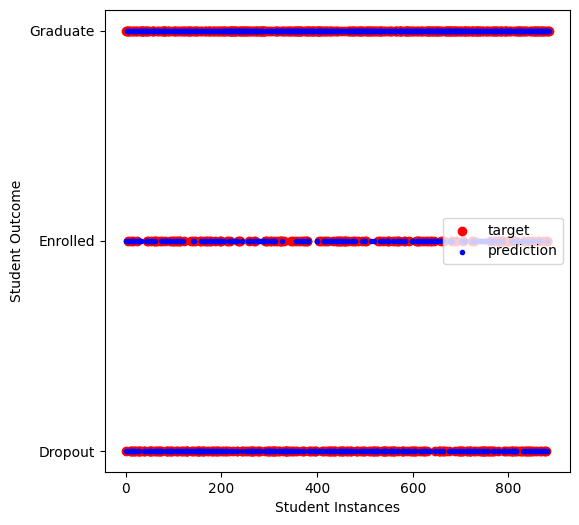

In [29]:
splits = None  # No split, all data for training.
tp = TabularPandas(
    X_train_and_validate_with_target, 
    procs=[Categorify, Normalize], 
    cat_names=X_train_and_validate.select_dtypes(include="object").columns.to_list(), 
    cont_names=X_train_and_validate.select_dtypes(exclude="object").columns.to_list(), 
    y_names=X_train_and_validate_with_target.columns[-1],
    splits=splits
)
learner = tabular_learner(dls,
                            config={'act_cls': best_found_hyper_parameters['activation_fn']},
                            layers=best_found_hyper_parameters['layers'],
                            metrics=accuracy,
                            opt_func=best_found_hyper_parameters['opt_func'],
                            wd=best_found_hyper_parameters['regularization']
                        )
learner.to(device)
with learner.no_bar():
    learner.fit(best_found_hyper_parameters['max_iterations'], lr=best_found_hyper_parameters['learning_rate'])

predictions, targets, predicted_targets = learner.get_preds(dl=dls.test_dl(X_test_with_target), with_decoded=True)
targets = targets.numpy().flatten()   
predicted_targets = predicted_targets.numpy()

eval_report_from_targets_and_predicted_targets(targets, predicted_targets)
plot_test_accuracy(targets, predicted_targets, dls.vocab)